# Analyse exploratoire — dataset 102 Ah LFP

**Huawei Tech Arena 2026 · Challenge 1 — Predicting Battery Lifetime**

Ce notebook couvre l'étape 1 du sujet : *« Access and process. Get familiar with
the dataset. The data contains some challenges that need to be handled, like
missing data or outliers. »*

Il ne construit aucun modèle. Son objectif est de répondre à trois questions
avant d'écrire la moindre ligne de modélisation :

1. **Qu'avons-nous exactement ?** Quelles conditions de vieillissement, quelle
   couverture du domaine 25–55 °C × 0.5–1.0 C, et quelles cellules vont
   réellement jusqu'à 70 % de SOH.
2. **Où sont les pièges ?** Le sujet annonce « real lab data means real
   imperfections » ; il s'agit de les mesurer une par une plutôt que de les
   découvrir en plein entraînement.
3. **Que peut-on en tirer ?** Quels signaux portent une information de
   vieillissement exploitable, et où l'extrapolation vers les conditions
   inédites sera la plus fragile.

**Rappel de la cible.** SOH (%) = capacité de décharge disponible / 102 Ah
nominal. Le score porte uniquement sur des cellules 102 Ah *cachées*, dans le
domaine 25–55 °C × 0.5–1.0 C, avec le knee-point.

## Sommaire

| § | Question |
|---|---|
| 0 | Configuration et cache de données |
| 1 | Inventaire et plan d'expérience |
| 2 | Défaut n°1 — l'ordre des lignes et le temps |
| 3 | Défaut n°2 — les cycles manquants |
| 4 | Défaut n°3 — les capteurs |
| 5 | Construction et nettoyage du SOH |
| 6 | Knee-point et dynamique de vieillissement |
| 7 | Signaux bruts et features candidates |
| 8 | Synthèse |

> **Prérequis** : les données dans `dataset/` (via `./scripts/get_dataset.sh`)
> et l'environnement du projet (`uv pip install -r requirements.txt`).

## 0 · Configuration et cache de données

Le préambule ci-dessous fixe les conventions de tout le notebook : chemins,
palette et helpers de tracé. Deux choix de visualisation sont délibérés et
valent pour toutes les figures :

- la **température est une grandeur ordinale**, elle est donc encodée par une
  rampe bleue à teinte unique (clair = froid, foncé = chaud) plutôt que par des
  couleurs arbitraires ;
- le **C-rate est catégoriel** (deux valeurs), il est encodé par le style de
  trait — pointillé pour 0.5C, plein pour 1C.

Une cellule se lit ainsi sans légende à décoder : sa couleur dit sa température,
son trait dit son courant.

In [1]:
# --- PREAMBULE COMMUN (section 0 du notebook) ------------------------------
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if not os.path.isdir(os.path.join(ROOT, "dataset")):
    ROOT = os.path.abspath(".")
DATA  = os.path.join(ROOT, "dataset")
CACHE = os.path.join(ROOT, "analysis", ".cache")
NOMINAL_AH = 102.0

# (cell_id, T degC, C-rate) - le plan d'experience fourni
CELLS = [("102Ah_25degC_0p5C_cell3", 25, 0.5),
         ("102Ah_25degC_1C_cell3",   25, 1.0),
         ("102Ah_35degC_1C_cell1",   35, 1.0),
         ("102Ah_45degC_0p5C_cell3", 45, 0.5),
         ("102Ah_45degC_1C_cell1",   45, 1.0),
         ("102Ah_55degC_1C_cell3",   55, 1.0)]
COND = {c: (T, C) for c, T, C in CELLS}

# --- palette : la temperature est une grandeur ORDINALE -> rampe bleue a un
# seul teinte, validee (monotone en clarte, ecarts >= 0.06, extremite claire a
# 2.06:1 sur la surface). Le C-rate, lui, est categoriel -> style de trait.
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
TEMP_COLOR = {25: "#86b6ef", 35: "#3987e5", 45: "#256abf", 55: "#104281"}
CRATE_LS   = {0.5: (0, (5, 2)), 1.0: "solid"}
STATUS = {"good": "#0ca30c", "warning": "#fab219", "critical": "#d03b3b"}

def style(cid):
    """Couleur + style de trait d'une cellule, coherents dans tout le notebook."""
    T, C = COND[cid]
    return dict(color=TEMP_COLOR[T], linestyle=CRATE_LS[C])

def label(cid):
    T, C = COND[cid]
    return f"{T} °C / {C:g}C"

def setup_mpl():
    mpl.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE, "figure.dpi": 110, "figure.figsize": (9, 4.6),
        "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
        "axes.labelcolor": "#52514e", "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlelocation": "left",
        "axes.titlepad": 12, "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": MUTED, "ytick.color": MUTED,
        "xtick.labelsize": 9, "ytick.labelsize": 9,
        "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
        "legend.frameon": False, "legend.fontsize": 9,
        "lines.linewidth": 2.0, "lines.solid_capstyle": "round",
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    })
setup_mpl()

def load_cell(cid, columns=None):
    """Series TRIEES (cycle puis temps reel) avec la colonne t_s reconstruite.
    C'est la version a utiliser pour toute analyse de signal."""
    p = os.path.join(CACHE, f"{cid}.parquet")
    if not os.path.exists(p):
        raise FileNotFoundError(f"cache absent : {p} - relancer la cellule de construction du cache")
    return pd.read_parquet(p, columns=columns)

def load_cell_raw(cid, columns=None):
    """Series BRUTES, dans l'ordre exact des CSV. A n'utiliser que pour
    demontrer les defauts d'ordonnancement."""
    fs = sorted(glob.glob(os.path.join(DATA, cid, "*_time_series*.csv")))
    return pd.concat([pd.read_csv(f, usecols=columns) for f in fs], ignore_index=True)

def soh_official(ts):
    """SOH % selon la definition officielle du challenge : maximum de
    step_capacity_Ah cumulee sur le step cc_discharge, divise par 102 Ah."""
    dis = ts[ts["step_type"] == "cc_discharge"]
    q = dis.groupby("cycle_number")["step_capacity_Ah"].max().sort_index()
    return pd.DataFrame({"cycle_number": q.index.astype(int),
                         "discharge_capacity_Ah": q.to_numpy(float),
                         "soh_percent": (q.to_numpy(float) / NOMINAL_AH * 100)})

def finish(ax, title=None, xlabel=None, ylabel=None, legend=True, ncol=3):
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best", ncol=ncol)
    ax.set_axisbelow(True)
    return ax

In [2]:
# Construction du cache parquet : les CSV bruts sont tries, dedoublonnes, et la
# colonne t_s (secondes depuis le debut REEL du cycle) est reconstruite depuis
# absolute_time. Voir la section 2 pour la demonstration de pourquoi ce tri est
# indispensable. 559 Mo de CSV -> 86 Mo de parquet, ~10 s la premiere fois,
# instantane ensuite.
import time
os.makedirs(CACHE, exist_ok=True)
t0 = time.time()
for cid, _, _ in CELLS:
    out = os.path.join(CACHE, f"{cid}.parquet")
    if os.path.exists(out):
        continue
    fs = sorted(glob.glob(os.path.join(DATA, cid, "*_time_series*.csv")))
    if not fs:
        raise FileNotFoundError(
            f"{cid} absent de dataset/ - recuperer les donnees avec ./scripts/get_dataset.sh")
    df = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    df["absolute_time"] = pd.to_datetime(df["absolute_time"], errors="coerce")
    n_avant = len(df)
    df = df.drop_duplicates()
    df = df.sort_values(["cycle_number", "absolute_time"], kind="mergesort").reset_index(drop=True)
    df["t_s"] = (df["absolute_time"]
                 - df.groupby("cycle_number")["absolute_time"].transform("min")).dt.total_seconds()
    df.to_parquet(out, index=False, compression="zstd")
    print(f"  {cid}: {len(df):,} lignes ({n_avant - len(df)} doublons retires)")

taille = sum(os.path.getsize(p) for p in glob.glob(os.path.join(CACHE, "*.parquet"))) / 1e6
print(f"cache pret en {time.time() - t0:.0f} s - {taille:.0f} Mo")

cache pret en 0 s - 86 Mo


## 1 · Section 1 — Inventaire et plan d'expérience

## 1. Inventaire et plan d'expérience

Le modèle final ne reçoit que `(temperature_degC, c_rate)` et doit rendre une trajectoire SOH(cycle) jusqu'à 70 %, **knee-point compris**, partout dans 25–55 °C × 0.5–1.0 C. Tout ce qui n'est pas appris pendant `fit()` est définitivement perdu. Avant de modéliser quoi que ce soit, il faut donc répondre à trois questions factuelles :

1. **Qu'a-t-on réellement ?** volumétrie par cellule, fiabilité de l'index de cycle, durée calendaire, profondeur de dégradation atteinte.
2. **Que couvre le plan d'expérience ?** quelles combinaisons (T, C-rate) existent, avec quel déséquilibre, et quelle part du domaine scoré elles délimitent.
3. **Où l'extrapolation sera-t-elle la plus fragile ?** distinguer ce qui relève d'une interpolation entre conditions vues et ce qui sort de leur enveloppe.

Cette section n'ouvre volontairement aucune courbe de SOH cycle par cycle (c'est l'objet des sections suivantes) : elle établit le cadre chiffré qui déterminera la pondération des cellules, le traitement des essais tronqués et le type de paramétrisation en (T, C) que les données peuvent supporter.

> Deux garde-fous sont posés dès ce premier calcul, parce qu'ils changent les chiffres :
> la SOH est lissée par **médiane glissante** (les décharges interrompues descendent jusqu'à 12 % de SOH apparente et ne sont pas du vieillissement), et toute comparaison « à nombre de cycles égal » est faite sur un **index réellement mesuré sur les six cellules**, jamais sur une valeur interpolée.

In [3]:
from IPython.display import display
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # coupe le bruit "font weight 600"

S1_PAUSE_H = 6.0     # au-dela de 6 h sans echantillon, on considere le banc a l'arret
S1_SOH_WIN = 11      # mediane glissante : neutralise les decharges tronquees

def s1_count_csv_rows(cid):
    """Lignes de donnees des CSV bruts (en-tetes exclus), par comptage d'octets."""
    n = 0
    for f in sorted(glob.glob(os.path.join(DATA, cid, "*_time_series*.csv"))):
        with open(f, "rb") as fh:
            c = 0
            while True:
                b = fh.read(1 << 22)
                if not b: break
                c += b.count(b"\n")
        n += c - 1
    return n

def s1_soh_robuste(cid):
    """SOH officielle lissee par mediane glissante, puis re-echantillonnee sur tous les
    index de cycle. Les cycles interrompus donnent des capacites de decharge tronquees
    (jusqu'a 12 % de SOH apparent) qu'il ne faut pas confondre avec du vieillissement.
    Renvoie aussi l'ensemble des index REELLEMENT mesures."""
    s = soh_official(load_cell(cid, columns=["cycle_number", "step_type", "step_capacity_Ah"]))
    v = s.set_index("cycle_number")["soh_percent"].rolling(S1_SOH_WIN, center=True, min_periods=3).median()
    return v.reindex(range(1, int(v.index.max()) + 1)).interpolate(), set(s["cycle_number"].tolist())

def s1_table(df, fmt):
    """Rendu de tableau compact, aligne sur la charte du notebook."""
    return (df.style.hide(axis="index").format(fmt, na_rep="—")
              .set_table_styles([
                  {"selector": "th", "props": [("background", SURFACE), ("color", MUTED), ("font-weight", "600"),
                                               ("text-align", "right"), ("padding", "5px 9px"),
                                               ("border-bottom", f"1px solid {GRID}")]},
                  {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 9px"),
                                               ("color", INK), ("border-bottom", f"1px solid {GRID}")]},
                  {"selector": "", "props": [("border-collapse", "collapse"), ("font-size", "12px")]}]))

s1_rows, s1_soh, s1_mes, s1_active, s1_sauts = [], {}, {}, {}, []
for cid, T, C in CELLS:
    d    = load_cell(cid, columns=["cycle_number", "absolute_time"])
    at   = np.sort(d["absolute_time"].to_numpy())
    gaps = np.diff(at) / np.timedelta64(1, "h")
    cut  = np.where(gaps > S1_PAUSE_H)[0]
    s1_active[cid] = list(zip(at[np.r_[0, cut + 1]], at[np.r_[cut, len(at) - 1]]))   # plages de cyclage continu

    g   = d.groupby("cycle_number")["absolute_time"].agg(["min", "max"])
    med = ((g["max"] - g["min"]).dt.total_seconds() / 3600).median()
    u   = g.index.to_numpy()
    dn  = np.diff(u) - 1                                                   # index sautes entre deux cycles mesures
    dt  = (g["min"].to_numpy()[1:] - g["max"].to_numpy()[:-1]) / np.timedelta64(1, "h")
    fant = np.clip(dn - np.clip(dt, 0, None) / med, 0, None)               # index qu'aucun temps ne peut expliquer
    for i in np.argsort(dn)[::-1][:2]:
        if dn[i] > 0:
            s1_sauts.append({"cellule": label(cid), "saut d'index": f"{int(u[i])} → {int(u[i+1])}",
                             "index sautés": int(dn[i]), "temps écoulé (h)": float(dt[i]),
                             "cycles réalisables": float(np.clip(dt[i], 0, None) / med),
                             "sautés à vide": float(fant[i])})

    lo, hi, present = int(u.min()), int(u.max()), int(u.size)
    v, mes = s1_soh_robuste(cid); s1_soh[cid], s1_mes[cid] = v, mes
    thr = {t: (float(v[v <= t].index[0]) if (v <= t).any() else np.nan) for t in (80, 70)}
    s1_rows.append({"cellule": label(cid), "n°": cid.split("_")[-1],
                    "fichiers": len(glob.glob(os.path.join(DATA, cid, "*_time_series*.csv"))),
                    "lignes CSV": s1_count_csv_rows(cid), "lignes cache": len(d),
                    "plage d'index": f"{lo}–{hi}", "cycles mesurés": present,
                    "index absents %": 100 * (1 - present / (hi - lo + 1)),
                    "dont à vide": int(round(fant.sum())),
                    "début": str(pd.Timestamp(at[0]).date()), "fin": str(pd.Timestamp(at[-1]).date()),
                    "durée (j)": (at[-1] - at[0]) / np.timedelta64(1, "D"),
                    "dont arrêt (j)": gaps[gaps > S1_PAUSE_H].sum() / 24,
                    "cycle médian (h)": med, "SOH final %": v.iloc[-1],
                    "cycle @80 %": thr[80], "cycle @70 %": thr[70]})
s1_inv = pd.DataFrame(s1_rows)

# cycle de reference honnete : le dernier index MESURE sur les six cellules
s1_commun  = set.intersection(*[s1_mes[c] for c, _, _ in CELLS])
S1_CYC_REF = max(s1_commun)
s1_inv[f"SOH @{S1_CYC_REF} cyc %"] = [s1_soh[c].loc[S1_CYC_REF] for c, _, _ in CELLS]

s1_c_vol = ["cellule", "n°", "fichiers", "lignes CSV", "plage d'index", "cycles mesurés", "index absents %",
            "dont à vide", "début", "fin", "durée (j)", "dont arrêt (j)", "cycle médian (h)"]
display(s1_table(s1_inv[s1_c_vol], {"lignes CSV": "{:,.0f}", "cycles mesurés": "{:,.0f}", "index absents %": "{:.1f}",
                                    "dont à vide": "{:,.0f}", "durée (j)": "{:.0f}", "dont arrêt (j)": "{:.0f}",
                                    "cycle médian (h)": "{:.2f}"}))
print(f"Total : {s1_inv['lignes CSV'].sum():,} lignes brutes, {s1_inv['cycles mesurés'].sum():,} cycles mesurés, "
      f"{s1_inv['durée (j)'].sum():.0f} jours de banc cumulés dont {s1_inv['dont arrêt (j)'].sum():.0f} à l'arrêt "
      f"({100 * s1_inv['dont arrêt (j)'].sum() / s1_inv['durée (j)'].sum():.0f} %).")
print("Écart CSV → cache (doublons exacts) : "
      + ", ".join(f"{n} ligne(s) sur {c}" for n, c in zip(s1_inv['lignes CSV'] - s1_inv['lignes cache'], s1_inv['cellule']) if n))
print(f"Index mesurés sur LES SIX cellules : {len(s1_commun)} — le dernier est le cycle {S1_CYC_REF}.")
print("\nLes deux plus gros sauts d'index par cellule — « à vide » = index qui n'ont pas pu être cyclés "
      "dans le temps écoulé :")
display(s1_table(pd.DataFrame(s1_sauts).sort_values("index sautés", ascending=False),
                 {"temps écoulé (h)": "{:.1f}", "cycles réalisables": "{:.0f}", "sautés à vide": "{:.0f}"}))

cellule,n°,fichiers,lignes CSV,plage d'index,cycles mesurés,index absents %,dont à vide,début,fin,durée (j),dont arrêt (j),cycle médian (h)
25 °C / 0.5C,cell3,6,"595,012",1–1375,988,28.1,211,2021-04-26,2022-01-16,265,59,4.97
25 °C / 1C,cell3,14,"1,830,763",1–5308,"4,157",21.7,649,2021-04-26,2023-04-23,727,235,2.82
35 °C / 1C,cell1,13,"1,857,025",1–5356,"5,355",0.0,0,2021-04-27,2023-04-06,709,71,2.85
45 °C / 0.5C,cell3,20,"2,768,377",1–4502,"4,303",4.4,195,2021-04-28,2023-12-27,973,202,4.51
45 °C / 1C,cell1,6,"820,940",1–2397,"2,324",3.0,58,2021-04-27,2022-03-17,324,38,2.90
55 °C / 1C,cell3,6,"729,740",1–2415,"2,176",9.9,15,2021-04-29,2022-03-17,322,71,2.79


Total : 8,601,857 lignes brutes, 19,303 cycles mesurés, 3320 jours de banc cumulés dont 676 à l'arrêt (20 %).
Écart CSV → cache (doublons exacts) : 1593 ligne(s) sur 25 °C / 1C, 1 ligne(s) sur 35 °C / 1C, 1 ligne(s) sur 45 °C / 0.5C
Index mesurés sur LES SIX cellules : 734 — le dernier est le cycle 999.

Les deux plus gros sauts d'index par cellule — « à vide » = index qui n'ont pas pu être cyclés dans le temps écoulé :


cellule,saut d'index,index sautés,temps écoulé (h),cycles réalisables,sautés à vide
25 °C / 1C,1887 → 2362,474,646.7,229,245
25 °C / 0.5C,1001 → 1372,370,849.2,171,199
25 °C / 1C,1234 → 1502,267,1.4,1,266
55 °C / 1C,218 → 434,215,721.4,259,0
45 °C / 0.5C,4384 → 4463,78,-167.0,0,78
45 °C / 0.5C,4156 → 4222,65,-1067.8,0,65
45 °C / 1C,2064 → 2079,14,0.0,0,14
45 °C / 1C,2139 → 2154,14,0.0,0,14
55 °C / 1C,2244 → 2249,4,0.0,0,4
25 °C / 0.5C,501 → 504,2,2.5,1,1


### Ce que disent les tableaux

**Le corpus est petit et très déséquilibré.** 8 601 857 lignes et 19 303 cycles mesurés pour six cellules, mais une seule cellule (45 °C / 0.5C) porte 2 768 377 lignes, soit **32 % du corpus**, contre 595 012 lignes (6.9 %) pour 25 °C / 0.5C. Le nombre de cycles mesurés va de 988 à 5 355, un rapport de **5.4**. Conséquence directe : un apprentissage pondéré à la ligne — ou même au cycle — laisserait 45 °C / 0.5C et 35 °C / 1C écrire seuls la loi de vieillissement. La pondération naturelle est **par condition**, pas par échantillon.

**`cycle_number` n'est pas un compteur de cycles fiable — et ce n'est pas qu'une question de trous.** 2 050 index de cycle sont absents au total (28.1 % de la plage sur 25 °C / 0.5C, 21.7 % sur 25 °C / 1C, 9.9 % sur 55 °C / 1C, 4.4 % / 3.0 % à 45 °C ; 35 °C / 1C est quasi complet, 1 index absent sur 5 356). Le second tableau montre que **1 128 de ces index — 55 % — n'ont pas pu correspondre à un cycle réel** : le temps écoulé entre les deux cycles mesurés qui les encadrent est trop court pour les contenir, à la durée de cycle médiane de la cellule. Le cas le plus net est 25 °C / 1C : l'index passe de **1234 à 1502 en 1 h 26**, soit 267 index pour au plus un demi-cycle réalisable. Sur 25 °C / 0.5C, l'index saute de 1001 à 1372 pendant une **pause de banc de 35 jours** où aucune ligne n'est enregistrée : 370 index, dont au moins 199 impossibles.

Autrement dit, **deux cellules au même `cycle_number` n'ont pas subi le même nombre de cycles**. C'est un biais dont il faut tenir compte partout où l'on compare des cellules « à cycle égal », et une raison de reconstruire un compteur de cycles effectifs (à partir de la charge écoulée ou du nombre de décharges observées) avant tout alignement inter-cellules.

**Le cache retire 1 595 lignes strictement dupliquées** : 1 593 sur 25 °C / 1C (réparties sur 7 cycles), 1 sur 35 °C / 1C (cycle 3185) et 1 sur 45 °C / 0.5C (cycle 2322). Cette dernière ne figurait pas dans les faits déjà établis.

**Le coût calendaire d'un cycle dépend du C-rate** : cycle médian de 4.51 à 4.97 h à 0.5C contre 2.79 à 2.90 h à 1C, soit un facteur **1.67**. C'est très probablement la raison du déséquilibre du plan : un essai 0.5C mobilise une voie de banc 1.7 fois plus longtemps pour le même nombre de cycles, et c'est l'essai 25 °C / 0.5C — le plus lent à vieillir *et* le plus lent à cycler — qui a été arrêté le premier, après seulement 988 cycles mesurés.

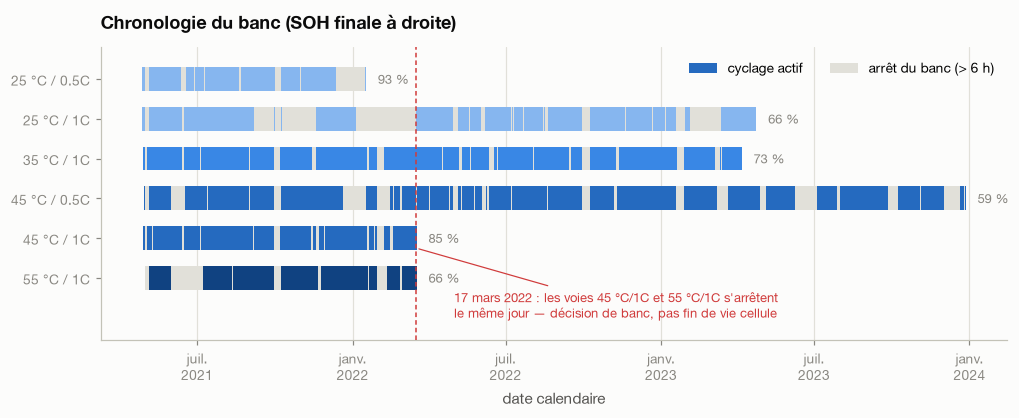

In [4]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch
S1_MOIS = {1: "janv.", 7: "juil."}

fig, ax = plt.subplots(figsize=(9.4, 3.9))
for k, (cid, T, C) in enumerate(CELLS):
    y = len(CELLS) - 1 - k
    a0, a1 = mdates.date2num(s1_active[cid][0][0]), mdates.date2num(s1_active[cid][-1][1])
    ax.broken_barh([(a0, a1 - a0)], (y - 0.30, 0.60), facecolors=GRID, edgecolors="none", zorder=1)
    ax.broken_barh([(mdates.date2num(a), max(mdates.date2num(b) - mdates.date2num(a), 0.4))
                    for a, b in s1_active[cid]], (y - 0.30, 0.60),
                   facecolors=style(cid)["color"], edgecolors="none", zorder=2)
    ax.text(a1 + 14, y, f"{s1_inv.loc[k, 'SOH final %']:.0f} %", va="center", ha="left",
            fontsize=8.5, color=MUTED, zorder=3)
s1_x_stop = mdates.date2num(pd.Timestamp("2022-03-17"))
ax.axvline(s1_x_stop, color=STATUS["critical"], lw=1.0, ls=(0, (3, 2)), zorder=4)
ax.annotate("17 mars 2022 : les voies 45 °C/1C et 55 °C/1C s'arrêtent\nle même jour — décision de banc, pas fin de vie cellule",
            xy=(s1_x_stop, 0.75), xytext=(s1_x_stop + 45, -1.00), fontsize=8.5, color=STATUS["critical"],
            arrowprops=dict(arrowstyle="-", color=STATUS["critical"], lw=0.8), zorder=5)
ax.set_yticks(range(len(CELLS)))
ax.set_yticklabels([label(c) for c, _, _ in CELLS][::-1], fontsize=9)
ax.set_ylim(-1.55, len(CELLS) - 0.20)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.set_axisbelow(False)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda v, p: f"{S1_MOIS.get(mdates.num2date(v).month, '')}\n{mdates.num2date(v).year}"))
ax.legend(handles=[Patch(facecolor=TEMP_COLOR[45], label="cyclage actif"),
                   Patch(facecolor=GRID, label=f"arrêt du banc (> {S1_PAUSE_H:.0f} h)")],
          loc="upper right", ncol=2, fontsize=9)
finish(ax, "Chronologie du banc (SOH finale à droite)", "date calendaire", None, legend=False)
fig.tight_layout()
plt.show()

### Ce que la chronologie change pour la modélisation

*Question posée par la figure : les six essais couvrent-ils la même histoire calendaire, et pourquoi se sont-ils arrêtés ?*

**Deux essais ont été arrêtés par le banc, pas par la cellule.** 45 °C / 1C et 55 °C / 1C s'achèvent le **même jour, le 17 mars 2022**, à 18 h 23 et 20 h 28 — deux heures d'écart —, respectivement à 84.8 % et 65.8 % de SOH. Une coïncidence à deux heures près sur deux voies de conditions différentes ne s'explique pas par la cellule : c'est une fin de campagne. La dernière SOH observée de 45 °C / 1C **n'est donc pas une fin de vie** : c'est une observation censurée à droite. Un modèle entraîné sur « dernier point = état atteint en fin d'essai » apprendrait que 45 °C / 1C vieillit lentement, alors qu'on ne sait simplement pas où sa courbe serait allée.

**20 % du temps calendaire est du temps d'arrêt.** 676 jours d'arrêt sur 3 320 jours cumulés, avec un cas extrême : 25 °C / 1C compte 235 jours d'arrêt sur 727 (32 % de sa durée), dont une pause unique de **44 jours**. Or pendant une pause la cellule reste à un SOC donné et continue de vieillir en calendaire. Deux cellules au même numéro de cycle n'ont donc pas vécu la même quantité de vieillissement calendaire, et l'écart ne se réduit pas : à 0.5C un cycle dure 1.67 fois plus longtemps qu'à 1C. **Le numéro de cycle absorbe silencieusement une dose variable de vieillissement calendaire** — c'est un biais structurel de la cible imposée par le challenge (SOH vs cycle), pas un défaut des données.

La campagne s'étale d'avril 2021 à décembre 2023 ; seul 45 °C / 0.5C a été poussé jusqu'à fin 2023.

In [5]:
s1_c_soh = ["cellule", f"SOH @{S1_CYC_REF} cyc %", "SOH final %", "cycle @80 %", "cycle @70 %"]
display(s1_table(s1_inv[s1_c_soh], {f"SOH @{S1_CYC_REF} cyc %": "{:.2f}", "SOH final %": "{:.1f}",
                                    "cycle @80 %": "{:,.0f}", "cycle @70 %": "{:,.0f}"}))
print("Cellules qui descendent réellement jusqu'à 70 % :",
      int(s1_inv["cycle @70 %"].notna().sum()), "sur", len(CELLS))

s1_paires = [(25, "102Ah_25degC_0p5C_cell3", "102Ah_25degC_1C_cell3"),
             (45, "102Ah_45degC_0p5C_cell3", "102Ah_45degC_1C_cell1")]
s1_delta = pd.DataFrame([
    {"température": f"{T} °C",
     **{f"Δ @{c} cyc": float(s1_soh[a].loc[c] - s1_soh[b].loc[c]) for c in (250, 500, 750, S1_CYC_REF)},
     "Δ min → max sur 100–%d" % S1_CYC_REF:
        "%+.2f → %+.2f" % tuple(np.percentile(s1_soh[a].loc[100:S1_CYC_REF].to_numpy()
                                              - s1_soh[b].loc[100:S1_CYC_REF].to_numpy(), [0, 100]))}
    for T, a, b in s1_paires])
print("Effet du C-rate à iso-cyclage : SOH(0.5C) − SOH(1C), en points de SOH")
display(s1_table(s1_delta, {c: "{:+.2f}" for c in s1_delta.columns if c.startswith("Δ @")}))
print(f"Effet de la température à 1C (cycle {S1_CYC_REF}) : "
      + ", ".join(f"{label(c)} {float(s1_soh[c].loc[S1_CYC_REF]):.2f} %" for c, T, C in CELLS if C == 1.0))

cellule,SOH @999 cyc %,SOH final %,cycle @80 %,cycle @70 %
25 °C / 0.5C,93.79,93.1,—,—
25 °C / 1C,93.83,66.3,"4,330","5,142"
35 °C / 1C,94.04,72.6,"4,345",—
45 °C / 0.5C,92.31,58.7,"2,861","3,545"
45 °C / 1C,92.17,84.8,—,—
55 °C / 1C,89.28,65.8,"1,778","2,219"


Cellules qui descendent réellement jusqu'à 70 % : 3 sur 6
Effet du C-rate à iso-cyclage : SOH(0.5C) − SOH(1C), en points de SOH


température,Δ @250 cyc,Δ @500 cyc,Δ @750 cyc,Δ @999 cyc,Δ min → max sur 100–999
25 °C,-0.13,-0.07,-0.09,-0.04,-0.35 → +0.02
45 °C,+0.12,+0.18,+0.15,+0.14,-0.16 → +0.26


Effet de la température à 1C (cycle 999) : 25 °C / 1C 93.83 %, 35 °C / 1C 94.04 %, 45 °C / 1C 92.17 %, 55 °C / 1C 89.28 %


### Profondeur réellement atteinte, et ce que les deux axes ne disent pas encore

**Seules 3 des 6 cellules descendent effectivement à 70 %** : 25 °C / 1C (cycle 5 142), 45 °C / 0.5C (3 545) et 55 °C / 1C (2 219). 35 °C / 1C s'arrête à **72.6 %** sans jamais franchir le seuil, 45 °C / 1C à 84.8 % et 25 °C / 0.5C à 93.1 %. *(Correction : la fiche de faits en annonçait quatre. En brut, 35 °C / 1C présente bien un point sous 70 % — 54.4 % au cycle 5109 — mais ses voisins immédiats sont à 74.9 % : c'est une décharge interrompue, pas du vieillissement. Après médiane glissante, la cellule ne franchit pas le seuil.)* Autrement dit, **le knee-point — l'objet même du challenge — n'est directement observable que dans trois trajectoires, à trois conditions différentes, dont une seule à 0.5C.** Les cycles à 80 % confirment les valeurs déjà établies, à un cycle près : 4 330 / 4 345 / 2 861 (2 860 avec une fenêtre de lissage plus courte) / 1 778.

**L'effet du C-rate à iso-cyclage n'est pas mesurable sur ces données.** La comparaison est faite sur les cycles réellement mesurés par toutes les cellules — il n'y en a que **734, le dernier étant le cycle 999**. Sur cette plage, l'écart SOH(0.5C) − SOH(1C) reste dans **[−0.35 ; +0.02] pt à 25 °C** et **[−0.16 ; +0.26] pt à 45 °C** : de l'ordre de 0.2 pt, c'est-à-dire du même ordre que la dispersion cellule-à-cellule attendue et **indiscernable de zéro** avec une cellule par condition. Il ne faut donc *pas* conclure que le C-rate est sans effet — seulement qu'à ce stade de vie il ne se voit pas, et que sa signature devra venir d'ailleurs (corpus public, ou fin de vie).

> **Piège écarté.** Une comparaison au cycle 1375 (le plus grand index atteint par la cellule la plus courte) donnerait +1.37 pt à 25 °C contre +0.07 pt à 45 °C, et suggérerait une interaction T × C spectaculaire. C'est un artefact : au cycle 1375, la valeur de 25 °C / 1C est interpolée à l'intérieur du trou d'index 1234 → 1502 (celui qui s'ouvre en 1 h 26), et 25 °C / 0.5C sort tout juste d'un saut de 370 index pendant une pause de 35 jours. Toute conclusion tirée d'un index non mesuré est une conclusion sur l'interpolateur, pas sur la cellule.

**La température est fortement non linéaire et mal résolue.** À 1C et 999 cycles : 93.83 % (25 °C), 94.04 % (35 °C), 92.17 % (45 °C), 89.28 % (55 °C). Entre 25 et 35 °C l'ordre est **inversé** (+0.20 pt en faveur du plus chaud), écart qu'on ne peut pas distinguer d'une dispersion cellule-à-cellule puisqu'aucune condition n'est répétée. L'accélération franche n'apparaît qu'à 55 °C — c'est-à-dire qu'**une seule cellule porte toute l'information sur le régime chaud**.

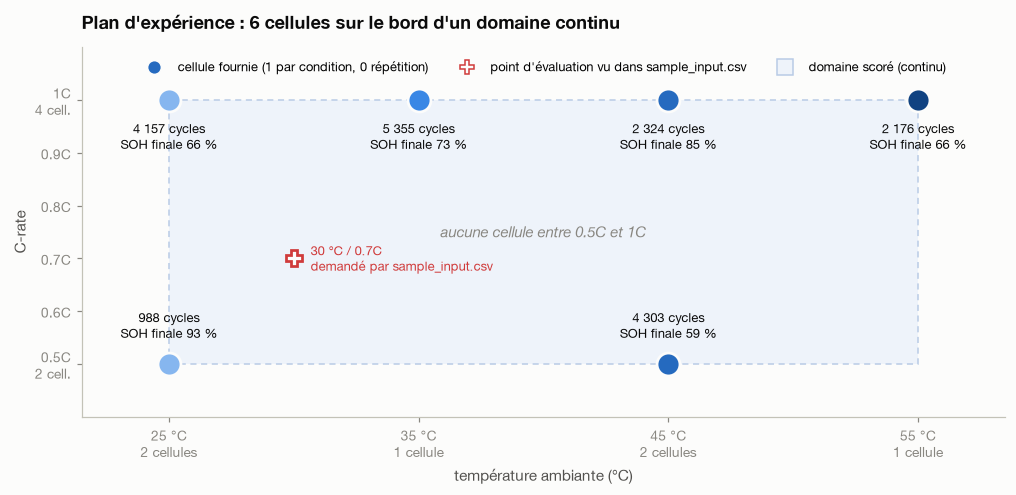

In [6]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

S1_DOM_T, S1_DOM_C = (25.0, 55.0), (0.5, 1.0)          # domaine scoré, annoncé par le README
s1_nT = pd.Series([T for _, T, _ in CELLS]).value_counts()
s1_nC = pd.Series([C for _, _, C in CELLS]).value_counts()
# seul point d'évaluation réellement visible : la ligne 30 °C / 0.7C de sample_input.csv
s1_probe_f = os.path.join(ROOT, "sample_input.csv")
if os.path.exists(s1_probe_f):
    _p = pd.read_csv(s1_probe_f)
    s1_probe = sorted({(float(t), float(c)) for t, c in
                       zip(_p["Temperature (degC)"], _p["Current (C-rate)"])}
                      - {(float(T), float(C)) for _, T, C in CELLS})
else:
    s1_probe = []

fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.add_patch(Rectangle((S1_DOM_T[0], S1_DOM_C[0]), 30, 0.5, facecolor="#eef3fa", edgecolor="#b9cbe6",
                       linewidth=1.0, linestyle=(0, (4, 3)), zorder=0))
ax.text(40, 0.75, "aucune cellule entre 0.5C et 1C", ha="center", va="center",
        fontsize=9.5, color=MUTED, style="italic", zorder=2)
for T, C in s1_probe:
    ax.plot(T, C, "P", ms=11, mfc=SURFACE, mec=STATUS["critical"], mew=1.8, ls="none", zorder=5)
    ax.annotate(f"{T:g} °C / {C:g}C\ndemandé par sample_input.csv", (T, C), textcoords="offset points",
                xytext=(11, 0), ha="left", va="center", fontsize=8.5, color=STATUS["critical"], zorder=6)
for k, (cid, T, C) in enumerate(CELLS):
    ax.plot(T, C, "o", ms=15, color=style(cid)["color"], mec=SURFACE, mew=1.8, ls="none", zorder=4)
    ax.annotate(f"{s1_inv.loc[k, 'cycles mesurés']:,} cycles\nSOH finale {s1_inv.loc[k, 'SOH final %']:.0f} %".replace(",", " "),
                (T, C), textcoords="offset points", xytext=(0, 17 if C == 0.5 else -32),
                ha="center", fontsize=8.5, color=INK, zorder=5)
ax.set_xlim(21.5, 58.5); ax.set_ylim(0.40, 1.10)
ax.set_xticks([25, 35, 45, 55])
ax.set_xticklabels([f"{T} °C\n{s1_nT.get(T, 0)} cellule" + ("s" if s1_nT.get(T, 0) > 1 else "") for T in (25, 35, 45, 55)])
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels([f"0.5C\n{s1_nC[0.5]} cell.", "0.6C", "0.7C", "0.8C", "0.9C", f"1C\n{s1_nC[1.0]} cell."])
ax.grid(False)
ax.legend(handles=[Line2D([], [], marker="o", ls="none", ms=9, color=TEMP_COLOR[45], mec=SURFACE,
                          label="cellule fournie (1 par condition, 0 répétition)"),
                   Line2D([], [], marker="P", ls="none", ms=9, mfc=SURFACE, mec=STATUS["critical"],
                          label="point d'évaluation vu dans sample_input.csv"),
                   Line2D([], [], marker="s", ls="none", ms=10, color="#eef3fa", mec="#b9cbe6",
                          label="domaine scoré (continu)")],
          loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=8.5)
finish(ax, "Plan d'expérience : 6 cellules sur le bord d'un domaine continu",
       "température ambiante (°C)", "C-rate", legend=False)
fig.tight_layout()
plt.show()

### Lecture du plan d'expérience

*Question posée par la figure : quelle partie du domaine scoré le plan d'expérience échantillonne-t-il réellement ?*

Six cellules, **six conditions distinctes, aucune répétition**. Le plan est un cadre creux : tous les points sont sur le **bord** du domaine, jamais à l'intérieur. Trois asymétries structurantes :

- **1C domine** : 4 cellules sur 6 (67 %). Les 0.5C sont deux, et l'un des deux (25 °C) s'arrête à 93.1 % — donc **une seule trajectoire 0.5C atteint le knee** (45 °C / 0.5C).
- **35 °C et 55 °C n'existent qu'à 1C.** L'effet du C-rate n'est mesurable qu'à 25 °C et 45 °C, c'est-à-dire à deux températures sur quatre — et on vient de voir qu'à ces deux températures il reste sous 0.35 pt sur toute la plage commune, donc non résolu.
- **Aucun C-rate intermédiaire.** Entre 0.5C et 1C il n'y a rien : deux niveaux, donc au mieux une droite. Aucune courbure de la loi en C-rate n'est identifiable à partir de ces données seules. Le format de nommage des cellules d'entraînement le confirme côté framework : `framework/data.py` n'accepte que `0p5C` ou `1C`.

**Le domaine d'évaluation est continu, pas une grille.** Le README et `submission_instructions_2026.md` annoncent des cellules cachées « at further operating points within 25-55 °C x 0.5-1.0 C », sans énumérer de grille — et `sample_input.csv`, le seul jeu de requêtes visible, demande déjà **30 °C / 0.7C**, un point qui ne tombe ni sur une température testée ni sur un C-rate testé. Il ne faut donc pas raisonner sur un jeu fini de « conditions non couvertes » : il faut couvrir tout le rectangle, et savoir en chaque point à quelle distance des données on se trouve. C'est l'objet des deux indicateurs qui suivent.

**Les cellules sœurs sont retenues.** Le scoring officiel se fait explicitement sur « sibling cells of the released conditions », et les identifiants fournis mélangent `cell1` et `cell3` — le laboratoire numérote donc au moins jusqu'à 3 quelque part, sans qu'on puisse en déduire un effectif par condition (`sample_data/` utilise `cell901`). **La dispersion cellule-à-cellule est donc notée mais reste inestimable** à partir de ce qui nous est fourni : elle constitue un plancher d'erreur irréductible qu'il faudra importer du corpus public, pas ajuster ici.

In [7]:
from scipy.spatial import ConvexHull

s1_P = np.array([[T, C] for _, T, C in CELLS], float)
s1_N = (s1_P - [25, 0.5]) / [30, 0.5]          # domaine scoré ramené au carré unité
s1_hull = ConvexHull(s1_N)
s1_gx, s1_gy = np.meshgrid(np.linspace(0, 1, 241), np.linspace(0, 1, 241))
s1_G = np.c_[s1_gx.ravel(), s1_gy.ravel()]
s1_D = np.sqrt(((s1_G[:, None, :] - s1_N[None, :, :]) ** 2).sum(-1)).min(1).reshape(s1_gx.shape)

def s1_norm(T, C):
    return np.array([(T - 25) / 30, (C - 0.5) / 0.5], float)

def s1_inside_hull(pt, tol=1e-9):
    """Appartenance a l'enveloppe convexe des conditions testees (invariante par
    changement d'echelle affine des axes, contrairement a la distance)."""
    return bool(np.all(s1_hull.equations[:, :2] @ np.asarray(pt, float) + s1_hull.equations[:, 2] <= tol))

s1_bilan = pd.DataFrame([
    ("cellules fournies / conditions distinctes", f"{len(CELLS)} / {len({(T, C) for _, T, C in CELLS})}"),
    ("répétitions par condition", "1 — aucune cellule sœur fournie, donc aucune mesure de dispersion"),
    ("cellules à 1C / à 0.5C", f"{s1_nC[1.0]} / {s1_nC[0.5]}  ({100 * s1_nC[1.0] / len(CELLS):.0f} % à 1C)"),
    ("cellules par température (25 / 35 / 45 / 55 °C)", " / ".join(str(s1_nT.get(T, 0)) for T in (25, 35, 45, 55))),
    ("C-rates réellement testés", "0.5C et 1C — rien entre les deux"),
    ("températures vues aux deux C-rates", "25 et 45 °C seulement (35 et 55 °C uniquement à 1C)"),
    ("cellules descendant réellement à 70 %", f"{int(s1_inv['cycle @70 %'].notna().sum())} sur {len(CELLS)}"),
    ("enveloppe convexe des conditions vues", f"{100 * s1_hull.volume:.1f} % du domaine scoré"),
    ("domaine en extrapolation stricte", f"{100 * (1 - s1_hull.volume):.1f} % (coin chaud et lent)"),
    ("distance normalisée au point testé le plus proche (médiane / max)",
     f"{np.median(s1_D):.2f} / {s1_D.max():.2f}"),
    ("part du domaine à plus de 0.30 de tout point testé", f"{100 * (s1_D > 0.30).mean():.0f} %"),
], columns=["indicateur", "valeur"])
display(s1_table(s1_bilan, {}))

indicateur,valeur
cellules fournies / conditions distinctes,6 / 6
répétitions par condition,"1 — aucune cellule sœur fournie, donc aucune mesure de dispersion"
cellules à 1C / à 0.5C,4 / 2 (67 % à 1C)
cellules par température (25 / 35 / 45 / 55 °C),2 / 1 / 2 / 1
C-rates réellement testés,0.5C et 1C — rien entre les deux
températures vues aux deux C-rates,25 et 45 °C seulement (35 et 55 °C uniquement à 1C)
cellules descendant réellement à 70 %,3 sur 6
enveloppe convexe des conditions vues,83.3 % du domaine scoré
domaine en extrapolation stricte,16.7 % (coin chaud et lent)
distance normalisée au point testé le plus proche (médiane / max),0.30 / 0.55


### Mesurer la distance à l'observé

Deux indicateurs complémentaires, calculés sur le domaine scoré ramené au carré unité (T sur 30 °C, C sur 0.5C) :

- **l'appartenance à l'enveloppe convexe** des six conditions testées — un point à l'intérieur peut être atteint par combinaison convexe de conditions observées (interpolation), un point à l'extérieur ne le peut pas (extrapolation stricte). Cet indicateur est **invariant par changement d'échelle des axes**, donc robuste.
- **la distance euclidienne normalisée** au point testé le plus proche, qui gradue le risque à l'intérieur comme à l'extérieur. Elle dépend, elle, du choix d'échelle : elle suppose implicitement que parcourir tout l'axe des températures et tout l'axe des C-rates coûte autant. C'est une convention de lecture, pas une mesure physique — et les SOH mesurées plus haut suggèrent au contraire que l'axe T pèse nettement davantage que l'axe C au moins en début de vie, ce qui rendrait cette carte **optimiste sur les points chauds et pessimiste sur les C-rates intermédiaires**. À re-pondérer dès que la sensibilité réelle sera quantifiée.

point du domaine,pourquoi,distance normalisée,condition testée la plus proche,régime
55 °C / 0.72C,maximum de la carte,0.55,45 °C / 0.5C,extrapolation
35 °C / 0.75C,milieu de l'axe C-rate,0.50,35 °C / 1C,interpolation
30 °C / 0.7C,sample_input.csv,0.43,25 °C / 0.5C,interpolation
55 °C / 0.5C,coin chaud et lent,0.33,45 °C / 0.5C,extrapolation
35 °C / 0.5C,0.5C non testé à 35 °C,0.33,25 °C / 0.5C,interpolation
50 °C / 0.6C,coin chaud et lent,0.26,45 °C / 0.5C,extrapolation


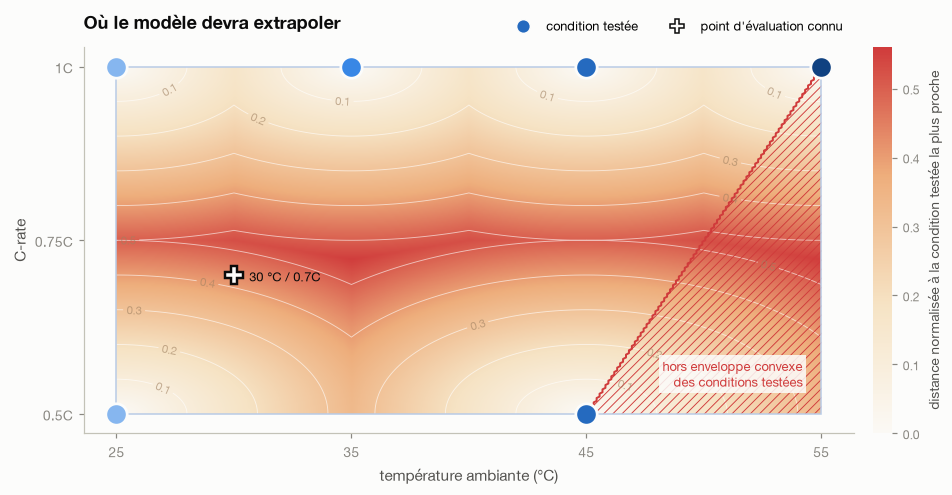

In [8]:
from matplotlib.colors import LinearSegmentedColormap
s1_cmap = LinearSegmentedColormap.from_list("s1_gap", ["#fbf9f5", "#f6e3c4", "#eeae7c", "#d03b3b"])

def s1_dist_min(T, C):
    return np.sqrt(((s1_norm(T, C) - s1_N) ** 2).sum(1))

s1_imax = np.unravel_index(np.argmax(s1_D), s1_D.shape)
s1_pire = (25 + 30 * s1_gx[s1_imax], 0.5 + 0.5 * s1_gy[s1_imax])
s1_points = ([(t, c, "sample_input.csv") for t, c in s1_probe]
             + [(round(s1_pire[0]), round(s1_pire[1], 2), "maximum de la carte"),
                (55, 0.5, "coin chaud et lent"), (50, 0.6, "coin chaud et lent"),
                (35, 0.75, "milieu de l'axe C-rate"), (35, 0.5, "0.5C non testé à 35 °C")])
s1_risque = pd.DataFrame([
    {"point du domaine": f"{T:g} °C / {C:g}C", "pourquoi": why,
     "distance normalisée": float(s1_dist_min(T, C).min()),
     "condition testée la plus proche": label(CELLS[int(s1_dist_min(T, C).argmin())][0]),
     "régime": "interpolation" if s1_inside_hull(s1_norm(T, C)) else "extrapolation"}
    for T, C, why in s1_points]).sort_values("distance normalisée", ascending=False)
display(s1_table(s1_risque, {"distance normalisée": "{:.2f}"}))

s1_in_mask = (s1_hull.equations[:, :2] @ s1_G.T + s1_hull.equations[:, 2:3] <= 1e-9).all(0).reshape(s1_gx.shape)
s1_TT, s1_CC = 25 + 30 * s1_gx, 0.5 + 0.5 * s1_gy

fig, ax = plt.subplots(figsize=(9.4, 4.6))
im = ax.imshow(s1_D, origin="lower", extent=[25, 55, 0.5, 1.0], aspect="auto", cmap=s1_cmap,
               vmin=0, vmax=0.56, interpolation="bilinear", zorder=0)
cs = ax.contour(s1_TT, s1_CC, s1_D, levels=[0.1, 0.2, 0.3, 0.4, 0.5],
                colors="#ffffff", linewidths=0.6, alpha=0.6, zorder=1)
ax.clabel(cs, fmt="%.1f", fontsize=7.5, colors="#a08161")
with mpl.rc_context({"hatch.color": STATUS["critical"], "hatch.linewidth": 0.6}):
    ax.contourf(s1_TT, s1_CC, (~s1_in_mask).astype(float), levels=[0.5, 1.5],
                colors="none", hatches=["////"], zorder=2)
ax.contour(s1_TT, s1_CC, (~s1_in_mask).astype(float), levels=[0.5],
           colors=[STATUS["critical"]], linewidths=1.3, zorder=3)
ax.add_patch(Rectangle((25, 0.5), 30, 0.5, facecolor="none", edgecolor="#b9cbe6", linewidth=1.0, zorder=3))
for T, C in s1_probe:
    ax.plot(T, C, "P", ms=12, mfc=SURFACE, mec=INK, mew=1.6, ls="none", zorder=5)
    ax.annotate(f"{T:g} °C / {C:g}C", (T, C), textcoords="offset points", xytext=(10, -1),
                ha="left", va="center", fontsize=8.5, color=INK, zorder=6)
for cid, T, C in CELLS:
    ax.plot(T, C, "o", ms=14, color=style(cid)["color"], mec=SURFACE, mew=1.8, ls="none", zorder=6)
ax.text(54.2, 0.535, "hors enveloppe convexe\ndes conditions testées", fontsize=8.5, color=STATUS["critical"],
        ha="right", va="bottom", zorder=7, bbox=dict(facecolor=SURFACE, edgecolor="none", alpha=0.85, pad=2.0))
ax.set_xlim(23.6, 56.4); ax.set_ylim(0.472, 1.028)
ax.set_xticks([25, 35, 45, 55]); ax.set_yticks([0.5, 0.75, 1.0]); ax.set_yticklabels(["0.5C", "0.75C", "1C"])
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label("distance normalisée à la condition testée la plus proche", fontsize=9, color="#52514e")
cb.ax.tick_params(labelsize=8, color=MUTED, labelcolor=MUTED); cb.outline.set_visible(False)
ax.legend(handles=[Line2D([], [], marker="o", ls="none", ms=9, color=TEMP_COLOR[45], mec=SURFACE,
                          label="condition testée"),
                   Line2D([], [], marker="P", ls="none", ms=9, mfc=SURFACE, mec=INK,
                          label="point d'évaluation connu")],
          loc="lower right", bbox_to_anchor=(1.0, 1.005), ncol=2, fontsize=8.5, frameon=False)
finish(ax, "Où le modèle devra extrapoler",
       "température ambiante (°C)", "C-rate", legend=False)
fig.tight_layout()
plt.show()

### Où l'extrapolation sera la plus fragile — et ce qu'on en fait

*Question posée par la figure : quelles zones du domaine scoré sont hors de portée d'une interpolation entre conditions observées ?*

Par ordre de fragilité décroissante :

**1. La bande des C-rates intermédiaires (≈ 0.6–0.9C).** C'est le maximum de la carte : **0.55**, atteint vers **0.72C aux températures qui n'ont qu'un seul C-rate (35 et 55 °C)** ; à 25 et 45 °C le pire vaut 0.50, à 0.75C. C'est structurel : avec deux niveaux seulement, le modèle ne peut qu'interpoler *linéairement* en C-rate, aucune courbure n'est identifiable. Et rien dans les données fournies ne contraint même la pente : sur la plage mesurée par toutes les cellules, l'écart 0.5C → 1C reste sous 0.35 pt aux deux températures où la comparaison est possible. C'est ici que le corpus public de pré-entraînement doit fournir la forme *et* l'amplitude de la dépendance en courant ; le fine-tuning ne peut presque rien y ajouter. Le seul point d'évaluation que l'on connaisse, **30 °C / 0.7C** (`sample_input.csv`), tombe précisément dans cette bande, à distance **0.43**.

**2. Le coin chaud et lent (T > 45 °C à bas C-rate) — 16.7 % du domaine, hors enveloppe convexe.** La frontière est la droite qui joint 45 °C / 0.5C à 55 °C / 1C, soit C = 0.5 + 0.05·(T − 45) : à 50 °C il faut C ≥ 0.75 pour rester en interpolation, à 55 °C il faut C = 1. Ce n'est pas une nuance sémantique : aucune combinaison convexe des essais ne produit ce régime, et c'est **physiquement celui où le vieillissement calendaire pèse le plus** (cycles ~1.7 fois plus longs, à la température la plus élevée). C'est donc exactement là où un modèle indexé sur le seul numéro de cycle se trompera le plus, et là où aucune donnée ne le corrige.

**3. 35 °C / 0.5C — géométriquement facile, empiriquement mince.** Distance 0.33, en interpolation entre les deux seules cellules 0.5C. Mais l'une des deux (25 °C) s'arrête à 93.1 % : **à 0.5C, une seule trajectoire va jusqu'au knee**. Toute loi de forme du knee à bas régime repose sur une unique cellule, sans sœur pour en estimer la variabilité.

**4. La profondeur, pas seulement la position.** On demande la courbe jusqu'à 70 % ; trois cellules sur six ne l'atteignent jamais, s'arrêtant à 93.1 %, 84.8 % et 72.6 %. La partie « après le knee » du domaine cible est documentée par trois trajectoires seulement, à 25 °C / 1C, 45 °C / 0.5C et 55 °C / 1C.

**Conséquences pour la suite du travail**

- **Paramétrer en (T, C) par une forme physique contrainte** — Arrhenius en 1/T, loi affine ou puissance en C-rate — plutôt que par un interpolateur libre : six points sans répétition ne peuvent pas identifier davantage, et un modèle flexible ajusterait la dispersion cellule-à-cellule qu'on ne sait même pas mesurer.
- **Pondérer par condition, jamais par ligne** : 32 % des lignes viennent d'une seule cellule.
- **Ne jamais aligner deux cellules sur `cycle_number` sans précaution** : 55 % des index absents n'ont jamais été cyclés, et une comparaison faite sur un index interpolé fabrique des effets qui n'existent pas (l'illusion des +1.37 pt plus haut). Reconstruire un compteur de cycles effectifs est un prérequis, pas un raffinement.
- **Traiter 25 °C / 0.5C, 45 °C / 1C et 35 °C / 1C comme censurés à droite**, et ne jamais interpréter leur dernier point comme une fin de vie — surtout pour 45 °C / 1C, arrêté un jour de campagne à 84.8 %.
- **Vérifier avant de l'ignorer que le numéro de cycle suffit** : le rapport temps calendaire / cycle varie d'un facteur 1.67 entre 0.5C et 1C, et 20 % du calendrier est du temps d'arrêt.
- **Le run « budget réduit » retire précisément les trajectoires profondes** (moins de cellules, cycles de début de vie seulement). La forme du knee devra donc venir du pré-entraînement public et non du fine-tuning : c'est le point où le bonus de robustesse se gagne ou se perd.

## 2 · Section 2 — Défaut n°1 : l'ordre des lignes et le temps

## 2. Défaut n°1 : l'ordre des lignes et le temps

Avant de parler de SOH, de knee-point ou de features, il faut régler un problème qui invalide silencieusement **tout** traitement de signal fait sur ces CSV : **les lignes ne sont pas dans l'ordre chronologique**, et la colonne `time_in_cycle_s` ne mesure pas ce qu'on croit.

Pourquoi c'est le piège le plus dangereux du jeu de données ? Parce qu'il ne provoque **aucune erreur**. `pd.read_csv` fonctionne, `groupby("cycle_number")` fonctionne, `np.gradient` fonctionne. Le code de démarrage fourni dans `my_model/model_template.py` suggère littéralement (l. 63-65) :

```python
dqdv = np.gradient(chg["step_capacity_Ah"].to_numpy(), chg["voltage_V"].to_numpy())
```

Ce code s'exécute sans broncher sur les données brutes et renvoie du bruit. Un modèle nourri avec ces features apprendra sur du bruit, et l'échec se manifestera seulement à la fin, sous la forme d'un modèle qui ne généralise pas — sans qu'on sache pourquoi.

Cette section quantifie le défaut sur les 6 cellules, explique d'où il vient, montre ce qu'il coûte concrètement sur une feature ICA, et se termine sur la règle de préparation à appliquer systématiquement.

In [9]:
# Diagnostic d'ordonnancement sur les CSV BRUTS (load_cell_raw), les 6 cellules.
# On mesure : cycles dont time_in_cycle_s recule, reculs de absolute_time,
# doublons exacts, et doublons au sens (cycle, step, horodatage).
# On garde au passage, par cycle, le recul de l'origine / la duree reelle / la plus
# longue interruption, reutilises plus bas.
import time; _t0 = time.time()
np.seterr(all="ignore")

s2_rows, s2_cyc = [], {}
for _cid, _T, _C in CELLS:
    r  = load_cell_raw(_cid)
    at = pd.to_datetime(r["absolute_time"]).to_numpy()
    cn, tic = r["cycle_number"].to_numpy(), r["time_in_cycle_s"].to_numpy()
    same  = cn[1:] == cn[:-1]                      # paires de lignes du meme cycle
    d_at  = np.diff(at) / np.timedelta64(1, "s")
    n_bad = len(np.unique(cn[1:][(np.diff(tic) < 0) & same]))   # recul STRICT
    n_cyc = r["cycle_number"].nunique()

    d = load_cell(_cid, columns=["cycle_number", "step_type", "absolute_time", "t_s"])
    g = d.groupby("cycle_number")
    s2_cyc[_cid] = pd.DataFrame({
        "min_tic_s": r.groupby("cycle_number")["time_in_cycle_s"].min(),
        "duree_s":   g["t_s"].max(),
        "pause_s":   g["t_s"].apply(lambda s: np.diff(s.to_numpy()).max() if len(s) > 1 else 0.0)})

    s2_rows.append({"cellule": label(_cid), "lignes CSV": len(r), "cycles": n_cyc,
        "cycles non triés %":        round(100 * n_bad / n_cyc, 1),
        "reculs de absolute_time":   int((d_at < 0).sum()),
        "% de paires en recul":      round(100 * (d_at < 0).mean(), 1),
        "doublons exacts":           int(r.duplicated().sum()),
        "doublons (cycle, step, t)": int(d.duplicated(subset=["cycle_number", "step_type", "absolute_time"]).sum()),
        "min time_in_cycle_s [s]":   int(tic.min())})
    del r, d, at, cn, tic

s2_defauts = pd.DataFrame(s2_rows).set_index("cellule")
print(s2_defauts.to_string())
print(f"\ntotal : {s2_defauts['cycles'].sum()} cycles, "
      f"{int(s2_defauts['doublons exacts'].sum())} doublons exacts sur les 6 cellules")
print("[%.1f s]" % (time.time() - _t0))

              lignes CSV  cycles  cycles non triés %  reculs de absolute_time  % de paires en recul  doublons exacts  doublons (cycle, step, t)  min time_in_cycle_s [s]
cellule                                                                                                                                                                 
25 °C / 0.5C      595012     988               100.0                   290573                  48.8                0                         30                   -19535
25 °C / 1C       1830763    4157               100.0                   885660                  48.4             1593                     264840                  -889250
35 °C / 1C       1857025    5355               100.0                   913413                  49.2                1                        138                  -800730
45 °C / 0.5C     2768377    4303               100.0                  1353675                  48.9                1                        170            

### Le défaut est total, systématique et identique sur les 6 cellules

**100 % des cycles** des 6 cellules ont leurs lignes désordonnées — au sens strict : dans chaque cycle, `time_in_cycle_s` recule au moins une fois. Ce n'est pas une poignée d'artefacts : entre **48,4 % et 49,4 % des paires de lignes consécutives font reculer `absolute_time`**, soit 290 573 reculs sur la plus petite cellule (25 °C/0,5C, 595 012 lignes) et 1 353 675 sur la plus grosse (45 °C/0,5C, 2 768 377 lignes). Une ligne sur deux « remonte le temps ». Aucune cellule n'est épargnée, donc aucune ne peut servir de référence saine.

Les **doublons exacts** sont, eux, presque inexistants : 1 593 lignes sur 25 °C/1C, 1 sur 35 °C/1C, 1 sur 45 °C/0,5C, zéro ailleurs — **1 595 au total sur 8,6 millions de lignes**. `drop_duplicates()` sur la ligne entière donne donc une fausse impression de propreté. Le bon critère est l'unicité de `(cycle_number, step_type, absolute_time)` : là on trouve **264 840 lignes en double sur 25 °C/1C**, soit 14,5 % de la cellule. Les cinq autres cellules restent sous 200 lignes chacune : le problème est concentré sur une seule cellule, et la cellule suivante montre pourquoi.

Enfin, `min(time_in_cycle_s)` descend jusqu'à **−889 250 s**, soit dix jours avant le début du cycle. On y revient dans deux figures.

In [10]:
# Q : d'ou viennent les 264 840 doublons (cycle, step, t) de la cellule 25 °C / 1C ?
import time; _t0 = time.time()
S2_DUP = "102Ah_25degC_1C_cell3"
_d = load_cell(S2_DUP, columns=["cycle_number", "step_type", "absolute_time",
                                "time_in_cycle_s", "current_A", "t_s"])
_k   = _d.duplicated(subset=["cycle_number", "step_type", "absolute_time"])
_top = _d.loc[_k, "cycle_number"].value_counts()
_n49 = _d[_d.cycle_number >= 4954].cycle_number.nunique()
print(f"{label(S2_DUP)} : {int(_k.sum()):,} lignes en double sur {len(_top)} cycles.")
print(f"  {100*_top[_top.index >= 4954].sum()/_k.sum():.1f} % viennent des cycles >= 4954 — "
      f"{(_top.index >= 4954).sum()} des {_n49} cycles de cette plage, pas une poignée.")
print(f"  dont {100*_top[(_top.index >= 4954) & (_top.index <= 4960)].sum()/_k.sum():.1f} % "
      f"pour les seuls cycles 4954-4960.")
print("  nombre d'enregistrements par mesure, cycles >= 4954 :",
      _d[_d.cycle_number >= 4954].groupby(["cycle_number", "step_type", "absolute_time"])
        .size().value_counts().sort_index().to_dict())

# hypothese : les fichiers-parties se recouvrent
_parts = sorted(glob.glob(os.path.join(DATA, S2_DUP, "*_time_series*.csv")))
_rng = [(os.path.basename(p).split("_")[-1][:-4],
         *pd.read_csv(p, usecols=["cycle_number"]).cycle_number.agg(["min", "max"]).astype(int).tolist())
        for p in _parts]
print("  plages de cycles des 5 derniers fichiers-parties :", _rng[-5:])

_ex = _d[(_d.cycle_number == 4961)
         & (_d.absolute_time == _d.loc[_d.cycle_number == 4961, "absolute_time"].min())]
print("  la même mesure, deux fois, avec deux origines de temps :\n",
      _ex[["cycle_number", "step_type", "absolute_time", "time_in_cycle_s"]].to_string(index=False))

# et les cycles 4954-4960 eux-memes : protocole ou pas ?
_ch = _d[_d.cycle_number.between(4953, 4962) & _d.step_type.isin(["cc_charge", "cccv_charge"])]
print("  |I| médian de charge, cycles 4953-4962 [A] :",
      _ch.groupby("cycle_number").current_A.apply(lambda s: round(float(s.abs().median()))).to_dict())
_sz = _d.groupby("cycle_number").size()
print(f"  taille d'un cycle : médiane {int(_sz.median())} lignes ; cycle 4954 = {int(_sz.loc[4954]):,} lignes ; "
      f"pas d'échantillonnage du cycle 4954 = "
      f"{np.median(np.diff(np.unique(_d.loc[_d.cycle_number == 4954, 't_s'].to_numpy()))):.0f} s")
del _d, _ch
print("[%.1f s]" % (time.time() - _t0))

25 °C / 1C : 264,840 lignes en double sur 447 cycles.
  99.9 % viennent des cycles >= 4954 — 347 des 355 cycles de cette plage, pas une poignée.
  dont 31.5 % pour les seuls cycles 4954-4960.
  nombre d'enregistrements par mesure, cycles >= 4954 : {1: 54642, 2: 112624, 3: 75920, 4: 8, 6: 14}


  plages de cycles des 5 derniers fichiers-parties : [('part10', 4846, 5092), ('part11', 5093, 5308), ('part12', 5052, 5308), ('part13', 4954, 4989), ('part14', 4990, 5308)]
  la même mesure, deux fois, avec deux origines de temps :
  cycle_number   step_type       absolute_time  time_in_cycle_s
         4961 cccv_charge 2023-03-17 18:09:17           -330.0
         4961 cccv_charge 2023-03-17 18:09:17          -1140.0
  |I| médian de charge, cycles 4953-4962 [A] : {4954: 10, 4955: 20, 4956: 10, 4957: 20, 4958: 30, 4959: 40, 4960: 50, 4961: 100, 4962: 100}
  taille d'un cycle : médiane 345 lignes ; cycle 4954 = 65,258 lignes ; pas d'échantillonnage du cycle 4954 = 1 s
[0.4 s]


### Les doublons viennent du recouvrement des fichiers-parties, pas d'un bug d'écriture

Les 264 840 lignes en double de 25 °C/1C se répartissent sur 447 cycles, mais **99,9 % d'entre elles concernent les cycles ≥ 4954** — et pas quelques cycles isolés : **347 des 355 cycles de fin de vie** sont touchés. Chaque mesure y est enregistrée **deux fois** (112 624 mesures) ou **trois fois** (75 920 mesures).

L'explication est dans le découpage des fichiers. Les parties 1 à 11 se suivent proprement, puis :

| fichier | cycles couverts |
|---|---|
| `part10` | 4846 – 5092 |
| `part11` | 5093 – 5308 |
| `part12` | 5052 – 5308 |
| `part13` | 4954 – 4989 |
| `part14` | 4990 – 5308 |

Les parties 12 à 14 **ré-exportent** une plage déjà couverte par les parties 10 et 11. Concaténer naïvement tous les `part*.csv` d'un répertoire duplique donc la fin de vie de cette cellule. La preuve que c'est bien la même mesure physique : au même `absolute_time` (2023-03-17 18:09:17, cycle 4961), les deux copies portent des `time_in_cycle_s` différents — **−330 s et −1 140 s** — parce que chaque export a recalculé l'origine du temps à sa façon. Le décalage est constant à l'intérieur d'un cycle : les valeurs mesurées sont identiques, seule l'horloge relative diffère.

**Sept cycles méritent en plus d'être isolés** — 4954 à 4960, qui pèsent à eux seuls 31,5 % des doublons. Ils ne suivent pas le protocole annoncé : le courant de charge y suit une échelle **10, 20, 10, 20, 30, 40, 50 A** (0,1C à 0,5C au lieu de 1C), l'échantillonnage passe à **1 s au lieu de 30 s**, et le cycle 4954 pèse **65 258 lignes** contre une médiane de **345**. Cela ressemble à un test de caractérisation (RPT) intercalé en fin de vie.

Conséquence pour la modélisation : **il faut dédupliquer, puis marquer ces cycles hors protocole**, sinon toute statistique agrégée par cycle (capacité, durée, température moyenne) est faussée exactement là où la trajectoire de SOH est la plus informative, c'est-à-dire au voisinage du knee-point.

          step_type  time_in_cycle_s  voltage_V  step_capacity_Ah        absolute_time
182434  cccv_charge              0.0     3.2604           10.8324  2021-07-21 16:31:20
182435  cccv_charge            -30.0     3.2589           10.4158  2021-07-21 16:30:50
182436  cccv_charge            -60.0     3.2583            9.9991  2021-07-21 16:30:20
182437  cccv_charge            -90.0     3.2570            9.5825  2021-07-21 16:29:50
182438  cccv_charge           -120.0     3.2564            9.1659  2021-07-21 16:29:20
182439  cccv_charge           -150.0     3.2555            8.7492  2021-07-21 16:28:50
182440  cccv_charge           -180.0     3.2545            8.3326  2021-07-21 16:28:20
182441  cccv_charge           -210.0     3.2536            7.9160  2021-07-21 16:27:50
182442  cccv_charge           -720.0     2.9259            0.8333  2021-07-21 16:19:20
182443  cccv_charge           -750.0     2.8605            0.4166  2021-07-21 16:18:50
182444  cccv_charge           -780.0     2.

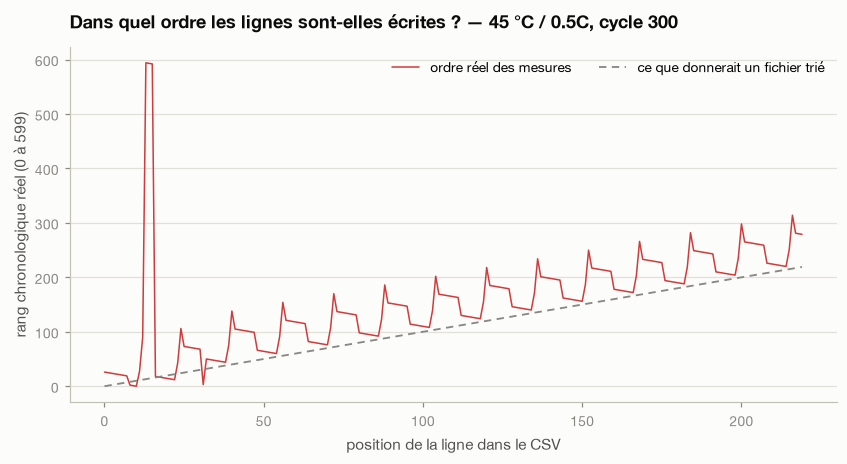

cycle 300 : 600 lignes ; la première mesure réelle arrive en 11ᵉ position dans le fichier
écarts de time_in_cycle_s les plus fréquents dans ce cycle : {-30.0: 439, -990.0: 48, 930.0: 29, 1890.0: 21}
pic le plus haut des 220 premières lignes : ligne 14 -> mesure n° 595
[1.1 s]


In [11]:
# Q : dans quel ordre les lignes d'un cycle sont-elles reellement ecrites dans le CSV ?
# On prend un cycle de milieu de vie et on trace, pour chaque ligne, son rang
# chronologique reel en fonction de sa position dans le fichier.
import time; _t0 = time.time()
S2_DEMO, S2_CYCLE = "102Ah_45degC_0p5C_cell3", 300
s2_raw = load_cell_raw(S2_DEMO)
print(s2_raw[s2_raw.cycle_number == S2_CYCLE]
      .head(13)[["step_type", "time_in_cycle_s", "voltage_V", "step_capacity_Ah", "absolute_time"]]
      .to_string(), "\n")

s2_c    = s2_raw[s2_raw.cycle_number == S2_CYCLE].reset_index(drop=True)
s2_rank = pd.to_datetime(s2_c["absolute_time"]).rank(method="first").to_numpy() - 1
_n = 220
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(np.arange(_n), s2_rank[:_n], lw=1.0, color=STATUS["critical"],
        label="ordre réel des mesures")
ax.plot(np.arange(_n), np.arange(_n), lw=1.2, color=MUTED, ls=(0, (4, 3)),
        label="ce que donnerait un fichier trié")
finish(ax, f"Dans quel ordre les lignes sont-elles écrites ? — {label(S2_DEMO)}, cycle {S2_CYCLE}",
       "position de la ligne dans le CSV", f"rang chronologique réel (0 à {len(s2_c)-1})", ncol=2)
plt.show()

print(f"cycle {S2_CYCLE} : {len(s2_c)} lignes ; la première mesure réelle arrive en "
      f"{int(np.argmin(s2_rank)) + 1}ᵉ position dans le fichier")
print("écarts de time_in_cycle_s les plus fréquents dans ce cycle :",
      pd.Series(np.diff(s2_c["time_in_cycle_s"].to_numpy())).value_counts().head(4).to_dict())
print(f"pic le plus haut des {_n} premières lignes : ligne {int(np.argmax(s2_rank[:_n])) + 1} "
      f"-> mesure n° {int(s2_rank[:_n].max()) + 1}")
print("[%.1f s]" % (time.time() - _t0))

### Ce qu'on voit dans les 13 premières lignes brutes du cycle 300

La charge commence à `time_in_cycle_s = 0` (16:31:20), puis **recule** de 30 s en 30 s jusqu'à −210 s, **saute** à −720 s, continue jusqu'à −780 s (16:18:20), **repart** à +30 s, puis **bondit** à +1920 s. La capacité chargée fait la même chose : 10,83 Ah → 7,92 Ah → 0,83 Ah → 0 Ah → 11,25 Ah → 37,50 Ah.

La vraie première mesure du cycle est la ligne d'index 182444 (`step_capacity_Ah = 0`, 2,7480 V, 16:18:20) : elle arrive **onzième** dans le fichier.

La figure donne le motif : une **dent de scie**. Le fichier est écrit par petits blocs de quelques points parcourus à rebours (l'écart le plus fréquent entre deux lignes voisines est **−30 s, 439 fois** dans ce seul cycle), blocs eux-mêmes réordonnés. Le pic isolé au début confirme qu'il n'y a aucune structure exploitable dans cet ordre : la **14ᵉ ligne** du fichier porte la **595ᵉ** mesure du cycle sur 600, c'est-à-dire une mesure de toute fin de décharge.

Deux conséquences directes :

1. Toute opération qui suppose l'ordre des lignes — `diff()`, `np.gradient`, `rolling()`, `cumsum()`, une fenêtre glissante, un LSTM/Transformer nourri en séquence — est **fausse**, sans le dire.
2. Le fait que `absolute_time` et `time_in_cycle_s` reculent **ensemble** est une bonne nouvelle : les deux colonnes restent cohérentes entre elles, c'est bien un problème d'ordre des lignes, pas de valeurs corrompues. Le tri est donc récupérable sans perte.

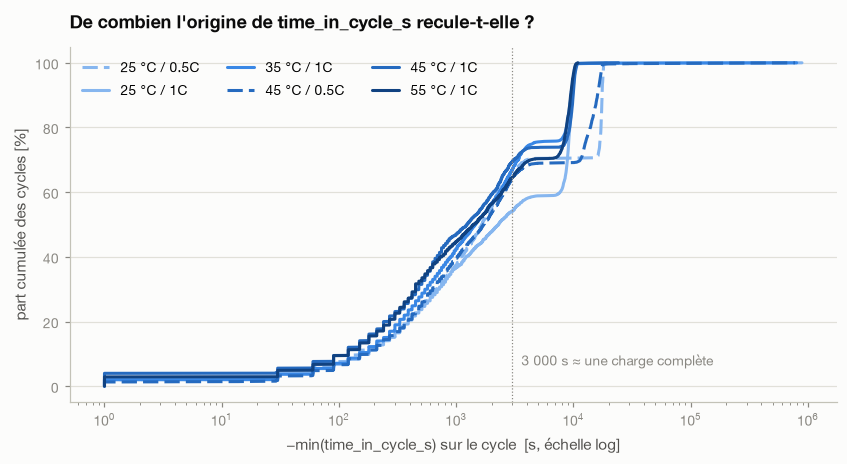

recul −min(time_in_cycle_s) : médiane 1649 s ; part des cycles > 3 000 s : 36.4 % ; part des cycles sans recul du tout : 2.2 %
  médiane par cellule [s]    : {'25 °C / 0.5C': 1650, '25 °C / 1C': 2280, '35 °C / 1C': 1440, '45 °C / 0.5C': 1710, '45 °C / 1C': 1230, '55 °C / 1C': 1410}
  99e centile par cellule [s]: {'25 °C / 0.5C': 18069, '25 °C / 1C': 10660, '35 °C / 1C': 10549, '45 °C / 0.5C': 17559, '45 °C / 1C': 10600, '55 °C / 1C': 10281}
durée réelle d'un cycle : médiane 2.91 h, max 292.4 h ; 42 cycles > 24 h sur 19303 (0.22 %)

     cellule  cycle_number  recul [h]  pause du banc [h]  durée du cycle [h]
  25 °C / 1C           343       55.8               52.8                55.9
  25 °C / 1C          4822      247.0              244.7               247.3
  35 °C / 1C          1195      173.9              172.9               175.9
  35 °C / 1C          2084      197.7              196.7               199.6
  35 °C / 1C          3460       22.0               19.2                22.0


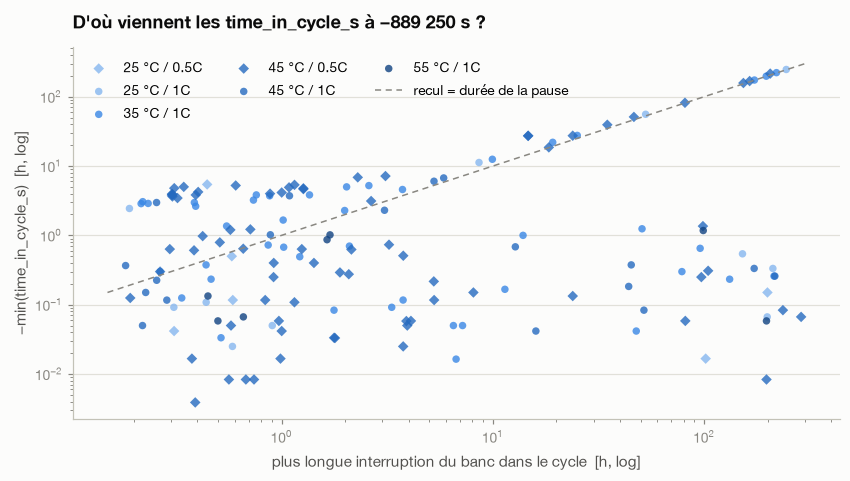

cycles contenant une interruption > 10 min : 165 ; dont recul >= 80 % de la pause (origine replacée après l'arrêt) : 74 ; rapport recul/pause médian : 0.44
  parmi les 99 cycles à pause > 1 h : 36 ont l'origine replacée
[0.2 s]


In [12]:
# Q1 : de combien l'origine de time_in_cycle_s recule-t-elle par rapport au debut reel du cycle ?
import time; _t0 = time.time()
fig, ax = plt.subplots(figsize=(9, 4.2))
for _cid, _T, _C in CELLS:
    v = np.clip(np.sort(-s2_cyc[_cid]["min_tic_s"].to_numpy()), 1, None)  # clip a 1 s pour l'echelle log
    ax.plot(v, np.arange(1, len(v) + 1) / len(v) * 100, label=label(_cid), **style(_cid))
ax.set_xscale("log")
ax.axvline(3000, color=MUTED, lw=0.8, ls=":")
ax.annotate("3 000 s ≈ une charge complète", xy=(3600, 8), fontsize=9, color=MUTED, va="center")
finish(ax, "De combien l'origine de time_in_cycle_s recule-t-elle ?",
       "−min(time_in_cycle_s) sur le cycle  [s, échelle log]", "part cumulée des cycles [%]")
plt.show()

s2_all = pd.concat({label(c): s2_cyc[c] for c, _, _ in CELLS},
                   names=["cellule", "cycle_number"]).reset_index()
s2_all["recul_s"] = -s2_all.min_tic_s
print("recul −min(time_in_cycle_s) : médiane %.0f s ; part des cycles > 3 000 s : %.1f %% ; "
      "part des cycles sans recul du tout : %.1f %%"
      % (s2_all.recul_s.median(), 100 * (s2_all.recul_s > 3000).mean(),
         100 * (s2_all.recul_s <= 0).mean()))
print("  médiane par cellule [s]    :", s2_all.groupby("cellule").recul_s.median().astype(int).to_dict())
print("  99e centile par cellule [s]:", s2_all.groupby("cellule").recul_s.quantile(.99).astype(int).to_dict())
print(f"durée réelle d'un cycle : médiane {s2_all.duree_s.median()/3600:.2f} h, "
      f"max {s2_all.duree_s.max()/3600:.1f} h ; {int((s2_all.duree_s > 86400).sum())} cycles > 24 h "
      f"sur {len(s2_all)} ({100*(s2_all.duree_s > 86400).mean():.2f} %)\n")

s2_ext = s2_all[s2_all.recul_s > 5e4].copy()
for _a, _b in [("recul [h]", "recul_s"), ("pause du banc [h]", "pause_s"), ("durée du cycle [h]", "duree_s")]:
    s2_ext[_a] = s2_ext[_b] / 3600
print(s2_ext[["cellule", "cycle_number", "recul [h]", "pause du banc [h]", "durée du cycle [h]"]]
      .to_string(index=False, float_format=lambda x: f"{x:7.1f}"))
print(f"\n{len(s2_ext)} cycles à recul > 50 000 s ; tous contiennent une interruption > 1 h : "
      f"{bool((s2_ext.pause_s > 3600).all())}")

# Q2 : le recul est-il explique par une interruption du banc ?
_sel, _MK = s2_all[s2_all.pause_s > 600].copy(), {0.5: "D", 1.0: "o"}
_sel["ratio"] = _sel.recul_s / _sel.pause_s
fig, ax = plt.subplots(figsize=(9, 4.4))
for _cid, _T, _C in CELLS:                      # couleur = temperature, marqueur = C-rate
    s = _sel[_sel.cellule == label(_cid)]
    ax.scatter(s.pause_s / 3600, s.recul_s / 3600, s=24, alpha=.8, marker=_MK[_C],
               color=style(_cid)["color"], edgecolors="none", label=label(_cid))
_l = np.array([0.15, 300])
ax.plot(_l, _l, color=MUTED, lw=1, ls=(0, (4, 3)), label="recul = durée de la pause")
ax.set_xscale("log"); ax.set_yscale("log")
finish(ax, "D'où viennent les time_in_cycle_s à −889 250 s ?",
       "plus longue interruption du banc dans le cycle  [h, log]", "−min(time_in_cycle_s)  [h, log]")
plt.show()
print(f"cycles contenant une interruption > 10 min : {len(_sel)} ; dont recul >= 80 % de la pause "
      f"(origine replacée après l'arrêt) : {int((_sel.ratio >= .8).sum())} ; "
      f"rapport recul/pause médian : {_sel.ratio.median():.2f}")
print(f"  parmi les {int((_sel.pause_s > 3600).sum())} cycles à pause > 1 h : "
      f"{int(((_sel.pause_s > 3600) & (_sel.ratio >= .8)).sum())} ont l'origine replacée")
print("[%.1f s]" % (time.time() - _t0))

### `time_in_cycle_s` n'a pas son origine au début du cycle

La première figure répond à une question simple : de combien l'origine de `time_in_cycle_s` est-elle décalée par rapport à la première mesure réelle du cycle ? Réponse : **recul médian de 1 649 s**, et les six courbes restent dans un fuseau étroit (médiane par cellule entre **1 230 s** et **2 280 s**) — le décalage est une propriété du banc, pas de la condition d'essai. Seuls **2,2 %** des cycles ont une origine correctement placée. **36,4 % des cycles ont un recul supérieur à 3 000 s**, c'est-à-dire **plus qu'une phase de charge entière**, et la queue va jusqu'à 10 300 – 18 100 s (99ᵉ centile) sur toutes les cellules alors qu'aucun incident n'est survenu.

Autrement dit : `time_in_cycle_s = 0` ne désigne **pas** le même instant physique d'un cycle à l'autre. Aligner deux cycles sur cette colonne, ou construire une feature du type « tension à t = 1 800 s », compare des points qui ne sont pas homologues. C'est une source d'erreur invisible dans un encodeur de séquence.

La seconde figure explique les valeurs extrêmes. **Les 17 cycles (sur 19 303) dont `time_in_cycle_s` descend sous −50 000 s contiennent tous une interruption du banc de plus d'une heure**, et le recul y vaut approximativement la durée de la pause : 25 °C/1C cycle 4822 → recul 247,0 h pour une pause de 244,7 h et une durée totale de 247,3 h ; 35 °C/1C cycle 3932 → 222,4 h / 219,9 h. Ces points se posent sur la diagonale. Le banc a été arrêté au milieu du cycle puis, à la reprise, a replacé l'origine du temps **après** la pause — tout ce qui précédait devient négatif.

Mais la règle n'est **pas systématique**, et c'est le point important. Sur les **165 cycles contenant une interruption de plus de 10 minutes, 74 seulement (45 %)** ont un recul au moins égal à 80 % de la pause ; pour les 91 autres l'horloge a continué de tourner pendant l'arrêt, et le rapport recul/pause médian tombe à **0,44**. Le contraste est encore plus net sur les longues interruptions : **parmi les 99 cycles à pause > 1 h, 36 seulement** ont vu leur origine replacée. À l'inverse, une partie du nuage se situe **au-dessus** de la diagonale : sur une pause courte, le recul reste dominé par le décalage de routine (~1 650 s) et n'a rien à voir avec l'arrêt. On ne peut donc ni faire confiance à `time_in_cycle_s`, ni le corriger par une règle unique.

Ce qui compte pour la modélisation : la durée médiane d'un cycle est de **2,91 h**, mais **42 cycles (0,22 %) durent plus de 24 h**, jusqu'à **292,4 h**. Ces cycles ont subi un vieillissement calendaire pendant un arrêt, souvent à un état de charge intermédiaire. Toute feature temporelle (durée de repos, relaxation de tension, dérive thermique) doit être calculée sur `absolute_time` et **robustifiée contre ces cycles-là** — ou ces cycles doivent être marqués, car ils ne représentent pas le protocole nominal.

                                      brut    trié
points de charge                    240.00   240.0
chemin parcouru en V (× la plage)     5.90     1.0
chemin parcouru en Q (× la plage)    11.05     1.0
pas où Q recule [%]                  84.50     0.0
min dQ/dV [Ah/V]                  -1399.00     3.0
max dQ/dV [Ah/V]                   2080.00  1388.0
dQ/dV non finis                      40.00    50.0 

paires de points voisins à tension strictement identique (trié) : 26 -> 50 valeurs de dQ/dV perdues


pics ICA après tri + interpolation sur grille de 2 mV (V, dQ/dV) : [(3.256, 450), (3.346, 2031), (3.382, 1978)]


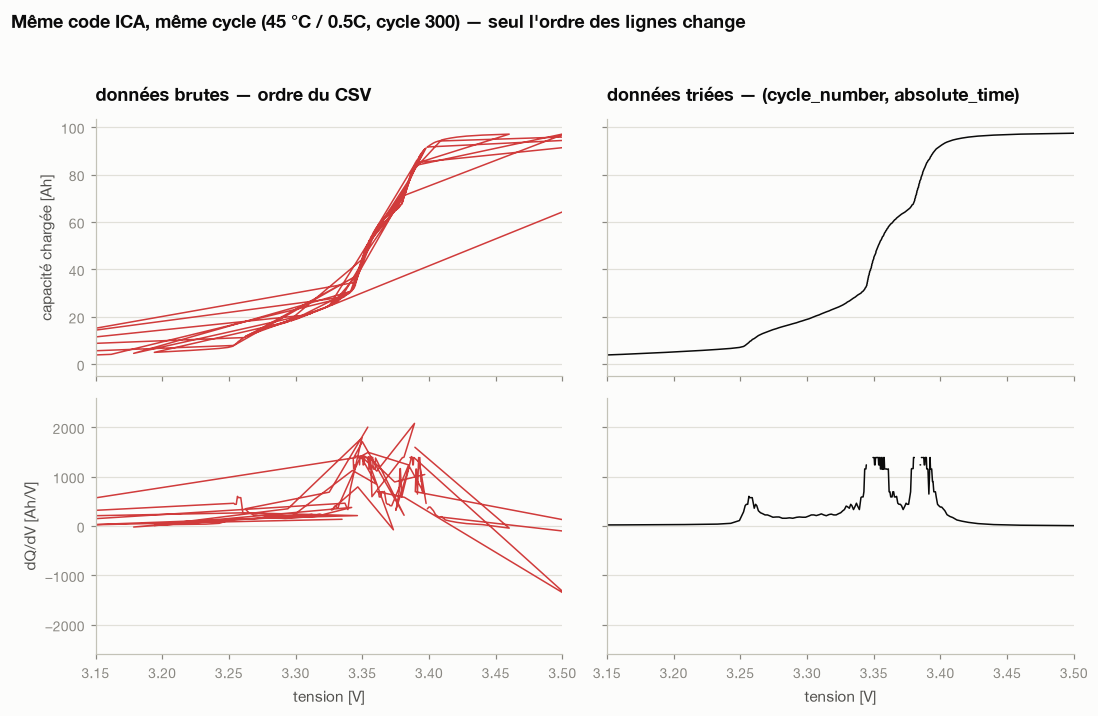

[0.5 s]


In [13]:
# LA demonstration : meme code ICA, meme cycle, seul l'ordre des lignes change.
# On reprend litteralement la recette de my_model/model_template.py.
import time; _t0 = time.time()
def s2_ica(df):
    c = df[df.step_type.isin(["cccv_charge", "cc_charge"])]
    q = c["step_capacity_Ah"].to_numpy(float)
    v = c["voltage_V"].to_numpy(float)
    dqdv = np.gradient(q, v)                 # <- exactement le code du template
    dqdv[~np.isfinite(dqdv)] = np.nan
    return v, q, dqdv

s2_srt = load_cell(S2_DEMO)
s2_vb, s2_qb, s2_db = s2_ica(s2_raw[s2_raw.cycle_number == S2_CYCLE])   # BRUT
s2_vs, s2_qs, s2_ds = s2_ica(s2_srt[s2_srt.cycle_number == S2_CYCLE])   # TRIE

def s2_score(v, q, d):
    return {"points de charge": len(v),
            "chemin parcouru en V (× la plage)": round(float(np.abs(np.diff(v)).sum() / (v.max() - v.min())), 2),
            "chemin parcouru en Q (× la plage)": round(float(np.abs(np.diff(q)).sum() / (q.max() - q.min())), 2),
            "pas où Q recule [%]":              round(float(100 * (np.diff(q) < 0).mean()), 1),
            "min dQ/dV [Ah/V]":                 int(np.nanmin(d)),
            "max dQ/dV [Ah/V]":                 int(np.nanmax(d)),
            "dQ/dV non finis":                  int(np.isnan(d).sum())}
print(pd.DataFrame({"brut": s2_score(s2_vb, s2_qb, s2_db),
                    "trié": s2_score(s2_vs, s2_qs, s2_ds)}).to_string(), "\n")
print(f"paires de points voisins à tension strictement identique (trié) : "
      f"{int((np.diff(s2_vs) == 0).sum())} -> {int(np.isnan(s2_ds).sum())} valeurs de dQ/dV perdues")

from scipy.signal import find_peaks
_vg = np.arange(3.15, 3.45, 0.002)
_dg = np.gradient(np.interp(_vg, s2_vs, s2_qs), _vg)
_p, _ = find_peaks(_dg, height=300, distance=8)
print("pics ICA après tri + interpolation sur grille de 2 mV (V, dQ/dV) :",
      [(round(float(_vg[i]), 3), int(_dg[i])) for i in _p])

fig, axes = plt.subplots(2, 2, figsize=(10, 6.6), sharex=True, sharey="row")
for j, (nm, col, v, q, dq) in enumerate([
        ("données brutes — ordre du CSV",                  STATUS["critical"], s2_vb, s2_qb, s2_db),
        ("données triées — (cycle_number, absolute_time)", INK,                s2_vs, s2_qs, s2_ds)]):
    axes[0, j].plot(v, q, lw=1.0, color=col)
    finish(axes[0, j], nm, None, "capacité chargée [Ah]" if j == 0 else None, legend=False)
    axes[1, j].plot(v, dq, lw=1.0, color=col); axes[1, j].set_ylim(-2600, 2600)
    finish(axes[1, j], None, "tension [V]", "dQ/dV [Ah/V]" if j == 0 else None, legend=False)
    axes[0, j].set_xlim(3.15, 3.50)
fig.suptitle(f"Même code ICA, même cycle ({label(S2_DEMO)}, cycle {S2_CYCLE}) — seul l'ordre des lignes change",
             x=0.006, ha="left", fontsize=12, fontweight="600", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.955)); plt.show()
del s2_raw, s2_srt, s2_c
print("[%.1f s]" % (time.time() - _t0))

### Ce que le désordre coûte sur une vraie feature

Les deux colonnes utilisent **le même code, le même cycle, les mêmes 240 points**. Seul l'ordre des lignes diffère.

**À gauche (brut).** La trajectoire Q(V) parcourt **11,05 fois** la plage de capacité et **5,90 fois** la plage de tension : la courbe fait des allers-retours au lieu de monter une fois. **84,5 % des pas font reculer la capacité**, ce qui est physiquement impossible pendant une charge. Le dQ/dV qui en résulte est un enchevêtrement de segments qui descend jusqu'à **−1 400 Ah/V** — une capacité qui diminuerait quand la tension augmente. Aucun pic n'est identifiable : cette « feature » ne contient aucune information sur l'état de la cellule.

**À droite (trié).** Ces trois indicateurs tombent à **1,00 / 1,00 / 0,0 %** : la trajectoire monte une fois, proprement, et le dQ/dV reste positif (minimum **+3 Ah/V**). La signature électrochimique attendue d'une LFP/graphite réapparaît : en interpolant Q sur une grille de tension de 2 mV, on identifie **trois pics à 3,256 V (450 Ah/V), 3,346 V (2 031 Ah/V) et 3,382 V (1 978 Ah/V)**. Ce sont ces pics — leur hauteur, leur position, l'aire sous chacun — qui portent l'information sur la perte d'inventaire de lithium et la perte de matière active, donc sur ce qui déclenche le knee-point. C'est exactement le signal qu'on veut apprendre.

**Un point d'honnêteté** : même après tri, **50 des 240 valeurs de dQ/dV sont non finies**, et c'est visible sur la figure — les sommets des deux grands pics sont troués, et la courbe tracée point à point plafonne à 1 388 Ah/V alors que les pics réels montent à ~2 000. La cause est mesurée : **26 paires de points voisins tombent exactement sur la même tension au millivolt près** (30 s d'écart sur le plateau LFP), ce qui annule le dénominateur de `np.gradient` sur les 50 points adjacents. Le tri est **nécessaire mais pas suffisant** : une ICA utilisable demande en plus une interpolation de Q sur une grille de tension régulière — c'est ce que fait le calcul de pics ci-dessus — plutôt qu'un `np.gradient` brut point à point. À retenir pour la construction des features.

In [14]:
# Validation de la regle : la capacite de charge doit croitre ligne apres ligne.
# On mesure la part de cycles ou c'est vrai, avant / apres tri / apres tri + dedoublonnage.
import time; _t0 = time.time()
def s2_mono(df):
    c   = df[df.step_type.isin(["cccv_charge", "cc_charge"])]
    q   = c["step_capacity_Ah"].to_numpy(float)
    cn  = c["cycle_number"].to_numpy()
    bad = np.zeros(len(q), bool)
    bad[1:] = (np.diff(q) < -1e-9) & (cn[1:] == cn[:-1])
    s = pd.Series(bad).groupby(cn).any()
    return 100 * (1 - s.mean()), s[s].index.tolist()

s2_regle, s2_restants = [], {}
for _cid, _T, _C in CELLS:
    r = load_cell_raw(_cid, columns=["cycle_number", "step_type", "step_capacity_Ah"])
    d = load_cell(_cid,     columns=["cycle_number", "step_type", "absolute_time", "step_capacity_Ah"])
    _p3, _b3 = s2_mono(d.drop_duplicates(subset=["cycle_number", "step_type", "absolute_time"]))
    s2_restants[label(_cid)] = _b3
    s2_regle.append({"cellule": label(_cid), "brut [%]": round(s2_mono(r)[0], 1),
                     "trié [%]": round(s2_mono(d)[0], 1), "trié + dédoublonné [%]": round(_p3, 2),
                     "cycles encore non monotones": len(_b3)})
    del r, d
s2_regle = pd.DataFrame(s2_regle).set_index("cellule")
print("Part des cycles dont la capacité de charge est monotone croissante :\n")
print(s2_regle.to_string())
print("\ncycles résiduels :", {k: v for k, v in s2_restants.items() if v})
print("[%.1f s]" % (time.time() - _t0))

Part des cycles dont la capacité de charge est monotone croissante :

              brut [%]  trié [%]  trié + dédoublonné [%]  cycles encore non monotones
cellule                                                                              
25 °C / 0.5C       1.3      99.6                  100.00                            0
25 °C / 1C         0.1      99.1                   99.98                            1
35 °C / 1C         0.0      99.4                   99.94                            3
45 °C / 0.5C       0.0      98.6                   99.79                            9
45 °C / 1C         0.0      99.5                  100.00                            0
55 °C / 1C         0.0      99.1                  100.00                            0

cycles résiduels : {'25 °C / 1C': [4960], '35 °C / 1C': [1171, 2976, 5114], '45 °C / 0.5C': [2880, 2900, 3313, 3806, 3939, 4072, 4295, 4350, 4468]}
[2.5 s]


### La règle à appliquer, et la preuve qu'elle marche

On se donne un critère de validation indépendant de tout le reste : pendant une charge, la capacité accumulée **doit** croître ligne après ligne. C'est de la physique, pas une convention.

| étape | part des cycles conformes |
|---|---|
| CSV bruts | **0,0 – 1,3 %** |
| tri par `(cycle_number, absolute_time)` | **98,6 – 99,6 %** |
| tri + déduplication sur `(cycle_number, step_type, absolute_time)` | **99,8 – 100 %** |

On passe de « quasiment aucun cycle exploitable » à « quasiment tous ». Il ne reste que **13 cycles non monotones sur 19 303** : le cycle 4960 de 25 °C/1C (l'un des sept cycles RPT), 3 cycles de 35 °C/1C (1171, 2976, 5114) et 9 de 45 °C/0,5C. Ces 13 cycles sont listés par la cellule ci-dessus et doivent être traités à part ; leur diagnostic individuel n'est pas fait ici.

---

### Règle de préparation — à appliquer avant tout autre traitement

1. **Trier par `(cycle_number, absolute_time)`**, avec un tri stable, dès le chargement. Aucune exception : pas de `head()`, pas de `groupby().first()`, pas de `np.gradient` avant cette étape.
2. **Dédupliquer sur `(cycle_number, step_type, absolute_time)`**, jamais sur la ligne entière : les doublons exacts ne représentent que 1 595 lignes sur les 6 cellules, alors que les vrais doublons en atteignent 264 840 sur la seule cellule 25 °C/1C — parce que ses fichiers `part12` à `part14` ré-exportent des cycles déjà présents dans `part10` et `part11`.
3. **Recalculer le temps** : `t_s = (absolute_time − absolute_time.min())` par cycle. **Ne jamais utiliser `time_in_cycle_s`** — ni comme abscisse, ni comme durée, ni comme clé d'alignement entre cycles. Son origine bouge d'un cycle à l'autre (recul médian 1 649 s, correcte dans 2,2 % des cycles seulement), et le banc la replace après une interruption dans moins d'un cas sur deux.
4. **Marquer les cycles anormaux** plutôt que de les laisser passer : durée réelle > 24 h (42 cycles, jusqu'à 292 h), interruption interne > 1 h, pas d'échantillonnage ≠ 30 s, courant hors protocole (cycles 4954-4960 de 25 °C/1C). Ils polluent aussi bien les features que la cible.
5. **Revérifier après coup** avec le test de monotonie de la capacité : c'est un contrôle à une ligne qui détecte immédiatement une régression dans le pipeline.

C'est exactement ce que fait `analysis/.cache/<cell_id>.parquet`, accessible via `load_cell()` — à ceci près que le cache **conserve** les doublons de recouvrement, qu'il faut donc retirer soi-même. **Tout le reste du notebook utilise cette version triée** ; `load_cell_raw()` ne sert qu'à démontrer les défauts.

> **Le risque concret pour le challenge.** Le domaine cible inclut des conditions jamais vues (par exemple 30 °C / 0,75C), donc le modèle doit s'appuyer sur des features physiquement interprétables pour extrapoler — les pics d'ICA, la résistance interne, la dynamique thermique. Ce sont précisément les features que le désordre détruit. Un modèle entraîné sur des données non triées apprend le bruit du banc de mesure, pas la dégradation ; il pourra interpoler à peu près sur les 6 cellules vues et s'effondrera hors domaine, notamment sur la position du knee-point. Et comme le run « budget réduit » ne donne que des cycles de début de vie, où la dégradation est faible et le signal ténu, la qualité du prétraitement y pèse encore plus lourd.

## 3 · Section 3 — Défaut n°2 : les cycles manquants

## 3. Défaut n°2 : les cycles manquants

La section précédente a montré que les lignes d'un cycle ne sont pas dans l'ordre. Ce défaut-ci est plus insidieux : **des numéros de cycle entiers n'existent pas dans le fichier**. Entre le cycle 501 et le cycle 504, il n'y a rien — et ce n'est pas un exemple inventé : les deux cellules 25 °C présentent toutes les deux exactement ce trou.

Pourquoi c'est un problème pour ce challenge précisément :

1. **La cible est une trajectoire indexée par le numéro de cycle.** On doit prédire SOH(n) jusqu'à 70 %, knee-point inclus. Si l'axe `n` n'est pas un compteur fiable de vieillissement, la position prédite du knee-point est fausse par construction.
2. **Toutes les features de dégradation sont des différences.** ΔSOH/Δcycle, dérive de la durée de charge CV, dérive de résistance… Un `diff()` naïf entre deux lignes consécutives d'une table indexée par cycle suppose Δcycle = 1. Nous allons voir que l'écart réel monte jusqu'à 475.
3. **Le run « budget réduit » n'utilise que le début de vie.** Il faut donc savoir si les trous se concentrent au début ou plus tard — la réponse, mesurée plus bas, n'est pas celle qu'on attend.

La question à laquelle cette section répond n'est donc pas « combien de cycles manquent » (c'est un simple comptage) mais **« qu'est-ce qui manque réellement »** : des mesures perdues, ou des numéros qui n'ont jamais correspondu à quoi que ce soit ? Les deux cas appellent des traitements opposés.

In [15]:
def s3_trous(cycles):
    """Segments d'indices de cycle absents entre le premier et le dernier cycle present."""
    c = np.asarray(sorted({int(x) for x in cycles}))
    d = np.diff(c); i = np.where(d > 1)[0]
    return pd.DataFrame({"prev": c[i], "start": c[i] + 1, "end": c[i + 1] - 1,
                         "next": c[i + 1], "length": d[i] - 1})

# pour chaque cellule : resume par cycle (bornes temporelles, duree, SOH) puis table des trous.
# dt_s = temps machine reellement ecoule dans le trou ; cycles_equiv = ce temps en nombre de cycles normaux.
s3_per, s3_gaps, s3_med = {}, {}, {}
for cid, _, _ in CELLS:
    ts = load_cell(cid, columns=["cycle_number", "step_type", "step_capacity_Ah", "absolute_time"])
    p = ts.groupby("cycle_number")["absolute_time"].agg(t0="min", t1="max")
    p["dur_s"] = (p["t1"] - p["t0"]).dt.total_seconds()
    p = p.join(soh_official(ts).set_index("cycle_number"))
    g = s3_trous(p.index.to_numpy())
    g["dt_s"] = [(p.loc[b, "t0"] - p.loc[a, "t1"]).total_seconds()
                 for a, b in zip(g["prev"], g["next"])]
    g["cycles_equiv"] = g["dt_s"] / p["dur_s"].median()
    g["ratio"] = g["cycles_equiv"] / g["length"]
    s3_per[cid], s3_gaps[cid], s3_med[cid] = p, g, p["dur_s"].median()

s3_bilan = pd.DataFrame([{
    "cellule": label(c), "1er cycle": int(s3_per[c].index.min()),
    "dernier cycle": int(s3_per[c].index.max()),
    "attendus": (n := int(s3_per[c].index.max() - s3_per[c].index.min() + 1)),
    "presents": len(s3_per[c]), "manquants": n - len(s3_per[c]),
    "% manquants": round((n - len(s3_per[c])) / n * 100, 1),
    "nb de trous": len(s3_gaps[c]),
    "plus long trou": int(s3_gaps[c]["length"].max()) if len(s3_gaps[c]) else 0,
    "duree mediane d'un cycle (h)": round(s3_med[c] / 3600, 2)} for c, _, _ in CELLS])
print(s3_bilan.to_string(index=False))

     cellule  1er cycle  dernier cycle  attendus  presents  manquants  % manquants  nb de trous  plus long trou  duree mediane d'un cycle (h)
25 °C / 0.5C          1           1375      1375       988        387         28.1           10             370                          4.97
  25 °C / 1C          1           5308      5308      4157       1151         21.7           57             474                          2.82
  35 °C / 1C          1           5356      5356      5355          1          0.0            1               1                          2.85
45 °C / 0.5C          1           4502      4502      4303        199          4.4           20              78                          4.51
  45 °C / 1C          1           2397      2397      2324         73          3.0           47              14                          2.90
  55 °C / 1C          1           2415      2415      2176        239          9.9           12             215                          2.79


Le taux de cycles manquants va de **0,02 % (35 °C/1C : un seul cycle absent sur 5356, d'où le 0,0 arrondi du tableau)** à **28,1 % (25 °C/0,5C : 387 cycles sur 1375)**. Les 6 cellules ne sont donc pas du tout logées à la même enseigne, et une stratégie unique d'imputation serait déplacée.

Deux remarques sur ce tableau avant d'aller plus loin :

- Le nombre de cycles « attendus » est défini comme `max - min + 1`. C'est une hypothèse : on suppose que le compteur du banc part de 1 et s'incrémente de 1 à chaque cycle. La section 3.1 démontre que cette hypothèse est franchement fausse pour 45 °C/0,5C (renumérotation), et l'analyse du temps machine montrera qu'elle est douteuse partout où le compteur saute sans qu'une seconde ne s'écoule.
- 35 °C/1C n'a **qu'un seul** trou dans tout le fichier. C'est notre témoin : tout ce qui la distingue des autres est un artefact de journalisation, pas une réalité électrochimique.

On regarde maintenant la **structure** des trous. Un pourcentage global ne dit rien : 20 % de cycles manquants répartis un par un, c'est un bruit d'échantillonnage ; 20 % en un seul bloc, c'est une amputation de la trajectoire.

In [16]:
s3_all = pd.concat([s3_gaps[c].assign(cellule=label(c)) for c, _, _ in CELLS], ignore_index=True)
s3_dist = pd.DataFrame({nom: {label(c): f"{int(m.sum())}  ({int(s3_gaps[c].loc[m, 'length'].sum())})"
    for c, _, _ in CELLS for m in [s3_gaps[c]["length"].between(lo, hi)]}
    for lo, hi, nom in [(1, 1, "1"), (2, 3, "2-3"), (4, 10, "4-10"),
                        (11, 100, "11-100"), (101, 10**9, "> 100")]})
print("nombre de trous  (et cycles perdus) par classe de longueur")
print(s3_dist.to_string())
print(f"\n{len(s3_all)} trous au total, {int(s3_all['length'].sum())} cycles perdus")
print(f"  trous de 1 a 3 cycles : {(s3_all['length'] <= 3).mean() * 100:.1f} % des trous, "
      f"mais {s3_all.loc[s3_all['length'] <= 3, 'length'].sum() / s3_all['length'].sum() * 100:.1f} % des cycles perdus")
print(f"  trous de plus de 100  : {(s3_all['length'] > 100).sum()} trous seulement, "
      f"mais {s3_all.loc[s3_all['length'] > 100, 'length'].sum() / s3_all['length'].sum() * 100:.1f} % des cycles perdus")

nombre de trous  (et cycles perdus) par classe de longueur
                     1        2-3     4-10    11-100     > 100
25 °C / 0.5C    1  (1)    8  (16)   0  (0)    0  (0)  1  (370)
25 °C / 1C      5  (5)  46  (130)   0  (0)   3  (82)  3  (934)
35 °C / 1C      1  (1)     0  (0)   0  (0)    0  (0)    0  (0)
45 °C / 0.5C    8  (8)     1  (3)  9  (45)  2  (143)    0  (0)
45 °C / 1C    45  (45)     0  (0)   0  (0)   2  (28)    0  (0)
55 °C / 1C      2  (2)    7  (14)   2  (8)    0  (0)  1  (215)

147 trous au total, 2050 cycles perdus
  trous de 1 a 3 cycles : 84.4 % des trous, mais 11.0 % des cycles perdus
  trous de plus de 100  : 5 trous seulement, mais 74.1 % des cycles perdus


La distribution est **bimodale, et les deux modes ne posent pas du tout le même problème** :

- **124 trous sur 147 (84,4 %) font 1 à 3 cycles** et ne représentent que **11,0 %** des cycles perdus. Ce sont des micro-interruptions : à l'échelle d'une trajectoire de 5000 cycles, elles ne déplacent pas le knee-point. Elles cassent en revanche les `diff()`.
- **5 trous de plus de 100 cycles concentrent 74,1 %** des cycles perdus (474, 370, 267, 215, 193). Ceux-là amputent la trajectoire et sont potentiellement dévastateurs : un trou de 474 indices au milieu de 25 °C/1C, c'est 8,9 % de son axe de cycle.

Les longueurs ne sont d'ailleurs pas quelconques : 45 °C/0,5C a **neuf trous d'exactement 5 cycles**, 25 °C/1C **trente-huit trous d'exactement 3 cycles**, 45 °C/1C **quarante-cinq trous d'exactement 1 cycle**. Une valeur qui se répète des dizaines de fois à l'identique n'est pas une panne, c'est une procédure. La figure suivante situe ces trous dans la vie de chaque cellule.

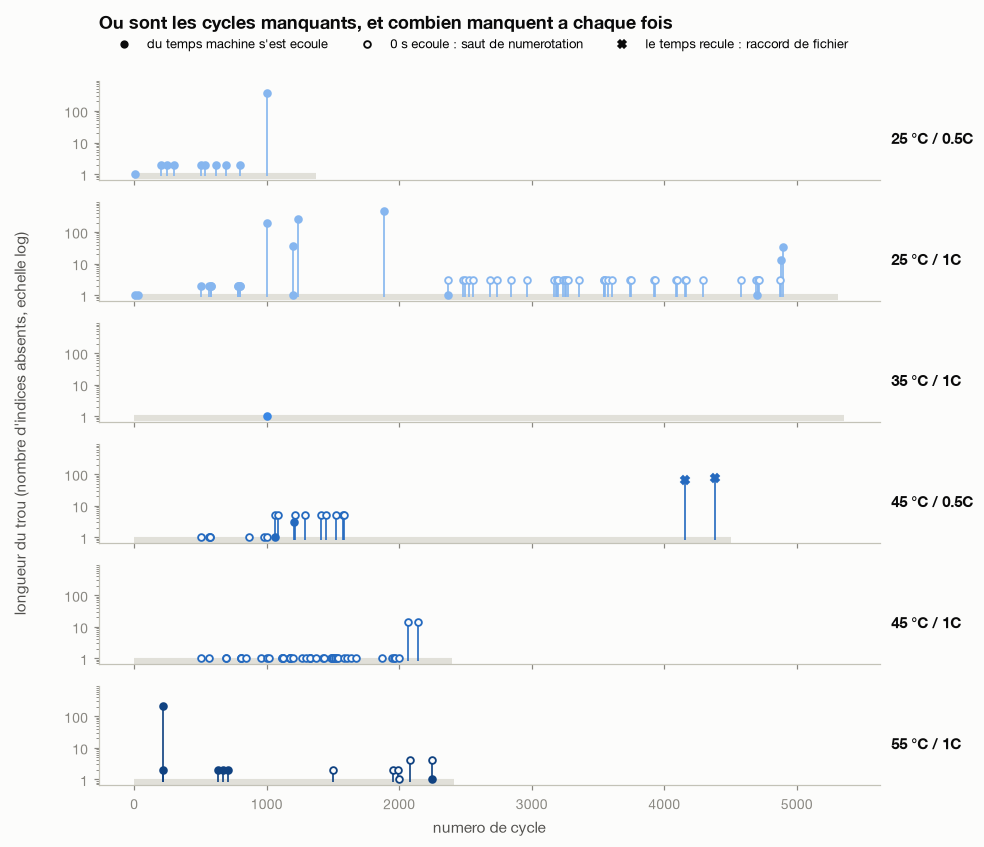

In [17]:
# Question : les trous sont-ils uniformement repartis, ou concentres a un moment de la vie ?
# Une ligne par cellule ; la hauteur du baton = longueur du trou (log) ; le marqueur dit si du
# temps machine s'est reellement ecoule pendant le trou (voir cellule suivante).
fig, axes = plt.subplots(len(CELLS), 1, figsize=(9.4, 7.8), sharex=True, sharey=True)
for ax, (cid, _, _) in zip(axes, CELLS):
    p, g, st = s3_per[cid], s3_gaps[cid], style(cid)
    ax.plot([p.index.min(), p.index.max()], [0.85, 0.85], color=GRID, lw=4,
            solid_capstyle="butt", zorder=1)
    cat = [(g["dt_s"] > 60, "o", st["color"]),        # du temps s'est ecoule
           (g["dt_s"].abs() <= 60, "o", SURFACE),     # 0 s : pur saut de numerotation
           (g["dt_s"] < -60, "X", st["color"])]       # le temps recule : raccord de fichier
    for m, mk, fc in cat:
        s = g[m]
        if not len(s): continue
        ax.vlines(s["start"], 0.85, s["length"], color=st["color"], lw=1.1, zorder=2)
        ax.plot(s["start"], s["length"], mk, ms=5.4 if mk == "X" else 4.4, mfc=fc,
                mec=st["color"], mew=1.2, ls="none", zorder=3)
    ax.set_yscale("log"); ax.set_ylim(0.65, 900)
    ax.set_yticks([1, 10, 100]); ax.set_yticklabels(["1", "10", "100"])
    ax.text(1.015, 0.42, label(cid), transform=ax.transAxes, fontsize=9.5,
            color=INK, weight="bold", va="center")
    ax.grid(axis="y"); finish(ax, legend=False)
axes[-1].set_xlabel("numero de cycle")
fig.supylabel("longueur du trou (nombre d'indices absents, echelle log)",
              fontsize=10, color="#52514e", x=0.015)
axes[0].legend([plt.Line2D([], [], marker="o", ms=4.4, mfc=INK, mec=INK, ls="none"),
                plt.Line2D([], [], marker="o", ms=4.4, mfc=SURFACE, mec=INK, mew=1.2, ls="none"),
                plt.Line2D([], [], marker="X", ms=5.4, mfc=INK, mec=INK, ls="none")],
               ["du temps machine s'est ecoule", "0 s ecoule : saut de numerotation",
                "le temps recule : raccord de fichier"],
               loc="lower left", bbox_to_anchor=(0.0, 1.18), ncol=3, fontsize=8.5)
axes[0].set_title("Ou sont les cycles manquants, et combien manquent a chaque fois", pad=34)
fig.tight_layout(); fig.subplots_adjust(right=0.855, left=0.10); plt.show()

La répartition n'a rien d'uniforme, mais elle n'est pas non plus la même d'une cellule à l'autre : 45 °C/1C ne perd que des indices isolés répartis sur les cycles 500-2100, 55 °C/1C perd un bloc de 215 cycles dès le cycle 219, et les deux cellules 25 °C perdent l'essentiel de leurs indices entre les cycles 1000 et 2400. **Il n'y a pas de fenêtre de vie « propre » commune aux six cellules** — nous quantifierons plus bas ce que cela coûte au run « budget réduit ».

Les deux marqueurs en croix de 45 °C/0,5C vers les cycles 4157 et 4385 signalent un temps machine **négatif** : le fichier revient en arrière. On y consacre la section 3.1.

Reste la question centrale. Un numéro de cycle absent peut signifier deux choses radicalement différentes :

- **(a) le cycle a eu lieu mais n'a pas été journalisé** → la cellule a réellement vieilli pendant ce temps, et il faut en tenir compte ;
- **(b) le compteur a sauté sans que rien ne se passe** → il n'y a rien à imputer, et « corriger » en interpolant ajouterait du vieillissement fictif.

On peut trancher grâce à `absolute_time` : on mesure **le temps machine écoulé entre la dernière ligne du cycle qui précède le trou et la première ligne du cycle qui suit**. Si N cycles ont vraiment tourné, il s'est écoulé environ N × la durée d'un cycle. Si le compteur a sauté, il s'est écoulé zéro seconde.

                                                       nb_trous  cycles_perdus  % des cycles perdus  ratio median  ratio min  ratio max
classe                                                                                                                                 
1 - saut de numerotation (0 s ecoule)                        86            221                 10.8          0.00      0.000       0.00
2 - operation plus courte qu'un cycle                        21           1175                 57.3          0.27      0.002       0.56
3 - vrais cycles retires du log                              34            459                 22.4          1.00      0.879       1.20
4 - temps >> indices (arret de banc ou check-up long)         4             52                  2.5         16.85      3.454      33.66
5 - le temps recule (raccord de fichier)                      2            143                  7.0         -2.06     -3.639      -0.47

classe 1 : 83/86 trous ont dt exactement = 0 s 

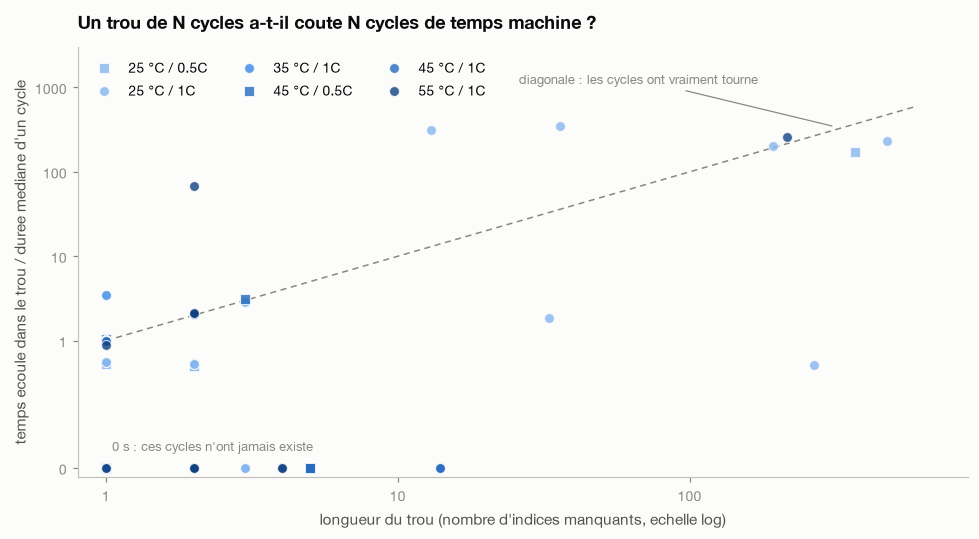

In [18]:
def s3_classe(r):
    if r["dt_s"] < -60:      return "5 - le temps recule (raccord de fichier)"
    if abs(r["dt_s"]) <= 60: return "1 - saut de numerotation (0 s ecoule)"
    if r["ratio"] < 0.6:     return "2 - operation plus courte qu'un cycle"
    if r["ratio"] <= 2:      return "3 - vrais cycles retires du log"
    return "4 - temps >> indices (arret de banc ou check-up long)"
s3_all["classe"] = s3_all.apply(s3_classe, axis=1)
s3_tab = s3_all.groupby("classe").agg(nb_trous=("length", "size"), cycles_perdus=("length", "sum"))
s3_tab["% des cycles perdus"] = (s3_tab["cycles_perdus"] / s3_tab["cycles_perdus"].sum() * 100).round(1)
s3_tab["ratio median"] = s3_all.groupby("classe")["ratio"].median().round(2)
s3_tab["ratio min"] = s3_all.groupby("classe")["ratio"].min().round(3)
s3_tab["ratio max"] = s3_all.groupby("classe")["ratio"].max().round(2)
print(s3_tab.to_string())

s3_c1 = s3_all[s3_all["classe"].str.startswith("1")]
print(f"\nclasse 1 : {int((s3_c1['dt_s'] == 0).sum())}/{len(s3_c1)} trous ont dt exactement = 0 s "
      f"(les {int((s3_c1['dt_s'] != 0).sum())} autres : 1 s).")
print("  longueurs des sauts purs :", s3_c1["length"].value_counts().sort_index().to_dict())
s3_c2 = s3_all[s3_all["classe"].str.startswith("2")].sort_values("ratio")
print(f"\nclasse 2 : {len(s3_c2)} trous / {int(s3_c2['length'].sum())} indices, mais 4 gros trous "
      f"({s3_c2.nlargest(4, 'length')['length'].tolist()}) pesent "
      f"{int(s3_c2.nlargest(4, 'length')['length'].sum())} de ces indices.")
print("  les 17 petits trous (<= 2 indices) ont un ratio tres serre : "
      f"{s3_c2.query('length <= 2')['ratio'].min():.2f} a {s3_c2.query('length <= 2')['ratio'].max():.2f}"
      f" (mediane {s3_c2.query('length <= 2')['ratio'].median():.2f})")
print("\nles quatre trous de classe 4 :")
print(s3_all[s3_all["classe"].str.startswith("4")]
      .assign(jours=lambda d: (d["dt_s"] / 86400).round(2))[["cellule", "start", "length", "jours"]]
      .to_string(index=False))

# Question : un trou de N indices a-t-il coute N cycles de temps machine ?
fig, ax = plt.subplots(figsize=(9, 5.0))
for cid, _, C in CELLS:
    g = s3_gaps[cid][s3_gaps[cid]["dt_s"] > -60]   # les 2 trous a temps negatif sont traites en 3.1
    st = style(cid)
    ax.plot(g["length"], np.clip(g["cycles_equiv"], 0, None), "o" if C == 1.0 else "s",
            ms=6.5, alpha=0.8, mfc=st["color"], mec=SURFACE, mew=0.7, ls="none", label=label(cid))
ax.plot([1, 600], [1, 600], color=MUTED, lw=1, ls=(0, (4, 3)), zorder=0)
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=0.4)
ax.set_xlim(0.8, 900); ax.set_ylim(-0.04, 3000)
ax.set_yticks([0, 1, 10, 100, 1000]); ax.set_yticklabels(["0", "1", "10", "100", "1000"])
ax.set_xticks([1, 10, 100]); ax.set_xticklabels(["1", "10", "100"]); ax.minorticks_off()
ax.annotate("diagonale : les cycles ont vraiment tourne", (330, 330), xytext=(26, 1100),
            fontsize=8.5, color=MUTED,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8, shrinkA=2, shrinkB=6))
ax.annotate("0 s : ces cycles n'ont jamais existe", (1.05, 0.06), fontsize=8.5, color=MUTED, va="bottom")
ax.grid(axis="y")
finish(ax, "Un trou de N cycles a-t-il coute N cycles de temps machine ?",
       "longueur du trou (nombre d'indices manquants, echelle log)",
       "temps ecoule dans le trou / duree mediane d'un cycle", ncol=3)
fig.tight_layout(); plt.show()

Le résultat est net, et il est en grande partie une **mauvaise nouvelle pour l'idée d'interpoler** :

- **86 trous (221 cycles, 10,8 % du total) n'ont consommé aucun temps machine.** Pour 83 d'entre eux, `absolute_time` de la dernière ligne d'avant et de la première ligne d'après sont *rigoureusement identiques* (les 3 autres : 1 s). Le compteur a sauté de 1 (38 fois), 3 (32 fois), 5 (9 fois), 2 ou 4 (5 fois), voire **14 unités (2 fois)** sans qu'une seconde ne s'écoule. **Ces cycles n'ont jamais existé.** Ils ne doivent surtout pas être imputés.
- **34 trous (459 cycles) sont sur la diagonale** (ratio 0,88 à 1,20, médiane **1,00**) : le temps écoulé correspond au nombre d'indices manquants. Ce sont de vrais cycles, réellement effectués, simplement absents du fichier. Eux méritent d'être comptés dans l'âge de la cellule.
- **21 trous (1175 cycles, 57,3 %) sont sous la diagonale**, ratio médian 0,27 : du temps s'est écoulé, mais **bien moins que le nombre d'indices sautés ne le suggère**. Attention toutefois : **1144 de ces 1175 indices viennent de 4 gros trous seulement** (474, 370, 267, 33), dont les ratios s'étalent de 0,002 à 0,48 — la classe est hétérogène.
- **4 trous sont très au-dessus de la diagonale**, mais ils ne sont pas de même nature : **3 sont de longs arrêts de banc** (40,7 j et 36,8 j sur 25 °C/1C, 7,8 j sur 55 °C/1C) pendant lesquels la cellule est restée au repos, et **le quatrième est le trou unique de 35 °C/1C** (9,83 h, cycle 1000).
- **2 trous ont un temps négatif** — le fichier revient en arrière. Section 3.1.

Ce qui est vraiment reproductible, ce sont les **17 petits trous de classe 2 (≤ 2 indices)** : leur ratio ne s'écarte pas de la fourchette **0,25 – 0,56**, médiane 0,27. Une valeur aussi serrée oriente vers une procédure de banc régulière, pas vers un aléa. Testons l'hypothèse évidente : des **check-ups périodiques** (RPT) exécutés tous les 500 cycles et filtrés du log.

In [19]:
from scipy.stats import binomtest
print("les trous COURTS (<= 10 cycles) tombent-ils sur les multiples de 500 ?\n")
tot_hit = tot_k = 0; attendu = 0.0
for cid, _, _ in CELLS:
    g = s3_gaps[cid]; hi = int(s3_per[cid].index.max())
    petits = {i for _, r in g[g["length"] <= 10].iterrows()
              for i in range(int(r["start"]), int(r["end"]) + 1)}
    ks = list(range(500, hi + 1, 500))
    hit = [k for k in ks if any(k + o in petits for o in (-2, -1, 0, 1, 2))]
    pk = 1 - (1 - len(petits) / hi) ** 5          # proba qu'une fenetre de 5 indices soit touchee au hasard
    tot_hit += len(hit); tot_k += len(ks); attendu += pk * len(ks)
    print(f"  {label(cid):13s} {len(hit)}/{len(ks):2d} multiples touches "
          f"(attendu au hasard {pk * len(ks):.2f})   {hit}")
print(f"  TOTAL {tot_hit}/{tot_k} contre {attendu:.2f} attendus au hasard  "
      f"(p = {binomtest(tot_hit, tot_k, attendu / tot_k, alternative='greater').pvalue:.1e}, "
      f"baseline optimiste : voir notes)")

g35 = s3_gaps["102Ah_35degC_1C_cell1"].iloc[0]
print(f"\n  35 °C/1C, seul et unique trou de la cellule : cycle {int(g35['start'])}, "
      f"{g35['dt_s'] / 3600:.2f} h de temps machine = {g35['ratio']:.2f} cycle normal")

# Que contient un trou court ? On compare sa duree aux deux moities d'un cycle.
print("\n  contenu des trous de 2 indices des cellules 25 °C (mesure sur les cycles 400-900) :")
for cid in ["102Ah_25degC_1C_cell3", "102Ah_25degC_0p5C_cell3"]:
    w = load_cell(cid, columns=["cycle_number", "step_type", "absolute_time"])
    w = w[w["cycle_number"].between(400, 900)]
    d0 = w.groupby(["cycle_number", "step_type"])["absolute_time"].min().unstack()
    mA = (d0["cccv_charge"] - d0["cc_discharge"]).dt.total_seconds()             # decharge + repos
    mB = (d0["cc_discharge"].shift(-1) - d0["cccv_charge"]).dt.total_seconds()   # charge   + repos
    mA, mB = mA[(mA > 0) & (mA < 2e4)], mB[(mB > 0) & (mB < 3e4)]
    obs = s3_gaps[cid].query("length == 2 and 0.1 < ratio < 0.6")["dt_s"]
    print(f"   {label(cid):13s} trou observe {obs.median():.0f} s +/- {obs.std():.0f} "
          f"({len(obs)} occurrences, {obs.median() / s3_med[cid]:.2f} cycle)")
    print(f"                 moitie 'charge + repos'   = {mB.median():.0f} s -> ecart "
          f"{abs(obs.median() - mB.median()) / obs.median() * 100:.1f} %")
    print(f"                 moitie 'decharge + repos' = {mA.median():.0f} s -> ecart "
          f"{abs(obs.median() - mA.median()) / obs.median() * 100:.1f} %")

# Preuve directe : la sequence des steps bascule de phase de part et d'autre du trou 502-503.
w = load_cell("102Ah_25degC_1C_cell3", columns=["cycle_number", "step_type", "absolute_time"])
w = w[w["cycle_number"].between(501, 505)]
seq = w[w["step_type"].ne(w["step_type"].shift()) | w["cycle_number"].ne(w["cycle_number"].shift())]
print("\n  sequence des steps autour du trou 502-503 (25 °C/1C) :")
for cn, grp in seq.groupby("cycle_number"):
    print(f"   cycle {int(cn)} : " + " -> ".join(grp["step_type"]))

les trous COURTS (<= 10 cycles) tombent-ils sur les multiples de 500 ?

  25 °C / 0.5C  1/ 2 multiples touches (attendu au hasard 0.12)   [500]
  25 °C / 1C    2/10 multiples touches (attendu au hasard 1.21)   [500, 2500]
  35 °C / 1C    1/10 multiples touches (attendu au hasard 0.01)   [1000]
  45 °C / 0.5C  2/ 9 multiples touches (attendu au hasard 0.55)   [500, 1000]
  45 °C / 1C    4/ 4 multiples touches (attendu au hasard 0.36)   [500, 1000, 1500, 2000]
  55 °C / 1C    2/ 4 multiples touches (attendu au hasard 0.19)   [1500, 2000]
  TOTAL 12/39 contre 2.44 attendus au hasard  (p = 2.9e-06, baseline optimiste : voir notes)

  35 °C/1C, seul et unique trou de la cellule : cycle 1000, 9.83 h de temps machine = 3.45 cycle normal

  contenu des trous de 2 indices des cellules 25 °C (mesure sur les cycles 400-900) :
   25 °C / 1C    trou observe 5446 s +/- 20 (6 occurrences, 0.54 cycle)
                 moitie 'charge + repos'   = 5449 s -> ecart 0.0 %
                 moitie 'decharge 

**L'hypothèse d'une procédure périodique est confirmée.** Sur les 39 multiples de 500 que traversent les 6 cellules, **12 portent un trou court**, contre **2,44 attendus** si les trous étaient placés au hasard (binomiale, p ≈ 3·10⁻⁶ — baseline optimiste, voir notes). C'est le plus frappant sur 45 °C/1C : **4 multiples de 500 sur 4 sont touchés** (500, 1000, 1500, 2000). Le témoin le confirme de la plus belle manière : **35 °C/1C n'a qu'un seul trou dans tout son fichier, et c'est le cycle 1000**, qui a coûté **9,83 h de temps machine, soit 3,45 fois la durée d'un cycle normal** — le profil d'un test de capacité lent inséré dans le protocole puis retiré du log.

Et on peut aller plus loin que la coïncidence de position : **on sait ce qui a été effacé.** Le trou de 2 indices dure **5446 s ± 20 s** à 1C et **9014 s ± 84 s** à 0,5C, soit **exactement une demi-séquence** dans les deux cas. Comparé aux deux moitiés mesurées d'un cycle réel :

| moitié de cycle | 25 °C/1C | 25 °C/0,5C |
|---|---|---|
| charge + repos | 5449 s (**écart 0,0 %**) | 8997 s (**écart 0,2 %**) |
| décharge + repos | 5306 s (écart 2,6 %) | 8826 s (écart 2,1 %) |
| **trou observé** | **5446 s** | **9014 s** |

La dernière preuve est indépendante et sans appel : **la séquence des steps change de phase de part et d'autre du trou.** Avant, un cycle vaut `cccv_charge → rest → cc_discharge → rest` ; après, il vaut `cc_discharge → rest → cccv_charge → rest`. Il manque donc littéralement **une charge et son repos** — une demi-séquence — pendant que le compteur, lui, avançait de 3.

**Implication : le numéro de cycle et le nombre de cycles réellement effectués sont deux grandeurs différentes.** Il faut construire un compteur d'âge propre au lieu d'utiliser `cycle_number` tel quel.

### 3.1 Le cas 45 °C / 0,5C : ce ne sont pas des trous, c'est un raccord

Deux trous restaient inexpliqués : ceux de 65 et 78 cycles de 45 °C/0,5C, avec un **temps machine négatif** (−44,5 jours et −7,0 jours). Un temps négatif entre deux cycles consécutifs n'est pas une panne de banc : c'est un fichier assemblé à partir de morceaux. Vérifions en découpant la cellule là où `absolute_time` recule, puis en cherchant si les horodatages d'après le raccord sont **déjà présents** avant.

blocs chronologiques de 45 °C / 0.5C (coupes la ou absolute_time recule) :
  cycles     1..4156   2021-04-28 16:25:02  ->  2023-12-01 16:00:37   (4100 cycles)
  cycles  4222..4384   2023-10-18 04:09:49  ->  2023-12-27 14:37:29   (163 cycles)
  cycles  4463..4502   2023-12-20 15:37:10  ->  2023-12-27 14:37:29   (40 cycles)


  cycles 4222-4344 : 123/123 cycles dont 100 % des horodatages sont deja presents avant le cycle 4157
      -> ce sont les cycles 3866-3988 renumerotes (decalage +356) : 122 paires de SOH comparables, ecart maximal 0.000000 pt
      -> periode rejouee : 18 Oct 2023 -> 06 Nov 2023


  cycles 4463-4502 : 40/40 cycles dont 100 % des horodatages sont deja presents avant le cycle 4385
      -> ce sont les cycles 4345-4384 renumerotes (decalage +118) : 39 paires de SOH comparables, ecart maximal 0.000000 pt
      -> periode rejouee : 20 Dec 2023 -> 27 Dec 2023

  cycles sans aucun step cc_discharge (donc sans SOH) : [4156, 4344, 4384, 4502]
  cycles a decharge tronquee (SOH < 50 %) : {2875: 12.11, 3308: 28.41, 3801: 28.63, 4345: 42.75, 4463: 42.75}
  cycles uniques reels : 4303 presents - 163 doublons = 4140
  faux rebond de SOH : +4.55 pt entre les indices 4155 et 4222


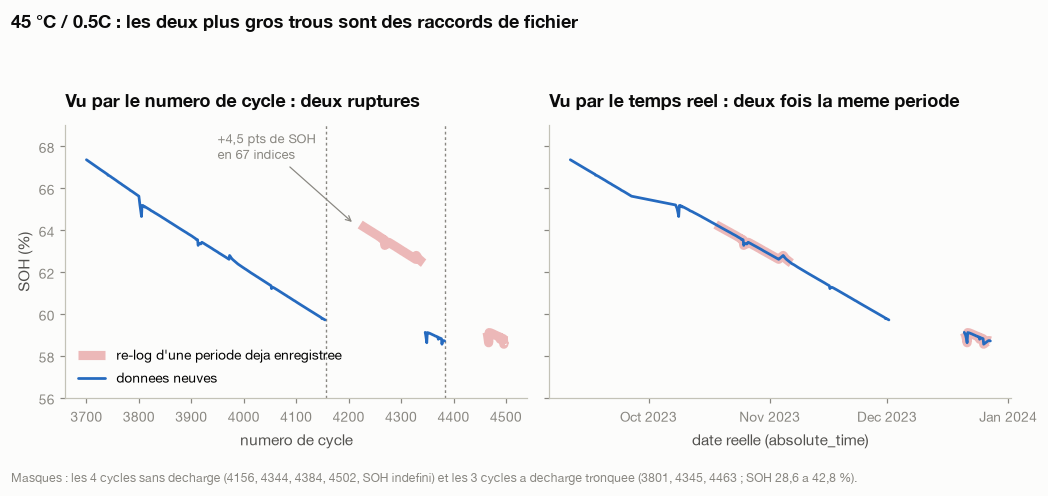

In [20]:
s3_cid = "102Ah_45degC_0p5C_cell3"; s3_p45 = s3_per[s3_cid]
s3_brk = [0] + list(np.where(np.diff(s3_p45["t0"].to_numpy()) < np.timedelta64(0))[0] + 1) + [len(s3_p45)]
print("blocs chronologiques de 45 °C / 0.5C (coupes la ou absolute_time recule) :")
for a, b in zip(s3_brk[:-1], s3_brk[1:]):
    print(f"  cycles {s3_p45.index[a]:>5d}..{s3_p45.index[b-1]:<5d}  "
          f"{s3_p45['t0'].iloc[a]}  ->  {s3_p45['t1'].iloc[b-1]}   ({b - a} cycles)")

s3_ts45 = load_cell(s3_cid, columns=["cycle_number", "absolute_time"])
s3_ts45 = s3_ts45.assign(_t=s3_ts45["absolute_time"].astype("int64"))   # comparaison entiere : instantane
s3_dup = []
for lo, hi, ref, off in [(4222, 4344, 4157, 356), (4463, 4502, 4385, 118)]:
    vus = np.unique(s3_ts45.loc[s3_ts45["cycle_number"] < ref, "_t"].to_numpy())
    q = s3_ts45[s3_ts45["cycle_number"].between(lo, hi)]
    f = pd.Series(np.isin(q["_t"].to_numpy(), vus), index=q["cycle_number"].to_numpy()).groupby(level=0).mean()
    a = s3_p45["soh_percent"].reindex(range(lo, hi + 1)).to_numpy()
    b = s3_p45["soh_percent"].reindex(range(lo - off, hi + 1 - off)).to_numpy()
    ok = ~(np.isnan(a) | np.isnan(b))
    s3_dup += list(range(lo, hi + 1))
    print(f"  cycles {lo}-{hi} : {int((f > 0.999).sum())}/{len(f)} cycles dont 100 % des horodatages "
          f"sont deja presents avant le cycle {ref}\n"
          f"      -> ce sont les cycles {lo-off}-{hi-off} renumerotes (decalage +{off}) : "
          f"{int(ok.sum())} paires de SOH comparables, ecart maximal {np.nanmax(np.abs(a[ok]-b[ok])):.6f} pt\n"
          f"      -> periode rejouee : {s3_p45.loc[lo,'t0']:%d %b %Y} -> {s3_p45.loc[hi,'t1']:%d %b %Y}")

s3_nan = s3_p45.index[s3_p45["soh_percent"].isna()].tolist()
print(f"\n  cycles sans aucun step cc_discharge (donc sans SOH) : {s3_nan}")
s3_tronq = s3_p45["soh_percent"][s3_p45["soh_percent"] < 50]
print(f"  cycles a decharge tronquee (SOH < 50 %) : "
      f"{ {int(k): round(v, 2) for k, v in s3_tronq.items()} }")
print(f"  cycles uniques reels : {len(s3_p45)} presents - {len(s3_dup)} doublons = {len(s3_p45)-len(s3_dup)}")
print(f"  faux rebond de SOH : {s3_p45.loc[4222,'soh_percent'] - s3_p45.loc[4155,'soh_percent']:+.2f} pt "
      f"entre les indices 4155 et 4222")

import matplotlib.dates as mdates
st = style(s3_cid)
z = s3_p45[(s3_p45.index >= 3700) & (s3_p45["soh_percent"] > 50)]   # on masque les cycles tronques
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4), sharey=True)
for ax, xk in zip(axes, ["cycle", "date"]):
    for i, (a, b) in enumerate([(4222, 4344), (4463, 4502)]):
        s = z[(z.index >= a) & (z.index <= b)]
        ax.plot(s.index if xk == "cycle" else s["t0"], s["soh_percent"], color=STATUS["critical"],
                lw=6, alpha=0.35, solid_capstyle="butt",
                label="re-log d'une periode deja enregistree" if i == 0 else None)
    for i, (a, b) in enumerate([(3700, 4156), (4345, 4384)]):
        s = z[(z.index >= a) & (z.index <= b)]
        ax.plot(s.index if xk == "cycle" else s["t0"], s["soh_percent"], color=st["color"], lw=1.8,
                label="donnees neuves" if i == 0 else None)
    ax.set_ylim(56, 69); ax.grid(axis="y")
for x in (4156.5, 4384.5): axes[0].axvline(x, color=MUTED, lw=0.9, ls=(0, (2, 2)), zorder=0)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].annotate("+4,5 pts de SOH\nen 67 indices", (4215, 64.2), xytext=(3950, 67.4),
                 fontsize=8.5, color=MUTED, ha="left",
                 arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8, shrinkB=4))
finish(axes[0], "Vu par le numero de cycle : deux ruptures", "numero de cycle", "SOH (%)",
       legend=True, ncol=1)
finish(axes[1], "Vu par le temps reel : deux fois la meme periode",
       "date reelle (absolute_time)", None, legend=False)
fig.suptitle("45 °C / 0.5C : les deux plus gros trous sont des raccords de fichier",
             x=0.012, ha="left", fontsize=12, weight="bold", color=INK)
fig.text(0.012, 0.005, "Masques : les 4 cycles sans decharge (4156, 4344, 4384, 4502, SOH indefini) "
         "et les 3 cycles a decharge tronquee (3801, 4345, 4463 ; SOH 28,6 a 42,8 %).",
         fontsize=8, color=MUTED)
fig.tight_layout(rect=(0, 0.04, 1, 0.93)); plt.show()

**Le fichier 45 °C/0,5C est un collage de trois blocs, et deux d'entre eux sont des doublons.**

- Le bloc principal couvre les cycles 1 à 4156 (28 avril 2021 → 1ᵉʳ décembre 2023).
- Les cycles **4222 à 4344** rejouent la période **18 octobre → 6 novembre 2023** : **123 cycles sur 123 ont 100 % de leurs horodatages déjà présents** avant le cycle 4157. Vérification indépendante par le SOH : ce sont les cycles **3866-3988 renumérotés (+356)**, et sur les 122 paires comparables **l'écart de SOH est nul à 10⁻⁶ point près** — SOH(4222) = SOH(3866) = 64,270 %.
- Les cycles **4463 à 4502** rejouent les cycles **4345 à 4384** (décalage +118) : **40 cycles sur 40** entièrement dupliqués, 39 paires de SOH strictement identiques.

Donc sur les 346 indices qui suivent le cycle 4156, **163 sont des doublons re-numérotés, 143 sont « manquants », et seulement 40 sont des données neuves**. Le nombre de cycles uniques de cette cellule est **4140, pas 4303** — et ses deux « trous » de 65 et 78 cycles ne sont pas des mesures perdues : ce sont les coutures du collage.

Deux points de vigilance annexes, mesurés au passage : les cycles **4156, 4344, 4384 et 4502** ne contiennent **qu'un step `cccv_charge` et aucune décharge**, donc **aucun SOH calculable** (ils sortent en NaN) ; et les cycles **4345 et 4463** ont une décharge tronquée qui produit un SOH aberrant de **42,75 %** (le cycle 3801 en fait autant à 28,63 %, hors raccord). Ces cycles sont masqués dans la figure.

Le panneau de droite est la preuve visuelle : tracé contre le **temps réel**, le segment rouge se superpose exactement à la courbe bleue. Tracé contre le **numéro de cycle**, il crée un faux rebond de SOH de **+4,5 points entre les indices 4155 et 4222**.

**Conséquence immédiate :** un modèle entraîné naïvement sur `SOH ~ cycle_number` verrait cette cellule *rajeunir* de 4,5 points puis replonger. C'est exactement le genre d'artefact qui fait apparaître un faux knee-point. Ces 163 cycles doivent être supprimés avant tout entraînement, et la déduplication doit se faire sur `absolute_time`, pas sur la ligne entière (le cache ne les a pas éliminés parce que leur `cycle_number` diffère).

Dernier test : le SOH est-il cohérent de part et d'autre des trous ? Si un trou de N indices contenait N vrais cycles de vieillissement, la chute de SOH à travers le trou devrait valoir N fois la pente locale.

In [21]:
def s3_pente(s, c0, w=120):
    """pente locale du SOH (%/cycle), mediane des differences premieres sur +-w cycles."""
    sub = s[(s.index >= c0 - w) & (s.index <= c0 + w)]
    if len(sub) < 20: return np.nan
    return np.median(np.diff(sub.values) / np.diff(sub.index.to_numpy()))

s3_neff = []
for c, _, _ in CELLS:
    s = s3_per[c]["soh_percent"].dropna()
    for _, r in s3_gaps[c].iterrows():
        if r["length"] < 12: continue
        a, b = int(r["prev"]), int(r["next"])
        sl = [x for x in (s3_pente(s, a), s3_pente(s, b)) if x == x]
        # on ne garde l'estimation que si la pente locale est nette et negative des deux cotes
        fiable = len(sl) > 0 and all(x < 0 for x in sl) and abs(np.mean(sl)) >= 0.003
        ds = s.get(b, np.nan) - s.get(a, np.nan)
        s3_neff.append({"cellule": label(c), "trou": f"{int(r['start'])}-{int(r['end'])}",
                        "indices sautes": int(r["length"]),
                        "cycles de temps machine": round(r["cycles_equiv"]),
                        "delta SOH (pts)": round(ds, 3) if ds == ds else np.nan,
                        "cycles de vieillissement": round(ds / np.mean(sl), 1) if (fiable and ds == ds) else np.nan})
print(pd.DataFrame(s3_neff).to_string(index=False))

s3_impact = pd.DataFrame([{"cellule": label(c),
    "transitions cycle->cycle": len(d := np.diff(s3_per[c].index.to_numpy())),
    "dont delta > 1": int((d > 1).sum()),
    "% de diff() faussees": round((d > 1).mean() * 100, 2),
    "delta max": int(d.max())} for c, _, _ in CELLS])
print("\n", s3_impact.to_string(index=False))
print(f"\nglobal : {int(s3_impact['dont delta > 1'].sum())} transitions sur "
      f"{int(s3_impact['transitions cycle->cycle'].sum())} = "
      f"{s3_impact['dont delta > 1'].sum() / s3_impact['transitions cycle->cycle'].sum() * 100:.2f} % "
      f"des diff() naives sont fausses, avec un ecart reel allant jusqu'a {int(s3_impact['delta max'].max())} cycles")

# Combien des 2050 indices manquants correspondent a un cycle reellement effectue ?
s3_bil = s3_all.copy()
s3_bil["reel"] = np.where(s3_bil["dt_s"] > 0, np.clip(np.round(s3_bil["cycles_equiv"]), 0, None), 0)
s3_bil.loc[s3_bil["classe"].str.startswith(("4", "5")), "reel"] = 0   # repos de banc / raccord : aucun cyclage
s3_bil = (s3_bil.groupby("classe")[["length", "reel"]].sum().astype(int)
          .rename(columns={"length": "indices manquants", "reel": "cycles reellement effectues"}))
s3_bil["indices sans contrepartie"] = s3_bil["indices manquants"] - s3_bil["cycles reellement effectues"]
print("\n", s3_bil.to_string())
print(f"\n  total : {s3_bil['indices manquants'].sum()} indices manquants pour "
      f"{s3_bil['cycles reellement effectues'].sum()} cycles reellement effectues -> "
      f"{(s3_bil['indices manquants'].sum() - s3_bil['cycles reellement effectues'].sum())} indices sans contrepartie "
      f"({(s3_bil['indices manquants'].sum() - s3_bil['cycles reellement effectues'].sum()) / s3_bil['indices manquants'].sum() * 100:.0f} %)")

# Question : le run "budget reduit" (debut de vie seulement) est-il plus ou moins touche ?
def s3_manque(cid, a, b):
    idx = set(int(i) for i in s3_per[cid].index); b = min(b, int(max(idx)))
    return (b - a + 1 - sum(1 for i in range(a, b + 1) if i in idx)) / (b - a + 1) * 100
s3_debut = pd.DataFrame([{"cellule": label(c), "dernier cycle": int(s3_per[c].index.max()),
    "% manquant 1-500": round(s3_manque(c, 1, 500), 1),
    "% manquant 1-1000": round(s3_manque(c, 1, 1000), 1),
    "% manquant 1-2000": round(s3_manque(c, 1, 2000), 1),
    "% manquant sur toute la vie": round(s3_manque(c, 1, 10**9), 1)} for c, _, _ in CELLS])
print("\n", s3_debut.to_string(index=False))

     cellule      trou  indices sautes  cycles de temps machine  delta SOH (pts)  cycles de vieillissement
25 °C / 0.5C 1002-1371             370                      171           -0.689                     158.0
  25 °C / 1C 1002-1194             193                      202           -1.519                       NaN
  25 °C / 1C 1198-1233              36                      346           -1.026                       NaN
  25 °C / 1C 1235-1501             267                        1            0.034                       NaN
  25 °C / 1C 1888-2361             474                      229           -0.899                       NaN
  25 °C / 1C 4882-4894              13                      313           -1.584                     124.7
  25 °C / 1C 4896-4928              33                        2            0.325                     -23.4
45 °C / 0.5C 4157-4221              65                     -237              NaN                       NaN
45 °C / 0.5C 4385-4462              7

Trois compteurs indépendants — **indices sautés**, **temps machine**, **vieillissement mesuré sur le SOH** — et ils sont souvent en désaccord :

| trou | indices | temps machine | vieillissement | verdict |
|---|---|---|---|---|
| 45 °C/1C, 2065-2078 et 2140-2153 | 14 | **0** | **1,4 et 1,2** | indices fictifs, le SOH n'a bougé que d'un cycle |
| 25 °C/1C, 1235-1501 | **267** | **1** | ΔSOH = **+0,034 pt** | 267 indices pour rien : la cellule n'a pas vieilli |
| 55 °C/1C, 219-433 | 215 | 259 | 187,5 | les trois concordent → vrais cycles retirés du log |
| 25 °C/0,5C, 1002-1371 | 370 | 171 | 158,0 | temps et SOH concordent (~165), **l'index sur-compte d'un facteur 2,2** |
| 25 °C/1C, 1198-1233 | 36 | 346 (40,7 j) | non estimable | arrêt de banc de 6 semaines |
| 25 °C/1C, 4882-4894 | 13 | 313 (36,8 j) | 124,7 | pause de 5 semaines près du knee : −1,58 pt |
| 25 °C/1C, 4896-4928 | 33 | 2 | non estimable | ΔSOH = **+0,325 pt** : relaxation après la pause |

Les deux dernières lignes sont importantes pour la modélisation du knee-point : après l'arrêt de 36,8 jours, le SOH **chute de 1,58 point puis remonte de 0,33 point** sur les cycles suivants. Un modèle qui ne voit que le numéro de cycle interprétera ce creux-rebond comme un événement de dégradation intrinsèque, alors que c'est un artefact de repos calendaire. (La colonne « cycles de vieillissement » du trou 4896-4928 ressort négative précisément parce que le SOH remonte : elle n'a pas de sens et ne doit pas être lue.)

Au total, **2050 indices manquent pour environ 930 cycles réellement effectués** : **1120 indices (55 %) n'ont aucune contrepartie physique**, dont 221 en saut pur à 0 s et 143 en artefact de raccord — deux catégories certaines à 100 %.

Enfin, le cas de 25 °C/0,5C est à retenir : **sa série continue s'arrête au cycle 1001 (SOH 93,79 %)**, puis 370 indices s'évaporent et il ne reste que 4 cycles isolés (1372-1375, SOH 93,10 %). Sur le papier la cellule « va jusqu'au cycle 1375 » ; en pratique on n'a de trajectoire exploitable que jusqu'à 1001.

**Le dernier tableau corrige une intuition fausse sur le run « budget réduit ».** Le début de vie n'est pas la zone la plus trouée : sur les 500 premiers cycles, **cinq cellules sur six perdent moins de 1,5 % de leurs indices** (0,0 % pour trois d'entre elles). L'exception est brutale et unique : **55 °C/1C perd 43,4 % de ses 500 premiers indices** — et il s'agit de vrais cycles (ratio temps/indices = 1,20). Autrement dit, le run à budget réduit travaille sur des données globalement plus propres que la moyenne, **sauf sur la cellule la plus chaude, dont l'axe d'âge est décalé d'environ 215 cycles dès le départ.**

### 3.2 Ce qu'il faut en faire

**Le fait central : `cycle_number` n'est pas un compteur de vieillissement.** Il est monotone, mais son pas est irrégulier et parfois entièrement fictif. Sur les 6 cellules, **1120 des 2050 indices « manquants » (55 %) ne correspondent à aucun cycle réellement effectué** : 221 en saut pur (0 s), 143 en artefact de raccord de fichier, et environ 757 de plus dans les trous où le temps écoulé est très inférieur au nombre d'indices sautés. À l'inverse, **459 indices de classe 3 correspondent à ~512 cycles réellement effectués puis retirés du log** — ceux-là manquent vraiment.

Ce qu'on en tire concrètement :

1. **Construire un axe d'âge propre plutôt que d'utiliser `cycle_number`.** Le candidat naturel est le **cycle effectif cumulé**, reconstruit à partir de `absolute_time` : à chaque trou, on n'ajoute pas `length` mais `round(dt_s / durée_médiane_du_cycle)`. Alternative plus physique et robuste au bruit d'indexation : l'**Ah débité cumulé** (`step_capacity_Ah` sur `cc_discharge`), qui ne dépend pas du tout du compteur. Les deux axes devraient être calculés et comparés — l'énoncé demande une prédiction en fonction du numéro de cycle, il faudra donc *reconvertir* à la fin, mais l'apprentissage doit se faire sur un axe honnête.

2. **Aucun `diff()` sans pondération.** 147 transitions sur 19 297 (**0,76 %**) ont un Δcycle > 1, avec des écarts allant jusqu'à **475**. Le taux paraît faible mais le dégât est ciblé : ces 147 points produisent des dérivées 2 à 475 fois trop grandes, et un détecteur de knee-point basé sur la dérivée seconde les prendra pour des ruptures. Toute feature de type `x.diff()` doit être divisée par `cycle_number.diff()`, et les transitions dont le Δcycle dépasse un seuil (3, par exemple) doivent être **masquées**, pas corrigées.

3. **Interpoler seulement quand c'est justifié, et le tracer.** Interpoler les trous de classe 3 (vrais cycles retirés) est légitime. Interpoler les 86 trous à 0 s est une erreur : cela invente du vieillissement là où il n'y en a pas. Il faut donc **réindexer** (retirer les indices fantômes et renuméroter) plutôt qu'imputer, et conserver une colonne booléenne `imputé` pour ne jamais calculer une métrique de validation sur des points inventés.

4. **Nettoyer 45 °C/0,5C avant toute chose.** Les 163 cycles dupliqués (4222-4344 et 4463-4502) doivent être supprimés, sans quoi cette cellule enseigne au modèle qu'un SOH peut remonter de 4,5 points. La déduplication doit se faire sur `absolute_time`, pas sur la ligne complète. Au passage, prévoir un filtre pour les cycles sans `cc_discharge` (SOH indéfini : 4156, 4344, 4384, 4502) et pour les décharges tronquées (SOH < 50 % : 2875, 3308, 3801, 4345, 4463).

5. **Traiter les pauses longues comme une variable, pas comme du bruit.** Les 3 arrêts de banc de 7,8 à 40,7 jours produisent des discontinuités de SOH mesurables (−1,58 pt puis +0,33 pt de relaxation à 25 °C/1C). Une feature « temps de repos depuis le cycle précédent », calculable directement depuis `absolute_time`, expliquerait ces sauts au lieu de les laisser polluer la trajectoire.

6. **Pour le run « budget réduit », le risque est concentré sur une seule cellule.** Contrairement à ce qu'on pourrait craindre, le début de vie est plutôt propre : < 1,5 % d'indices manquants sur les cycles 1-500 pour 5 cellules sur 6. Mais **55 °C/1C en perd 43,4 %**, et ce sont de vrais cycles : sans correction de l'axe d'âge, le modèle croira que cette cellule — la plus rapide à vieillir, donc la plus informative sur le knee-point — a atteint son SOH en 215 cycles de moins qu'en réalité. C'est précisément la cellule qu'il ne faut pas se tromper.

## 4 · Section 4 — Défaut n°3 : les capteurs (température, tension, courant)

## 4. Défaut n°3 : les capteurs

Les sections précédentes ont montré que la **structure** du fichier est cassée (ordre des lignes, cycles manquants). Ici on attaque le contenu : **est-ce que les trois grandeurs mesurées disent la vérité ?**

C'est la question qui décide de la liste des features. Un modèle de trajectoire de SOH s'appuie typiquement sur (i) la température comme moteur d'Arrhenius, (ii) la tension pour les features de diagnostic (IC/DV, durée de phase CV, résistance), (iii) le courant pour normaliser le C-rate. Si l'un des trois est faux — ou absent là où ça compte — la feature correspondante est un piège.

On regarde dans l'ordre :

1. **Température manquante** — combien, et surtout *où* : au hasard (imputable) ou par panne continue (trou structurel) ?
2. **Température fausse** — la valeur mesurée correspond-elle à la consigne annoncée dans le nom de la cellule ? Et les excursions à 74 °C sont-elles des artefacts ou de vrais événements ?
3. **Tension** — la fenêtre 2,5–3,649 V est-elle respectée ? Que valent les dépassements observés jusqu'à 3,6715 V ?
4. **Courant** — le C-rate annoncé correspond-il au courant réellement appliqué, et reste-t-il constant sur toute la vie de la cellule ?

Toute la section travaille sur une **agrégation par cycle** calculée en une seule passe sur le cache parquet (1,4 s pour les 6 cellules, figures comprises).

,cellule,cycles enregistrés,n° max,T manquante (%),cycles sans T (couv. < 50 %),plages,étendue de la panne,SOH final (%),cycle à SOH 80 %
0,25 °C / 0.5C,988,1375,16.42,158,5,23–196,93.1,—
1,25 °C / 1C,4157,5308,0.00,0,0,—,66.3,4330
2,35 °C / 1C,5355,5356,19.79,1122,3,4017–5356,72.6,4345
3,45 °C / 0.5C,4303,4502,0.01,0,0,—,58.7,2861
4,45 °C / 1C,2324,2397,0.00,0,0,—,84.8,—
5,55 °C / 1C,2176,2415,0.03,0,0,—,65.7,1778


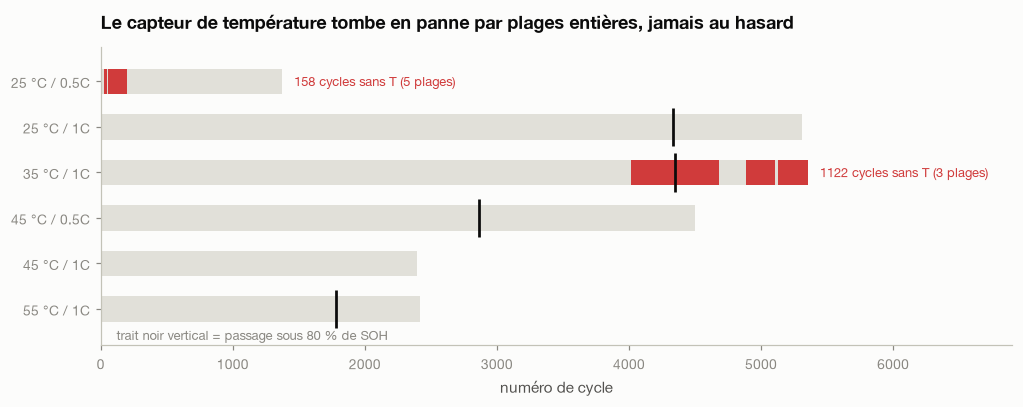

25 °C / 0.5C — couverture aux cycles 20 24 : ['c20=100.0%', 'c21=100.0%', 'c22=77.3%', 'c23=0.6%', 'c24=0.2%']
35 °C / 1C — couverture aux cycles 4015 4019 : ['c4015=100.0%', 'c4016=100.0%', 'c4017=11.9%', 'c4018=0.0%', 'c4019=0.0%']
25 °C / 0.5C : survie des points de T sur 22–196 = 9.48 % | sur 52–196 = 0.94 % (836 lignes sur 89214)
25 °C / 0.5C : couverture minimale après le cycle 197 = 99.7 % | SOH c22 = 101.5 % , SOH c196 = 98.4 %
35 °C / 1C   : plages sans T = [(4017, 4683), (4884, 5108), (5127, 5356)] | SOH au cycle 4017 = 81.6 %
35 °C / 1C   : cycles sous 85 % de SOH = 2204 dont sans température = 1122 (50.9 %)


In [22]:
# ===== CELL 4.1 : une seule passe d'agrégation par cycle, réutilisée par toute la section =====
S4_VMAX = 3.649
s4_cycle, s4_brut = {}, {}
for cid, _T, _C in CELLS:
    d = load_cell(cid, columns=["cycle_number", "step_type", "temperature_C",
                                "voltage_V", "current_A", "step_capacity_Ah", "absolute_time"])
    d["_over"] = d["voltage_V"] > S4_VMAX + 1e-9          # au-dessus de la consigne
    d["_big"]  = d["voltage_V"] > S4_VMAX + 0.002         # au-dessus de plus de 2 mV
    g = d.groupby("cycle_number").agg(
            n_rows=("voltage_V", "size"), n_T=("temperature_C", "count"),
            t_min=("temperature_C", "min"), t_med=("temperature_C", "median"),
            t_max=("temperature_C", "max"),
            v_max=("voltage_V", "max"), v_min=("voltage_V", "min"),
            n_over=("_over", "sum"), n_big=("_big", "sum"),
            date=("absolute_time", "min"), date_fin=("absolute_time", "max"))
    g["t_cov"] = g["n_T"] / g["n_rows"]
    g["pause_h"] = (g["date"] - g["date_fin"].shift(1)).dt.total_seconds() / 3600   # arrêt du banc avant le cycle
    s4_brut[cid] = {"V manquants": int(d["voltage_V"].isna().sum()),
                    "I manquants": int(d["current_A"].isna().sum()),
                    "|I| max au repos (A)": float(d.loc[d["step_type"] == "rest", "current_A"].abs().max())}
    g["i_at_vmax"] = d.loc[d.groupby("cycle_number")["voltage_V"].idxmax()].set_index("cycle_number")["current_A"]
    dis = d[d["step_type"] == "cc_discharge"]
    i_med = dis["current_A"].median()
    plat = dis[(dis["current_A"] - i_med).abs() < 0.10 * abs(i_med)]   # plateau CC uniquement
    g["i_dis"] = plat.groupby("cycle_number")["current_A"].median()
    g["q_dis"] = dis.groupby("cycle_number")["step_capacity_Ah"].max()
    s4_cycle[cid] = g
del d, g, dis, plat

def s4_runs(idx):
    """Regroupe une liste de numéros de cycle en plages contiguës [(début, fin), ...]."""
    a = np.sort(np.asarray(idx))
    if len(a) == 0: return []
    b = np.where(np.diff(a) > 1)[0]
    return list(zip(np.r_[a[0], a[b + 1]].tolist(), np.r_[a[b], a[-1]].tolist()))

def s4_soh(g, lisse=True):
    """SOH officiel ; lissé par médiane glissante de 9 cycles pour immuniser contre les
    cycles tronqués, qui font plonger la capacité d'un seul cycle (cf. notes de section)."""
    s = g["q_dis"] / NOMINAL_AH * 100
    return s.rolling(9, center=True, min_periods=3).median() if lisse else s

def s4_cross(g, seuil):
    s = s4_soh(g); m = s < seuil
    return int(s.index[m][0]) if m.any() else None

s4_manque_T = pd.DataFrame([{
    "cellule": label(cid),
    "cycles enregistrés": len(g), "n° max": int(g.index.max()),
    "T manquante (%)": round(100 * (1 - g["n_T"].sum() / g["n_rows"].sum()), 2),
    "cycles sans T (couv. < 50 %)": int((g["t_cov"] < 0.5).sum()),
    "plages": len(s4_runs(g.index[g["t_cov"] < 0.5])),
    "étendue de la panne": (lambda r: "—" if not r else f"{r[0][0]}–{r[-1][1]}")(s4_runs(g.index[g["t_cov"] < 0.5])),
    "SOH final (%)": round(float(s4_soh(g).dropna().iloc[-1]), 1),
    "cycle à SOH 80 %": s4_cross(g, 80) or "—",
} for cid, g in ((c[0], s4_cycle[c[0]]) for c in CELLS)])
display(s4_manque_T)

fig, ax = plt.subplots(figsize=(9.4, 3.8))
for k, (cid, _T, _C) in enumerate(CELLS):
    g = s4_cycle[cid]; y = len(CELLS) - 1 - k
    ax.broken_barh([(g.index.min(), g.index.max() - g.index.min())], (y - 0.28, 0.56), facecolors=GRID)
    trous = s4_runs(g.index[g["t_cov"] < 0.5])
    ax.broken_barh([(a, max(b - a, 6)) for a, b in trous], (y - 0.28, 0.56), facecolors=STATUS["critical"])
    c80 = s4_cross(g, 80)
    if c80: ax.plot([c80, c80], [y - 0.42, y + 0.42], color=INK, lw=1.8, solid_capstyle="butt")
    n_bad = int((g["t_cov"] < 0.5).sum())
    if n_bad:
        ax.annotate(f"{n_bad} cycles sans T ({len(trous)} plages)", (g.index.max() + 90, y),
                    va="center", fontsize=8.5, color=STATUS["critical"])
ax.set_yticks(range(len(CELLS))); ax.set_yticklabels([label(c[0]) for c in CELLS][::-1], fontsize=9)
ax.set_ylim(-0.8, len(CELLS) - 0.25); ax.set_xlim(0, 6900); ax.grid(False)
ax.annotate("trait noir vertical = passage sous 80 % de SOH", (120, -0.68), fontsize=8.5, color=MUTED)
finish(ax, "Le capteur de température tombe en panne par plages entières, jamais au hasard",
       "numéro de cycle", None, legend=False)
plt.tight_layout(); plt.show()

# preuve chiffrée des deux pannes
for cid, bornes in (("102Ah_25degC_0p5C_cell3", (20, 24)), ("102Ah_35degC_1C_cell1", (4015, 4019))):
    g = s4_cycle[cid]
    print(label(cid), "— couverture aux cycles", *bornes, ":",
          [f"c{c}={g.loc[c,'t_cov']*100:.1f}%" for c in range(bornes[0], bornes[1] + 1)])
gA = s4_cycle["102Ah_25degC_0p5C_cell3"]
print("25 °C / 0.5C : survie des points de T sur 22–196 =",
      f"{100*gA.loc[22:196,'n_T'].sum()/gA.loc[22:196,'n_rows'].sum():.2f} %",
      "| sur 52–196 =", f"{100*gA.loc[52:196,'n_T'].sum()/gA.loc[52:196,'n_rows'].sum():.2f} %",
      f"({int(gA.loc[52:196,'n_T'].sum())} lignes sur {int(gA.loc[52:196,'n_rows'].sum())})")
print("25 °C / 0.5C : couverture minimale après le cycle 197 =",
      f"{gA.loc[197:,'t_cov'].min()*100:.1f} %", "| SOH c22 =", round(float(s4_soh(gA, False).loc[22]), 1),
      "% , SOH c196 =", round(float(s4_soh(gA, False).loc[196]), 1), "%")
gB = s4_cycle["102Ah_35degC_1C_cell1"]
print("35 °C / 1C   : plages sans T =", s4_runs(gB.index[gB["t_cov"] < 0.5]),
      "| SOH au cycle 4017 =", round(float(s4_soh(gB).loc[4017]), 1), "%")
sous85 = gB.index[s4_soh(gB) < 85]; sansT = set(gB.index[gB["t_cov"] < 0.5])
print("35 °C / 1C   : cycles sous 85 % de SOH =", len(sous85), "dont sans température =",
      len(set(sous85) & sansT), f"({100*len(set(sous85) & sansT)/len(sous85):.1f} %)")

### 4.1 Les trous de température ne sont pas du bruit, ce sont deux pannes

Les 16,4 % et 19,8 % de température manquante ne sont **pas** répartis au hasard : ils se concentrent dans **deux pannes de capteur, chacune sur une plage continue de cycles**. Le reste du parc est propre (≤ 0,03 % de valeurs isolées).

**Panne A — 25 °C / 0.5C, cycles 22 à 196.** Le décrochage est brutal : couverture 100 % au cycle 21, **77,3 % au cycle 22, 0,6 % au cycle 23**. Sur toute la plage 22–196, 9,5 % des points survivent ; sur le cœur 52–196, il n'en reste que 0,94 % (836 lignes sur 89 214). Puis le capteur **redevient normal au cycle 197 et le reste jusqu'à la fin** : couverture ≥ 99,7 % sur 197–1375, un seul cycle en dessous de 100 %. C'est du début de vie : SOH 101,5 % au cycle 22, 98,4 % au cycle 196.

**Panne B — 35 °C / 1C, cycles 4017 à 5356.** Rupture nette : couverture 100 % au cycle 4016, **11,9 % au 4017, 0 % à partir du 4018**. Trois plages (4017–4683, 4884–5108, 5127–5356) avec deux brèves reprises, 1 122 cycles sans température. Cela représente **les 25 % finaux de la vie de la cellule** (21,0 % des cycles effectivement enregistrés) — et le SOH au cycle 4017 vaut déjà **81,6 %**. Autrement dit : **50,9 % des cycles de cette cellule situés sous 85 % de SOH n'ont aucune température.**

**Ce que ça implique.** La panne B est la plus grave : le 35 °C / 1C est la cellule qui va le plus loin (5 355 cycles enregistrés, numéro maximal 5 356) et qui documente le mieux la zone du knee-point, et c'est exactement là que la température disparaît. Un modèle qui prend la température *mesurée* en entrée ne pourra pas être évalué sur cette zone. Deux options seulement : (i) conditionner le modèle sur la température de **condition** (constante par cellule) plutôt que sur la mesure cycle par cycle, (ii) imputer — c'est faisable ici car la température y est un plateau très stable (voir 4.2), mais il faut le faire explicitement et le documenter.

La panne A a un effet plus sournois : elle touche le **début de vie** du 25 °C / 0.5C, c'est-à-dire précisément la fenêtre qu'utilise le **run « budget réduit »** (premiers cycles seulement). Un protocole « N premiers cycles » appliqué naïvement à cette cellule fournirait une feature température vide ou aberrante dès le cycle 22.

,cellule,consigne (°C),plancher T du cycle (°C),écart / consigne (°C),T médiane du cycle (°C),auto-échauffement intra-cycle (°C),T minimale absolue (°C),"dérive du plancher, 10 % début → 10 % fin (°C)"
0,25 °C / 0.5C,25,35.2,10.2,36.8,3.2,26.7,-0.2
1,25 °C / 1C,25,33.6,8.6,35.4,4.3,23.9,-6.6
2,35 °C / 1C,35,38.3,3.3,40.6,4.3,32.3,-2.5
3,45 °C / 0.5C,45,45.8,0.8,46.5,1.5,29.3,0.3
4,45 °C / 1C,45,46.5,1.5,49.7,4.9,37.7,-0.3
5,55 °C / 1C,55,57.1,2.1,58.9,3.5,40.3,1.0


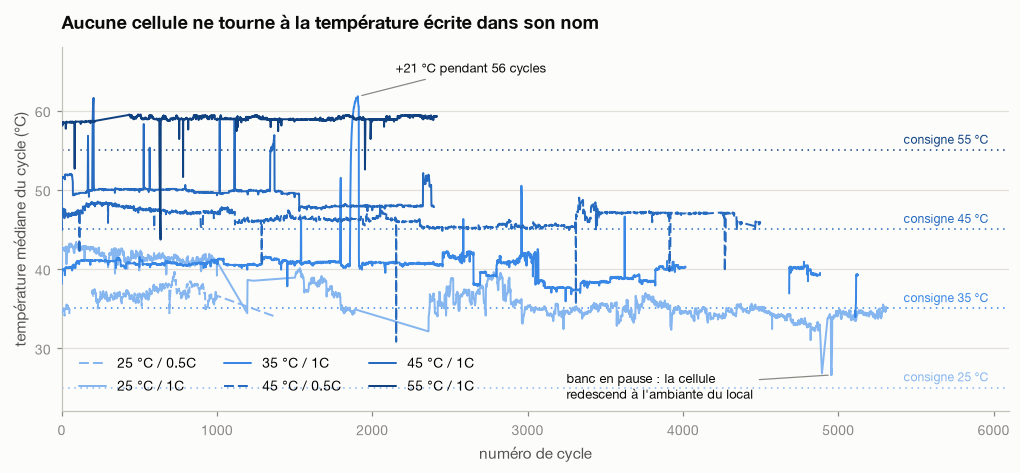

25 °C / 1C — plancher de température mensuel (mois d'au moins 100 cycles) :


,plancher,soh,n
date,,,
2021-05-01,38.6,99.3,214
2021-06-01,37.8,97.2,221
2021-07-01,37.6,95.8,235
2021-08-01,37.2,94.5,242
2021-11-01,37.6,91.5,101
2021-12-01,35.9,90.8,256
2022-03-01,34.2,88.3,122
2022-04-01,35.4,87.7,228
2022-05-01,36.2,86.8,216


In [23]:
# ===== CELL 4.3 : température mesurée contre température de consigne =====
s4_offset_T = pd.DataFrame([{
    "cellule": label(cid), "consigne (°C)": COND[cid][0],
    "plancher T du cycle (°C)": round(float(ok["t_min"].median()), 1),
    "écart / consigne (°C)": round(float(ok["t_min"].median() - COND[cid][0]), 1),
    "T médiane du cycle (°C)": round(float(ok["t_med"].median()), 1),
    "auto-échauffement intra-cycle (°C)": round(float((ok["t_max"] - ok["t_min"]).median()), 1),
    "T minimale absolue (°C)": round(float(ok["t_min"].min()), 1),
    "dérive du plancher, 10 % début → 10 % fin (°C)":
        round(float(ok["t_min"].iloc[-(len(ok)//10 or 1):].median() - ok["t_min"].iloc[:(len(ok)//10 or 1)].median()), 1),
} for cid, ok in ((c[0], s4_cycle[c[0]][s4_cycle[c[0]]["t_cov"] > 0.9]) for c in CELLS)])
display(s4_offset_T)

fig, ax = plt.subplots(figsize=(9.4, 4.4))
for T in sorted({c[1] for c in CELLS}):
    ax.axhline(T, color=TEMP_COLOR[T], lw=1.0, ls=(0, (1, 3)), zorder=1)
    ax.annotate(f"consigne {T} °C", (5420, T + 0.8), fontsize=8, color=TEMP_COLOR[T])
for cid, _T, _C in CELLS:
    g = s4_cycle[cid]
    tm = g["t_med"].where(g["t_cov"] > 0.5)          # on masque les cycles en panne de capteur
    ax.plot(g.index, tm, lw=1.3, label=label(cid), zorder=3, **style(cid))
ax.annotate("+21 °C pendant 56 cycles", (1913, 61.8), xytext=(2150, 64.8), fontsize=8.5, color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.annotate("banc en pause : la cellule\nredescend à l'ambiante du local", (4955, 26.6), xytext=(3250, 23.6),
            fontsize=8.5, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlim(0, 6100); ax.set_ylim(22, 68)
ax.legend(loc="lower left", bbox_to_anchor=(0.005, 0.015), ncol=3)
finish(ax, "Aucune cellule ne tourne à la température écrite dans son nom",
       "numéro de cycle", "température médiane du cycle (°C)", legend=False)
plt.tight_layout(); plt.show()

# la ligne de base dérive-t-elle ? plancher mensuel comparé au SOH, cellule 25 °C / 1C
cidD = "102Ah_25degC_1C_cell3"; gD = s4_cycle[cidD]
s4_mens = (gD.assign(soh=s4_soh(gD)).set_index("date")
             .resample("MS").agg(plancher=("t_min", "median"), soh=("soh", "median"), n=("t_min", "size")))
s4_mens = s4_mens[s4_mens["n"] >= 100].round(1)
print("25 °C / 1C — plancher de température mensuel (mois d'au moins 100 cycles) :")
display(s4_mens)

### 4.2 Le plan d'expérience annoncé n'est pas le plan d'expérience subi

C'est le résultat le plus lourd de conséquences de la section. **Aucune cellule ne tourne à sa température de consigne**, et l'écart n'est pas le même partout :

| consigne | plancher mesuré | écart | auto-échauffement intra-cycle |
|---|---|---|---|
| 25 °C / 0.5C | 35,2 °C | **+10,2** | 3,2 °C |
| 25 °C / 1C | 33,6 °C | **+8,6** | 4,3 °C |
| 35 °C / 1C | 38,3 °C | +3,3 | 4,3 °C |
| 45 °C / 0.5C | 45,8 °C | +0,8 | 1,5 °C |
| 45 °C / 1C | 46,5 °C | +1,5 | 4,9 °C |
| 55 °C / 1C | 57,1 °C | +2,1 | 3,5 °C |

Le « plancher » est la médiane du minimum de chaque cycle, c'est-à-dire la fin du repos de 30 min — le point le plus proche de l'ambiante. Ce n'est donc pas un effet d'auto-échauffement : celui-ci ne vaut que 1,5 à 4,9 °C d'amplitude intra-cycle. Sur la cellule 25 °C / 0.5C, **la valeur minimale de tout l'enregistrement est 26,7 °C** : la cellule n'a jamais vu 25 °C.

L'écart décroît quand la consigne monte (+10 à 25 °C, +3 à 35 °C, +1 à 45 °C, +2 à 55 °C). C'est **compatible** avec une enceinte qui ne sait que chauffer : elle ne pourrait pas descendre sous l'ambiante du local augmentée de la dissipation des cellules. Les données ne permettent cependant pas de distinguer cette explication d'un simple biais de sonde ou d'un mauvais placement du capteur — ce qui compte pour la modélisation est le fait, pas sa cause.

**Conséquence directe sur la modélisation.** En température *mesurée*, le plan d'expérience n'est pas 25/35/45/55 mais **33,6 / 35,2 / 38,3 / 45,8 / 46,5 / 57,1 °C**. Les deux conditions « 25 °C » et la condition « 35 °C » sont quasiment confondues (4,7 °C d'écart total au lieu de 10). L'amplitude réelle sur l'axe température est de 23,5 °C, pas 30 °C, et le bras de levier pour identifier une énergie d'activation d'Arrhenius est plus faible qu'annoncé. Caler un modèle sur `T_nominale` puis extrapoler à une condition inconnue à 25 °C, c'est extrapoler avec un décalage de ~10 °C : pour une énergie d'activation typique de 50 kJ/mol, cela change la vitesse de vieillissement d'un facteur ≈ 1,9.

**Deuxième piège : la ligne de base dérive.** Le plancher de la cellule 25 °C / 1C perd **6,6 °C** entre le début et la fin de sa vie (mesure 10 % début → 10 % fin) : le plancher mensuel passe de 38,6 °C en mai 2021 à 31,1 °C en janvier 2023. Ce n'est pas un simple effet de la perte de capacité (des cycles plus courts chauffent moins) : le plancher **remonte** de 34,2 °C en mars 2022 à 36,2 °C en mai 2022 alors que le SOH y est *plus bas* (86,8 % contre 88,3 %) ; et la cellule 45 °C / 0.5C, qui perd 44 points de SOH (102,9 → 58,7 %), ne dérive que de +0,3 °C. La température de vieillissement de cette cellule est donc une **fonction du temps**, pas une constante — un modèle à température constante par cellule est déjà une approximation. La cause de la dérive reste inconnue (voir notes).

,cellule,type,cycles,durée (cycles),T médiane extrême (°C),écart à la base (°C),durée (j),pause de banc avant (h)
0,25 °C / 1C,refroidissement,1195–1195,1,34.4,5.4,0.0,569.1
1,25 °C / 1C,refroidissement,4895–4895,1,26.8,6.7,0.0,883.3
2,25 °C / 1C,refroidissement,4954–4958,5,26.6,7.2,0.7,0.0
3,35 °C / 1C,surchauffe,1541–1542,2,46.4,5.6,0.1,0.0
4,35 °C / 1C,surchauffe,1794–1797,4,51.5,10.6,0.4,0.0
5,35 °C / 1C,surchauffe,1858–1913,56,61.8,21.0,6.6,0.0
6,35 °C / 1C,surchauffe,2959–2963,5,50.5,9.6,0.5,0.0
7,35 °C / 1C,surchauffe,3625–3625,1,46.6,7.8,0.0,0.0
8,35 °C / 1C,refroidissement,5109–5111,3,33.9,5.9,0.6,0.7
9,45 °C / 0.5C,refroidissement,114–116,3,42.0,5.6,0.4,0.0


27 épisodes, 139 cycles au total (seuil ±5 °C autour d'une médiane glissante de 301 cycles)


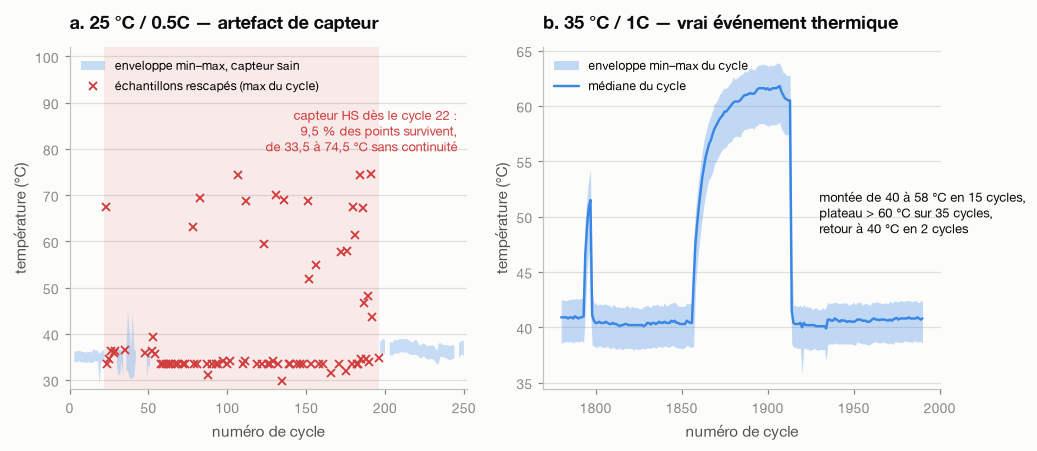

cycles 52–196 gardant au moins un point : 69 | dont un seul point : 35 | une seule valeur répétée : 40
valeur présente dans le plus de cycles : 33.5 °C sur 57 de ces cycles ; suivante : 34.2 °C sur 7
valeurs erratiques > 60 °C : [np.float64(61.4), np.float64(63.2), np.float64(67.2), np.float64(67.5), np.float64(68.7), np.float64(68.8), np.float64(68.9), np.float64(69.3), np.float64(70.1), np.float64(74.4), np.float64(74.5)]
nombre de points survivants sur les cycles qui les portent : [np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]
refroidissements précédés d'une pause de banc > 1 h : 3 sur 14 — pauses concernées (h) : [883.0, 569.0, 6.0]


In [24]:
# ===== CELL 4.5 : détection des cycles conduits hors consigne =====
S4_SEUIL, S4_FEN = 5.0, 301
s4_anom = []
for cid, T, C in CELLS:
    g = s4_cycle[cid]
    ok = g[g["t_cov"] > 0.9]
    base = ok["t_med"].rolling(S4_FEN, center=True, min_periods=60).median()   # ligne de base LOCALE
    ecart = ok["t_med"] - base                                                 # (la base dérive, cf. 4.2)
    for sens, nom in ((1, "surchauffe"), (-1, "refroidissement")):
        sel = ok.index[(ecart > S4_SEUIL) if sens > 0 else (ecart < -S4_SEUIL)]
        for a, b in s4_runs(sel):
            w = ok.loc[a:b, "t_med"]
            s4_anom.append({"cellule": label(cid), "type": nom, "cycles": f"{a}–{b}",
                            "durée (cycles)": int(b - a + 1),
                            "T médiane extrême (°C)": round(float(w.max() if sens > 0 else w.min()), 1),
                            "écart à la base (°C)": round(float(ecart.loc[a:b].abs().max()), 1),
                            "durée (j)": round((g.loc[b, "date"] - g.loc[a, "date"]).total_seconds() / 86400, 1),
                            "pause de banc avant (h)": round(float(g.loc[a, "pause_h"]), 1),
                            "_c": a})
s4_anom = pd.DataFrame(s4_anom).sort_values(["cellule", "_c"]).drop(columns="_c").reset_index(drop=True)
display(s4_anom)
print(f"{len(s4_anom)} épisodes, {int(s4_anom['durée (cycles)'].sum())} cycles au total "
      f"(seuil ±{S4_SEUIL:g} °C autour d'une médiane glissante de {S4_FEN} cycles)")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.2))
cid = "102Ah_25degC_0p5C_cell3"
g = s4_cycle[cid].reindex(range(1, 251))          # reindex : les cycles absents restent des trous
ax = axes[0]
ax.axvspan(22, 196, color=STATUS["critical"], alpha=0.09, lw=0)
sain = g["t_cov"] > 0.5
ax.fill_between(g.index, g["t_min"].where(sain), g["t_max"].where(sain), color=TEMP_COLOR[25],
                alpha=0.45, lw=0, label="enveloppe min–max, capteur sain")
ko = g[(~sain) & g["t_max"].notna()]
ax.plot(ko.index, ko["t_max"], ls="none", marker="x", ms=5, mew=1.2, color=STATUS["critical"],
        label="échantillons rescapés (max du cycle)")
ax.set_ylim(28, 102); ax.set_xlim(0, 252)
ax.annotate("capteur HS dès le cycle 22 :\n9,5 % des points survivent,\nde 33,5 à 74,5 °C sans continuité",
            (246, 89), ha="right", va="top", fontsize=8.5, color=STATUS["critical"])
finish(ax, "a. 25 °C / 0.5C — artefact de capteur", "numéro de cycle", "température (°C)", legend=False)
ax.legend(loc="upper left", ncol=1, fontsize=8)

cid = "102Ah_35degC_1C_cell1"; g = s4_cycle[cid].reindex(range(1780, 1991)); ax = axes[1]
ax.fill_between(g.index, g["t_min"], g["t_max"], color=TEMP_COLOR[35], alpha=0.30, lw=0,
                label="enveloppe min–max du cycle")
ax.plot(g.index, g["t_med"], lw=1.6, label="médiane du cycle", **style(cid))
ax.annotate("montée de 40 à 58 °C en 15 cycles,\nplateau > 60 °C sur 35 cycles,\nretour à 40 °C en 2 cycles",
            (1930, 48.5), fontsize=8.5, color=INK)
finish(ax, "b. 35 °C / 1C — vrai événement thermique", "numéro de cycle", "température (°C)", legend=False)
ax.legend(loc="upper left", ncol=1, fontsize=8)
plt.tight_layout(); plt.show()

# de quoi sont faits les points rescapés pendant la panne A ?
_d = load_cell("102Ah_25degC_0p5C_cell3", columns=["cycle_number", "temperature_C"])
_r = _d[_d["cycle_number"].between(52, 196) & _d["temperature_C"].notna()]
_par_cycle = _r.groupby("cycle_number")["temperature_C"].agg(["size", "nunique"])
print("cycles 52–196 gardant au moins un point :", len(_par_cycle),
      "| dont un seul point :", int((_par_cycle["size"] == 1).sum()),
      "| une seule valeur répétée :", int((_par_cycle["nunique"] == 1).sum()))
_freq = _r.groupby("temperature_C")["cycle_number"].nunique().sort_values(ascending=False)
print("valeur présente dans le plus de cycles :", float(_freq.index[0]), "°C sur", int(_freq.iloc[0]),
      "de ces cycles ; suivante :", float(_freq.index[1]), "°C sur", int(_freq.iloc[1]))
print("valeurs erratiques > 60 °C :", sorted(_r.loc[_r["temperature_C"] > 60, "temperature_C"].unique()))
print("nombre de points survivants sur les cycles qui les portent :",
      sorted(_par_cycle.loc[_r.loc[_r["temperature_C"] > 60, "cycle_number"].unique(), "size"].unique()))
del _d, _r, _par_cycle, _freq

# les refroidissements sont-ils simplement des cycles qui suivent un arrêt du banc ?
_fr = s4_anom[s4_anom["type"] == "refroidissement"]
print("refroidissements précédés d'une pause de banc > 1 h :", int((_fr["pause de banc avant (h)"] > 1).sum()),
      "sur", len(_fr), "— pauses concernées (h) :",
      sorted(_fr.loc[_fr["pause de banc avant (h)"] > 1, "pause de banc avant (h)"].round().tolist(), reverse=True))
del _fr

### 4.3 Les 74 °C sont un artefact, les 62 °C sont réels

La question posée était : ces excursions sont-elles des valeurs aberrantes isolées ou de vrais événements thermiques ? **Les deux, et la distinction se lit à l'œil nu.**

**Le maximum de 74,5 °C sur la cellule 25 °C / 0.5C est un artefact de capteur** (panneau a). Ces valeurs n'existent que *pendant* la panne A. Sur les cycles 52–196, seuls 69 cycles gardent au moins un échantillon ; 40 d'entre eux ne contiennent qu'**une seule valeur répétée**, et cette valeur est **33,5 °C dans 57 des 69 cycles** — un capteur figé. Les valeurs hautes (61,4 / 63,2 / 67,2 / 67,5 / 68,7 / 68,8 / 68,9 / 69,3 / 70,1 / 74,4 / 74,5 °C) apparaissent sur des cycles qui ne conservent que **2 à 7 échantillons sur ~615**, sans aucune continuité avec leurs voisins. Signature classique d'un contact intermittent. **Le maximum de 74,5 °C de cette cellule doit être purement et simplement supprimé** — et avec lui les 158 cycles de la plage.

**Le maximum de 63,9 °C sur la cellule 35 °C / 1C est un vrai événement** (panneau b, cycle 1906) : couverture 100 %, montée monotone de la médiane du cycle de 40,4 à 58,5 °C en 15 cycles puis dérive lente jusqu'à 61,8 °C, plateau au-dessus de 60 °C sur 35 cycles, retour à 40 °C en 2 cycles. Durée 6,6 jours (1–7 janvier 2022). Aucun capteur ne fabrique une rampe pareille : c'est l'enceinte qui est partie en surchauffe. Même chose sur la 45 °C / 1C : de 49,9 °C au cycle 197 à 61,6 °C au cycle 206, retour à 50,0 °C dès le cycle 208.

Le détecteur ci-dessus (écart > ±5 °C par rapport à une médiane glissante de 301 cycles) trouve **27 épisodes, 139 cycles au total**, de deux natures :

- **surchauffes** (13 épisodes) — la 35 °C / 1C en compte 5 (dont l'épisode majeur 1858–1913 à +21 °C) et la 45 °C / 1C en compte 8 (jusqu'à +11,6 °C, dont une plage de 24 cycles à +7,1 °C) ;
- **refroidissements** (14 épisodes) — la 55 °C / 1C descend à 43,7 °C sur les cycles 633–637, la 45 °C / 0.5C à 30,8 °C au cycle 2154, la 25 °C / 1C à 26,6 °C aux cycles 4954–4958.

**Attention à une explication trop facile.** On serait tenté d'attribuer tous les creux aux longues interruptions de banc vues en section 2. C'est faux : **seuls 3 des 14 refroidissements suivent une pause de plus d'une heure** (883 h, 569 h et 6 h, toutes sur la 25 °C / 1C). Les 11 autres — dont les six de la 45 °C / 0.5C et l'épisode 4954–4958 — surviennent en **cyclage continu, sans aucune interruption**. Ce ne sont donc pas des cellules au repos qui refroidissent, ce sont des cellules **cyclées à la mauvaise température**, ce qui est nettement plus gênant.

**Ce que ça implique.** Ces 139 cycles ne sont pas des points de mesure bruités : ce sont des cycles **conduits dans une autre condition d'essai que celle annoncée**. Ils doivent être marqués — et exclus de toute détection de knee-point. Les deux creux qui suivent réellement une longue pause portent en plus une information de **vieillissement calendaire** (886 h et 569 h à l'arrêt) qu'il vaut mieux récupérer que masquer.

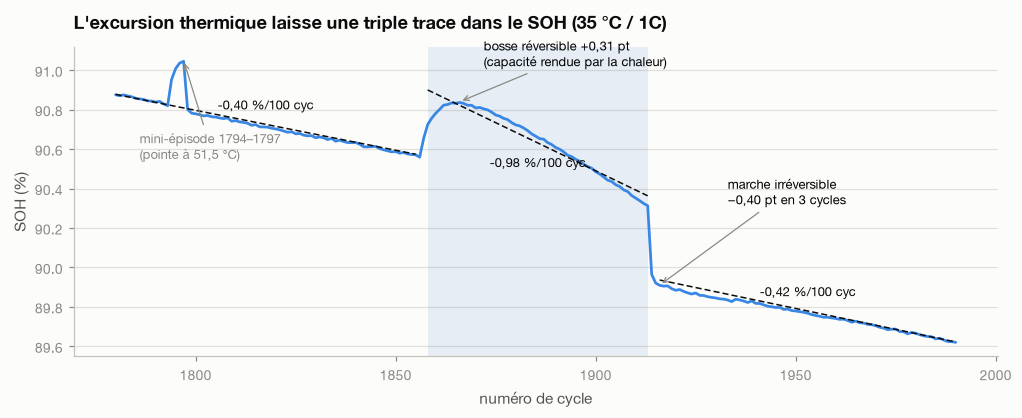

pentes (%/100 cycles) : {'1700–1855': np.float64(-0.405), '1858–1913': np.float64(-0.976), '1916–2100': np.float64(-0.424)}
bosse réversible = +0.31 pt au sommet (cycle 1866) | marche au retour = −0.40 pt (1913→1916)
perte réelle 1855→1916 = 0.66 pt contre 0.25 pt attendus au rythme d'avant, soit 0.42 pt de perte supplémentaire


In [25]:
# ===== CELL 4.7 : trace de l'excursion thermique dans le SOH =====
cid = "102Ah_35degC_1C_cell1"; s4_soh35 = s4_soh(s4_cycle[cid], lisse=False)
s4_pentes, s4_droites = {}, {}
for a, b in [(1700, 1855), (1858, 1913), (1916, 2100)]:
    x = s4_soh35.loc[a:b].dropna(); p = np.polyfit(x.index, x.values, 1)
    s4_pentes[f"{a}–{b}"] = round(p[0] * 100, 3); s4_droites[a] = p
s4_bosse  = float(max(s4_soh35.loc[1858:1875] - np.polyval(s4_droites[1700], s4_soh35.loc[1858:1875].index)))
s4_marche = float(s4_soh35.loc[1913] - s4_soh35.loc[1916])
s4_perte  = float(s4_soh35.loc[1855] - s4_soh35.loc[1916])
s4_attendu = -s4_pentes["1700–1855"] / 100 * (1916 - 1855)

fig, ax = plt.subplots(figsize=(9.4, 3.9))
w = s4_soh35.loc[1780:1990]
ax.axvspan(1858, 1913, color=TEMP_COLOR[45], alpha=0.10, lw=0)
ax.plot(w.index, w.values, lw=1.8, **style(cid))
for a, b in [(1700, 1855), (1858, 1913), (1916, 2100)]:
    xs = np.array([max(a, 1780), min(b, 1990)]); p = s4_droites[a]
    ax.plot(xs, np.polyval(p, xs), color=INK, lw=1.0, ls=(0, (4, 2)))
    dy, va = (-0.06, "top") if a == 1858 else (0.06, "bottom")
    ax.annotate(f"{p[0]*100:+.2f} %/100 cyc".replace(".", ","), (xs.mean(), np.polyval(p, xs.mean()) + dy),
                fontsize=8.5, color=INK, ha="center", va=va)
ax.annotate(f"bosse réversible +{s4_bosse:.2f} pt\n(capacité rendue par la chaleur)".replace(".", ","),
            (1866, 90.84), xytext=(1872, 91.02), fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8))
ax.annotate(f"marche irréversible\n−{s4_marche:.2f} pt en 3 cycles".replace(".", ","), (1916, 89.91),
            xytext=(1933, 90.32), fontsize=8.5, arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8))
ax.annotate("mini-épisode 1794–1797\n(pointe à 51,5 °C)", (1797, 91.05), xytext=(1786, 90.55), fontsize=8.5,
            color=MUTED, arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8))
finish(ax, "L'excursion thermique laisse une triple trace dans le SOH (35 °C / 1C)",
       "numéro de cycle", "SOH (%)", legend=False)
plt.tight_layout(); plt.show()
print("pentes (%/100 cycles) :", s4_pentes)
print(f"bosse réversible = +{s4_bosse:.2f} pt au sommet (cycle 1866) | marche au retour = −{s4_marche:.2f} pt (1913→1916)")
print(f"perte réelle 1855→1916 = {s4_perte:.2f} pt contre {s4_attendu:.2f} pt attendus au rythme d'avant, "
      f"soit {s4_perte - s4_attendu:.2f} pt de perte supplémentaire")

### 4.4 Pourquoi ces 56 cycles comptent : ils déforment la courbe cible

On pourrait considérer une excursion thermique de 56 cycles sur 5 355 comme un détail. Elle ne l'est pas, parce qu'elle laisse une **triple signature dans la variable qu'on doit prédire** :

1. **Une bosse réversible de +0,31 point** au sommet (cycle 1866), mesurée par rapport à la tendance des 155 cycles qui précèdent. La cellule chaude rend plus de capacité (moins de résistance, meilleure cinétique) : c'est de la capacité *empruntée*, pas de la santé retrouvée. Le SOH remonte alors que la cellule vieillit.
2. **Une pente 2,4× plus raide pendant l'épisode** : −0,98 %/100 cycles contre −0,40 avant et −0,42 après. Sur les 61 cycles 1855→1916 la cellule perd **0,66 point** au lieu des 0,25 point attendus au rythme normal — soit **0,42 point de perte irréversible supplémentaire** offerts par 6,6 jours au-dessus de 60 °C.
3. **Une marche descendante de −0,40 point en 3 cycles** au retour à 40 °C (1913 → 1916) : la capacité empruntée est rendue, et la marche révèle la perte accumulée.

On retrouve la même signature en miniature au mini-épisode 1794–1797 (pointe à 51,5 °C, bosse de +0,23 point au-dessus de la tendance, visible sur le graphique). Sur la cellule 45 °C / 1C aux cycles 199–206 la signature existe aussi mais est bien plus faible (bosse de l'ordre de 0,03 point, marche de 0,09 point) : l'effet croît avec l'amplitude et la durée de l'excursion, ce que deux épisodes ne suffisent évidemment pas à quantifier.

**Ce que ça implique.** Un détecteur de knee-point qui cherche un changement de courbure trouvera ici un **faux positif franc** : bosse, changement de pente, marche — tous les ingrédients d'un knee, ~2 450 cycles avant le passage sous 80 % de SOH. Et un modèle lisse (Arrhenius + loi puissance, GP, réseau) ne peut structurellement pas reproduire une marche : il l'absorbera comme du bruit et biaisera ses paramètres. Trois traitements possibles, par ordre de préférence : (i) exclure les cycles marqués de l'ajustement et interpoler la cible ; (ii) modéliser explicitement le stress thermique cumulé (∫ exp(−Ea/RT) dt) au lieu du seul numéro de cycle — l'événement devient alors une information au lieu d'un défaut ; (iii) laisser tel quel et perdre en précision sur cette cellule. L'option (ii) est aussi celle qui donne le plus de valeur au pré-entraînement sur datasets publics, où ce genre d'incident est fréquent.

,cellule,V max (V),V min (V),"points > 3,649 V par cycle (médiane)",dépassement médian du cycle (mV),cycles avec un point > +2 mV (%),un seul point concerné (% de ces cycles),dépassement max (mV),I à ce point (A),"sous-passage max sous 2,5 V (mV)"
0,25 °C / 0.5C,3.6514,2.4990,7,0.2,0.3,100.0,2.4,46.7,1.0
1,25 °C / 1C,3.6514,2.4987,0,-0.1,0.0,100.0,2.4,99.6,1.3
2,35 °C / 1C,3.6613,2.4984,12,1.4,11.7,100.0,12.3,100.0,1.6
3,45 °C / 0.5C,3.6538,2.4990,6,1.1,3.5,83.3,4.8,49.4,1.0
4,45 °C / 1C,3.6715,2.4981,7,1.7,10.9,100.0,22.5,100.0,1.9
5,55 °C / 1C,3.6545,2.4996,5,0.5,2.7,100.0,5.5,99.5,0.4


valeurs manquantes et courant au repos, par cellule :


,V manquants,I manquants,|I| max au repos (A)
25 °C / 0.5C,0.0,0.0,0.0
25 °C / 1C,0.0,0.0,0.0
35 °C / 1C,0.0,0.0,0.0
45 °C / 0.5C,0.0,0.0,0.0
45 °C / 1C,0.0,0.0,0.0
55 °C / 1C,0.0,0.0,0.0


45 °C / 1C : saut de tension sur le pas de 30 s qui franchit 3,649 V — médiane 75 mV, p90 115 mV ; au cycle 11 : +160 mV, courant au point le plus haut = 100.0 A


55 °C / 1C : saut de tension sur le pas de 30 s qui franchit 3,649 V — médiane 95 mV, p90 134 mV ; au cycle 11 : +45 mV, courant au point le plus haut = 16.9 A


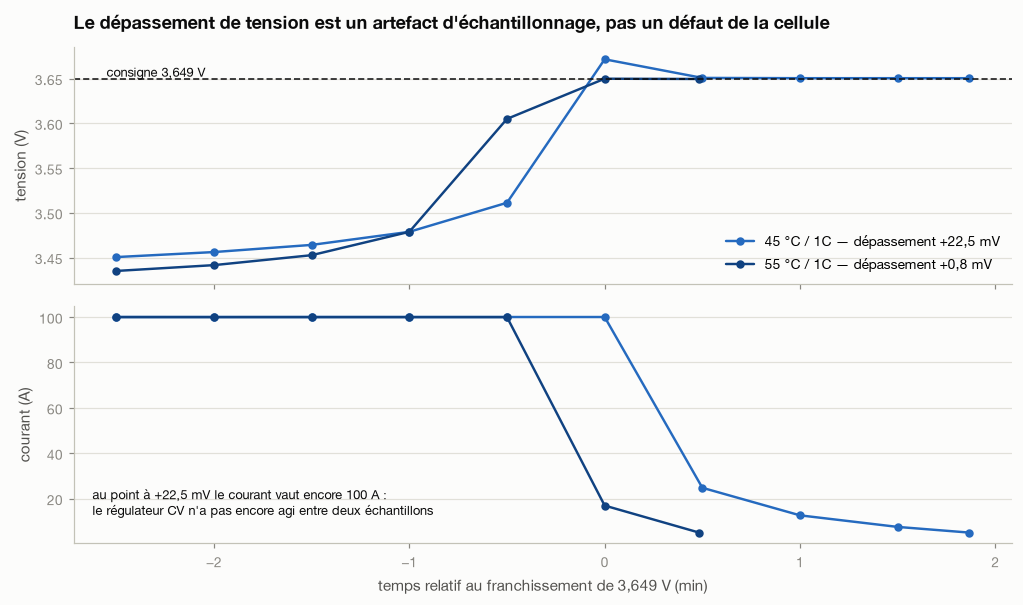

pas de quantification de la tension (mV) : {'45 °C / 1C': 0.3, '55 °C / 1C': 0.3}


In [26]:
# ===== CELL 4.9 : tension =====
s4_tension = pd.DataFrame([{
    "cellule": label(cid),
    "V max (V)": round(float(g["v_max"].max()), 4), "V min (V)": round(float(g["v_min"].min()), 4),
    "points > 3,649 V par cycle (médiane)": int(g["n_over"].median()),
    "dépassement médian du cycle (mV)": round(float(((g["v_max"] - S4_VMAX) * 1000).median()), 1),
    "cycles avec un point > +2 mV (%)": round(100 * float((g["n_big"] > 0).mean()), 1),
    "un seul point concerné (% de ces cycles)":
        round(100 * float((g.loc[g["n_big"] > 0, "n_big"] == 1).mean()), 1) if (g["n_big"] > 0).any() else float("nan"),
    "dépassement max (mV)": round(float(((g["v_max"] - S4_VMAX) * 1000).max()), 1),
    "I à ce point (A)": round(float(g.loc[(g["v_max"]).idxmax(), "i_at_vmax"]), 1),
    "sous-passage max sous 2,5 V (mV)": round(float((2.5 - g["v_min"].min()) * 1000), 1),
} for cid, g in ((c[0], s4_cycle[c[0]]) for c in CELLS)])
display(s4_tension)
print("valeurs manquantes et courant au repos, par cellule :")
display(pd.DataFrame(s4_brut).T.rename(index=lambda c: label(c)))

fig, axes = plt.subplots(2, 1, figsize=(9.4, 5.6), sharex=True)
s4_pas_v = {}
for cid in ["102Ah_45degC_1C_cell1", "102Ah_55degC_1C_cell3"]:
    d = load_cell(cid, columns=["cycle_number", "step_type", "voltage_V", "current_A", "t_s"])
    s4_pas_v[label(cid)] = round(float(np.diff(np.sort(d["voltage_V"].unique())).min() * 1000), 2)
    c = d[(d["cycle_number"] == 11) & (d["step_type"].isin(["cccv_charge", "cc_charge"]))].copy()
    k = int(np.argmax(c["voltage_V"].values >= S4_VMAX))
    c["dt"] = (c["t_s"] - c["t_s"].values[k]) / 60
    m = c["dt"].between(-2.6, 2.6)
    lab = f"{label(cid)} — dépassement {(c['voltage_V'].max()-S4_VMAX)*1000:+.1f} mV".replace(".", ",")
    axes[0].plot(c.loc[m, "dt"], c.loc[m, "voltage_V"], marker="o", ms=4.5, lw=1.6, label=lab, **style(cid))
    axes[1].plot(c.loc[m, "dt"], c.loc[m, "current_A"], marker="o", ms=4.5, lw=1.6, **style(cid))
    ch = d[d["step_type"].isin(["cccv_charge", "cc_charge"])].reset_index(drop=True)
    dv = ch["voltage_V"].diff().where(ch["cycle_number"].eq(ch["cycle_number"].shift()))
    saut = dv[ch.index[ch["voltage_V"] >= S4_VMAX].to_series().groupby(ch["cycle_number"]).first()]
    print(f"{label(cid)} : saut de tension sur le pas de 30 s qui franchit 3,649 V — "
          f"médiane {saut.median()*1000:.0f} mV, p90 {saut.quantile(.9)*1000:.0f} mV ; "
          f"au cycle 11 : {(c['voltage_V'].values[k] - c['voltage_V'].values[k-1])*1000:+.0f} mV, "
          f"courant au point le plus haut = {c.loc[c['voltage_V'].idxmax(), 'current_A']:.1f} A")
axes[0].axhline(S4_VMAX, color=INK, lw=1.0, ls=(0, (4, 2)))
axes[0].annotate("consigne 3,649 V", (-2.55, S4_VMAX + 0.003), fontsize=8.5, color=INK)
axes[0].set_ylim(3.42, 3.685)
finish(axes[0], "Le dépassement de tension est un artefact d'échantillonnage, pas un défaut de la cellule",
       None, "tension (V)", legend=False)
axes[0].legend(loc="lower right", ncol=1)
finish(axes[1], None, "temps relatif au franchissement de 3,649 V (min)", "courant (A)", legend=False)
axes[1].annotate("au point à +22,5 mV le courant vaut encore 100 A :\nle régulateur CV n'a pas encore agi entre deux échantillons",
                 (0.02, 0.12), xycoords="axes fraction", fontsize=8.5, color=INK)
plt.tight_layout(); plt.show()
print("pas de quantification de la tension (mV) :", s4_pas_v)
del d, c, ch, dv, saut

### 4.5 Tension : la fenêtre est respectée, sauf un point par cycle dû à la période d'échantillonnage

Le dépassement maximal observé est de **3,6715 V** (45 °C / 1C), soit **+22,5 mV** au-dessus de la consigne de 3,649 V. Il faut vérifier si c'est un vrai dépassement de la fenêtre d'essai — ce qui invaliderait le protocole — ou un artefact.

Il faut d'abord séparer **deux populations très différentes** de points « au-dessus de la consigne » :

- **Le bruit de régulation CV.** 5 à 12 points par cycle dépassent 3,649 V, mais de moins de 2 mV. Le pas de quantification du convertisseur est de 0,3 mV, et le dépassement médian par cycle vaut **−0,1 à +1,7 mV** selon la cellule. C'est le fonctionnement normal d'un régulateur : rien à corriger.
- **Le point de bascule CC→CV.** C'est lui l'artefact. Il concerne **0,0 à 11,7 % des cycles** selon la cellule et, quand il existe, c'est **un seul point du cycle** (100 % des cas sur cinq cellules, 83 % sur la 45 °C / 0.5C).

Le mécanisme se lit sur le graphique : **au point le plus haut de chaque cellule, le courant vaut encore la pleine valeur CC** (100,0 / 100,0 / 99,6 / 99,5 A sur les quatre cellules 1C ; 46,7 et 49,4 A sur les deux cellules 0,5C). En fin de phase CC la tension monte vite — le pas de 30 s qui franchit 3,649 V vaut en médiane **75 mV** sur la 45 °C / 1C et **95 mV** sur la 55 °C / 1C — et l'enregistrement tombe entre le moment où la cellule franchit la consigne et le moment où le régulateur CV réduit le courant. Le point enregistré est donc pris *avant* la régulation.

L'ampleur du dépassement dépend du hasard de la phase d'échantillonnage, pas du C-rate : au **même cycle 11 et au même 1C**, la 45 °C dépasse de +22,5 mV (courant encore à 100,0 A) alors que la 55 °C ne dépasse que de +0,8 mV (son échantillon tombe après la régulation, courant déjà à 16,9 A). De même le dépassement max vaut 22,5 mV à 1C sur la 45 °C mais seulement 2,4 mV à 1C sur la 25 °C.

Côté bas, la borne 2,5 V n'est jamais franchie de plus de **1,9 mV** (minimum absolu 2,4981 V, soit le pas de quantification à quelques unités près).

**Ce que ça implique.** La tension est le signal **le plus fiable des trois** : **zéro valeur manquante** sur les six cellules, aucune dérive, aucune valeur physiquement impossible. Elle porte donc l'essentiel des features de diagnostic (IC/DV, durée de la phase CV, tension en fin de CC, résistance apparente au front de courant). Un seul nettoyage à faire, et il est simple : **écarter, par cycle, l'unique point où V > 3,651 V alors que le courant est encore au niveau CC.** Ce point est vénéneux pour deux raisons : il fausse le max de tension utilisé comme feature, et il crée un pic dV artificiel qui pollue les courbes IC/DV exactement à la frontière CC/CV. Attention aussi : la borne haute est **3,649 V et non 3,65 V** — ce demi-millivolt suffit à décaler un critère de segmentation de step écrit à la main.

,cellule,C-rate annoncé,I nominal = C × 102 (A),I mesuré médian (A),écart / nominal (%),I p1–p99 (A),dérive 50 prem. → 50 dern. (A),C-rate réel (I / 102 Ah),C effectif début,C effectif fin,hausse du C effectif (%)
0,25 °C / 0.5C,0.5,51.0,50.025,-1.91,49.994–50.025,0.025,0.4904,0.480,0.527,10
1,25 °C / 1C,1.0,102.0,100.000,-1.96,99.988–100.025,-0.012,0.9804,0.956,1.479,55
2,35 °C / 1C,1.0,102.0,99.988,-1.97,99.963–100.025,-0.007,0.9803,0.958,1.350,41
3,45 °C / 0.5C,0.5,51.0,49.996,-1.97,49.987–50.009,-0.011,0.4902,0.481,0.835,73
4,45 °C / 1C,1.0,102.0,100.025,-1.94,100.006–100.062,0.031,0.9806,0.962,1.157,20
5,55 °C / 1C,1.0,102.0,99.969,-1.99,99.963–99.988,-0.019,0.9801,0.964,1.491,55


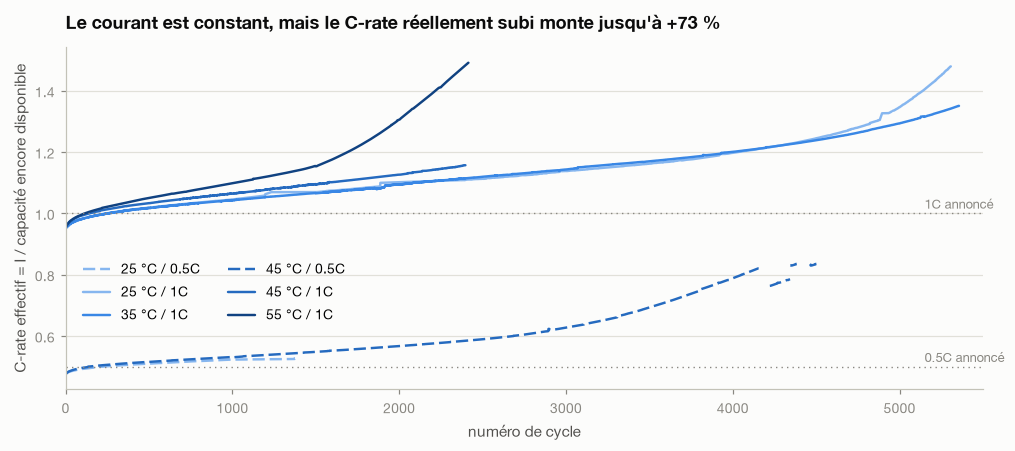

In [27]:
# ===== CELL 4.11 : courant =====
s4_ceff = {}
for cid, _T, _C in CELLS:
    g = s4_cycle[cid]
    q = g["q_dis"].rolling(9, center=True, min_periods=3).median()   # capacité lissée
    s4_ceff[cid] = (g["i_dis"].abs() / q).where(q > 40)
s4_courant = pd.DataFrame([{
    "cellule": label(cid), "C-rate annoncé": COND[cid][1],
    "I nominal = C × 102 (A)": COND[cid][1] * NOMINAL_AH,
    "I mesuré médian (A)": round(float(g["i_dis"].abs().median()), 3),
    "écart / nominal (%)": round(100 * float(g["i_dis"].abs().median() - COND[cid][1] * NOMINAL_AH) / (COND[cid][1] * NOMINAL_AH), 2),
    "I p1–p99 (A)": f"{g['i_dis'].abs().quantile(.01):.3f}–{g['i_dis'].abs().quantile(.99):.3f}",
    "dérive 50 prem. → 50 dern. (A)": round(float(g["i_dis"].abs().iloc[-50:].median() - g["i_dis"].abs().iloc[:50].median()), 3),
    "C-rate réel (I / 102 Ah)": round(float(g["i_dis"].abs().median() / NOMINAL_AH), 4),
    "C effectif début": round(float(s4_ceff[cid].dropna().iloc[:20].median()), 3),
    "C effectif fin": round(float(s4_ceff[cid].dropna().iloc[-1]), 3),
    "hausse du C effectif (%)": round(100 * (float(s4_ceff[cid].dropna().iloc[-1]) / float(s4_ceff[cid].dropna().iloc[:20].median()) - 1)),
} for cid, g in ((c[0], s4_cycle[c[0]]) for c in CELLS)])
display(s4_courant)

fig, ax = plt.subplots(figsize=(9.4, 4.2))
for cid, _T, _C in CELLS:
    ax.plot(s4_ceff[cid].index, s4_ceff[cid].values, lw=1.6, label=label(cid), **style(cid))
for C in (0.5, 1.0):
    ax.axhline(C, color=MUTED, lw=0.9, ls=(0, (1, 3)))
    ax.annotate(f"{C:g}C annoncé", (5150, C + 0.015), fontsize=8.5, color=MUTED)
ax.set_xlim(0, 5500)
ax.legend(loc="lower left", bbox_to_anchor=(0.005, 0.16), ncol=2)
finish(ax, "Le courant est constant, mais le C-rate réellement subi monte jusqu'à +73 %",
       "numéro de cycle", "C-rate effectif = I / capacité encore disponible", legend=False)
plt.tight_layout(); plt.show()

### 4.6 Courant : le signal parfait — mais l'étiquette « 1C » est fausse de 2 %

Le courant est mesuré à la perfection : plateau de décharge à **50,0 A** ou **100,0 A** selon la cellule, dispersion p1–p99 de **± 0,03 A** sur toute la vie, et **dérive entre les 50 premiers et les 50 derniers cycles inférieure à 0,031 A**, soit 0,03 %. Aucune valeur manquante, courant **strictement nul** pendant tous les repos des six cellules (|I| max au repos = 0,000 A). C'est le signal de référence : s'il faut réconcilier deux sources ou détecter un step mal étiqueté, c'est sur le courant qu'il faut s'appuyer.

Deux nuances, en revanche.

**1. Le C-rate annoncé n'est pas le C-rate appliqué.** Le banc a été programmé en valeurs rondes — 50 A et 100 A — et non en fractions de la capacité nominale (0,5 × 102 = 51 A, 1 × 102 = 102 A). Le C-rate réel rapporté à 102 Ah vaut donc **0,4902–0,4904** et **0,9801–0,9806**, soit **−1,9 à −2,0 % sur les six cellules**. L'écart est parfaitement homogène, il ne change donc pas le classement des conditions ; mais si le jeu de test cache une condition spécifiée en C, il faut savoir laquelle des deux conventions appliquer. Le plus sûr est de traiter le C-rate comme une **étiquette catégorielle de condition** (« 0.5C » / « 1C ») et de garder le **courant en ampères** comme grandeur numérique.

**2. Le C-rate réellement subi, lui, n'est pas constant du tout.** Le courant est fixe, mais la capacité disponible fond : à SOH 70 %, appliquer 100 A à une cellule de 71 Ah, c'est 1,4C. Mesuré :

| cellule | C effectif au début | C effectif à la fin | hausse |
|---|---|---|---|
| 25 °C / 0.5C | 0,480 | 0,527 | +10 % |
| 25 °C / 1C | 0,956 | **1,479** | +55 % |
| 35 °C / 1C | 0,958 | 1,350 | +41 % |
| 45 °C / 0.5C | 0,481 | 0,835 | **+73 %** |
| 45 °C / 1C | 0,962 | 1,157 | +20 % |
| 55 °C / 1C | 0,964 | **1,491** | +55 % |

Les deux plus faibles hausses (+10 % et +20 %) sont celles des deux cellules arrêtées tôt (93,1 % et 84,8 % de SOH final) : sur les quatre cellules menées au-delà de 80 % de SOH, la hausse va de **+41 % à +73 %**.

**Ce que ça implique.** Le stress subi augmente fortement au cours de la vie, et il augmente d'autant plus que la cellule a perdu de capacité — c'est arithmétiquement forcé (`C_eff = I / Q(n)`), mais cela signifie qu'une cellule qui vieillit vite se retrouve mécaniquement sollicitée plus durement, ce qui est un **candidat de boucle de rétroaction positive** pour expliquer le knee-point. Six cellules ne permettent pas de le démontrer ; en revanche, passer `I / Q(n)` comme feature dynamique rend cette information au modèle gratuitement, sans donnée supplémentaire. Remarquer aussi que la cellule 45 °C / 0.5C, à 0,835C effectif en fin de vie, se rapproche du stress d'une cellule « 1C » neuve (0,96C) : les deux niveaux de C-rate du plan d'expérience finissent par se recouvrir partiellement, ce qui aide à couvrir le domaine mais rend l'attribution de l'effet C-rate plus délicate.

In [28]:
# ===== CELL 4.13 : masque de confiance, réutilisable par les sections suivantes =====
def s4_plage_T(g):
    bad = g.index[g["t_cov"] < 0.9]
    if len(bad) == 0: return "aucune"
    r = s4_runs(bad); pl = max(r, key=lambda ab: ab[1] - ab[0])
    return f"{len(bad)} cycles, dont la plage {pl[0]}–{pl[1]}"

s4_confiance = pd.DataFrame([{
    "cellule": label(cid),
    "T exploitable (% cycles)": round(100 * float((g["t_cov"] > 0.9).mean()), 1),
    "T à écarter": s4_plage_T(g),
    "cycles hors consigne thermique": int(s4_anom.loc[s4_anom["cellule"] == label(cid), "durée (cycles)"].sum()),
    "T de vieillissement à utiliser (°C)": float(s4_offset_T.loc[s4_offset_T["cellule"] == label(cid), "plancher T du cycle (°C)"].iloc[0]),
    "V": "fiable ; écarter le point de bascule CC→CV",
    "I": "fiable (p1–p99 à ±0,03 A)",
} for cid, g in ((c[0], s4_cycle[c[0]]) for c in CELLS)])
display(s4_confiance)

,cellule,T exploitable (% cycles),T à écarter,cycles hors consigne thermique,T de vieillissement à utiliser (°C),V,I
0,25 °C / 0.5C,82.7,"171 cycles, dont la plage 51–196",0,35.2,fiable ; écarter le point de bascule CC→CV,"fiable (p1–p99 à ±0,03 A)"
1,25 °C / 1C,100.0,aucune,7,33.6,fiable ; écarter le point de bascule CC→CV,"fiable (p1–p99 à ±0,03 A)"
2,35 °C / 1C,79.0,"1123 cycles, dont la plage 4017–4683",71,38.3,fiable ; écarter le point de bascule CC→CV,"fiable (p1–p99 à ±0,03 A)"
3,45 °C / 0.5C,100.0,"2 cycles, dont la plage 1313–1313",12,45.8,fiable ; écarter le point de bascule CC→CV,"fiable (p1–p99 à ±0,03 A)"
4,45 °C / 1C,100.0,aucune,41,46.5,fiable ; écarter le point de bascule CC→CV,"fiable (p1–p99 à ±0,03 A)"
5,55 °C / 1C,99.9,"3 cycles, dont la plage 1125–1126",8,57.1,fiable ; écarter le point de bascule CC→CV,"fiable (p1–p99 à ±0,03 A)"


### 4.7 Bilan : quelle feature est fiable sur quelle cellule

**Courant — fiable partout, sans réserve.** Zéro manquant, ±0,03 A, aucune dérive, courant nul au repos. À utiliser en ampères, pas en C-rate ; et à combiner avec la capacité courante pour obtenir le C effectif, qui est le vrai stress.

**Tension — fiable partout, après un filtre d'une ligne.** Zéro manquant. La borne basse 2,5 V est respectée à 1,9 mV près. La borne haute est dépassée d'au plus 22,5 mV, mais sur **un point isolé par cycle et sur 0 à 12 % des cycles seulement** : c'est le point de bascule CC→CV, à écarter. C'est le socle des features de diagnostic.

**Température — fiable sur 4 cellules, inexploitable sur 2, et fausse partout.** Trois défauts distincts, à traiter séparément :

| défaut | portée | traitement |
|---|---|---|
| panne de capteur | 25 °C / 0.5C cycles 22–196 (17 % des cycles) ; 35 °C / 1C cycles 4017–5356 (21 % des cycles) | écarter la plage ; imputer par le plateau voisin si une valeur est indispensable |
| décalage systématique consigne → mesure | les 6 cellules, de +0,8 à +10,2 °C | remplacer `T_nominale` par le plancher mesuré : 33,6 / 35,2 / 38,3 / 45,8 / 46,5 / 57,1 °C |
| cycles conduits hors consigne | 139 cycles répartis sur 27 épisodes, dont 11 refroidissements **en cyclage continu** | marquer ; exclure de la détection de knee-point ; idéalement intégrer au stress thermique cumulé |

La conséquence la plus lourde pour le challenge n'est aucune de ces trois-là prise isolément, c'est leur combinaison sur l'axe température. Le sujet demande de couvrir 25–55 °C, y compris des conditions jamais vues. Or les six cellules ne couvrent en réalité que **33,6 à 57,1 °C**, avec trois d'entre elles tassées entre 33,6 et 38,3 °C. Prédire à 25 °C n'est donc pas de l'interpolation : c'est une **extrapolation de 8,6 °C sous le point le plus froid jamais mesuré**. C'est précisément là que le pré-entraînement sur les datasets LFP publics doit apporter sa valeur — à condition d'y aller chercher des cellules réellement thermostatées à basse température, et de vérifier sur ces datasets la même chose qu'ici : que la température écrite dans le nom du fichier est bien celle qu'a vue la cellule.

## 5 · Section 5 — Construction et nettoyage du SOH

## 5. Construction et nettoyage du SOH

Le SOH est **la** cible du challenge : tout le reste du notebook ne sert qu'à expliquer sa
trajectoire. Sa définition est imposée et non négociable (`framework/data.py`) :

> SOH (%) = capacité de décharge du cycle / **102 Ah nominal** × 100, où la capacité de
> décharge est le maximum de `step_capacity_Ah` cumulé à l'intérieur du step `cc_discharge`
> du cycle. Les cycles invraisemblables (> 1.15 × nominal) et les cycles partiels avortés
> ne portent pas d'étiquette.

C'est exactement ce que fait `soh_official()` du préambule, et c'est aussi la vérité terrain
cachée sur laquelle nous serons notés. Trois questions structurent la section :

1. **À quoi ressemble la cible ?** — jusqu'où descend chaque cellule, et laquelle atteint
   réellement les 70 % que le challenge demande de prédire.
2. **Qu'est-ce qui est faux dedans ?** — le filtre du framework laisse passer des points
   aberrants ; il faut les identifier et comprendre *pourquoi* ils existent avant de les
   retirer, sous peine de supprimer aussi des discontinuités physiques réelles.
3. **Quelle courbe donne-t-on à l'entraînement ?** — brute, filtrée par le framework, ou
   nettoyée puis lissée ? Le lissage est tentant, et c'est précisément ce qui détruit le
   knee-point.

On commence par recalculer la cible nous-mêmes et par vérifier que notre calcul coïncide
avec les étiquettes que le framework passera à `fit()`.

In [29]:
import sys
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from framework.data import load_cells

# SOH « officiel » recalcule a la main a partir des series temporelles triees
s5_raw = {cid: soh_official(load_cell(cid, columns=["cycle_number", "step_type", "step_capacity_Ah"]))
          for cid, T, C in CELLS}

# Etiquettes telles que le framework les livrera a fit() : meme definition + son propre filtre
s5_fw = {c.cell_id: c.soh for c in load_cells(DATA, verbose=False)}

s5_bilan = pd.DataFrame([{
    "cellule": label(cid),
    "cycle max": int(s5_raw[cid].cycle_number.max()),
    "cycles labellises": len(s5_raw[cid]),
    "ecartes framework": int(s5_fw[cid].soh_percent.isna().sum()),
    "SOH cycle 1": round(s5_raw[cid].soh_percent.iloc[0], 2),
    "SOH max": round(s5_raw[cid].soh_percent.max(), 2),
    "SOH min brut": round(s5_raw[cid].soh_percent.min(), 2),
    "SOH dernier": round(s5_fw[cid].dropna(subset=["soh_percent"]).soh_percent.iloc[-1], 2),
} for cid, T, C in CELLS])

# controle : notre recalcul et le framework donnent-ils les memes valeurs ?
s5_ecart_max = max(
    float((s5_raw[cid].set_index("cycle_number").soh_percent
           - s5_fw[cid].set_index("cycle_number").soh_percent).abs().max())
    for cid, T, C in CELLS)
print(f"ecart maximal soh_official() vs framework sur les cycles retenus : {s5_ecart_max:.4f} point de SOH")
print(f"total : {s5_bilan['cycles labellises'].sum()} cycles labellises, "
      f"{s5_bilan['ecartes framework'].sum()} ecartes par le framework")
s5_bilan

ecart maximal soh_official() vs framework sur les cycles retenus : 0.0005 point de SOH
total : 19297 cycles labellises, 5 ecartes par le framework


,cellule,cycle max,cycles labellises,ecartes framework,SOH cycle 1,SOH max,SOH min brut,SOH dernier
0,25 °C / 0.5C,1375,988,0,102.14,102.47,93.10,93.10
1,25 °C / 1C,5307,4156,1,102.53,103.10,30.43,66.25
2,35 °C / 1C,5356,5354,0,102.14,102.64,54.45,72.58
3,45 °C / 0.5C,4501,4299,3,103.02,103.05,12.11,58.72
4,45 °C / 1C,2397,2324,1,102.61,102.73,21.81,84.78
5,55 °C / 1C,2415,2176,0,102.84,102.84,65.70,65.70


L'écart maximal est de 0.0005 point — l'arrondi à 3 décimales que fait le framework, rien
d'autre. Notre reconstruction est donc *identique* à la cible d'évaluation, et on peut
travailler indifféremment sur l'une ou l'autre.

Deux choses sautent déjà aux yeux dans le tableau : le SOH démarre **au-dessus de 100 %**
partout (on y revient en 5.2), et la colonne `SOH min brut` est absurde sur quatre cellules —
12.11 %, 21.81 %, 30.43 %, 54.45 % — alors que le filtre du framework n'écarte en tout que
**5 cycles sur 19 297**. La colonne `SOH dernier` montre que ces minima ne sont pas des fins
de vie : la cellule 35 °C/1C descend « à 54.45 % » et pourtant *termine* à 72.58 %.
Autrement dit, les étiquettes livrées à `fit()` contiennent encore des aberrations à deux
chiffres.

### 5.1 Le graphique principal : où finissent réellement les six cellules ?

Le challenge demande de prédire la trajectoire **jusqu'à 70 % de SOH, knee-point inclus**.
La première question à poser au jeu de données est donc simplement : combien de cellules
descendent jusque-là, et donc combien d'exemples de knee le modèle peut-il apprendre ?

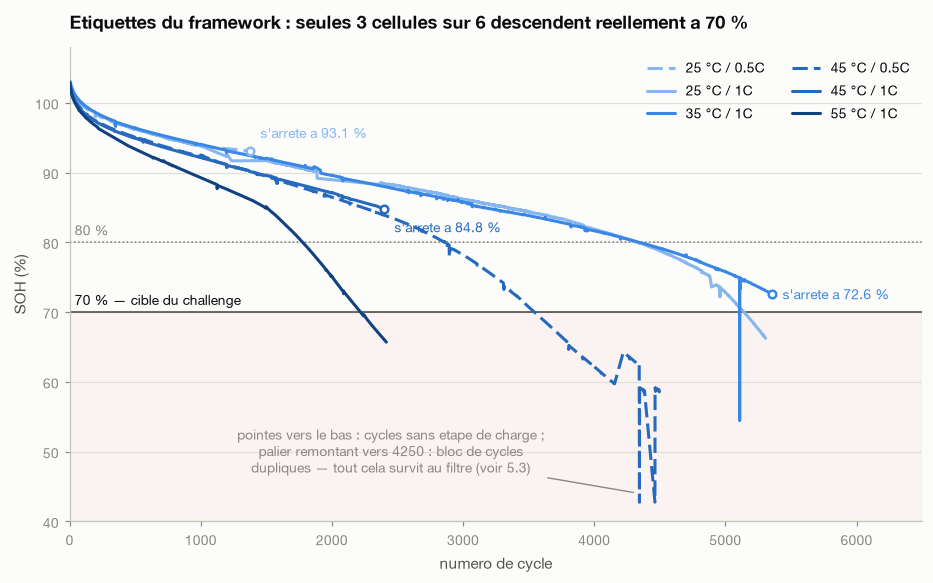

In [30]:
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.axhspan(0, 70, color=STATUS["critical"], alpha=0.045, zorder=0)
for s5_thr, s5_ls, s5_txt in [(80, ":", "80 %"), (70, "-", "70 % — cible du challenge")]:
    ax.axhline(s5_thr, color=INK, lw=1.0, ls=s5_ls, alpha=0.5 if s5_thr == 80 else 0.75, zorder=1)
    ax.annotate(s5_txt, xy=(0.006, s5_thr + 0.6), xycoords=("axes fraction", "data"),
                ha="left", va="bottom", fontsize=9, color=MUTED if s5_thr == 80 else INK)
for cid, T, C in CELLS:
    s5_f = s5_fw[cid].dropna(subset=["soh_percent"])
    ax.plot(s5_f.cycle_number, s5_f.soh_percent, **style(cid), label=label(cid), zorder=3)
    s5_last = s5_f.iloc[-1]
    if s5_last.soh_percent > 70:                    # cellule arretee avant la cible
        s5_dy = {"102Ah_25degC_0p5C_cell3": 2.6, "102Ah_45degC_1C_cell1": -2.6}.get(cid, 0.0)
        ax.plot([s5_last.cycle_number], [s5_last.soh_percent], "o", ms=5, mfc=SURFACE,
                mec=style(cid)["color"], mew=1.6, zorder=5)
        ax.annotate(f"s'arrete a {s5_last.soh_percent:.1f} %",
                    xy=(s5_last.cycle_number + 80, s5_last.soh_percent + s5_dy), fontsize=9,
                    color=style(cid)["color"], va="center", ha="left", zorder=5)
ax.annotate("pointes vers le bas : cycles sans etape de charge ;\n"
            "palier remontant vers 4250 : bloc de cycles\ndupliques — tout cela survit au filtre (voir 5.3)",
            xy=(4345, 44), xytext=(2450, 47), fontsize=9, color=MUTED, ha="center",
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.9, shrinkA=0, shrinkB=4))
ax.set_ylim(40, 108); ax.set_xlim(0, 6500); ax.set_yticks([40, 50, 60, 70, 80, 90, 100])
finish(ax, "Etiquettes du framework : seules 3 cellules sur 6 descendent reellement a 70 %",
       "numero de cycle", "SOH (%)", ncol=2)
plt.show()

**Trois cellules sur six s'arrêtent au-dessus de 70 %.** 25 °C/0.5C termine à 93.10 %
(cycle 1375), 45 °C/1C à 84.78 % (dernier cycle labellisé 2396, sur 2397 cycles réalisés)
et — c'est le point le moins évident — **35 °C/1C termine à 72.58 % au cycle 5356**. Les
excursions sous 70 % que l'on voit sur ces courbes sont des points isolés : sur le 35 °C,
hors le seul cycle 5109, aucun cycle ne passe sous 70 % (démonstration en 5.3). Seules
**25 °C/1C (66.25 %), 45 °C/0.5C (58.72 %) et 55 °C/1C (65.70 %)** franchissent réellement
la cible ; les cycles de franchissement (5142, 3545, 2219) sont calculés dans la cellule
suivante.

Ce que ça implique pour la modélisation :

- L'extrapolation sous 70 % ne s'appuie que sur **trois** trajectoires, dont une seule à
  0.5C. Le pré-entraînement sur les datasets LFP publics n'est pas un bonus, c'est la
  seule source de knee-points en quantité.
- Deux régimes doux (25 °C/0.5C, 45 °C/1C) ne fournissent que du début de vie, et le
  35 °C/1C s'arrête juste avant la cible. Pour eux, la prédiction jusqu'à 12 000 cycles est
  de la pure extrapolation : il faut un modèle dont la forme fonctionnelle impose déjà
  l'accélération, pas un régresseur libre.
- Les pointes verticales visibles vers 4300-5100 et le palier remontant du 45 °C/0.5C vers
  4250 sont des artefacts que le framework laisse passer. C'est l'objet de 5.3.

### 5.2 Le SOH dépasse 100 % — faut-il normaliser autrement ?

Une cellule neuve délivre plus que sa capacité nominale : le nominal est une valeur
garantie, volontairement sous-estimée par le fabricant. Il faut quantifier l'ampleur du
phénomène, car il détermine le point de départ que le modèle doit prédire au cycle 1 — et
mesurer ce que coûterait une normalisation par la capacité initiale Q₀ plutôt que par
102 Ah.

     cellule  Q0 (Ah)  Q0 / 102 Ah  SOH max (%)  cycles > 100 %  dernier cycle > 100 %
25 °C / 0.5C   104.52       1.0247       102.47              76                     77
  25 °C / 1C   105.16       1.0310       103.10              90                     92
  35 °C / 1C   104.69       1.0264       102.64              92                     92
45 °C / 0.5C   105.11       1.0305       103.05              52                     52
  45 °C / 1C   104.79       1.0273       102.73              48                     48
  55 °C / 1C   104.90       1.0284       102.84              41                     41

Q0 / 102 Ah : moyenne 1.0281, ecart-type 0.0024, etendue 1.0247 - 1.0310

seuil des 70 % : definition officielle (/ 102 Ah) contre normalisation par Q0
   25 °C / 0.5C  officiel : None   |   avec Q0 : None   -> jamais atteint
   25 °C / 1C    officiel : 5142   |   avec Q0 : 5035   -> 107 cycles trop tot
   35 °C / 1C    officiel : None   |   avec Q0 : None   -> jamais atteint
   45 °C / 

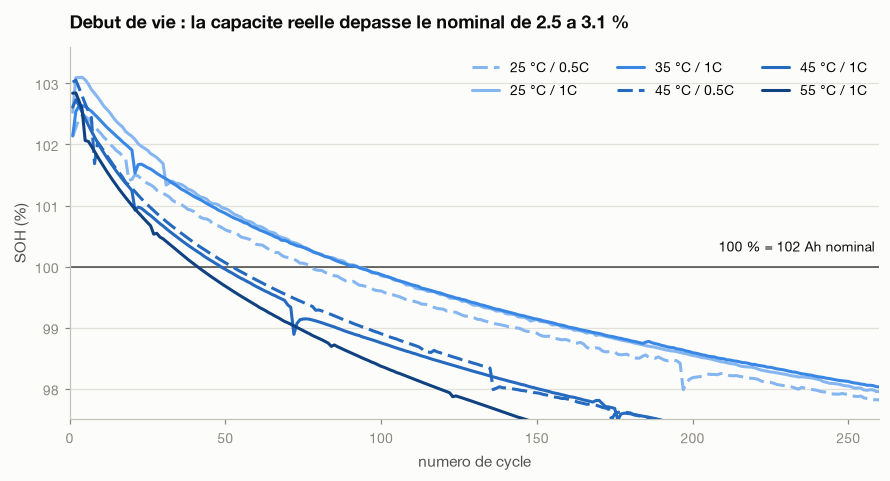

In [31]:
s5_q0 = {cid: float(s5_raw[cid].discharge_capacity_Ah.iloc[:10].max()) for cid, T, C in CELLS}
s5_over = pd.DataFrame([{
    "cellule": label(cid),
    "Q0 (Ah)": round(s5_q0[cid], 2),
    "Q0 / 102 Ah": round(s5_q0[cid] / NOMINAL_AH, 4),
    "SOH max (%)": round(s5_raw[cid].soh_percent.max(), 2),
    "cycles > 100 %": int((s5_raw[cid].soh_percent > 100).sum()),
    "dernier cycle > 100 %": int(s5_raw[cid].cycle_number[s5_raw[cid].soh_percent > 100].max()),
} for cid, T, C in CELLS])
print(s5_over.to_string(index=False))
s5_r = np.array(list(s5_q0.values())) / NOMINAL_AH
print(f"\nQ0 / 102 Ah : moyenne {s5_r.mean():.4f}, ecart-type {s5_r.std(ddof=1):.4f}, "
      f"etendue {s5_r.min():.4f} - {s5_r.max():.4f}")

def s5_franchit(x, y, thr=70.0, k=5):
    """Premier cycle ou le SOH passe sous le seuil ET y reste sur k cycles
    labellises : une pointe isolee (artefact) ne compte pas comme un franchissement."""
    sous = pd.Series(y <= thr).rolling(k).min().shift(-(k - 1)).fillna(0).to_numpy() > 0
    return int(x[np.argmax(sous)]) if sous.any() else None

print("\nseuil des 70 % : definition officielle (/ 102 Ah) contre normalisation par Q0")
for cid, T, C in CELLS:
    s5_f = s5_fw[cid].dropna(subset=["soh_percent"])
    s5_x, s5_y = s5_f.cycle_number.to_numpy(), s5_f.soh_percent.to_numpy()
    s5_a = s5_franchit(s5_x, s5_y)
    s5_b = s5_franchit(s5_x, s5_y * NOMINAL_AH / s5_q0[cid])
    print(f"   {label(cid):13s} officiel : {s5_a}   |   avec Q0 : {s5_b}"
          + (f"   -> {s5_a - s5_b} cycles trop tot" if s5_a and s5_b else "   -> jamais atteint"))

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.axhline(100, color=INK, lw=1.0, alpha=0.75, zorder=1)
ax.annotate("100 % = 102 Ah nominal", xy=(0.994, 100.2), xycoords=("axes fraction", "data"),
            ha="right", va="bottom", fontsize=9, color=INK)
for cid, T, C in CELLS:
    s5_f = s5_raw[cid]; s5_m = s5_f.cycle_number <= 260
    ax.plot(s5_f.cycle_number[s5_m], s5_f.soh_percent[s5_m], **style(cid), label=label(cid), zorder=3)
ax.set_xlim(0, 260); ax.set_ylim(97.5, 103.6)
finish(ax, "Debut de vie : la capacite reelle depasse le nominal de 2.5 a 3.1 %",
       "numero de cycle", "SOH (%)", ncol=3)
plt.show()

Le dépassement est **systématique et modeste** : capacité initiale entre 104.52 et 105.16 Ah,
soit **2.5 à 3.1 % au-dessus du nominal**, et un SOH maximal de 102.47 à 103.10 %. Aucune
valeur ne monte plus haut : le garde-fou du framework (1.15 × nominal ≈ 117 %) n'est jamais
déclenché par ce phénomène, il ne sert qu'à attraper de vraies aberrations de mesure.

Le retour sous 100 % se fait entre le cycle **41** (55 °C/1C) et le cycle **92** (25 °C/1C
et 35 °C/1C). L'ordre suit *grossièrement* la sévérité du vieillissement — les trois
cellules chaudes repassent sous 100 % avant le cycle 55, les trois froides après le cycle 75
— mais pas strictement : la plus douce des six (25 °C/0.5C) repasse sous 100 % dès le
cycle 77 simplement parce qu'elle part du plus faible excédent (+2.47 %). La durée du
dépassement mélange donc point de départ et vitesse ; on ne peut pas en faire un indicateur
de sévérité.

**Faut-il normaliser par la capacité initiale Q₀ plutôt que par 102 Ah ?**

- *Contre, et c'est décisif :* la vérité terrain cachée divise par **102 Ah**. Si on
  entraîne sur `Q/Q₀` et qu'on rend `Q/Q₀`, on se trompe d'un facteur 1.0247 à 1.0310, soit
  un biais systématique de **2.5 à 3.1 points de SOH** — bien plus que l'erreur qu'on peut
  espérer sur un bon modèle. Le seuil des 70 % serait franchi trop tôt de **87 à 124 cycles**
  (mesuré ci-dessus : 5035 au lieu de 5142 sur 25 °C/1C, 3421 au lieu de 3545 sur
  45 °C/0.5C, 2132 au lieu de 2219 sur 55 °C/1C).
- *Pour, à l'usage interne uniquement :* les datasets LFP publics utilisés en
  pré-entraînement ont d'autres capacités nominales. Travailler en interne sur `Q/Q₀` rend
  les trajectoires comparables entre chimies et formats, ce qui est exactement ce dont le
  transfer learning a besoin.

**Décision** : normaliser par Q₀ *dans l'espace latent du pré-entraînement*, puis reconvertir
en fin de chaîne par `SOH = (Q/Q₀) × (Q₀/102)`, avec `Q₀/102 = 1.0281 ± 0.0024` sur les six
cellules — une constante assez stable pour être apprise comme un simple offset. Ne jamais
rendre du `Q/Q₀` brut.

### 5.3 Outliers : ce que le framework écarte, et ce qui reste

Le framework écarte 5 cycles sur les 19 297 labellisés. Combien d'aberrations subsistent ?
On applique un détecteur robuste sur **les étiquettes du framework** : écart à une médiane
glissante de 41 cycles, normalisé par la MAD locale. Un détail compte : la courbe est si
lisse que la MAD locale est nulle sur plus de la moitié des cycles (le point central *est*
la médiane) — d'où un plancher d'échelle à 0.20 point, sans lequel tout point serait
déclaré aberrant.

In [32]:
def s5_mad_z(s, win=41, plancher=0.20):
    """Ecart a une mediane glissante, normalise par la MAD locale.
    Le plancher evite de diviser par zero : la courbe est si lisse que la MAD
    locale est nulle sur plus de la moitie des cycles."""
    med = s.rolling(win, center=True, min_periods=5).median()
    res = s - med
    ech = np.maximum(1.4826 * res.abs().rolling(win, center=True, min_periods=5).median(), plancher)
    return med, res / ech

s5_rows = []
for cid, T, C in CELLS:
    s5_f = s5_fw[cid].dropna(subset=["soh_percent"]).reset_index(drop=True)
    s5_med, s5_z = s5_mad_z(s5_f.soh_percent)
    for s5_k in np.where(s5_z.abs() > 6)[0]:
        s5_rows.append(dict(cellule=label(cid), cycle=int(s5_f.cycle_number[s5_k]),
                            SOH=round(s5_f.soh_percent[s5_k], 2), tendance=round(s5_med[s5_k], 2),
                            ecart=round(s5_f.soh_percent[s5_k] - s5_med[s5_k], 2), z=round(s5_z[s5_k], 1)))
s5_aberrants = pd.DataFrame(s5_rows).sort_values("ecart").reset_index(drop=True)
print(s5_aberrants.to_string(index=False))

     cellule  cycle   SOH  tendance  ecart      z
  35 °C / 1C   5109 54.44     74.91 -20.47 -102.3
45 °C / 0.5C   4345 42.75     59.13 -16.38  -81.9
45 °C / 0.5C   4463 42.75     58.95 -16.20  -81.0
  35 °C / 1C   5113 73.35     74.82  -1.47   -7.3
  25 °C / 1C   4959 72.18     73.48  -1.30   -6.5


Cinq points survivent au filtre du framework, dont **trois massifs** :

| cellule | cycle | SOH étiqueté | tendance locale | écart |
|---|---|---|---|---|
| 35 °C/1C | 5109 | 54.44 % | 74.91 % | −20.47 pt |
| 45 °C/0.5C | 4345 | **42.75 %** | **59.13 %** | −16.38 pt |
| 45 °C/0.5C | 4463 | **42.75 %** | 58.95 % | −16.20 pt |

Le filtre du framework les laisse passer parce qu'il compare la capacité du cycle à
`0.6 × médiane glissante des 15 cycles précédents` : le rapport vaut **0.68** pour le cycle
4345 (43.61 Ah contre une médiane de 63.83 Ah), **0.73** pour le 4463 et **0.73** pour le
5109 — tous largement au-dessus du seuil de 0.6. Un modèle entraîné sur ces étiquettes
verrait deux chutes de 16 points suivies d'une remontée immédiate — exactement la signature
qu'un knee-point est censé avoir, mais au mauvais endroit.

Avant de supprimer quoi que ce soit, il faut savoir **ce que sont physiquement** ces cycles.
On redescend dans les séries temporelles, en ajoutant un cycle normal pour référence et un
cas de nature opposée (45 °C/1C, cycle 2397, que le framework écarte, lui).

In [33]:
s5_loupe = {"102Ah_45degC_0p5C_cell3": [4344, 4345, 4346],   # charge interrompue, puis decharge orpheline
            "102Ah_35degC_1C_cell1":   [5109],               # meme signature
            "102Ah_45degC_1C_cell1":   [2396, 2397]}         # le cas inverse : charge complete, decharge avortee
for cid, s5_cycs in s5_loupe.items():
    s5_d = load_cell(cid, columns=["cycle_number", "step_type", "step_capacity_Ah"])
    for s5_cyc in s5_cycs:
        s5_g = s5_d[s5_d.cycle_number == s5_cyc].groupby("step_type").step_capacity_Ah.max()
        s5_soh = s5_raw[cid].set_index("cycle_number").soh_percent
        s5_et = f"{s5_soh[s5_cyc]:.2f} %" if s5_cyc in s5_soh.index else "pas d'etiquette"
        print(f"{label(cid):13s} cycle {s5_cyc} : "
              + " | ".join(f"{k} {v:.2f} Ah" for k, v in s5_g.items())
              + f"   -> SOH brut {s5_et}")

45 °C / 0.5C  cycle 4344 : cccv_charge 18.75 Ah   -> SOH brut pas d'etiquette
45 °C / 0.5C  cycle 4345 : cc_discharge 43.61 Ah | rest 0.00 Ah   -> SOH brut 42.75 %
45 °C / 0.5C  cycle 4346 : cc_charge 60.42 Ah | cc_discharge 60.31 Ah | rest 0.00 Ah   -> SOH brut 59.13 %
35 °C / 1C    cycle 5109 : cc_discharge 55.53 Ah | rest 0.00 Ah   -> SOH brut 54.45 %
45 °C / 1C    cycle 2396 : cc_discharge 86.47 Ah | cccv_charge 86.47 Ah | rest 0.00 Ah   -> SOH brut 84.78 %
45 °C / 1C    cycle 2397 : cc_discharge 22.24 Ah | cccv_charge 86.46 Ah | rest 0.00 Ah   -> SOH brut 21.81 %


Le diagnostic est net : **ces cycles n'ont aucune étape de charge**. Ils ne contiennent que
`rest` + `cc_discharge`. Au 45 °C/0.5C, la charge précédente a été interrompue — le cycle
4344 ne contient qu'un `cccv_charge` partiel de 18.75 Ah et pas de décharge — donc la
décharge du 4345 part d'une cellule partiellement chargée et ne mesure **pas** une capacité
disponible. Le cycle suivant, 4346, est normal : charge 60.42 Ah, décharge 60.31 Ah →
59.13 %, exactement la tendance locale.

On tient là un critère **structurel**, pas statistique : *un cycle sans étape de charge ne
porte pas d'étiquette de SOH*. Il est déterministe, interprétable, et il ne risque pas de
supprimer une vraie chute rapide.

Le dernier couple imprimé montre le cas **symétrique**, celui que ce critère ne verra jamais :
au 45 °C/1C, le cycle 2397 a une charge complète (86.46 Ah) mais une décharge coupée à
22.24 Ah. C'est celui-là que le seuil `0.6 × médiane` du framework attrape. Les deux filtres
sont complémentaires — on garde celui du framework **et** on ajoute le critère structurel.

Enfin, une anomalie appelle un troisième test : le cycle 4463 du 45 °C/0.5C porte
**exactement** la même valeur que le 4345 (43.6066 Ah, 42.751569 %). On teste donc
l'empreinte complète de chaque cycle — nombre de lignes, horodatage de début, horodatage de
fin, capacité — pour détecter des cycles rejoués sous un autre numéro.

In [34]:
def s5_audit(cid):
    """Trois verdicts par cycle : contient-il une etape de charge ? est-il la copie
    exacte d'un cycle deja vu (meme longueur, memes horodatages, meme capacite) ?
    et si oui, de quel cycle ?"""
    ts = load_cell(cid, columns=["cycle_number", "step_type", "absolute_time", "step_capacity_Ah"])
    g = ts.groupby("cycle_number").agg(n=("absolute_time", "size"), t0=("absolute_time", "min"),
                                       t1=("absolute_time", "max"), q=("step_capacity_Ah", "max"))
    g["a_une_charge"] = g.index.isin(ts.loc[ts.step_type.isin(["cc_charge", "cccv_charge"]), "cycle_number"].unique())
    cle = pd.Series(list(zip(g.n, g.t0, g.t1, g.q.round(4))), index=g.index)
    g["est_copie"] = cle.duplicated(keep="first")
    vu, src = {}, []
    for c, k in zip(g.index, cle):
        src.append(vu.setdefault(k, c) if k in vu else np.nan)
        vu.setdefault(k, c)
    g["copie_de"] = src
    return g[["a_une_charge", "est_copie", "copie_de"]]

s5_clean, s5_rej = {}, []
for cid, T, C in CELLS:
    s5_a = s5_audit(cid)
    s5_f = s5_raw[cid].join(s5_a, on="cycle_number")
    s5_f["garde_framework"] = s5_f.cycle_number.isin(s5_fw[cid].cycle_number[s5_fw[cid].soh_percent.notna()])
    s5_n_brut = len(s5_f)
    s5_n_fw = int((~s5_f.garde_framework).sum())
    s5_n_chg = int((s5_f.garde_framework & ~s5_f.a_une_charge).sum())
    s5_n_cop = int((s5_f.garde_framework & s5_f.a_une_charge & s5_f.est_copie).sum())
    if not s5_f.a_une_charge.all():
        print(f"  {label(cid):13s} cycles labellises SANS etape de charge : "
              f"{list(s5_f.cycle_number[~s5_f.a_une_charge])}")
    s5_b = s5_a[s5_a.est_copie]
    if len(s5_b):                                   # blocs contigus de meme decalage
        s5_cyc = s5_b.index.to_numpy(); s5_off = s5_cyc - s5_b.copie_de.to_numpy(int)
        s5_cut = np.where((np.diff(s5_cyc) != 1) | (np.diff(s5_off) != 0))[0]
        for s5_i0, s5_i1 in zip(np.r_[0, s5_cut + 1], np.r_[s5_cut, len(s5_cyc) - 1]):
            print(f"  {label(cid):13s} bloc duplique : cycles {s5_cyc[s5_i0]}-{s5_cyc[s5_i1]} = copie de "
                  f"{s5_cyc[s5_i0]-s5_off[s5_i0]}-{s5_cyc[s5_i1]-s5_off[s5_i1]} "
                  f"(decalage +{s5_off[s5_i0]}, {s5_i1-s5_i0+1} cycles)")
    s5_f = s5_f[s5_f.garde_framework & s5_f.a_une_charge & ~s5_f.est_copie].reset_index(drop=True)
    s5_med, s5_z = s5_mad_z(s5_f.soh_percent)
    for s5_k in np.where(s5_z.abs() > 6)[0]:
        print(f"  MAD residuel : {label(cid)} cycle {int(s5_f.cycle_number[s5_k])} -> "
              f"{s5_f.soh_percent[s5_k]:.2f} % contre une tendance a {s5_med[s5_k]:.2f} % (z = {s5_z[s5_k]:.1f})")
    s5_n_mad = int((s5_z.abs() > 6).sum())
    s5_f = s5_f[s5_z.abs() <= 6].reset_index(drop=True)
    s5_clean[cid] = s5_f[["cycle_number", "discharge_capacity_Ah", "soh_percent"]]
    s5_rej.append(dict(cellule=label(cid), brut=s5_n_brut, framework=s5_n_fw, sans_charge=s5_n_chg,
                       copie_exacte=s5_n_cop, MAD=s5_n_mad, retenus=len(s5_f),
                       dernier_cycle=int(s5_f.cycle_number.iloc[-1]),
                       SOH_final=round(s5_f.soh_percent.iloc[-1], 2),
                       ecarte_pct=round(100 * (s5_n_brut - len(s5_f)) / s5_n_brut, 2)))
s5_rej = pd.DataFrame(s5_rej)
print()
print(s5_rej.to_string(index=False))
s5_n0, s5_n1 = s5_rej.brut.sum(), s5_rej.retenus.sum()
print(f"\ntotal : {s5_n0 - s5_n1} cycles ecartes sur {s5_n0} ({100*(s5_n0-s5_n1)/s5_n0:.2f} %), "
      f"dont {100*(4299-len(s5_clean['102Ah_45degC_0p5C_cell3']))/(s5_n0-s5_n1):.0f} % sur la seule cellule 45 °C / 0.5C")

  25 °C / 1C    cycles labellises SANS etape de charge : [4953]
  MAD residuel : 25 °C / 1C cycle 4959 -> 72.18 % contre une tendance a 73.48 % (z = -6.5)


  35 °C / 1C    cycles labellises SANS etape de charge : [5109]
  MAD residuel : 35 °C / 1C cycle 5113 -> 73.35 % contre une tendance a 74.82 % (z = -7.4)
  45 °C / 0.5C  cycles labellises SANS etape de charge : [2875, 2895, 3308, 3801, 4345, 4463]
  45 °C / 0.5C  bloc duplique : cycles 4222-4343 = copie de 3866-3987 (decalage +356, 122 cycles)
  45 °C / 0.5C  bloc duplique : cycles 4463-4502 = copie de 4345-4384 (decalage +118, 40 cycles)

     cellule  brut  framework  sans_charge  copie_exacte  MAD  retenus  dernier_cycle  SOH_final  ecarte_pct
25 °C / 0.5C   988          0            0             0    0      988           1375      93.10        0.00
  25 °C / 1C  4156          1            0             0    1     4154           5307      66.25        0.05
  35 °C / 1C  5354          0            1             0    1     5352           5356      72.58        0.04
45 °C / 0.5C  4299          3            3           160    0     4133           4383      58.72        3.86
  45 °C / 

**Découverte majeure : le 45 °C/0.5C contient 162 cycles qui sont la copie exacte de cycles
antérieurs**, en deux blocs contigus ré-numérotés avec un décalage constant :

- cycles **4222-4343** ⟵ copie de **3866-3987** (décalage +356, 122 cycles) ;
- cycles **4463-4502** ⟵ copie de **4345-4384** (décalage +118, 40 cycles).

Sur ces 162 cycles, 161 portent une étiquette (le 4502 n'a pas de décharge) et la colonne
`copie_exacte` du tableau en compte 160, le cycle 4463 ayant déjà été retiré au titre des
cycles sans charge. **Aucune autre cellule n'est touchée** : zéro cycle à empreinte dupliquée
ailleurs.

La duplication est bit à bit sur tout ce qui est mesuré : `step_type`, `voltage_V`,
`current_A`, `temperature_C`, `step_capacity_Ah` et `absolute_time` sont identiques ligne à
ligne entre un cycle et sa copie ; seule `time_in_cycle_s`, qui est un compteur relatif,
diffère. Les copies portent donc les horodatages de leurs originaux, antérieurs ou égaux au
dernier cycle réel (4384, le 27 décembre 2023).

Conséquence sur la cible : le SOH du 45 °C/0.5C **remonte de 4.55 points** au cycle 4222
(59.72 % au cycle 4155, dernier cycle réel, puis 64.27 %), ce qui est physiquement
impossible. Après nettoyage, la cellule s'arrête en réalité au **cycle 4383 à 58.72 %**, et
non au cycle 4501.

Le tableau apporte un second enseignement, sur les cycles sans charge : il y en a **8** parmi
les cycles labellisés (1 au 25 °C/1C, 1 au 35 °C/1C, 6 au 45 °C/0.5C). Le framework en écarte
déjà 4 — ceux dont la capacité tombe sous 0.6 × médiane — et laisse passer les 4 autres,
dont le cycle 2895 du 45 °C/0.5C, où le déficit est trop faible pour déclencher le seuil et
passe donc totalement inaperçu.

Après les trois filtres, il reste deux points signalés par la MAD (25 °C/1C cycle 4959,
35 °C/1C cycle 5113), avec des écarts de −1.30 et −1.47 point et des z de −6.5 / −7.4. Ils
sont **ambigus**, et pour une raison instructive : tous deux appartiennent à la séquence de
récupération qui suit un cycle avorté (4953 et 5109 respectivement). Après le cycle 5109, le
SOH descend progressivement 74.91 → 74.38 → 73.86 → 73.35 avant de remonter à 74.67 ; le
détecteur ne retire que le point le plus bas de cette dérive et laisse les deux autres. Cette
quatrième étape est donc **cosmétique** — on la garde par cohérence, mais elle ne décide de
rien : 2 points sur 19 297.

Au total le pipeline n'écarte que **171 cycles sur 19 297, soit 0.89 %**, dont **97 %**
viennent d'une seule cellule (166 sur 4299 au 45 °C/0.5C, soit 3.86 %).

Le graphe suivant montre les deux artefacts côte à côte et ce qu'en fait chaque version de
la cible.

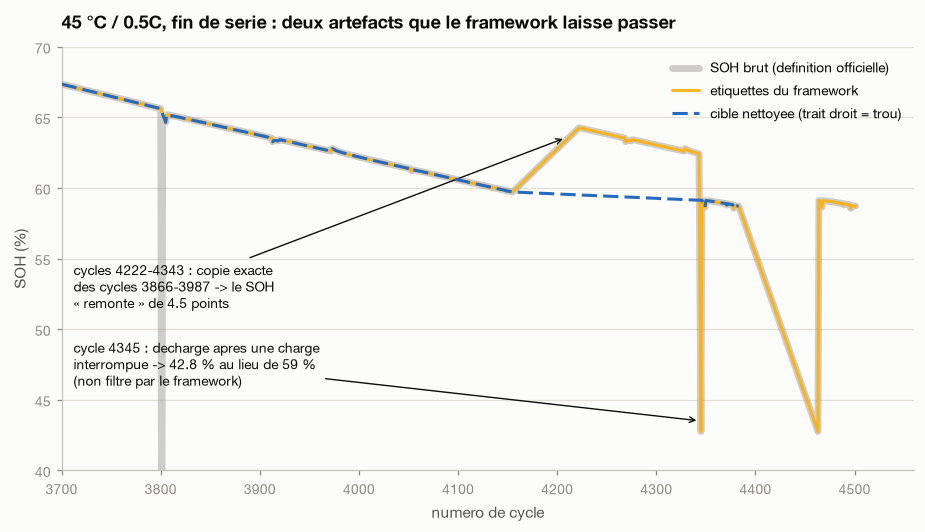

In [35]:
s5_cid = "102Ah_45degC_0p5C_cell3"
fig, ax = plt.subplots(figsize=(10, 5.0))
s5_r = s5_raw[s5_cid]; s5_m = (s5_r.cycle_number >= 3700) & (s5_r.cycle_number <= 4520)
ax.plot(s5_r.cycle_number[s5_m], s5_r.soh_percent[s5_m], lw=4.5, color=MUTED, alpha=0.40,
        label="SOH brut (definition officielle)", zorder=2)
s5_f = s5_fw[s5_cid].dropna(subset=["soh_percent"])
s5_m2 = (s5_f.cycle_number >= 3700) & (s5_f.cycle_number <= 4520)
ax.plot(s5_f.cycle_number[s5_m2], s5_f.soh_percent[s5_m2], lw=2.0, color=STATUS["warning"], alpha=0.95,
        label="etiquettes du framework", zorder=3)
s5_c = s5_clean[s5_cid]; s5_m3 = (s5_c.cycle_number >= 3700) & (s5_c.cycle_number <= 4520)
ax.plot(s5_c.cycle_number[s5_m3], s5_c.soh_percent[s5_m3], **style(s5_cid),
        label="cible nettoyee (trait droit = trou)", zorder=4)
ax.annotate("cycles 4222-4343 : copie exacte\ndes cycles 3866-3987 -> le SOH\n« remonte » de 4.5 points",
            xy=(4210, 63.6), xytext=(3712, 51.5), fontsize=9, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=INK, lw=0.9, shrinkA=2, shrinkB=3))
ax.annotate("cycle 4345 : decharge apres une charge\ninterrompue -> 42.8 % au lieu de 59 %\n(non filtre par le framework)",
            xy=(4345, 43.5), xytext=(3712, 46.0), fontsize=9, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=INK, lw=0.9, shrinkA=2, shrinkB=3))
ax.set_xlim(3700, 4560); ax.set_ylim(40, 70)
finish(ax, "45 °C / 0.5C, fin de serie : deux artefacts que le framework laisse passer",
       "numero de cycle", "SOH (%)", ncol=1)
plt.show()

Deux détails de lecture : la barre grise verticale vers 3801 est un cycle que le framework,
lui, écarte correctement (un cycle sans charge à 28.63 %) ; et le trait droit de la cible
nettoyée entre 4155 et 4346 n'est pas de la donnée, c'est le trou laissé par la suppression
du bloc dupliqué.

### 5.4 Ce qu'il ne faut *pas* nettoyer : les marches de vieillissement calendaire

Un détecteur statistique plus agressif que le nôtre supprimerait aussi des discontinuités
bien réelles. La cible nettoyée contient des marches d'un cycle à l'autre très supérieures
au bruit ; avant d'être tenté de les lisser, il faut savoir d'où elles viennent. L'hypothèse
à tester : pendant un arrêt du banc, la cellule vieillit en **calendaire**, et la capacité
mesurée à la reprise est plus basse. On liste donc les pauses de plus de 7 jours et on
compare la marche observée à ce que le seul cyclage des cycles sautés expliquerait (perte
médiane par cycle × nombre de cycles sautés).

In [36]:
s5_rows = []
for cid, T, C in CELLS:
    s5_ts = load_cell(cid, columns=["cycle_number", "absolute_time"])
    s5_t0 = s5_ts.groupby("cycle_number")["absolute_time"].min()
    s5_t1 = s5_ts.groupby("cycle_number")["absolute_time"].max()
    s5_f = s5_clean[cid]
    s5_x, s5_y = s5_f.cycle_number.to_numpy(), s5_f.soh_percent.to_numpy()
    s5_d = np.diff(s5_y); s5_adj = np.diff(s5_x) == 1
    s5_perte = np.median(np.abs(s5_d[s5_adj]))          # perte typique d'un cycle, pour comparaison
    s5_pause = (s5_t0.reindex(s5_x[1:]).to_numpy() - s5_t1.reindex(s5_x[:-1]).to_numpy()) / np.timedelta64(1, "D")
    for s5_k in np.where(s5_pause > 7)[0]:
        s5_saut = int(s5_x[s5_k+1] - s5_x[s5_k] - 1)
        s5_rows.append(dict(cellule=label(cid), cycle=int(s5_x[s5_k]), pause_j=round(float(s5_pause[s5_k]), 1),
                            cycles_sautes=s5_saut, SOH_avant=round(s5_y[s5_k], 1),
                            dSOH=round(float(s5_d[s5_k]), 2),
                            dSOH_attendu=round(-s5_saut * s5_perte, 2)))
s5_pauses = pd.DataFrame(s5_rows).sort_values("pause_j", ascending=False).reset_index(drop=True)
print(s5_pauses.to_string(index=False))
s5_courtes = s5_pauses[s5_pauses.cycles_sautes <= 13]
print(f"\n{len(s5_pauses)} pauses > 7 jours ; dSOH median {s5_pauses.dSOH.median():+.2f} point")
print(f"dont {len(s5_courtes)} avec <= 13 cycles sautes (le cyclage n'explique alors "
      f"au plus que {-s5_courtes.dSOH_attendu.min():.2f} pt) : dSOH = {list(s5_courtes.dSOH)}")

# les marches d'un cycle a l'autre : combien, et combien suivent une interruption ?
s5_dn = s5_up = s5_tr = s5_dn_pause = 0
for cid, T, C in CELLS:
    s5_ts = load_cell(cid, columns=["cycle_number", "absolute_time"])
    s5_t0 = s5_ts.groupby("cycle_number")["absolute_time"].min()
    s5_t1 = s5_ts.groupby("cycle_number")["absolute_time"].max()
    s5_f = s5_clean[cid]
    s5_x, s5_y = s5_f.cycle_number.to_numpy(), s5_f.soh_percent.to_numpy()
    s5_adj = np.diff(s5_x) == 1
    s5_d = np.diff(s5_y)[s5_adj]
    s5_h = ((s5_t0.reindex(s5_x[1:]).to_numpy() - s5_t1.reindex(s5_x[:-1]).to_numpy())
            / np.timedelta64(1, "h"))[s5_adj]
    s5_tr += len(s5_d); s5_dn += int((s5_d < -0.15).sum()); s5_up += int((s5_d > 0.15).sum())
    s5_dn_pause += int(((s5_d < -0.15) & (s5_h > 24)).sum())
print(f"\nmarches > 0.15 point entre deux cycles CONSECUTIFS : {s5_dn} vers le bas "
      f"(dont {s5_dn_pause} apres un arret de plus de 24 h), {s5_up} vers le haut, sur {s5_tr} transitions")

     cellule  cycle  pause_j  cycles_sautes  SOH_avant  dSOH  dSOH_attendu
  25 °C / 1C   1886     44.3              0       90.2 -0.97          0.00
  25 °C / 1C   1197     40.7             36       92.7 -1.03         -0.39
  25 °C / 1C   4881     36.8             13       75.2 -1.58         -0.14
25 °C / 0.5C   1001     35.4            370       93.8 -0.69         -3.41
  55 °C / 1C    218     30.1            215       96.3 -2.37         -3.20
45 °C / 0.5C    999     27.3              0       92.3  0.24          0.00
  25 °C / 1C   1887     26.9            474       89.2 -0.90         -5.16
45 °C / 0.5C   3307     26.8              1       74.2 -0.46         -0.01
  25 °C / 1C   1001     23.7            193       93.8 -1.52         -2.10
45 °C / 0.5C   4155     19.1            190       59.7 -0.59         -1.64
45 °C / 0.5C    135     16.0              0       98.3 -0.35          0.00
45 °C / 0.5C   2894     13.3              1       79.6 -0.95         -0.01
45 °C / 0.5C   3800     1

**14 interruptions de plus de 7 jours**, chute médiane **−0.79 point**. Le test est net sur
les **8 pauses qui ne sautent presque aucun cycle** (≤ 13) : le cyclage n'y expliquerait au
plus que 0.14 point, alors que la marche observée va de −0.15 à **−1.58 point** — 7 cas sur
8. La plus forte est celle du 25 °C/1C : −1.58 point entre les cycles 4881 et 4895, du
4 février au 13 mars 2023. Le huitième cas va dans l'autre sens (+0.24 point après 27 jours
d'arrêt, cycle 999 du 45 °C/0.5C) et reste inexpliqué : avec n = 8, le vieillissement
calendaire est établi comme mécanisme dominant, pas comme loi.

À l'inverse, les pauses qui sautent des centaines de cycles montrent une chute **plus petite**
que le cyclage seul ne le prédirait (−0.69 contre −3.41 attendus ; −0.90 contre −5.16) :
l'explication la plus simple est que ces numéros de cycle manquants n'ont jamais été cyclés,
ce sont des sauts de numérotation et non des mesures perdues.

Enfin, sur 18 965 transitions entre cycles consécutifs, **71 marches descendent de plus de
0.15 point et 29 montent**, soit environ 15 à 200 fois le bruit mesuré en 5.5 — mais seules
**7 des 71** suivent un arrêt de plus de 24 h. Le vieillissement calendaire explique les plus
grosses marches, pas la majorité d'entre elles ; l'origine des autres n'est pas identifiée
ici.

Implication directe et gênante : **la cible n'est pas une fonction du seul numéro de cycle.**
Deux cellules ayant vécu le même nombre de cycles au même (T, C) peuvent différer de plus
d'un point de SOH selon leur historique de pauses. Or `predict_soh(T, C)` ne reçoit *que*
(T, C) : ces marches sont, pour nous, une **erreur irréductible** de l'ordre de 0.5 à
1.5 point sur les cellules concernées. Il ne faut ni les lisser (elles sont vraies) ni
espérer les prédire — juste savoir qu'elles fixent un plancher au RMSE atteignable.

### 5.5 Bruit : le SOH est-il seulement bruité ?

On a nettoyé les artefacts ; reste à savoir s'il faut *aussi* débruiter. On estime le bruit
de mesure par la MAD de la **différence seconde** (insensible à la pente et à la courbure,
donc au knee) et on le compare à la perte médiane d'un cycle, par bande de SOH. La question
est : le rapport signal/bruit se dégrade-t-il en fin de vie, là où la prédiction est la plus
difficile ?

dispersion des differences cycle a cycle (ecart-type, points de SOH) :
   25 °C / 0.5C  avant nettoyage  0.0360   apres nettoyage  0.0360
   25 °C / 1C    avant nettoyage  0.9492   apres nettoyage  0.0544
   35 °C / 1C    avant nettoyage  0.3971   apres nettoyage  0.0306
   45 °C / 0.5C  avant nettoyage  2.0022   apres nettoyage  0.0373
   45 °C / 1C    avant nettoyage  1.3064   apres nettoyage  0.0283
   55 °C / 1C    avant nettoyage  0.0562   apres nettoyage  0.0562

     cellule    bande    n  bruit_pt  fade_pt_cycle  SNR
25 °C / 0.5C 100-90 %  988    0.0058         0.0092  1.6
  25 °C / 1C 100-90 % 1371    0.0102         0.0118  1.2
  25 °C / 1C  90-80 % 1872    0.0081         0.0092  1.1
  25 °C / 1C  80-70 %  745    0.0049         0.0111  2.3
  25 °C / 1C   < 70 %  166    0.0063         0.0221  3.5
  35 °C / 1C 100-90 % 1912    0.0029         0.0058  2.0
  35 °C / 1C  90-80 % 2431    0.0025         0.0043  1.7
  35 °C / 1C  80-70 % 1009    0.0029         0.0074  2.5
45 °C / 0.5C 

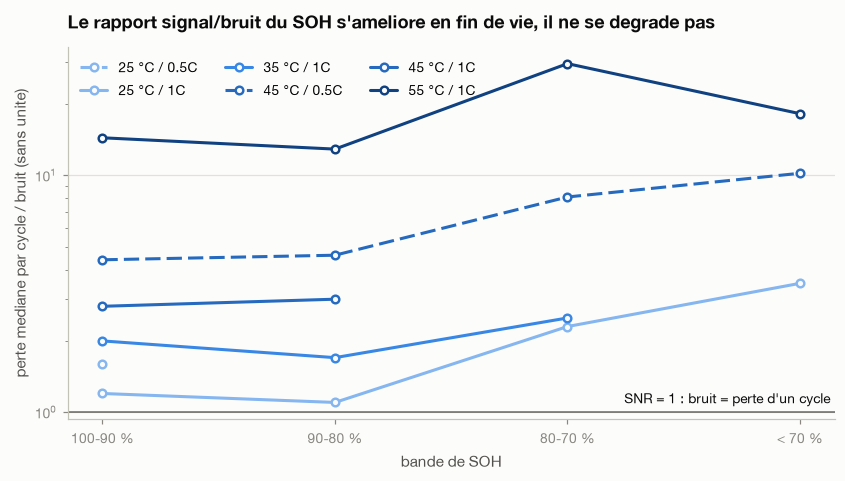

In [37]:
def s5_sigma(y):
    """Ecart-type du bruit de mesure, estime par la MAD de la difference seconde
    (pour un bruit blanc, var(d2) = 6 sigma^2). Insensible a la pente et a la courbure."""
    if len(y) < 12:
        return np.nan
    d2 = y[2:] - 2 * y[1:-1] + y[:-2]
    return 1.4826 * np.median(np.abs(d2 - np.median(d2))) / np.sqrt(6)

print("dispersion des differences cycle a cycle (ecart-type, points de SOH) :")
for cid, T, C in CELLS:
    print(f"   {label(cid):13s} avant nettoyage {np.diff(s5_raw[cid].soh_percent.to_numpy()).std():7.4f}"
          f"   apres nettoyage {np.diff(s5_clean[cid].soh_percent.to_numpy()).std():7.4f}")

S5_BANDS = [("100-90 %", 90, 200), ("90-80 %", 80, 90), ("80-70 %", 70, 80), ("< 70 %", 0, 70)]
s5_rows = []
for cid, T, C in CELLS:
    s5_f = s5_clean[cid]
    s5_x, s5_y = s5_f.cycle_number.to_numpy(), s5_f.soh_percent.to_numpy()
    for s5_nom, s5_lo, s5_hi in S5_BANDS:
        s5_m = (s5_y > s5_lo) & (s5_y <= s5_hi)
        if s5_m.sum() < 30:
            continue
        s5_d = np.abs(np.diff(s5_y[s5_m]))[np.diff(s5_x[s5_m]) == 1]   # cycles consecutifs seulement
        s5_sig, s5_fd = s5_sigma(s5_y[s5_m]), np.median(s5_d)
        s5_rows.append(dict(cid=cid, cellule=label(cid), bande=s5_nom, n=int(s5_m.sum()),
                            bruit_pt=round(s5_sig, 4), fade_pt_cycle=round(s5_fd, 4),
                            SNR=round(s5_fd / s5_sig, 1)))
s5_noise = pd.DataFrame(s5_rows)
print()
print(s5_noise.drop(columns="cid").to_string(index=False))

fig, ax = plt.subplots(figsize=(9.0, 4.4))
for cid, T, C in CELLS:
    s5_g = s5_noise[s5_noise.cid == cid]
    s5_idx = [i for i, b in enumerate(S5_BANDS) if b[0] in set(s5_g.bande)]
    ax.plot(s5_idx, s5_g.SNR.to_numpy(), marker="o", ms=5, mfc=SURFACE, mew=1.6,
            markeredgecolor=style(cid)["color"], label=label(cid), **style(cid))
ax.set_yscale("log"); ax.set_xticks(range(len(S5_BANDS))); ax.set_xticklabels([b[0] for b in S5_BANDS])
ax.axhline(1, color=INK, lw=1.0, alpha=0.6)
ax.annotate("SNR = 1 : bruit = perte d'un cycle", xy=(0.994, 1.06),
            xycoords=("axes fraction", "data"), ha="right", va="bottom", fontsize=9, color=INK)
finish(ax, "Le rapport signal/bruit du SOH s'ameliore en fin de vie, il ne se degrade pas",
       "bande de SOH", "perte mediane par cycle / bruit (sans unite)", ncol=3)
plt.show()

Le bruit est **minuscule** : de **0.0007 à 0.0102 point de SOH** selon la cellule et la
bande, soit au plus 0.010 Ah sur 102 Ah — un banc de cyclage de laboratoire, pas un BMS
embarqué.

Le premier tableau dit ce que valait la « dispersion » avant nettoyage : l'écart-type des
différences cycle à cycle atteignait **2.00 point** sur le 45 °C/0.5C, 1.31 sur le 45 °C/1C
et 0.95 sur le 25 °C/1C ; après nettoyage il tombe à 0.037, 0.028 et 0.054. Sur les deux
cellules sans artefact (25 °C/0.5C et 55 °C/1C) il ne bouge pas (0.036 et 0.056). Cette
dispersion n'était donc pas du bruit, c'étaient les artefacts.

Et le SNR **s'améliore** de la première à la dernière bande sur les cinq cellules qui en
couvrent plusieurs : 1.2 → 3.5 (25 °C/1C), 2.0 → 2.5 (35 °C/1C), 4.4 → 10.2 (45 °C/0.5C),
2.8 → 3.0 (45 °C/1C), 14.4 → 18.2 (55 °C/1C). La raison est mécanique : le bruit reste
constant alors que la perte par cycle double ou triple quand le knee arrive. C'est une bonne
nouvelle — **la zone qui compte le plus pour le score est la mieux mesurée** — et cela retire
tout argument en faveur d'un lissage agressif. Le pire rapport, 1.1 (25 °C/1C, bande
90-80 %), est atteint là où la trajectoire est la plus plate, donc la plus facile à
représenter.

### 5.6 Le knee-point, et ce que le lissage lui fait

On localise le knee par la vitesse de perte locale (différence centrée sur ±25 cycles,
exprimée en points de SOH pour 100 cycles). Trois précautions : on masque les zones où la
fenêtre contient moins de 80 % de cycles réellement mesurés (sinon l'interpolation à travers
un trou fabrique une fausse pente), on ignore les 200 premiers cycles (la chute de formation
initiale), et on mesure quelle part du pic vient d'**une seule** marche d'un cycle — pour ne
pas confondre un knee avec un accident de 5.4.

In [38]:
S5_H = 25   # demi-fenetre de la difference centree, en cycles

def s5_regrid(cid, h=S5_H):
    """SOH sur une grille de cycles entiers, plus un masque : True la ou la
    fenetre +-h contient au moins 80 % de cycles reellement mesures."""
    f = s5_clean[cid]; x = f.cycle_number.to_numpy(float); y = f.soh_percent.to_numpy(float)
    xi = np.arange(int(x.min()), int(x.max()) + 1)
    cov = pd.Series(np.isin(xi, x.astype(int)).astype(float)).rolling(2*h+1, center=True, min_periods=1).mean()
    return xi, np.interp(xi, x, y), cov.to_numpy() >= 0.80

def s5_fade(yv, xv, h=S5_H):
    """Vitesse de perte locale, en points de SOH pour 100 cycles."""
    g = np.full(len(yv), np.nan)
    g[h:-h] = (yv[:-2*h] - yv[2*h:]) / (xv[2*h:] - xv[:-2*h]) * 100
    return g

def s5_seuil(cid, thr):
    f = s5_clean[cid]; y = f.soh_percent.to_numpy()
    return int(f.cycle_number.to_numpy()[np.argmax(y <= thr)]) if (y <= thr).any() else pd.NA

s5_rows = []
for cid, T, C in CELLS:
    s5_xi, s5_yi, s5_ok = s5_regrid(cid)
    s5_g = np.where(s5_ok, s5_fade(s5_yi, s5_xi), np.nan)
    s5_i = int(np.nanargmax(np.where(s5_xi > 200, s5_g, np.nan)))
    s5_base = np.nanmedian(s5_g[(s5_xi > 200) & (s5_xi < 600)])
    s5_win = s5_yi[s5_i-S5_H:s5_i+S5_H+1]                 # part du pic due a une seule marche
    s5_rows.append(dict(cellule=label(cid), cycle_80=s5_seuil(cid, 80), cycle_70=s5_seuil(cid, 70),
                        SOH_final=round(s5_yi[-1], 1), cycle_pic=int(s5_xi[s5_i]), SOH_pic=round(s5_yi[s5_i], 1),
                        fade_pic=round(s5_g[s5_i], 2), fade_debut=round(s5_base, 2),
                        acceleration=round(s5_g[s5_i] / s5_base, 1),
                        part_1_marche=f"{100*np.max(-np.diff(s5_win))/(s5_win[0]-s5_win[-1]):.0f} %"))
s5_genou = pd.DataFrame(s5_rows).astype({"cycle_80": "Int64", "cycle_70": "Int64"})
s5_genou

,cellule,cycle_80,cycle_70,SOH_final,cycle_pic,SOH_pic,fade_pic,fade_debut,acceleration,part_1_marche
0,25 °C / 0.5C,<NA>,<NA>,93.1,669,95.4,1.29,0.64,2.0,66 %
1,25 °C / 1C,4330,5142,66.2,5277,66.9,2.46,0.67,3.7,8 %
2,35 °C / 1C,4345,<NA>,72.6,5087,75.1,2.87,0.61,4.7,37 %
3,45 °C / 0.5C,2860,3545,58.7,3780,66.0,3.51,0.70,5.0,12 %
4,45 °C / 1C,<NA>,<NA>,84.8,1553,89.4,1.90,0.70,2.7,76 %
5,55 °C / 1C,1778,2219,65.7,2064,73.5,2.93,0.89,3.3,24 %


Les cycles à 80 % retrouvés sur la cible nettoyée — 4330 (25 °C/1C), 4345 (35 °C/1C),
2860 (45 °C/0.5C), 1778 (55 °C/1C) — coïncident exactement avec ceux établis en amont : le
nettoyage n'a pas déplacé la trajectoire, il n'a retiré que des pics. Le passage à 70 %
n'existe que pour trois cellules : **cycle 5142** (25 °C/1C), **3545** (45 °C/0.5C),
**2219** (55 °C/1C).

Quatre cellules montrent une vraie accélération : la vitesse de perte est multipliée par
**3.3 à 5.0** entre le début de vie (0.61-0.89 pt/100 cycles) et le pic (2.46-3.51), et ce
pic tombe entre **66.0 et 75.1 % de SOH** — donc bien après le seuil des 80 % et au
voisinage immédiat des 70 %. **Le knee est à la limite, voire au-delà, du domaine observé.**

La colonne `part_1_marche` dit pourquoi il faut se méfier de deux lignes : pour 25 °C/0.5C et
45 °C/1C, **66 % et 76 %** de la chute mesurée dans la fenêtre du pic viennent d'**une seule**
marche d'un cycle (celles de 5.4). Ces deux cellules n'ont pas de knee observable et leur
« accélération » de 2.0 et 2.7 n'en est pas une. Le 35 °C/1C (37 %) est intermédiaire et son
pic de 2.87 est probablement un peu surestimé ; les trois autres (8 %, 12 %, 24 %) sont des
accélérations franches.

Dernière question, et la plus opérationnelle : **doit-on lisser la cible avant de l'utiliser
comme label ?**

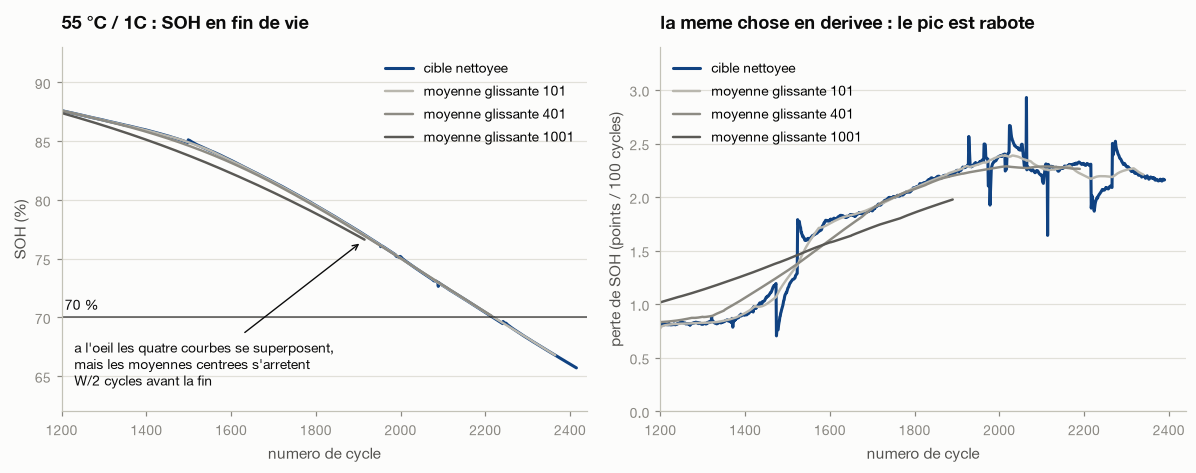

attenuation du pic de vitesse de perte par une moyenne glissante centree :
   25 °C / 0.5C  pic brut 1.29 pt/100 cycles | MA101 1.01 (-22 %) | MA401 1.20 (-7 %) | MA1001 0.77 (-40 %)
   25 °C / 1C    pic brut 2.46 pt/100 cycles | MA101 2.27 (-7 %) | MA401 2.00 (-19 %) | MA1001 1.35 (-45 %)
   35 °C / 1C    pic brut 2.87 pt/100 cycles | MA101 1.03 (-64 %) | MA401 1.22 (-58 %) | MA1001 0.78 (-73 %)
   45 °C / 0.5C  pic brut 3.51 pt/100 cycles | MA101 2.03 (-42 %) | MA401 1.79 (-49 %) | MA1001 1.65 (-53 %)
   45 °C / 1C    pic brut 1.90 pt/100 cycles | MA101 1.23 (-36 %) | MA401 1.41 (-26 %) | MA1001 0.90 (-53 %)
   55 °C / 1C    pic brut 2.93 pt/100 cycles | MA101 2.39 (-18 %) | MA401 2.29 (-22 %) | MA1001 1.98 (-33 %)

55 °C / 1C : le lissage deplace-t-il le passage a 70 % ?
   cible nettoyee : 70 % atteint au cycle 2219
   MA  101 centree  : ecart max au SOH reel  0.52 pt | 70 % au cycle 2220
   MA  101 causale  : ecart max au SOH reel  1.54 pt | 70 % au cycle 2270
   MA  401 centree  

In [39]:
S5_KNEE = "102Ah_55degC_1C_cell3"
S5_GREYS = {101: "#b9b7ae", 401: "#8d8b83", 1001: "#5a5955"}
s5_xi, s5_yi, _ = s5_regrid(S5_KNEE)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(s5_xi, s5_yi, **style(S5_KNEE), label="cible nettoyee")
axes[1].plot(s5_xi, s5_fade(s5_yi, s5_xi), **style(S5_KNEE), label="cible nettoyee")
for s5_W, s5_col in S5_GREYS.items():
    s5_ys = pd.Series(s5_yi).rolling(s5_W, center=True, min_periods=s5_W).mean().to_numpy()
    axes[0].plot(s5_xi, s5_ys, color=s5_col, lw=1.6, label=f"moyenne glissante {s5_W}")
    axes[1].plot(s5_xi, s5_fade(s5_ys, s5_xi), color=s5_col, lw=1.6, label=f"moyenne glissante {s5_W}")
axes[0].axhline(70, color=INK, lw=1.0, alpha=0.7)
axes[0].annotate("70 %", xy=(0.006, 70.4), xycoords=("axes fraction", "data"),
                 ha="left", va="bottom", fontsize=9, color=INK)
axes[0].annotate("a l'oeil les quatre courbes se superposent,\nmais les moyennes centrees s'arretent\nW/2 cycles avant la fin",
                 xy=(1914, 76.6), xytext=(1230, 64.2), fontsize=9, color=INK, ha="left",
                 arrowprops=dict(arrowstyle="->", color=INK, lw=0.9, shrinkA=4, shrinkB=4))
axes[0].set_xlim(1200, 2440); axes[0].set_ylim(62, 93)
axes[1].set_xlim(1200, 2440); axes[1].set_ylim(0, 3.4)
finish(axes[0], "55 °C / 1C : SOH en fin de vie", "numero de cycle", "SOH (%)", ncol=1)
finish(axes[1], "la meme chose en derivee : le pic est rabote", "numero de cycle",
       "perte de SOH (points / 100 cycles)", ncol=1)
fig.tight_layout(); plt.show()

print("attenuation du pic de vitesse de perte par une moyenne glissante centree :")
for cid, T, C in CELLS:
    s5_xj, s5_yj, s5_ok = s5_regrid(cid)
    s5_g0 = np.where(s5_ok, s5_fade(s5_yj, s5_xj), np.nan); s5_m = s5_xj > 200
    s5_i0 = int(np.nanargmax(np.where(s5_m, s5_g0, np.nan)))
    s5_txt = []
    for s5_W in S5_GREYS:
        s5_ys = pd.Series(s5_yj).rolling(s5_W, center=True, min_periods=s5_W).mean().to_numpy()
        s5_g = np.where(s5_ok, s5_fade(s5_ys, s5_xj), np.nan)
        s5_pic = s5_g[int(np.nanargmax(np.where(s5_m, s5_g, np.nan)))]
        s5_txt.append(f"MA{s5_W} {s5_pic:.2f} ({100*(s5_pic/s5_g0[s5_i0]-1):+.0f} %)")
    print(f"   {label(cid):13s} pic brut {s5_g0[s5_i0]:.2f} pt/100 cycles | " + " | ".join(s5_txt))

print(f"\n{label(S5_KNEE)} : le lissage deplace-t-il le passage a 70 % ?")
print(f"   cible nettoyee : 70 % atteint au cycle {int(s5_xi[np.argmax(s5_yi <= 70)])}")
for s5_W in S5_GREYS:
    for s5_nom, s5_kw in [("centree", dict(center=True, min_periods=s5_W)),
                          ("causale", dict(center=False, min_periods=s5_W))]:
        s5_ys = pd.Series(s5_yi).rolling(s5_W, **s5_kw).mean().to_numpy()
        s5_c = int(s5_xi[np.argmax(s5_ys <= 70)]) if np.nanmin(s5_ys) <= 70 else None
        print(f"   MA {s5_W:4d} {s5_nom:8s} : ecart max au SOH reel {np.nanmax(np.abs(s5_ys-s5_yi)):5.2f} pt"
              f" | 70 % au cycle {s5_c}")

### 5.7 Conclusion : quelle courbe donner à l'entraînement

Le panneau de gauche est le piège en image : les quatre courbes de SOH se superposent à
l'œil. Le panneau de droite montre ce qui a été perdu. Le lissage coûte cher et ne rapporte
rien :

- Sur le 55 °C/1C, le pic de vitesse de perte passe de **2.93 pt/100 cycles à 2.39 (−18 %)**
  avec une moyenne glissante de 101 cycles, **2.29 (−22 %)** à 401 et **1.98 (−33 %)** à
  1001. Sur l'ensemble des six cellules, l'atténuation va de **−7 % à −64 %** dès W = 101 et
  de **−33 % à −73 %** à W = 1001, le maximum étant atteint sur le 35 °C/1C. Le knee-point
  est littéralement effacé.
- Une moyenne **centrée** ne couvre pas les W/2 derniers cycles. Avec W = 401 ou 1001, la
  courbe lissée du 55 °C **n'atteint jamais 70 %** — le lissage supprime précisément la
  partie de la trajectoire que le challenge demande de prédire.
- Une moyenne **causale** (la seule utilisable en ligne) décale la courbe : jusqu'à
  **10.92 points d'écart** au SOH réel avec W = 1001, 4.87 avec W = 401, et un passage à
  70 % retardé de **51 cycles** dès W = 101.
- Et le bénéfice serait nul : le bruit vaut 0.0007 à 0.0102 point, alors que le biais
  introduit par le lissage va de 0.52 à 10.92 points — deux à quatre ordres de grandeur
  au-dessus de ce qu'il prétend corriger.

**Recommandation.** Entraîner sur la **cible nettoyée par des critères structurels**, sans
aucun lissage :

1. définition officielle stricte (`Q_cc_discharge_max / 102 Ah`) — jamais `Q/Q₀` en sortie ;
2. conserver le filtre du framework (il est le seul à attraper les décharges tronquées type
   cycle 2397) ;
3. rejeter les cycles **sans étape de charge** (déterministe, physiquement motivé, il
   attrape les 4 cas que le framework laisse passer) ;
4. rejeter les cycles **dupliqués** (empreinte identique) — indispensable sur 45 °C/0.5C ;
5. filtre MAD avec plancher, en dernier recours et journalisé, jamais en premier ;
6. **pas de moyenne glissante**, pas de spline lissante, pas de filtre Savitzky-Golay large.

Si une régularisation est nécessaire, la faire porter sur le **modèle** (forme fonctionnelle
monotone décroissante avec accélération, ou contrainte de monotonie), pas sur les données :
c'est le modèle qui doit être lisse, pas la cible.

Deux avertissements pour la suite :

- Le budget réduit (moins de cellules, cycles de début de vie) enlève les trois seules
  trajectoires qui descendent sous 70 %. Le repli doit reposer sur une **loi paramétrique
  pré-entraînée** dont seuls quelques coefficients sont recalés, pas sur un apprentissage
  de la forme du knee.
- Les marches de vieillissement calendaire (jusqu'à −1.58 point) ne sont prédictibles par
  aucun modèle en `(T, C)` seuls : elles fixent un plancher d'erreur d'environ 0.5 à
  1.5 point sur les cellules qui ont subi de longues interruptions.

## 6 · — Knee-point et dynamique de vieillissement

# 6. Knee-point et dynamique de vieillissement

Le sujet demande explicitement de prédire la trajectoire **knee-point inclus**. Avant de construire un modèle, il faut donc trancher trois questions avec les données :

1. **Le knee est-il visible ?** Sur quelles cellules, et à quel cycle ?
2. **Est-il localisable de façon fiable ?** Un knee-point n'est pas une grandeur mesurée, c'est le résultat d'une convention de détection. Si deux méthodes raisonnables donnent 3 700 et 4 500 cycles, annoncer « le knee est à 4 140 » sans intervalle donnerait une cible d'entraînement fausse.
3. **Qu'est-ce qui est constant d'une condition à l'autre ?** Si le knee arrive toujours au *même SOH*, on peut l'ancrer sur une variable observable et le modèle n'a qu'à prédire *quand* ce SOH est atteint. S'il arrive à une *fraction constante de la vie*, il faut d'abord prédire la fin de vie — ce qui est circulaire. Cette réponse oriente toute l'architecture.

On regarde ensuite le **taux de fade avant knee** et sa dépendance en température et en C-rate, pour savoir ce qu'on a le droit d'extrapoler vers les conditions jamais vues.

**Préparation.** Le SOH officiel (`soh_official`) est nettoyé de ses décharges avortées (chute > 2 points par rapport à la médiane glissante de 31 cycles), puis lissé par un filtre médian de 11 cycles. La première cellule imprime aussi un tableau de qualité de série, parce que trois défauts vont peser sur toute l'interprétation : le **bruit** (faible), les **trous de cycles** (parfois énormes) et la **cohérence chronologique** de la numérotation des cycles.

In [40]:
from scipy.interpolate import make_smoothing_spline, PchipInterpolator
from scipy.optimize import least_squares, curve_fit

S6_NBREAK, S6_FLOOR = 200, 70.0     # fin du rodage ; plancher du domaine demandé

def s6_clean(cid, drop=2.0, med=11):
    """SOH officiel : décharges avortées écartées, puis filtre médian de 11 cycles.
    Renvoie (cycles, SOH lissé, table brute, masque des cycles écartés, résidu rms)."""
    s = soh_official(load_cell(cid, columns=["cycle_number", "step_type", "step_capacity_Ah"]))
    n, y = s.cycle_number.to_numpy(float), s.soh_percent.to_numpy(float)
    ref = pd.Series(y).rolling(31, center=True, min_periods=5).median().to_numpy()
    bad = ~(y > ref - drop)
    n, y = n[~bad], y[~bad]
    ys = pd.Series(y).rolling(med, center=True, min_periods=1).median().to_numpy()
    return n, ys, s, bad, float(np.sqrt(np.mean((y-ys)**2)))

def s6_cycle_at(n, y, level):
    """Premier croisement descendant de SOH = level (interpolation linéaire)."""
    i = np.where(y <= level)[0]
    if len(i) == 0: return np.nan
    i = i[0]
    if i == 0: return float(n[0])
    return float(n[i-1] + (level-y[i-1])*(n[i]-n[i-1])/(y[i]-y[i-1]))

def s6_brk(n, y, maxgap=40):
    """Coupe le trait dans les trous > maxgap : un trou ne doit pas passer pour un palier."""
    j = np.where(np.diff(n) > maxgap)[0]
    return (n, y) if not len(j) else (np.insert(n, j+1, np.nan), np.insert(y, j+1, np.nan))

S6, s6_qc = {}, []
for cid, T, C in CELLS:
    n, ys, s, bad, rms = s6_clean(cid); S6[cid] = (n, ys)
    ni = n.astype(int); d = np.diff(ni)
    g = load_cell(cid, columns=["cycle_number", "absolute_time"]).groupby("cycle_number")["absolute_time"].min()
    dt = pd.to_datetime(g).sort_index().diff().dt.total_seconds()/3600
    rec = dt[dt < 0]
    s6_qc.append(dict(condition=label(cid), mesures=len(ni), couverture_pct=round(100*len(ni)/ni[-1], 1),
                      trou_max=int(d.max()), trou_a=int(ni[np.argmax(d)]),
                      bruit_rms=round(rms, 3), ecartes=int(bad.sum()),
                      SOH_min_ecarte=(round(float(s.soh_percent[bad].min()), 1) if bad.sum() else np.nan),
                      h_par_cycle=round(float(dt[(dt.index > 300) & (dt.index < 1300)].median()), 2),
                      reculs_chrono=len(rec), recul_max_h=(round(float(-rec.min())) if len(rec) else 0),
                      reculs_a=list(rec.index[:3].astype(int))))
S6_SOH = {cid: PchipInterpolator(*S6[cid]) for cid in S6}

s6_mile = pd.DataFrame([{"condition": label(c), "n_dernier": int(S6[c][0][-1]),
    "SOH_final": round(float(S6[c][1][-1]), 1),
    **{f"N{l}": (np.nan if np.isnan(v) else int(round(v))) for l in (95,90,85,80,75,70) for v in [s6_cycle_at(*S6[c], l)]}}
    for c, T, C in CELLS])
print("-- jalons de SOH (cycle du premier passage sous le seuil)")
print(s6_mile.to_string(index=False))
print("\n-- qualite de la serie de SOH")
print(pd.DataFrame(s6_qc).to_string(index=False))

-- jalons de SOH (cycle du premier passage sous le seuil)
   condition  n_dernier  SOH_final  N95    N90    N85    N80    N75    N70
25 °C / 0.5C       1375       93.1  732    NaN    NaN    NaN    NaN    NaN
  25 °C / 1C       5307       66.3  743 1886.0 3333.0 4329.0 4883.0 5142.0
  35 °C / 1C       5356       72.6  778 1914.0 3152.0 4345.0 5098.0    NaN
45 °C / 0.5C       4501       58.7  520 1410.0 2234.0 2860.0 3247.0 3544.0
  45 °C / 1C       2396       84.8  486 1407.0 2368.0    NaN    NaN    NaN
  55 °C / 1C       2415       65.8  340  910.0 1489.0 1778.0 2005.0 2218.0

-- qualite de la serie de SOH
   condition  mesures  couverture_pct  trou_max  trou_a  bruit_rms  ecartes  SOH_min_ecarte  h_par_cycle  reculs_chrono  recul_max_h           reculs_a
25 °C / 0.5C      988            71.9       371    1001      0.031        0             NaN         4.94              0            0                 []
  25 °C / 1C     4155            78.3       475    1887      0.034        1       

Les jalons `N80` retrouvent, **à un cycle près**, les valeurs déjà établies pour ce jeu (4329 / 4345 / 2860 / 1778, contre 4330 / 4345 / 2860 / 1778) : la chaîne de nettoyage ne déplace rien.

Quatre remarques qui conditionnent la suite :

- **Le domaine cible n'est atteint que par 3 cellules sur 6.** `N70` n'existe que pour 25 °C/1C (5142), 45 °C/0,5C (3544) et 55 °C/1C (2218). La cellule 35 °C/1C s'arrête à 72,6 % ; les deux autres à 93,1 % et 84,8 %. Toute statistique « en fraction de vie » sera donc bâtie sur très peu d'observations.
- **Le bruit n'est pas le problème.** L'écart rms au filtre médian vaut 0,018 à 0,034 point de SOH selon la cellule — deux ordres de grandeur sous la dynamique à modéliser. La difficulté du knee n'est pas le bruit de mesure, c'est la **définition**.
- **Les décharges avortées sont rares mais violentes** : 5 cycles écartés sur 45 °C/0,5C, 1 sur chacune de trois autres cellules. Le creux le plus profond est à 12,1 % de SOH apparent (45 °C/0,5C) ; le plus piégeur est le **tout dernier cycle de 45 °C/1C** (n = 2397), à 22,2 Ah soit 21,8 % — une cellule laissée telle quelle apprendrait une chute finale imaginaire.
- **La numérotation des cycles n'est pas toujours chronologique.** La cellule 45 °C/0,5C présente 2 reculs de temps absolu, dont un de **1067 h (44 jours)** au cycle 4222 : le bloc 4222-4462 a été enregistré *avant* le cycle 4155. Sur cette cellule, en fin de vie, `cycle_number` cesse d'être un index d'âge. On y reviendra, c'est ce qui produit le « rebond » de SOH visible plus bas. (25 °C/1C a 6 reculs mais de 10 h au plus, sans conséquence.)

**Première question : où faut-il chercher le knee ?** On regarde la *vitesse de fade locale* (pente de SOH sur une fenêtre glissante de 400 cycles, exigeant au moins 50 % de cycles mesurés dans la fenêtre pour ne pas être trompé par les trous) tracée non pas contre le cycle mais contre le SOH — ce qui met les six conditions sur une abscisse comparable.

-- rodage (fenetre 100 cycles) et plancher de fade (fenetre 400 cycles)
   25 °C / 0.5C   rodage : 2.82 pt/100cyc a n=51 -> passe sous 1,0 a n=211 | plancher 0.45 a n=951 (SOH 94.3) | fin 0.48 (x1.06)
   25 °C / 1C     rodage : 3.16 pt/100cyc a n=51 -> passe sous 1,0 a n=231 | plancher 0.31 a n=2401 (SOH 88.2) | fin 2.06 (x6.63)
   35 °C / 1C     rodage : 2.79 pt/100cyc a n=51 -> passe sous 1,0 a n=211 | plancher 0.34 a n=3301 (SOH 84.5) | fin 0.88 (x2.62)
   45 °C / 0.5C   rodage : 3.55 pt/100cyc a n=51 -> passe sous 1,0 a n=211 | plancher 0.51 a n=851 (SOH 93.1) | fin 1.76 (x3.45)
   45 °C / 1C     rodage : 3.64 pt/100cyc a n=51 -> passe sous 1,0 a n=251 | plancher 0.49 a n=1851 (SOH 87.8) | fin 0.56 (x1.14)
   55 °C / 1C     rodage : 3.81 pt/100cyc a n=51 -> passe sous 1,0 a n=421 | plancher 0.80 a n=751 (SOH 91.3) | fin 2.25 (x2.79)


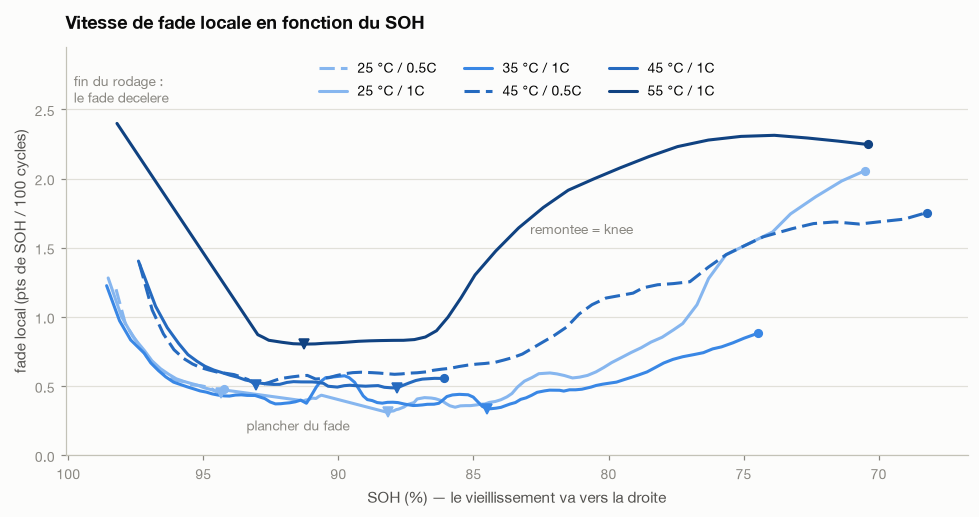

In [41]:
def s6_rate(n, y, win=400, step=50, cover=0.5):
    """Pente locale de SOH, en points de SOH par 100 cycles (positive = fade)."""
    xs, ys, rs = [], [], []
    for c in np.arange(n[0]+win/2, n[-1]-win/2+1, step):
        m = (n >= c-win/2) & (n <= c+win/2)
        if m.sum() < cover*win: continue          # fenêtre trop trouée -> on saute
        xs.append(c); ys.append(np.median(y[m])); rs.append(-np.polyfit(n[m], y[m], 1)[0]*100)
    return np.array(xs), np.array(ys), np.array(rs)

S6_RATE, S6_FLOOR_R = {}, {}
for cid, _, _ in CELLS:
    x, ym, r = s6_rate(*S6[cid]); k = ym >= 68; S6_RATE[cid] = (x[k], ym[k], r[k])
    xf, ymf, rf = S6_RATE[cid]; i0 = np.where(ymf < 99)[0][np.argmin(rf[ymf < 99])]
    S6_FLOOR_R[cid] = (float(xf[i0]), float(rf[i0]), int(i0))

print("-- rodage (fenetre 100 cycles) et plancher de fade (fenetre 400 cycles)")
for cid, _, _ in CELLS:
    xa, yma, ra = s6_rate(*S6[cid], win=100, step=10, cover=0.3)
    j = np.where(ra < 1.0)[0]
    x, ym, r = S6_RATE[cid]; n0, r0, i0 = S6_FLOOR_R[cid]
    print("   %-14s rodage : %.2f pt/100cyc a n=%.0f -> passe sous 1,0 a n=%.0f | plancher %.2f a n=%.0f (SOH %.1f) | fin %.2f (x%.2f)"
          % (label(cid), ra[0], xa[0], xa[j[0]] if len(j) else np.nan, r0, n0, ym[i0], r[-1], r[-1]/r0))

fig, ax = plt.subplots(figsize=(9, 4.8))
for cid, _, _ in CELLS:
    x, ym, r = S6_RATE[cid]
    ax.plot(ym, r, **style(cid), label=label(cid))
    ax.plot(ym[-1], r[-1], "o", ms=5, color=style(cid)["color"], zorder=5)
    n0, r0, i0 = S6_FLOOR_R[cid]
    ax.plot(ym[i0], r0, "v", ms=6, color=style(cid)["color"], zorder=5)
ax.invert_xaxis(); ax.set_ylim(0, 2.95)
for s6_t, s6_xy, s6_ha in (("fin du rodage :\nle fade decelere", (99.8, 2.55), "left"),
                           ("plancher du fade", (91.5, .18), "center"),
                           ("remontee = knee", (81, 1.60), "center")):
    ax.annotate(s6_t, xy=s6_xy, color=MUTED, fontsize=9, ha=s6_ha)
finish(ax, "Vitesse de fade locale en fonction du SOH", "SOH (%) — le vieillissement va vers la droite",
       "fade local (pts de SOH / 100 cycles)", legend=False)
ax.legend(loc="upper center", ncol=3); fig.tight_layout(); plt.show()

Les six courbes ont la **même forme en trois temps** — mais l'échelle en cycles de chaque phase varie énormément, et c'est ce qui compte :

1. **Rodage.** Sur une fenêtre courte (100 cycles), le fade part de 2,8-3,8 points/100 cycles au cycle 51 et **passe sous 1,0 entre n = 211 et n = 421** selon la cellule. C'est la partie brutale, et elle est finie avant le cycle 450 partout.
2. **Décélération lente puis plancher.** Le fade continue de baisser bien plus longtemps que le rodage ne le laisse croire. Le **plancher** (▼ sur le graphique) est atteint entre **n = 751** (55 °C, 0,80 pt/100 cyc) et **n = 3301** (35 °C, 0,34) ; les valeurs de plancher s'étalent de 0,31 (25 °C/1C, à n = 2401) à 0,80 (55 °C/1C). « Plateau » est donc un abus de langage : c'est un minimum peu marqué, pas un palier.
3. **Remontée.** Le fade réaccélère. C'est le knee, et c'est une courbure **concave**.

Deux conséquences méthodologiques directes, qui expliquent pourquoi une détection naïve échoue :

- Une recherche de « courbure maximale » lancée depuis le cycle 1 verrouille sur le **rodage**, pas sur le knee. On restreint donc la recherche à `n ≥ 200` (le rodage y est terminé partout sauf marginalement à 55 °C) et on n'accepte comme knee qu'un point où la dérivée seconde est **négative** (fade qui accélère).
- Le knee dépend de **où l'on coupe la courbe**. Pour comparer les six cellules on fixe la même fenêtre d'analyse que le challenge : `n ≥ 200` jusqu'au premier passage sous 70 % de SOH (ou la fin de l'enregistrement).

Deux cellules ne remontent jamais : **25 °C/0,5C** (plancher 0,45 à n = 951, encore 0,48 à l'arrêt, ×1,06) et **45 °C/1C** (plancher 0,49 à n = 1851, 0,56 à l'arrêt, ×1,14). On y revient en fin de section.

In [42]:
def s6_bin(n, y, K):
    """K médianes sur des tranches de cycle égales : robuste aux trous et au bruit."""
    e = np.linspace(n[0], n[-1], K+1); idx = np.clip(np.digitize(n, e)-1, 0, K-1)
    xb, yb = [], []
    for k in range(K):
        m = idx == k
        if m.sum(): xb.append(np.median(n[m])); yb.append(np.median(y[m]))
    return np.array(xb), np.array(yb)

def s6_knee_bw(n, y, gfrac=0.03):
    """M1 - Bacon-Watts : deux droites raccordées par un tanh de largeur fixée.
    Renvoie (cycle du knee, pente avant, pente apres) en pts de SOH / 100 cycles."""
    x = n/1000.0; g = gfrac*(x[-1]-x[0])
    f = lambda p: p[0]+p[1]*(x-p[3])+p[2]*(x-p[3])*np.tanh((x-p[3])/g)-y
    best = None
    for fr in (0.3, 0.5, 0.65, 0.8, 0.9):                      # multi-départ
        x0 = x[0]+fr*(x[-1]-x[0])
        r = least_squares(f, [np.interp(x0, x, y), (y[-1]-y[0])/(x[-1]-x[0]), -0.1, x0],
                          bounds=([-np.inf]*3+[x[0]+0.02*(x[-1]-x[0])], [np.inf]*3+[x[-1]-0.02*(x[-1]-x[0])]), max_nfev=20000)
        if best is None or np.sum(r.fun**2) < best[0]: best = (np.sum(r.fun**2), r)
    a0, a1, a2, x1 = best[1].x
    return x1*1000.0, (a1-a2)/10.0, (a1+a2)/10.0

def s6_knee_curv(n, y, K=50, lam=1e-4):
    """M2 - courbure maximale d'une spline lissante, axes normalises [0,1],
    restreinte aux points ou le fade ACCELERE (derivee seconde negative)."""
    xb, yb = s6_bin(n, y, K)
    xn = (xb-xb[0])/(xb[-1]-xb[0]); yn = (yb-yb.min())/(yb.max()-yb.min())
    sp = make_smoothing_spline(xn, yn, lam=lam)
    g = np.linspace(0, 1, 2001); d1, d2 = sp.derivative(1)(g), sp.derivative(2)(g)
    kap = np.where(d2 < 0, np.abs(d2)/(1+d1**2)**1.5, 0.0)
    return np.nan if kap.max() <= 0 else xb[0]+g[np.argmax(kap)]*(xb[-1]-xb[0])

def s6_knee_chord(n, y, K=200):
    """M3 - Kneedle : ecart maximal AU-DESSUS de la corde joignant les extremites."""
    xb, yb = s6_bin(n, y, K)
    xn = (xb-xb[0])/(xb[-1]-xb[0]); yn = (yb-yb.min())/(yb.max()-yb.min())
    d = yn-(yn[0]+(yn[-1]-yn[0])*xn)
    return np.nan if d.max() <= 1e-6 else xb[0]+xn[np.argmax(d)]*(xb[-1]-xb[0])

def s6_knee_rate(cid, fac=1.5):
    """M4 - critere physique : premier cycle ou le fade local depasse 1,5 x son plancher."""
    x, ym, r = S6_RATE[cid]; i0 = S6_FLOOR_R[cid][2]
    j = np.where((np.arange(len(r)) > i0) & (r > fac*r[i0]))[0]
    return np.nan if len(j) == 0 else float(x[j[0]])

def s6_sharp(cid, k, half=300):
    """Nettete du knee : pente du taux de fade autour du knee,
    en (pts de SOH / 100 cycles) gagnes par 1000 cycles."""
    x, ym, r = S6_RATE[cid]; m = (x >= k-half) & (x <= k+half)
    return np.polyfit(x[m], r[m], 1)[0]*1000 if m.sum() >= 3 else np.nan

def s6_window(cid, floor=S6_FLOOR):
    n, y = S6[cid]; e = s6_cycle_at(n, y, floor)
    if np.isnan(e): e = n[-1]
    m = (n >= S6_NBREAK) & (n <= e); return n[m], y[m]

s6_rows = []
for cid, T, C in CELLS:
    nw, yw = s6_window(cid); kb, s1, s2 = s6_knee_bw(nw, yw)
    est = np.array([kb, s6_knee_curv(nw, yw), s6_knee_chord(nw, yw), s6_knee_rate(cid)], float)
    has = (s2/s1 > 1.4) and np.isfinite(est[3])          # knee retenu seulement si le fade accelere
    k = np.nanmedian(est) if has else np.nan
    s6_rows.append(dict(condition=label(cid), cid=cid, BW=est[0], courbure=est[1], corde=est[2], taux_x1p5=est[3],
                        ratio_pentes=s2/s1, knee=k, etendue=np.nanmax(est)-np.nanmin(est) if has else np.nan,
                        nettete=s6_sharp(cid, k) if has else np.nan))
s6_knee = pd.DataFrame(s6_rows)
s6_knee["SOH_knee"] = [np.nan if np.isnan(k) else float(S6_SOH[c](k)) for c, k in zip(s6_knee.cid, s6_knee.knee)]
print(s6_knee.drop(columns="cid").round(2).to_string(index=False))

s6_kk = s6_knee.set_index("cid")

   condition      BW  courbure  corde  taux_x1p5  ratio_pentes    knee  etendue  nettete  SOH_knee
25 °C / 0.5C  774.03    845.83  208.5        NaN          0.57     NaN      NaN      NaN       NaN
  25 °C / 1C 4386.97   4474.52 3893.5     3751.0          3.00 4140.23   723.52     0.19     81.15
  35 °C / 1C 4508.24   4581.92 4183.0     4301.0          1.80 4404.62   398.92     0.32     79.69
45 °C / 0.5C 2689.65   2640.69 2683.0     2551.0          2.27 2661.85   138.65     1.05     81.93
  45 °C / 1C  572.45   1979.42 2336.0        NaN          0.70     NaN      NaN      NaN       NaN
  55 °C / 1C 1559.91   1471.65 1507.0     1501.0          2.55 1504.00    88.26     2.57     84.97


Quatre détecteurs, quatre logiques différentes — changement de pente (Bacon-Watts), géométrie locale (courbure), géométrie globale (corde), et seuil physique sur le taux de fade. Ils convergent, mais **inégalement** :

| condition | BW | courbure | corde | taux ×1,5 | **consensus** | étendue | netteté | SOH au knee |
|---|---|---|---|---|---|---|---|---|
| 55 °C / 1C | 1560 | 1472 | 1507 | 1501 | **1504** | 88 | 2,57 | 85,0 % |
| 45 °C / 0,5C | 2690 | 2641 | 2683 | 2551 | **2662** | 139 | 1,05 | 81,9 % |
| 35 °C / 1C | 4508 | 4582 | 4183 | 4301 | **4405** | 399 | 0,32 | 79,7 % |
| 25 °C / 1C | 4387 | 4475 | 3894 | 3751 | **4140** | 724 | 0,19 | 81,1 % |

La lecture importante n'est pas la médiane, c'est **l'étendue** : elle passe de 88 cycles à 55 °C à 724 cycles à 25 °C. Ce n'est pas un défaut des méthodes, et la colonne `nettete` le montre : c'est la pente du taux de fade autour du knee (en pts/100 cyc gagnés par 1000 cycles), **2,57 à 55 °C contre 0,19 à 25 °C — un facteur 13**, exactement monotone avec l'étendue. Autrement dit, **plus le knee est doux, moins il est localisable** : ce n'est pas une incertitude de méthode, c'est une incertitude physique. Un modèle qui optimise une erreur sur « le cycle du knee » sera donc dominé par du bruit de convention aux basses températures. (Avec 4 points seulement, et un seul à 0,5C, on constate cette monotonie — on ne la démontre pas ; température et C-rate y restent partiellement confondus.)

Deux cellules sont explicitement déclarées **sans knee** : le rapport pente-après / pente-avant du modèle bilinéaire vaut 0,57 (25 °C/0,5C) et 0,70 (45 °C/1C), c'est-à-dire que le fade *décélère* encore. Bacon-Watts leur trouve quand même un point de rupture (774 et 572 cycles) : c'est la fin du rodage, pas un knee. Sans le garde-fou `ratio_pentes > 1,4`, on aurait annoté deux knees fantômes.

floor                                   70 %    72 %    75 %    78 %     fin
cid                     methode                                             
102Ah_25degC_1C_cell3   Bacon-Watts   4387.0  4273.0  4048.0  3873.0  4520.0
                        corde max     3894.0  3772.0  3769.0  3772.0  4350.0
                        courbure max  4475.0  3640.0  1558.0  3731.0  4488.0
102Ah_35degC_1C_cell1   Bacon-Watts      NaN     NaN  4412.0     NaN  4508.0
                        corde max        NaN     NaN  4180.0     NaN  4183.0
                        courbure max     NaN     NaN  1622.0     NaN  4582.0
102Ah_45degC_0p5C_cell3 Bacon-Watts   2690.0  2647.0  2578.0  2503.0  2667.0
                        corde max     2683.0  2596.0  2523.0  2460.0  2684.0
                        courbure max  2641.0  2661.0  2629.0  2605.0  4232.0
102Ah_55degC_1C_cell3   Bacon-Watts   1560.0  1551.0  1533.0  1514.0  1569.0
                        corde max     1507.0  1508.0  1504.0  1508.0  1512.0

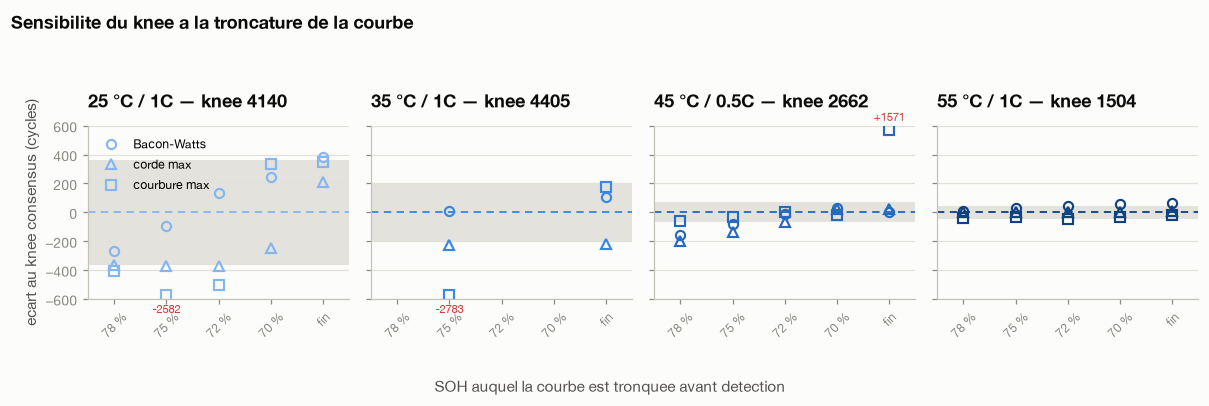

In [43]:
s6_sens = []
for cid, T, C in CELLS:
    n, y = S6[cid]
    for floor in (78, 75, 72, 70, None):            # None = on garde tout l'enregistrement
        e = n[-1] if floor is None else s6_cycle_at(n, y, floor)
        if np.isnan(e): continue
        m = (n >= S6_NBREAK) & (n <= e); nw, yw = n[m], y[m]
        if len(nw) < 300: continue
        kb, s1, s2 = s6_knee_bw(nw, yw)
        if s2/s1 < 1.4: continue
        for meth, k in (("Bacon-Watts", kb), ("courbure max", s6_knee_curv(nw, yw)), ("corde max", s6_knee_chord(nw, yw))):
            if np.isfinite(k):
                s6_sens.append(dict(cid=cid, floor="fin" if floor is None else f"{floor} %", methode=meth,
                                    knee=k, SOH=float(S6_SOH[cid](k))))
s6_sens = pd.DataFrame(s6_sens)
print(s6_sens.pivot_table(index=["cid","methode"], columns="floor", values="knee").round(0).to_string())

s6_kcells = [c for c in s6_knee.cid if np.isfinite(s6_kk.knee[c])]
S6_MARK = {"Bacon-Watts":"o", "courbure max":"s", "corde max":"^"}; S6_ORDER = ["78 %","75 %","72 %","70 %","fin"]
S6_LIM = 600
fig, axes = plt.subplots(1, 4, figsize=(11, 3.6), sharey=True)
for ax, cid in zip(axes, s6_kcells):
    d = s6_sens[s6_sens.cid == cid]; ref = s6_kk.loc[cid]
    ax.axhspan(-ref.etendue/2, ref.etendue/2, color=GRID, alpha=.9, lw=0)
    ax.axhline(0, color=style(cid)["color"], lw=1.2, ls=(0, (4, 3)))
    for m, g in d.groupby("methode"):
        xs = [S6_ORDER.index(f) for f in g.floor]; dev = (g.knee-ref.knee).to_numpy()
        ax.plot(xs, np.clip(dev, -S6_LIM*.95, S6_LIM*.95), S6_MARK[m], ms=6, mfc="none", mew=1.4,
                color=style(cid)["color"], label=m if cid == s6_kcells[0] else None)
        for xx, dv in zip(xs, dev):
            if abs(dv) > S6_LIM*.95:
                ax.annotate("%+.0f" % dv, xy=(xx, np.sign(dv)*S6_LIM*.95), xytext=(0, 9*np.sign(dv)-3),
                            textcoords="offset points", fontsize=7.5, color=STATUS["critical"], ha="center")
    ax.set_xticks(range(5)); ax.set_xticklabels(S6_ORDER, rotation=45, fontsize=8)
    ax.set_xlim(-.5, 4.5); ax.set_ylim(-S6_LIM, S6_LIM)
    finish(ax, "%s — knee %.0f" % (label(cid), ref.knee), None,
           "ecart au knee consensus (cycles)" if cid == s6_kcells[0] else None, legend=False)
axes[0].legend(loc="upper left", ncol=1, fontsize=8)
fig.suptitle("Sensibilite du knee a la troncature de la courbe", x=.005, ha="left", fontsize=12, fontweight="600", color=INK)
fig.supxlabel("SOH auquel la courbe est tronquee avant detection", fontsize=10, color="#52514e")
fig.tight_layout(rect=(0, .02, 1, .92)); plt.show()

On refait la détection en tronquant la courbe à 78, 75, 72, 70 % puis en gardant tout. C'est le test qui compte pour nous : **au moment de prédire, on ne connaît pas la fin de la courbe**. Une méthode qui ne donne le bon knee qu'une fois la cellule morte est inutilisable comme cible. Les quatre panneaux partagent la même échelle verticale (écart au knee consensus), la bande grise étant l'étendue inter-méthodes du tableau précédent.

- **55 °C/1C** : totalement stable, 1454-1569 cycles quelle que soit la troncature — moins de ±60 cycles. Le knee est déjà identifiable en ne voyant la cellule que jusqu'à 78 % de SOH.
- **45 °C/0,5C** : stable aussi (2460-2690, soit −200/+30) tant qu'on reste au-dessus de 70 %. En gardant tout l'enregistrement la méthode courbure saute à 4232 (+1571), où le SOH vaut 64,1 % : elle a trouvé un **second** effondrement, hors du domaine du challenge — et qui, on le verra, est un artefact de numérotation.
- **25 °C/1C** : le knee glisse de 3731 à 4520 cycles selon la troncature (−409/+380), et la méthode courbure décroche complètement à 1558 (−2582) quand on coupe à 75 %.
- **35 °C/1C** : les colonnes 72 % et 70 % sont vides parce que la cellule s'arrête à 72,6 % — elle ne les atteint jamais. Mais la colonne 78 % est vide pour une autre raison : le critère `ratio_pentes > 1,4` n'y est **pas rempli**, aucune méthode ne voit de knee. Le knee de cette cellule n'apparaît que dans les ~950 derniers cycles de l'enregistrement, et la méthode courbure y décroche aussi (−2783 à 75 %).

**Conséquence pour la modélisation :** le cycle du knee est une cible bruitée dont l'incertitude propre vaut ±60 cycles à 55 °C mais ±400 cycles à 25 °C. Pondérer une perte « knee » uniformément reviendrait à faire apprendre du bruit au modèle sur les conditions froides. Mieux vaut apprendre la trajectoire complète et laisser le knee émerger.

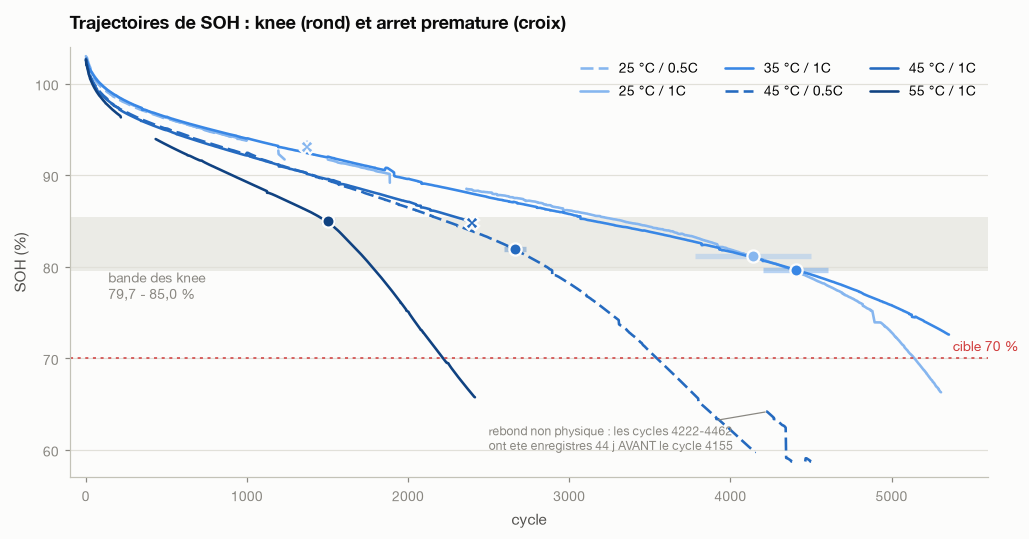

In [44]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for cid, _, _ in CELLS:
    ax.plot(*s6_brk(*S6[cid]), **style(cid), label=label(cid), lw=1.7)
    n, y = S6[cid]; k = s6_kk.knee[cid]
    if np.isfinite(k):
        e = s6_kk.etendue[cid]
        ax.plot([k-e/2, k+e/2], [S6_SOH[cid](k)]*2, color=style(cid)["color"], lw=3.5, alpha=.35, solid_capstyle="butt")
        ax.plot(k, S6_SOH[cid](k), "o", ms=8, color=style(cid)["color"], mec=SURFACE, mew=1.5, zorder=6)
    else:
        ax.plot(n[-1], y[-1], "X", ms=9, color=style(cid)["color"], mec=SURFACE, mew=1.5, zorder=6)
ax.axhline(70, color=STATUS["critical"], lw=1, ls=(0, (2, 3)))
ax.annotate("cible 70 %", xy=(5380, 70.8), color=STATUS["critical"], fontsize=9)
ax.axhspan(79.5, 85.5, color=GRID, alpha=.6, lw=0, zorder=0)
ax.annotate("bande des knee\n79,7 - 85,0 %", xy=(140, 76.5), color=MUTED, fontsize=9)
ax.annotate("rebond non physique : les cycles 4222-4462\nont ete enregistres 44 j AVANT le cycle 4155", xy=(4235, 64.2),
            xytext=(2500, 60.0), color=MUTED, fontsize=8, arrowprops=dict(arrowstyle="-", color=MUTED, lw=.8))
ax.set_ylim(57, 104); ax.set_xlim(-100, 5600)
finish(ax, "Trajectoires de SOH : knee (rond) et arret premature (croix)", "cycle", "SOH (%)", ncol=3)
fig.tight_layout(); plt.show()

Le rond marque le knee consensus, la barre horizontale l'étendue des quatre estimateurs, la croix la fin prématurée des deux cellules sans knee. Les traits sont **coupés dans les trous de plus de 40 cycles** : un trou ne doit pas se lire comme un palier de SOH (on voit ainsi le trou de 371 cycles de 25 °C/0,5C et celui de 475 cycles de 25 °C/1C).

Ce qui saute aux yeux : **les quatre knees tombent dans une bande étroite de SOH**, 79,7 à 85,0 %, alors que leurs cycles s'étalent de 1504 à 4405 — un facteur 2,9. Le knee semble donc bien plus lié à l'**état** de la cellule qu'à son **âge**. C'est exactement l'hypothèse qu'il faut tester quantitativement, parce qu'elle décide de l'architecture du modèle.

**Le « rebond » de 45 °C/0,5C n'est pas une régénération.** En fin de vie sa SOH remonte de 59,8 % (n = 4155) à 64,2 % (n = 4222) avant de rechuter. Le tableau de qualité donne la cause : cette cellule a 2 reculs chronologiques, dont un de **1067 h** au cycle 4222. Les cycles 4222-4462 ont été enregistrés 44 jours *avant* le cycle 4155 — la cellule y était réellement plus jeune. C'est sous 70 %, donc hors domaine, mais cette zone doit être **exclue de tout entraînement**, et c'est elle qui fabriquait le « second knee » à n = 4232 vu au paragraphe précédent.

In [45]:
# N70 de la cellule 35 °C est extrapolé : elle s'arrête à 72,6 %.
n35, y35 = S6["102Ah_35degC_1C_cell1"]; m = n35 > n35[-1]-400
s6_p35 = np.polyfit(n35[m], y35[m], 1)[0]
s6_N70 = {c: s6_cycle_at(*S6[c], 70.0) for c, _, _ in CELLS}
s6_N70["102Ah_35degC_1C_cell1"] = n35[-1]+(70-y35[-1])/s6_p35
print("N70(35 °C) extrapole = %.0f  (pente finale %.2f pt/100 cycles)" % (s6_N70["102Ah_35degC_1C_cell1"], s6_p35*100))

s6_h = pd.DataFrame({"cid": s6_kcells, "knee": [s6_kk.knee[c] for c in s6_kcells],
                     "SOH_knee": [s6_kk.SOH_knee[c] for c in s6_kcells], "N70": [s6_N70[c] for c in s6_kcells]})
s6_h["frac_vie"] = s6_h.knee/s6_h.N70
for nm, v in (("SOH au knee (%)", s6_h.SOH_knee), ("n_knee / N70", s6_h.frac_vie)):
    print("%-16s moy %.3f  sd %.3f  CV %.1f %%  etendue %.3f - %.3f"
          % (nm, v.mean(), v.std(ddof=1), 100*v.std(ddof=1)/v.mean(), v.min(), v.max()))

# arbitrage : chaque hypothese est calibree sur les 3 AUTRES cellules puis testee
s6_e1, s6_e2 = [], []
for i, r in s6_h.iterrows():
    s6_o = s6_h.drop(index=i)
    p1 = s6_cycle_at(*S6[r.cid], s6_o.SOH_knee.mean()); p2 = s6_o.frac_vie.mean()*r.N70
    s6_e1.append(p1-r.knee); s6_e2.append(p2-r.knee)
    print("  %-14s knee %5.0f | H1 (SOH %.1f %%) -> %5.0f  ecart %+5.0f | H2 (f %.3f) -> %5.0f  ecart %+5.0f"
          % (label(r.cid), r.knee, s6_o.SOH_knee.mean(), p1, s6_e1[-1], s6_o.frac_vie.mean(), p2, s6_e2[-1]))
print("  MAE  H1 = %.0f cycles   H2 = %.0f cycles" % (np.mean(np.abs(s6_e1)), np.mean(np.abs(s6_e2))))

s6_Tv = np.array([COND[c][0] for c in s6_h.cid], float); s6_A = np.polyfit(s6_Tv, s6_h.SOH_knee, 1)
s6_R2 = 1-np.sum((s6_h.SOH_knee-np.polyval(s6_A, s6_Tv))**2)/np.sum((s6_h.SOH_knee-s6_h.SOH_knee.mean())**2)
print("  SOH_knee = %.1f + %.3f x T(°C)   R2 = %.2f   (n = 4)" % (s6_A[1], s6_A[0], s6_R2))

N70(35 °C) extrapole = 5650  (pente finale -0.89 pt/100 cycles)
SOH au knee (%)  moy 81.935  sd 2.226  CV 2.7 %  etendue 79.688 - 84.967
n_knee / N70     moy 0.753  sd 0.055  CV 7.3 %  etendue 0.678 - 0.805
  25 °C / 1C     knee  4140 | H1 (SOH 82.2 %) ->  3924  ecart  -216 | H2 (f 0.736) ->  3786  ecart  -355
  35 °C / 1C     knee  4405 | H1 (SOH 82.7 %) ->  3791  ecart  -614 | H2 (f 0.745) ->  4208  ecart  -197
  45 °C / 0.5C   knee  2662 | H1 (SOH 81.9 %) ->  2662  ecart    -0 | H2 (f 0.754) ->  2673  ecart   +11
  55 °C / 1C     knee  1504 | H1 (SOH 80.9 %) ->  1732  ecart  +228 | H2 (f 0.779) ->  1727  ecart  +223
  MAE  H1 = 264 cycles   H2 = 196 cycles
  SOH_knee = 76.5 + 0.137 x T(°C)   R2 = 0.63   (n = 4)


### La question clef : SOH constant, ou fraction de vie constante ?

**H1 — SOH constant** : moyenne 81,9 %, écart-type 2,23 point, étendue 79,7-85,0 %.
**H2 — fraction de vie constante** (`n_knee / N70`) : moyenne 0,753, écart-type 0,055, étendue 0,678-0,805.

Les CV valent 2,7 % et 7,3 %, mais **on n'en conclut rien** : comparer le CV d'un SOH (dont le zéro est arbitraire, toutes les valeurs étant serrées autour de 82 sur 100) au CV d'une fraction n'a pas de sens. Le seul arbitrage honnête est prédictif : on calibre chaque hypothèse sur trois cellules et on prédit la quatrième. Résultat : **MAE 264 cycles pour H1, 196 cycles pour H2**. Avec n = 4, ces deux valeurs sont **indiscernables** — annoncer que l'une gagne serait surinterpréter. Les deux se trompent d'environ 200-300 cycles, et les deux ratent surtout 35 °C (−614 pour H1) et 55 °C (+228 / +223).

C'est pourtant H1 qu'il faut retenir, et pour une raison d'usage, pas de statistique : **H2 exige de connaître `N70`**, c'est-à-dire la réponse qu'on cherche. Elle est circulaire. H1 s'ancre sur une grandeur que le modèle produit de toute façon.

**Réponse opérationnelle** : *le knee arrive à SOH quasi constant, entre 79,7 et 85,0 %, ce qui correspond à 68-81 % de la vie utile (`N70`).* Un modèle qui reproduit correctement la trajectoire jusqu'à 85 % de SOH aura le knee au bon endroit à ±250-300 cycles sans qu'on ait besoin de le lui apprendre séparément.

Une dérive résiduelle existe : `SOH_knee = 76,5 + 0,137 × T(°C)`, R² = 0,63 — plus il fait chaud, plus le knee arrive tôt en SOH (79,7 % à 35 °C contre 85,0 % à 55 °C). **Quatre points, dont un seul à 0,5C, et le point le plus bas (35 °C) n'est pas le plus froid** : la relation n'est même pas monotone en T. À traiter comme une piste très faible, pas comme une loi.

**Point noir pour le budget réduit** : le plancher de fade n'est atteint qu'entre les cycles **751 et 3301** selon la cellule, et la remontée bien plus tard. Avec seulement des cycles de début de vie, le knee n'est **pas observable** — il devra être produit par un a priori paramétré en (T, C-rate), jamais lu dans les données.

-- exposant p ajuste librement, cellule par cellule (fenetre 1 -> knee)
   25 °C / 0.5C   n <=  1375   a=103.736  b=0.7169  p=0.379
   25 °C / 1C     n <=  4140   a=101.021  b=0.06007  p=0.690
   35 °C / 1C     n <=  4405   a=100.521  b=0.02911  p=0.780
   45 °C / 0.5C   n <=  2662   a= 99.896  b=0.0274  p=0.817
   45 °C / 1C     n <=  2396   a=100.960  b=0.1182  p=0.627
   55 °C / 1C     n <=  1504   a=101.530  b=0.1585  p=0.632

exposant commun p = 0.703
   condition  T   C        a      b    ln_b      N95    rms
25 °C / 0.5C 25 0.5 101.0153 0.0585 -2.8388 732.3636 0.3248
  25 °C / 1C 25 1.0 100.8870 0.0537 -2.9248 742.5556 0.3844
  35 °C / 1C 35 1.0 101.3702 0.0570 -2.8653 777.9180 0.3372
45 °C / 0.5C 45 0.5 100.9296 0.0699 -2.6605 520.0090 0.4424
  45 °C / 1C 45 1.0 100.2105 0.0632 -2.7608 485.6354 0.2997
  55 °C / 1C 55 1.0 100.8478 0.0913 -2.3935 339.7271 0.2548
Arrhenius 1C sur ln b      : Ea = 13.6 kJ/mol (0.14 eV)  R2 = 0.827  residus = [ 0.068 -0.051 -0.114  0.096] | sans 25 

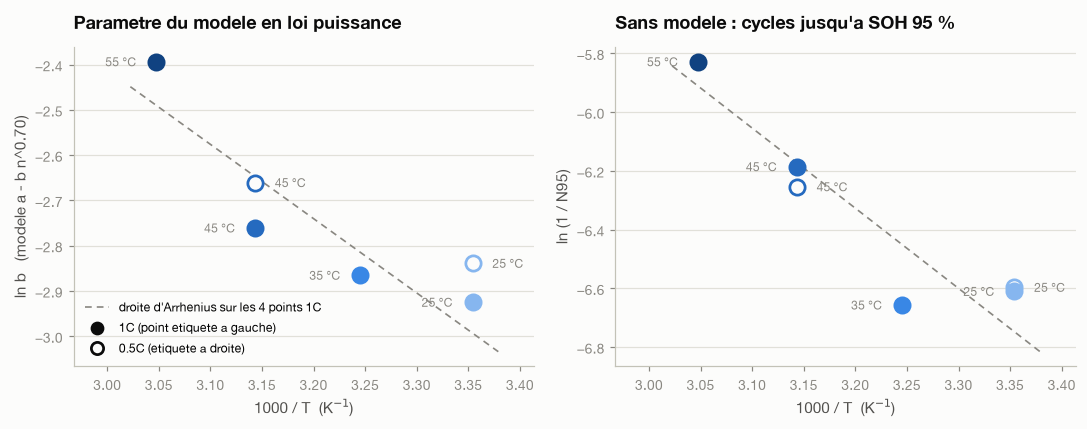

In [46]:
# Loi puissance SOH = a - b n^p, ajustee du cycle 1 jusqu'au knee (ou jusqu'a la fin sans knee)
s6_end = {c: (s6_kk.knee[c] if np.isfinite(s6_kk.knee[c]) else S6[c][0][-1]) for c, _, _ in CELLS}
S6_FIT = {c: (S6[c][0][S6[c][0] <= s6_end[c]], S6[c][1][S6[c][0] <= s6_end[c]]) for c, _, _ in CELLS}
print("-- exposant p ajuste librement, cellule par cellule (fenetre 1 -> knee)")
for cid, T, C in CELLS:
    p, _ = curve_fit(lambda n, a, b, p: a-b*n**p, *S6_FIT[cid], p0=[102.5, .05, .8], maxfev=50000)
    print("   %-14s n <= %5.0f   a=%7.3f  b=%.4g  p=%.3f" % (label(cid), s6_end[cid], *p))

# b n'est comparable entre cellules que si p est commun -> ajustement conjoint
def s6_res(th):
    p = th[0]
    return np.concatenate([(th[1+2*i]-th[2+2*i]*S6_FIT[c][0]**p-S6_FIT[c][1])/np.sqrt(len(S6_FIT[c][0]))
                           for i, (c, _, _) in enumerate(CELLS)])
s6_r = least_squares(s6_res, [.75]+sum([[102.5, .03] for _ in CELLS], []), max_nfev=100000)
S6_P = s6_r.x[0]
s6_pow = pd.DataFrame([{"condition": label(c), "T": T, "C": C, "cid": c, "a": s6_r.x[1+2*i], "b": s6_r.x[2+2*i],
                        "ln_b": np.log(s6_r.x[2+2*i]), "N95": s6_cycle_at(*S6[c], 95.0),
                        "rms": float(np.sqrt(np.mean((s6_r.x[1+2*i]-s6_r.x[2+2*i]*S6_FIT[c][0]**S6_P-S6_FIT[c][1])**2)))}
                       for i, (c, T, C) in enumerate(CELLS)])
print("\nexposant commun p = %.3f" % S6_P)
print(s6_pow.drop(columns="cid").round(4).to_string(index=False))

def s6_arr(T, v):
    x = 1000/(np.asarray(T, float)+273.15); v = np.asarray(v, float)
    A = np.polyfit(x, v, 1); pr = np.polyval(A, x)
    return A, 1-np.sum((v-pr)**2)/np.sum((v-v.mean())**2), -A[0]*8.314, v-pr
s6_o = s6_pow[s6_pow.C == 1.0].sort_values("T")
for nm, v in (("ln b", s6_o.ln_b.to_numpy()), ("ln(1/N95)", np.log(1/s6_o.N95.to_numpy()))):
    A, R2, Ea, res = s6_arr(s6_o["T"], v)
    A2, R22, Ea2, _ = s6_arr(s6_o["T"][1:], v[1:])
    print("Arrhenius 1C sur %-9s : Ea = %4.1f kJ/mol (%.2f eV)  R2 = %.3f  residus = %s | sans 25 °C : Ea = %.1f  R2 = %.3f"
          % (nm, Ea, Ea*1000/96485, R2, np.round(res, 3), Ea2, R22))
s6_half = s6_pow[s6_pow.C == .5].sort_values("T"); xh = 1000/(s6_half["T"].to_numpy()+273.15)
print("Arrhenius 0.5C (2 points seulement) : Ea(ln b) = %.1f | Ea(ln 1/N95) = %.1f kJ/mol"
      % (-(s6_half.ln_b.iloc[1]-s6_half.ln_b.iloc[0])/(xh[1]-xh[0])*8.314,
         -(np.log(1/s6_half.N95.iloc[1])-np.log(1/s6_half.N95.iloc[0]))/(xh[1]-xh[0])*8.314))
for T in (25, 45):
    s6_a = s6_pow[(s6_pow["T"] == T) & (s6_pow.C == 1.)].iloc[0]; s6_b = s6_pow[(s6_pow["T"] == T) & (s6_pow.C == .5)].iloc[0]
    print("   T = %d °C : b(1C)/b(0.5C) = %.3f   N95(0.5C)/N95(1C) = %.3f   duree d'un cycle : %.2f h a 1C vs %.2f h a 0.5C"
          % (T, s6_a.b/s6_b.b, s6_b.N95/s6_a.N95,
             [q["h_par_cycle"] for q in s6_qc if q["condition"] == label(s6_a.cid)][0],
             [q["h_par_cycle"] for q in s6_qc if q["condition"] == label(s6_b.cid)][0]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
for ax, v, yl, ttl in zip(axes, [s6_pow.ln_b.to_numpy(), np.log(1/s6_pow.N95.to_numpy())],
                          ["ln b   (modele a - b n^%.2f)" % S6_P, "ln (1 / N95)"],
                          ["Parametre du modele en loi puissance", "Sans modele : cycles jusqu'a SOH 95 %"]):
    xo = 1000/(s6_o["T"].to_numpy()+273.15); vo = v[[list(s6_pow.cid).index(c) for c in s6_o.cid]]
    A = np.polyfit(xo, vo, 1); gx = np.linspace(xo.min()-.025, xo.max()+.025, 10)
    ax.plot(gx, np.polyval(A, gx), color=MUTED, lw=1.1, ls=(0, (4, 3)), zorder=1,
            label="droite d'Arrhenius sur les 4 points 1C")
    for j, rr in s6_pow.reset_index(drop=True).iterrows():
        xx = 1000/(rr["T"]+273.15)
        ax.plot(xx, v[j], "o", ms=10, color=TEMP_COLOR[rr["T"]],
                mfc=TEMP_COLOR[rr["T"]] if rr.C == 1. else SURFACE, mew=1.8, zorder=4)
        ax.annotate("%d °C" % rr["T"], xy=(xx, v[j]),
                    xytext=(-13, -3) if rr.C == 1. else (13, -3), textcoords="offset points",
                    ha="right" if rr.C == 1. else "left", fontsize=8, color=MUTED)
    ax.plot([], [], "o", ms=8, color=INK, mfc=INK, label="1C (point etiquete a gauche)")
    ax.plot([], [], "o", ms=8, color=INK, mfc=SURFACE, mew=1.8, label="0.5C (etiquete a droite)")
    ax.set_xlim(gx.min()-.055, gx.max()+.035)
    finish(ax, ttl, "1000 / T  (K$^{-1}$)", yl, legend=False)
axes[0].legend(loc="lower left", ncol=1, fontsize=8)
fig.tight_layout(); plt.show()

### Taux de fade : ce qui est extrapolable, et ce qui ne l'est pas

Ajusté cellule par cellule, l'exposant `p` varie de 0,38 à 0,82 — donc **`b` seul n'est pas comparable d'une cellule à l'autre** (ses unités dépendent de `p`). On refait un ajustement conjoint à `p` commun : **p = 0,703**, résidu rms 0,25 à 0,44 point de SOH sur toute la phase pré-knee. C'est un modèle à deux paramètres par cellule qui tient à un demi-point près sur 1500 à 4400 cycles : la phase pré-knee est presque triviale à modéliser. **Toute la difficulté du challenge est après le knee.**

Le graphe de gauche est la vue Arrhenius, `ln b` contre `1000/T`. Le graphe de droite est un contrôle **sans modèle** : `ln(1/N95)`, l'inverse du nombre de cycles pour perdre 5 points de SOH, qui existe pour les 6 cellules (340 à 778 cycles) et est mesurable en tout début de vie.

**La linéarité d'Arrhenius est mauvaise, et pas au hasard.** R² = 0,827 (ln b) et 0,851 (ln 1/N95), avec des résidus au signe alterné `+ − − +` : c'est une courbure, pas du bruit. La cause est visible sur les deux panneaux : **25 °C et 35 °C sont confondus**. À 1C, N95 vaut 743 cycles à 25 °C contre 778 à 35 °C, N90 1886 contre 1914, N80 4329 contre 4345 ; sur les 2731 cycles communs de l'intervalle 200-4000, les trajectoires s'écartent en moyenne de +0,21 point (rms 0,42, max 1,46). Réchauffer de 25 à 35 °C ne change quasiment rien au vieillissement de cette cellule.

En retirant le point 25 °C, l'ajustement 35-55 °C devient excellent : **R² = 0,895 (Ea = 19,7 kJ/mol) sur `ln b` et R² = 0,996 (Ea = 34,9 kJ/mol) sur `ln 1/N95`** — mais ce sont trois points pour deux paramètres, donc un R² élevé n'y est presque pas informatif ; c'est l'écart du 4ᵉ point qui l'est.

**Ce qu'on peut extrapoler :**
- *Interpoler* entre 35 et 55 °C : oui, la loi d'Arrhenius y est compatible avec les trois points disponibles.
- *Interpoler* entre 25 et 35 °C : oui, mais en **plateau**, pas en Arrhenius — un modèle purement arrhénien y sous-estimera le vieillissement à 25 °C et le surestimera à 30-35 °C.
- *Extrapoler* sous 25 °C ou au-dessus de 55 °C : **non**. Quatre températures, dont deux confondues, ne contraignent pas une extrapolation.

**Le C-rate ne fait presque rien, par cycle.** `b(1C)/b(0,5C)` = 0,918 à 25 °C et 0,905 à 45 °C ; `N95(0,5C)/N95(1C)` = 0,99 et 1,07 ; à 45 °C, `N90` vaut 1407 cycles à 1C contre 1410 à 0,5C. L'effet du C-rate est donc **inférieur à 10 %**, à comparer au facteur 2,2 sur `N95` entre 25 et 55 °C (743 → 340 cycles). Or un cycle à 0,5C dure **4,8-4,9 h contre 2,9-3,0 h à 1C** (mesuré sur l'horodatage) : la cellule 0,5C passe 1,65 fois plus de temps au banc pour le même fade. Deux conséquences : (i) ni la durée calendaire ni l'amplitude du courant ne pilotent le fade — le compteur pertinent est le **débit de charge cyclé** ; (ii) sur le plan expérimental, le plan 0,5C/1,0C est **presque dégénéré** — on ne peut pas apprendre une dépendance en C-rate sur un effet de 10 % avec deux niveaux à deux températures seulement. Attention à ne pas laisser un modèle flexible fabriquer une fausse loi en C-rate.

ecart 25 °C / 1C     - 35 °C / 1C     sur 2731 cycles communs de [200, 4000] : moyen +0.21 pt, rms 0.42, max 1.46
ecart 45 °C / 0.5C   - 45 °C / 1C     sur 2064 cycles communs de [200, 2390] : moyen -0.14 pt, rms 0.38, max 0.95
ecart 25 °C / 0.5C   - 25 °C / 1C     sur  773 cycles communs de [200, 1370] : moyen -0.07 pt, rms 0.09, max 0.31
45 °C / 1C     : arret n=2396 SOH=84.79 ; knee du jumeau 45 °C / 0.5C n=2662 SOH=81.9 -> 266 cycles manquants (arret a 90 % du knee)
      son plancher de fade est a n=1851 (0.49 pt/100cyc) ; a l'arret le taux vaut 0.56 = 1.14 x le plancher
      jumeau : plancher a n=851 ; a n=2396 il etait deja a 1.35 x son plancher
25 °C / 0.5C   : arret n=1375 SOH=93.10 ; knee du jumeau 25 °C / 1C n=4140 SOH=81.1 -> 2765 cycles manquants (arret a 33 % du knee)
      son plancher de fade est a n=951 (0.45 pt/100cyc) ; a l'arret le taux vaut 0.48 = 1.06 x le plancher
      jumeau : plancher a n=2401 ; il n'avait meme pas atteint son propre plancher a n=1375


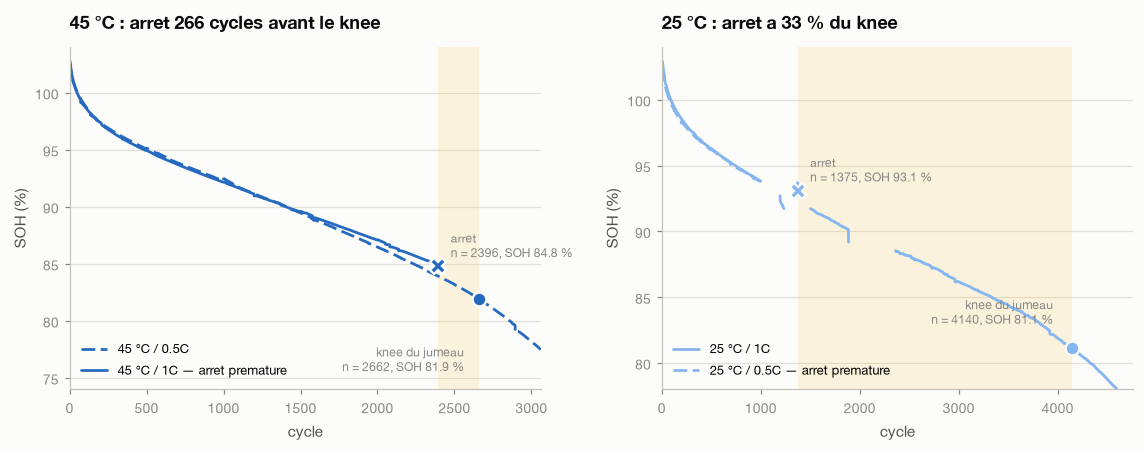

In [47]:
# Les deux trajectoires interrompues valent-elles quelque chose pour l'entrainement ?
def s6_pairdiff(a, b, lo, hi):
    """Ecart de SOH sur les cycles REELLEMENT mesures des deux cellules (pas d'interpolation
    a travers les trous, qui fabriquerait des ecarts fantomes)."""
    na, nb = S6[a][0].astype(int), S6[b][0].astype(int)
    c = np.intersect1d(na, nb); c = c[(c >= lo) & (c <= hi)]
    d = S6[a][1][np.isin(na, c)]-S6[b][1][np.isin(nb, c)]
    return c, d
for a, b, lo, hi in [("102Ah_25degC_1C_cell3", "102Ah_35degC_1C_cell1", 200, 4000),
                     ("102Ah_45degC_0p5C_cell3", "102Ah_45degC_1C_cell1", 200, 2390),
                     ("102Ah_25degC_0p5C_cell3", "102Ah_25degC_1C_cell3", 200, 1370)]:
    c, d = s6_pairdiff(a, b, lo, hi)
    print("ecart %-14s - %-14s sur %4d cycles communs de [%d, %d] : moyen %+.2f pt, rms %.2f, max %.2f"
          % (label(a), label(b), len(c), lo, hi, d.mean(), np.sqrt((d**2).mean()), np.abs(d).max()))

S6_PAIRS = [("102Ah_45degC_1C_cell1", "102Ah_45degC_0p5C_cell3", 74, "45 °C : arret 266 cycles avant le knee", (-10, -30), "right", "top"),
            ("102Ah_25degC_0p5C_cell3", "102Ah_25degC_1C_cell3", 78, "25 °C : arret a 33 % du knee", (-12, 14), "right", "bottom")]
for cut, tw, *_ in S6_PAIRS:
    n, y = S6[cut]; x, ym, rr = S6_RATE[cut]; n0, r0, i0 = S6_FLOOR_R[cut]
    xt, ymt, rt = S6_RATE[tw]; n0t, r0t, i0t = S6_FLOOR_R[tw]
    print("%-14s : arret n=%.0f SOH=%.2f ; knee du jumeau %s n=%.0f SOH=%.1f -> %.0f cycles manquants (arret a %.0f %% du knee)"
          % (label(cut), n[-1], y[-1], label(tw), s6_kk.knee[tw], s6_kk.SOH_knee[tw], s6_kk.knee[tw]-n[-1], 100*n[-1]/s6_kk.knee[tw]))
    print("      son plancher de fade est a n=%.0f (%.2f pt/100cyc) ; a l'arret le taux vaut %.2f = %.2f x le plancher"
          % (n0, r0, rr[-1], rr[-1]/r0))
    print("      jumeau : plancher a n=%.0f ; %s" % (n0t,
          ("a n=%.0f il etait deja a %.2f x son plancher" % (n[-1], np.interp(n[-1], xt, rt)/r0t)) if n0t < n[-1]
          else "il n'avait meme pas atteint son propre plancher a n=%.0f" % n[-1]))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, (cut, tw, ylo, ttl, off, ha, va) in zip(axes, S6_PAIRS):
    xmax = max(s6_kk.knee[tw], S6[cut][0][-1])*1.15
    for cid in (tw, cut):
        n, y = S6[cid]; m = n <= xmax
        ax.plot(*s6_brk(n[m], y[m]), **style(cid), lw=1.8, label=label(cid)+(" — arret premature" if cid == cut else ""))
    ax.plot(s6_kk.knee[tw], s6_kk.SOH_knee[tw], "o", ms=9, color=style(tw)["color"], mec=SURFACE, mew=1.5, zorder=6)
    ax.annotate("knee du jumeau\nn = %.0f, SOH %.1f %%" % (s6_kk.knee[tw], s6_kk.SOH_knee[tw]),
                xy=(s6_kk.knee[tw], s6_kk.SOH_knee[tw]), xytext=off, textcoords="offset points",
                fontsize=8, color=MUTED, ha=ha, va=va)
    ne, ye = S6[cut][0][-1], S6[cut][1][-1]
    ax.plot(ne, ye, "X", ms=10, color=style(cut)["color"], mec=SURFACE, mew=1.5, zorder=6)
    ax.annotate("arret\nn = %.0f, SOH %.1f %%" % (ne, ye), xy=(ne, ye), xytext=(8, 6),
                textcoords="offset points", fontsize=8, color=MUTED)
    ax.axvspan(ne, s6_kk.knee[tw], color=STATUS["warning"], alpha=.13, lw=0)
    ax.set_xlim(0, xmax); ax.set_ylim(ylo, 104)
    finish(ax, ttl, "cycle", "SOH (%)", legend=False); ax.legend(loc="lower left", ncol=1, fontsize=8.5)
fig.tight_layout(); plt.show()

### Les deux cellules arrêtées tôt ont-elles amorcé leur knee ?

On ne peut pas répondre en regardant la cellule seule — il faut une référence. Or le plan d'expérience en fournit une gratuitement : à température égale, **les deux C-rates donnent la même trajectoire**. Les écarts sont calculés sur les cycles *réellement mesurés en commun*, jamais sur une grille interpolée qui fabriquerait des écarts fantômes en traversant les trous. À 45 °C, sur 2064 cycles communs, l'écart 0,5C − 1C vaut −0,14 point en moyenne, **rms 0,38, maximum 0,95**. À 25 °C, sur 773 cycles communs (200-1370), c'est encore plus net : **rms 0,09, maximum 0,31**. La jumelle 0,5C est donc un substitut valable pour la suite de la 1C.

**45 °C / 1C — knee juste amorcé, pas franchi.** La cellule s'arrête à n = 2396 / 84,8 %. Sa jumelle 0,5C atteint son knee à n = 2662 / 81,9 % : il manque **266 cycles, soit 10 % du chemin**. Son propre taux de fade est passé de 0,49 (plancher à n = 1851) à 0,56 point/100 cycles à l'arrêt, soit **×1,14** ; au même cycle la jumelle était à ×1,35. Autrement dit, elle est dans les **premiers pour-cent de la remontée** — la courbure a commencé, la rupture non.

**25 °C / 0,5C — aucun début de knee.** Elle s'arrête à n = 1375 / 93,1 %, soit **33 %** du cycle de knee de sa jumelle 25 °C/1C (n = 4140). Son taux de fade est à **×1,06** de son plancher : elle n'a pas quitté son minimum. Sa jumelle n'avait même pas atteint son propre plancher (n = 2401) à ce stade. Elle ne contient **aucune information sur le knee**, et à 988 cycles mesurés sur 1375 (couverture 72 %), avec un trou de 371 cycles (1001 → 1372), c'est aussi la série la plus pauvre du lot.

**Valeur pour l'entraînement :**
- *45 °C / 1C* : utile — elle couvre tout le plateau à 45 °C et le tout début de la remontée. Mais elle est **piégeuse** en supervision directe : entraîner un modèle à s'arrêter à 84,8 % lui apprendrait qu'à 45 °C/1C la cellule ne dégrade plus. Il faut la traiter comme une trajectoire **censurée à droite**, pas comme une trajectoire complète.
- *25 °C / 0,5C* : ne contraint que le rodage et le début du plateau. À conserver pour ancrer le taux de fade initial (elle est la seule à documenter 25 °C/0,5C), à ne jamais utiliser pour calibrer la forme du knee.

**Bilan : le knee n'est réellement observé que sur 4 cellules, et bien contraint sur 2 (55 °C/1C et 45 °C/0,5C).** Toute la partie post-knee du modèle repose donc sur deux trajectoires nettes, deux médiocres et zéro à basse température avec marge. C'est la contrainte structurante de ce challenge : le pré-entraînement sur les jeux LFP publics doit apporter la **forme** du knee, les 6 cellules ne peuvent apporter que son **placement**.

## 7 · Section 7 — Signaux bruts : quelles features sont exploitables

## 7. Signaux bruts : quelles features sont exploitables

Au moment de la prédiction le modèle ne reçoit que le couple (T, C-rate). Mais `fit()`, lui, voit les séries temporelles complètes des 6 cellules : tout ce qu'on sait en extraire peut servir à **ancrer la trajectoire** — calibrer la vitesse de fade, repérer le knee-point, ou simplement fabriquer une cible auxiliaire pour le fine-tuning. La question de cette section n'est donc pas « ce signal est-il joli » mais **« ce signal porte-t-il une information sur le vieillissement qui soit mesurable, disponible partout, et transférable d'une cellule à l'autre »**.

Quatre familles de candidats sont évaluées :

| famille | intuition physique |
|---|---|
| profils V / I / T bruts | déformation directe de la forme du cycle |
| ICA (dQ/dV en charge) | perte de matière active et d'inventaire de lithium — signature des pics |
| durée de la phase CV | marqueur classique : plus la cellule vieillit, plus la CC s'arrête tôt et plus la CV dure |
| résistance DC repos→décharge | croissance de la SEI et des résistances de contact |

Chaque candidat est jugé sur **quatre critères**, pas seulement la corrélation :
1. **|ρ| intra-cellule** — corrélation de Spearman avec le SOH, cellule par cellule ;
2. **cohérence de signe** — un signe qui s'inverse d'une cellule à l'autre rend la feature inutilisable pour un modèle global ;
3. **disponibilité** — survit-elle aux cycles manquants et aux 16-20 % de `temperature_C` absente ?
4. **bruit haute fréquence** — écart-type du résidu à la médiane glissante, rapporté à l'amplitude utile. Le seuil de 0,15 utilisé plus bas comme repère est une convention de lecture, pas un résultat : il sépare simplement, sur ce jeu, les features lisibles à l'œil de celles qui demandent un lissage lourd.

Toutes les features sont extraites en **un seul chargement par cellule** depuis le cache parquet trié (section 2). Le coût de chaque famille est chronométré et reporté dans le tableau de synthèse — c'est un argument direct pour le run « budget réduit ».

In [48]:
import time
from scipy.signal import savgol_filter
from matplotlib.colors import to_rgb, to_hex

S7_DV, S7_WIN, S7_VCV = 0.001, 41, 3.645

def s7_ramp(cid, n):
    """n teintes de la couleur de la cellule : clair = debut de vie, sombre = fin de vie."""
    b, s = np.array(to_rgb(TEMP_COLOR[COND[cid][0]])), np.array(to_rgb(SURFACE))
    return [to_hex(np.clip(b + (s - b) * (-a) if a < 0 else b * (1 - a), 0, 1))
            for a in np.linspace(-0.62, 0.42, n)]

def s7_ica(g):
    """dQ/dV de la phase CC de la charge, sur une grille de tension a 1 mV."""
    if len(g) < 60: return None, None
    g = g.sort_values("t_s")
    cc = g[g["current_A"] > 0.98 * g["current_A"].quantile(0.90)]
    v, q = cc["voltage_V"].to_numpy(float), cc["step_capacity_Ah"].to_numpy(float)
    k = np.r_[True, np.diff(v) > 0]; v, q = v[k], q[k]      # V strictement croissante
    if len(v) < 40: return None, None
    grid = np.arange(3.20, min(v[-1], 3.60), S7_DV)
    grid = grid[(grid >= v[0]) & (grid <= v[-1])]
    if len(grid) < 80: return None, None
    return grid, savgol_filter(np.interp(grid, v, q), S7_WIN, 3, deriv=1, delta=S7_DV)

def s7_icafeat(V, D):
    m = (V >= 3.30) & (V <= 3.50); Vm, Dm = V[m], D[m]
    if len(Dm) < 40: return {}
    H = float(Dm.max())
    return dict(H_ic=H, V_ic=float(Vm[int(np.argmax(Dm))]),
                W50_mV=float((Dm >= H / 2).sum() * S7_DV * 1000),
                Q_plat_Ah=float(np.trapezoid(Dm, Vm)))

def s7_hf_noise(x):
    """bruit haute frequence : ecart-type du residu a la mediane glissante 51, / amplitude p1-p99."""
    x = pd.Series(x).dropna()
    if len(x) < 60: return np.nan
    a = x.quantile(0.99) - x.quantile(0.01)
    return float((x - x.rolling(51, center=True, min_periods=10).median()).std() / a) if a else np.nan

s7_feat, s7_curves, s7_prof, s7_cost, s7_order, s7_gaps, s7_rdt = {}, {}, {}, {}, {}, {}, {}
t_all = time.time()
for cid, _, _ in CELLS:
    df = load_cell(cid)                                   # un seul chargement par cellule
    j = soh_official(df).set_index("cycle_number")
    med = j.soh_percent.rolling(21, center=True, min_periods=5).median()
    j["complet"] = j.soh_percent >= med - 2               # decharges tronquees ecartees
    s7_gaps[cid] = (df.groupby("cycle_number")["absolute_time"].min()
                      .diff().dt.total_seconds() / 3600)  # pause du banc avant chaque cycle (h)

    t0 = time.time()                                      # ---- phase CV de la charge
    ch = df[df.step_type == "cccv_charge"].sort_values(["cycle_number", "t_s"])
    icc = ch.groupby("cycle_number")["current_A"].quantile(0.90).rename("icc")
    ch = ch.join(icc, on="cycle_number")
    last = ch[ch.current_A > 0.98 * ch.icc].groupby("cycle_number").last()
    nxt  = ch[ch.voltage_V >= S7_VCV].groupby("cycle_number").first()
    tmax = ch.groupby("cycle_number")["t_s"].max()
    qmax = ch.groupby("cycle_number")["step_capacity_Ah"].max()
    j["t_cv_naif_s"] = (tmax - last.t_s).where(lambda s: s.between(0, 3000))   # sans interpolation
    j["q_cv_naif_Ah"] = (qmax - last.step_capacity_Ah).where(j["t_cv_naif_s"].notna())
    k = last.join(nxt, rsuffix="_n", how="inner")
    k = k[(k.t_s_n - k.t_s).between(1, 60)]               # transition CC->CV encadree par 2 points
    f = ((S7_VCV - k.voltage_V) / (k.voltage_V_n - k.voltage_V)).clip(0, 1)
    t_x = k.t_s + f * (k.t_s_n - k.t_s)                   # instant interpole du passage a 3.645 V
    q_x = k.step_capacity_Ah + f * (k.step_capacity_Ah_n - k.step_capacity_Ah)
    j["t_cv_s"]  = (tmax - t_x).where(lambda s: s.between(0, 3000))
    j["q_cv_Ah"] = (qmax - q_x).where(j["t_cv_s"].notna())
    s7_cost["t_cv / q_cv"] = s7_cost.get("t_cv / q_cv", 0) + time.time() - t0

    t0 = time.time()                                      # ---- R_dc, transition rest -> decharge
    d = df.reset_index(drop=True)
    ps, pV, pI, pc = d.step_type.shift(), d.voltage_V.shift(), d.current_A.shift(), d.cycle_number.shift()
    dt = (d.absolute_time - d.absolute_time.shift()).dt.total_seconds()
    mm = ((d.step_type == "cc_discharge") & (d.current_A.abs() > 1) & (d.step_capacity_Ah < 0.5)
          & (ps == "rest") & (pI.abs() < 0.5) & dt.between(-1, 60))
    tr = pd.DataFrame({"cycle_number": d.cycle_number[mm], "dt_s": dt[mm],
                       "meme_cycle": (pc[mm] == d.cycle_number[mm]),
                       "R": (pV[mm] - d.voltage_V[mm]) / d.current_A[mm].abs() * 1000}
                      ).groupby("cycle_number").first()
    s7_rdt[cid] = tr
    j["R_dc_mohm"] = tr["R"]
    s7_cost["R_dc"] = s7_cost.get("R_dc", 0) + time.time() - t0

    t0 = time.time()                                      # ---- amplitude thermique
    g = df[df.step_type == "cc_discharge"].groupby("cycle_number")["temperature_C"]
    j["dT_dis_C"] = g.max() - g.min()
    g = df[df.step_type == "rest"].groupby("cycle_number")["temperature_C"]
    j["dT_rest_C"] = g.max() - g.min()
    s7_cost["dT decharge"] = s7_cost.get("dT decharge", 0) + time.time() - t0

    t0 = time.time()                                      # ---- ICA sur ~150 cycles
    cyc = j.index.to_numpy(); sel = set(cyc[:: max(1, len(cyc) // 150)])
    rr = []
    for c, gg in ch[ch.cycle_number.isin(sel)].groupby("cycle_number"):
        V, D = s7_ica(gg)
        if V is None: continue
        ff = s7_icafeat(V, D)
        if ff: rr.append({"cycle_number": c, **ff})
    if rr: j = j.join(pd.DataFrame(rr).set_index("cycle_number"))
    s7_cost["ICA (150 cycles)"] = s7_cost.get("ICA (150 cycles)", 0) + time.time() - t0

    st = [cyc[int(p * (len(cyc) - 1))] for p in (0.02, 0.26, 0.50, 0.74, 0.98)]
    s7_curves[cid] = [(int(c), float(j.soh_percent.loc[c]), *s7_ica(ch[ch.cycle_number == c])) for c in st]
    if cid == "102Ah_45degC_0p5C_cell3":
        for c in (st[0], st[-1]):
            s7_prof[int(c)] = df[df.cycle_number == c].sort_values("t_s")[
                ["t_s", "step_type", "voltage_V", "current_A", "temperature_C", "step_capacity_Ah"]]
    s7_first = df.sort_values(["cycle_number", "t_s"]).groupby("cycle_number")["step_type"].first()
    s7_order[cid] = (int((s7_first == "cc_discharge").sum()), len(s7_first))
    s7_feat[cid] = j

print(f"extraction : {time.time()-t_all:.1f} s   detail (s) : " +
      "  ".join(f"{k} {v:.1f}" for k, v in s7_cost.items()))
print(pd.DataFrame([{"cellule": label(c), "cycles": len(s7_feat[c]),
                     "SOH fin %": round(s7_feat[c].soh_percent[s7_feat[c].complet].iloc[-1], 1),
                     "t_cv dispo": f"{s7_feat[c].t_cv_s.notna().mean():.0%}",
                     "R_dc dispo": f"{s7_feat[c].R_dc_mohm.notna().mean():.0%}",
                     "temp. dispo": f"{s7_feat[c].dT_dis_C.notna().mean():.0%}",
                     "cycles ICA": int(s7_feat[c].W50_mV.notna().sum())} for c, _, _ in CELLS]).to_string(index=False))

extraction : 2.0 s   detail (s) : t_cv / q_cv 0.4  R_dc 0.1  dT decharge 0.2  ICA (150 cycles) 0.4
     cellule  cycles  SOH fin % t_cv dispo R_dc dispo temp. dispo  cycles ICA
25 °C / 0.5C     988       93.1        95%        99%         91%         165
  25 °C / 1C    4156       66.2        93%       100%        100%         153
  35 °C / 1C    5354       72.6        82%       100%         79%         152
45 °C / 0.5C    4299       58.7        94%       100%        100%         154
  45 °C / 1C    2324       84.8        89%       100%        100%         155
  55 °C / 1C    2176       65.7        96%       100%        100%         156


### 7.1 Ce que le vieillissement fait au cycle brut

**Question : à quoi ressemble concrètement un cycle de fin de vie comparé à un cycle de début de vie ?** On prend la cellule 45 °C / 0.5C, celle qui descend le plus bas (SOH 58,7 % au dernier cycle valide), et on superpose son cycle n° 86 (SOH 99,2 %) et son cycle n° 4335 (SOH 62,6 %). Clair = jeune, sombre = vieux ; la teinte reste celle de la cellule (45 °C) pour rester cohérent avec le reste du notebook.

Ce qu'il faut regarder : la déformation est-elle une simple **homothétie** (le cycle est plus court, point) ou une **déformation de forme** (les plateaux changent de position, de pente) ? Dans le premier cas les signaux n'apportent rien de plus que la capacité ; dans le second, il y a de la structure à exploiter.

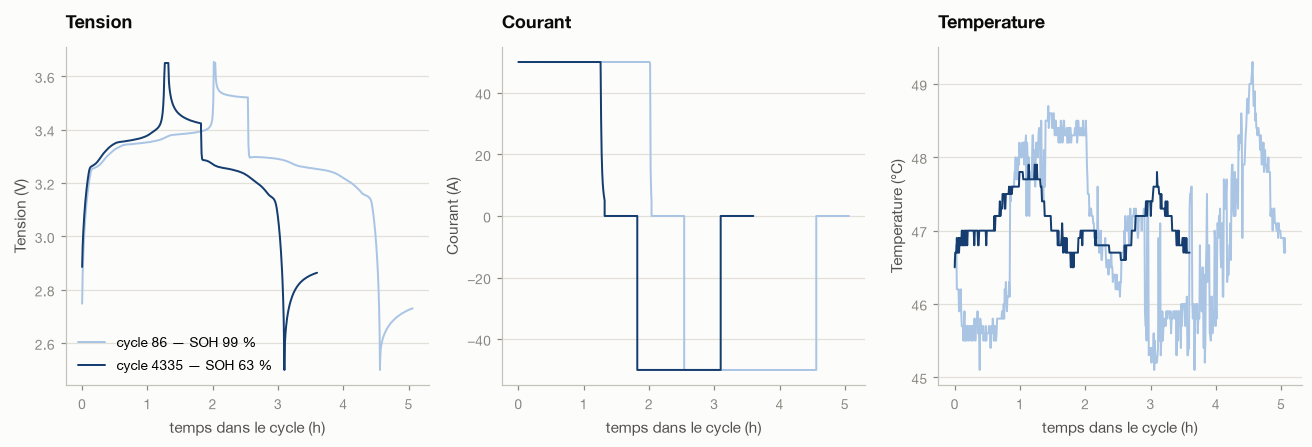

 cycle  SOH (%)  duree cycle (h)  charge (h)  decharge (h)  Q dech. (Ah)  V a mi-decharge (V)  amplitude T (°C)
    86     99.2             5.06        2.04          2.02         101.2               3.2544               4.2
  4335     62.6             3.60        1.32          1.28          63.9               3.2378               1.4


In [49]:
s7_ks = sorted(s7_prof); s7_c2 = s7_ramp("102Ah_45degC_0p5C_cell3", 2)
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0))
for ax, (col, ttl, unit) in zip(axes, [("voltage_V", "Tension", "V"),
                                       ("current_A", "Courant", "A"),
                                       ("temperature_C", "Temperature", "°C")]):
    for c, k in zip(s7_c2, s7_ks):
        g = s7_prof[k]
        ax.plot(g.t_s / 3600, g[col], color=c, lw=1.3,
                label=f"cycle {k} — SOH {s7_feat['102Ah_45degC_0p5C_cell3'].soh_percent.loc[k]:.0f} %")
    finish(ax, ttl, "temps dans le cycle (h)", f"{ttl} ({unit})", legend=(col == "voltage_V"), ncol=1)
plt.show()
s7_p = []
for k in s7_ks:
    g = s7_prof[k]; di = g[g.step_type == "cc_discharge"]; cg = g[g.step_type.isin(["cccv_charge", "cc_charge"])]
    q, v = di.step_capacity_Ah.to_numpy(), di.voltage_V.to_numpy()
    s7_p.append({"cycle": k, "SOH (%)": round(float(s7_feat["102Ah_45degC_0p5C_cell3"].soh_percent.loc[k]), 1),
                 "duree cycle (h)": round((g.t_s.max() - g.t_s.min()) / 3600, 2),
                 "charge (h)": round((cg.t_s.max() - cg.t_s.min()) / 3600, 2),
                 "decharge (h)": round((di.t_s.max() - di.t_s.min()) / 3600, 2),
                 "Q dech. (Ah)": round(float(q.max()), 1),
                 "V a mi-decharge (V)": round(float(np.interp(q.max() / 2, q, v)), 4),
                 "amplitude T (°C)": round(float(g.temperature_C.max() - g.temperature_C.min()), 1)})
print(pd.DataFrame(s7_p).to_string(index=False))

Le cycle passe de **5,06 h à 3,60 h** (charge 2,04 h → 1,32 h, décharge 2,02 h → 1,28 h) pour une capacité déchargée de **101,2 Ah → 63,9 Ah**. À première vue c'est bien une homothétie temporelle. Mais deux détails ne le sont pas :

- la tension à mi-décharge ne bouge quasiment pas (**3,2544 V → 3,2378 V, soit −17 mV**) : la polarisation supplémentaire est faible, le fade est donc dominé par une **perte de matière active / d'inventaire de lithium** plutôt que par une montée de résistance. Attention à la portée de cet argument : il porte sur *une* cellule et *deux* cycles, et « mi-décharge » est une position en capacité relative, pas un état thermodynamique identique ; c'est un indice, pas une preuve ;
- la **fin de charge se déforme visiblement** : le coude vers 3,65 V est plus précoce et le palier CV plus large. C'est là qu'est le signal, et c'est ce que quantifient 7.2 et 7.4.

Le panneau température, lui, est un avertissement. L'oscillation visible n'a rien d'un auto-échauffement : son amplitude vaut **4,2 °C sur le cycle 86 et 1,4 °C sur le cycle 4335** (voie quantifiée au 0,1 °C), c'est-à-dire qu'elle *diminue* quand le courant devient relativement plus élevé par rapport à la capacité restante — l'inverse de ce que ferait la cellule. Le contrôle décisif est en 7.5 : sur les 6 cellules, l'amplitude médiane de `temperature_C` pendant la décharge est identique à celle pendant le repos (rapport **0,97 à 1,00**). Autrement dit, à 30 s d'échantillonnage, **la voie température mesure la régulation de l'enceinte, pas la cellule**. Toute feature bâtie dessus (ΔT en décharge, échauffement à fort courant) est morte-née, et c'est d'autant plus vrai que cette voie est absente sur 16,4 % (25 °C/0.5C) et 19,8 % (35 °C/1C) des lignes.

### 7.2 ICA (dQ/dV) : la seule vraie signature de forme

**Question : les pics de la courbe d'incrémentation capacitaire se déplacent-ils, s'aplatissent-ils au fil de la vie ?**

Contrainte de mesure d'abord, parce qu'elle conditionne tout : avec un pas de 30 s, la phase CC de la charge ne fournit que **234 points en médiane à 0.5C (25 °C), 208 à 0.5C (45 °C) et ~105 points à 1C** — et cela se dégrade avec l'âge, jusqu'à **87 points sur les 100 derniers cycles de 35 °C/1C et 81 sur ceux de 55 °C/1C**. Sur le plateau LFP, en début de vie à 0.5C, l'écart de tension entre deux échantillons consécutifs est de **0,60 mV en médiane** alors que la tension est quantifiée au **0,1 mV** — et **27 intervalles sur 242** ont un ΔV strictement nul. Un dQ/dV calculé par différences finies brutes est donc du bruit pur. La recette retenue : rééchantillonner Q(V) sur une grille régulière de **1 mV**, puis dériver par filtre de Savitzky-Golay d'ordre 3 sur **41 points (± 20 mV)**. C'est ce que fait `s7_ica()`.

On trace 5 cycles étagés dans la vie pour trois cellules : 45 °C/0.5C et 55 °C/1C (les deux qui descendent le plus bas), et 25 °C/1C pour montrer le régime où la méthode atteint sa limite. Le tableau compte les pics **réellement résolus** (détection sur 3,32–3,48 V pour éviter les artefacts de bord du filtre, hauteur > 30 % du maximum).

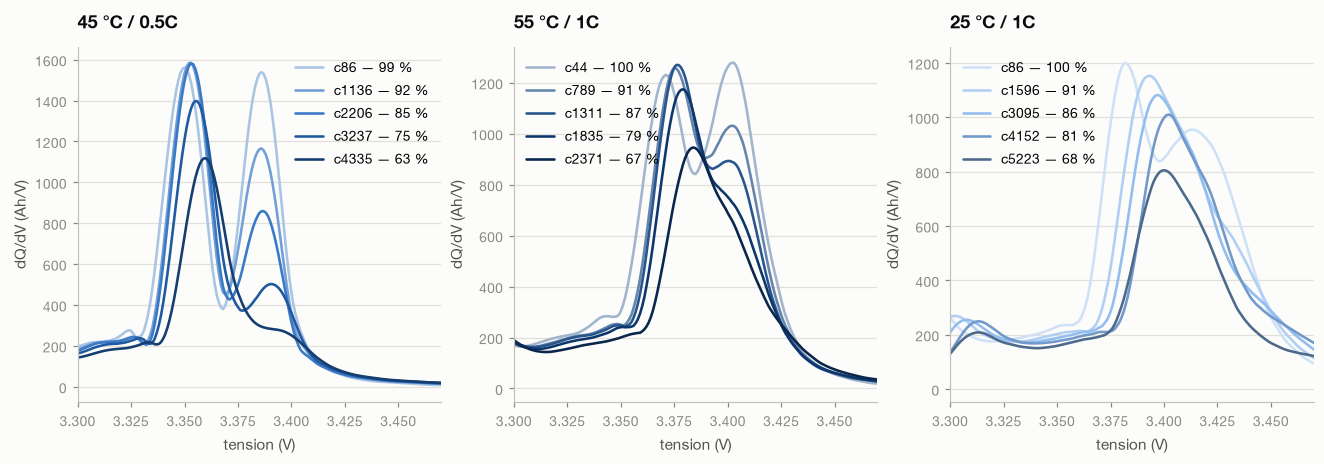

     cellule  cycle  SOH (%)  nb pics resolus             pics (V : Ah/V)
45 °C / 0.5C     86     99.2                2 3.350 : 1561 | 3.386 : 1539
45 °C / 0.5C   1136     91.5                2 3.353 : 1585 | 3.386 : 1165
45 °C / 0.5C   2206     85.2                2  3.353 : 1582 | 3.387 : 859
45 °C / 0.5C   3237     75.1                2  3.355 : 1398 | 3.390 : 502
45 °C / 0.5C   4335     62.6                1                3.360 : 1117
  55 °C / 1C     44     99.9                2 3.371 : 1231 | 3.402 : 1278
  55 °C / 1C    789     91.0                2 3.375 : 1257 | 3.402 : 1031
  55 °C / 1C   1311     86.7                2  3.376 : 1270 | 3.400 : 893
  55 °C / 1C   1835     78.8                1                3.379 : 1175
  55 °C / 1C   2371     66.7                1                 3.384 : 946
  25 °C / 1C     86    100.1                2  3.382 : 1200 | 3.413 : 955
  25 °C / 1C   1596     91.3                1                3.393 : 1153
  25 °C / 1C   3095     85.9          

In [50]:
s7_sel = ["102Ah_45degC_0p5C_cell3", "102Ah_55degC_1C_cell3", "102Ah_25degC_1C_cell3"]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
for ax, cid in zip(axes, s7_sel):
    cur = s7_curves[cid]
    for c, (cy, soh, V, D) in zip(s7_ramp(cid, len(cur)), cur):
        if V is None: continue
        ax.plot(V, D, color=c, lw=1.7, label=f"c{cy} — {soh:.0f} %")
    ax.set_xlim(3.30, 3.47)
    finish(ax, label(cid), "tension (V)", "dQ/dV (Ah/V)", ncol=1)
plt.show()
from scipy.signal import find_peaks
s7_pk = []
for cid in s7_sel:
    for cy, soh, V, D in s7_curves[cid]:
        if V is None: continue
        m = (V >= 3.32) & (V <= 3.48); Vm, Dm = V[m], D[m]   # marge : le SG a des artefacts de bord
        p, _ = find_peaks(Dm, prominence=0.02 * Dm.max())
        p = [i for i in p if Dm[i] > 0.3 * Dm.max()]
        s7_pk.append({"cellule": label(cid), "cycle": cy, "SOH (%)": round(soh, 1),
                      "nb pics resolus": len(p),
                      "pics (V : Ah/V)": " | ".join(f"{Vm[i]:.3f} : {Dm[i]:.0f}" for i in p)})
print(pd.DataFrame(s7_pk).to_string(index=False))

Le résultat est net et il est **asymétrique** — c'est ça l'information.

À **45 °C / 0.5C**, le plateau se résout en deux pics. Le pic bas (3,350 V) est un roc : **1561 → 1117 Ah/V** entre SOH 99,2 % et 62,6 %, soit −28 % de hauteur, et sa position ne dérive que de **+10 mV** (3,350 → 3,360 V). Le pic haut (3,386 V) **s'effondre** : 1539 → 1165 → 859 → 502 Ah/V, puis il n'est plus résolu du tout (fondu en simple épaulement) au cycle 4335. C'est le mode de dégradation qui se lit directement : la fraction de matière active accessible dans le domaine haute tension du plateau part la première.

À **55 °C / 1C** le même scénario se déroule plus vite, mais moins vite que ne le suggérerait la seule température : le second pic (3,400 V) est **encore résolu à SOH 86,7 %** (893 Ah/V, contre 1278 au cycle 44) et il a disparu à SOH 78,8 %. À **25 °C / 1C**, en revanche, les deux pics ne sont séparés **qu'au premier cycle échantillonné** (c86 : 3,382 V / 1200 et 3,413 V / 955) ; dès le cycle 1596 il n'y en a plus qu'un, qui se décale de **3,382 → 3,400 V** et s'affaisse de **1200 → 805 Ah/V**. La polarisation plus forte à 1C, combinée aux ~105 points d'échantillonnage, suffit à les fusionner.

Conséquence pratique : **toute feature définie comme « hauteur du second pic » est inutilisable**, parce que le second pic n'existe pas partout et que le maximum global saute d'un pic à l'autre en cours de vie. Il faut une statistique qui ne suppose rien sur la topologie.

### 7.3 W50 : la largeur à mi-hauteur, la feature ICA qui tient sur les 6 cellules

**Question : existe-t-il une mesure du pic ICA qui décroisse dans le même sens sur les six conditions ?**

On définit `W50` = **mesure totale de l'ensemble {V : dQ/dV ≥ H/2}** sur la fenêtre 3,30–3,50 V, où H est le maximum de la fenêtre. Ce n'est pas exactement une FWHM : quand deux pics coexistent au-dessus de la mi-hauteur, l'ensemble est réunion de deux intervalles et W50 les compte tous les deux. C'est précisément ce qui la rend robuste — elle capture aussi bien l'effondrement du second pic (45 °C/0.5C : l'ensemble se scinde puis se réduit à un intervalle) que le rétrécissement du pic fusionné (cellules 1C), sans jamais avoir à détecter un pic. La contrepartie est qu'elle est quantifiée au pas de la grille : la colonne « amplitude » du tableau donne directement le nombre de pas de 1 mV parcourus sur toute la vie, et sert de garde-fou contre la sur-interprétation.

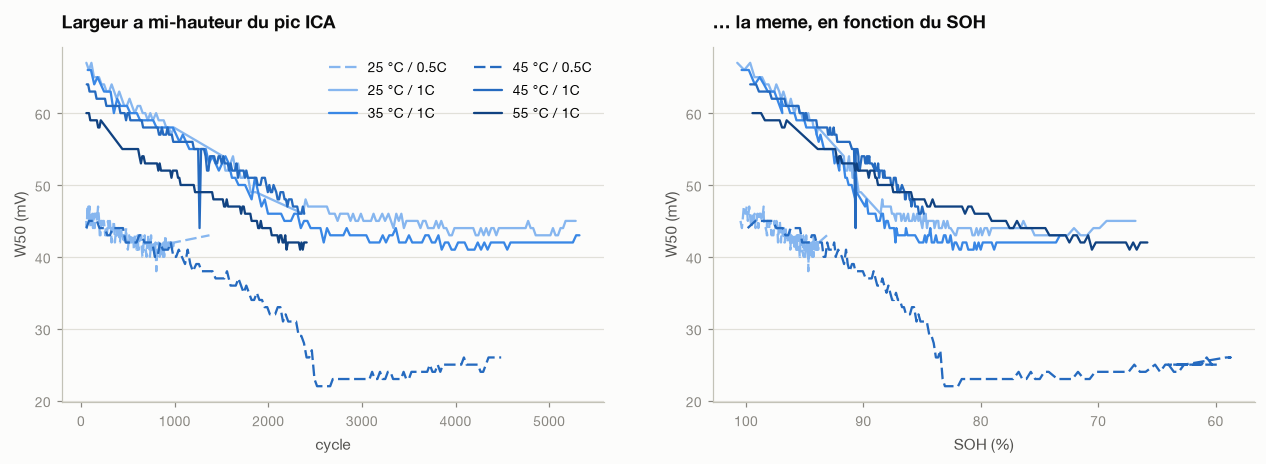

     cellule  W50 debut (mV)  W50 fin (mV)  amplitude (pas de grille)  spearman(W50, SOH)  cycle 90 % de la chute  SOH a ce cycle (%)
25 °C / 0.5C              46            42                          4                0.81                     488                96.2
  25 °C / 1C              65            45                         20                0.93                    2398                88.4
  35 °C / 1C              64            42                         22                0.93                    2417                87.9
45 °C / 0.5C              45            25                         20                0.84                    2409                83.8
  45 °C / 1C              63            46                         17                0.99                    2264                85.6
  55 °C / 1C              59            42                         17                1.00                    2037                74.2


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
s7_w50 = []
for cid, _, _ in CELLS:
    j = s7_feat[cid]; w = j.dropna(subset=["W50_mV"]); w = w[w.index > 50]
    axes[0].plot(w.index, w.W50_mV, **style(cid), lw=1.5, label=label(cid))
    axes[1].plot(w.soh_percent, w.W50_mV, **style(cid), lw=1.5)
    sm = w.W50_mV.rolling(5, center=True, min_periods=2).median()
    a, b = sm.head(8).median(), sm.tail(8).median()
    c90 = sm[sm <= a - 0.9 * (a - b)].index.min()
    s7_w50.append({"cellule": label(cid), "W50 debut (mV)": round(a), "W50 fin (mV)": round(b),
                   "amplitude (pas de grille)": round(a - b),
                   "spearman(W50, SOH)": round(w.W50_mV.corr(w.soh_percent, method="spearman"), 2),
                   "cycle 90 % de la chute": int(c90),
                   "SOH a ce cycle (%)": round(float(j.soh_percent.loc[c90]), 1)})
finish(axes[0], "Largeur a mi-hauteur du pic ICA", "cycle", "W50 (mV)", ncol=2)
axes[1].invert_xaxis(); finish(axes[1], "… la meme, en fonction du SOH", "SOH (%)", "W50 (mV)", legend=False)
plt.show()
print(pd.DataFrame(s7_w50).to_string(index=False))

W50 décroît de façon monotone sur **les six cellules**, avec ρ de Spearman entre **+0,81 et +1,00** — signe constant, aucune exception. Amplitude : **59–65 → 42–46 mV** sur les quatre cellules 1C, et **45 → 25 mV** sur 45 °C/0.5C, où la disparition du second pic donne le contraste le plus fort.

**Une réserve avant d'aller plus loin.** Sur **25 °C / 0.5C**, W50 ne parcourt que **4 mV, soit 4 pas de grille**, sur toute la vie disponible — parce que cette cellule ne descend qu'à 93,1 % de SOH. Son ρ de +0,81 porte donc sur une amplitude à peine supérieure à la quantification, et la ligne « cycle 90 % de la chute » (488, SOH 96,2 %) n'y a aucun sens. Ce n'est pas un contre-exemple à W50, c'est un rappel que cette cellule ne contraint presque rien.

Sur les cinq autres cellules, le graphique révèle la **vraie limite** de la feature : W50 **sature**. La colonne « cycle 90 % de la chute » donne le cycle où W50 a accompli 90 % de sa variation totale ; le SOH correspondant vaut **88,4 / 87,9 / 83,8 / 85,6 / 74,2 %**. Autrement dit, **W50 dit l'essentiel de ce qu'elle a à dire entre 100 % et ~85 % de SOH, puis se tait** (55 °C/1C est la seule à rester informative jusqu'à 74 %). Pour 25 °C/1C et 35 °C/1C, cette saturation intervient au cycle 2398 / 2417 alors que le SOH 80 % n'est atteint qu'au cycle 4330 / 4345 : W50 se fige **~1930 cycles avant** le franchissement de 80 %.

Pour ce challenge c'est une bonne nouvelle et une mauvaise :
- **bonne** — W50 est exactement la feature dont on a besoin dans le run « budget réduit » (cycles de début de vie seulement) : c'est là qu'elle est la plus informative, et elle sépare correctement les conditions dès les premières centaines de cycles ;
- **mauvaise** — elle ne sert **pas** de détecteur de knee tardif : elle est déjà saturée quand le knee arrive. Il ne faut pas lui demander ce service.

### 7.4 Durée de la phase CV : le marqueur le plus propre, à condition d'atténuer l'aliasing

**Question : la durée de la phase à tension constante croît-elle avec le vieillissement, et de combien ?**

Le protocole charge en CC-CV jusqu'à 3,649 V (tension max médiane mesurée : 3,6489 à 3,6507 V selon la cellule) avec une coupure à **5,00 A**, soit C/20. Physiquement, plus la cellule vieillit, plus la CC atteint tôt la tension de coupure et plus la CV doit compenser : `t_CV` doit croître.

Un piège de mesure ici, et il est instructif. Défini naïvement comme « dernier échantillon CC → fin du step », `t_CV` hérite d'un **aliasing** : la durée de la CC diminue continûment avec l'âge, donc la phase de la grille 30 s par rapport à la vraie transition CC→CV dérive lentement, et `t_CV` affiche une **dent de scie** superposée à la tendance. Sur 55 °C/1C, où `t_CV` ne vaut que 40 à 122 s, c'est le tiers du signal. La correction appliquée dans la cellule d'extraction : on **interpole l'instant du passage à 3,645 V** entre les deux échantillons qui l'encadrent (le saut de tension y vaut 39 à 95 mV en médiane selon la cellule, donc l'interpolation est bien conditionnée).

**Le gain est réel mais partiel — il faut le dire.** Le tableau donne les deux versions. Pour `t_CV` la correction ne change presque rien là où le signal est ample (−0,992 → −0,993 sur 25 °C/1C) et compte là où il est court (−0,894 → −0,922 sur 25 °C/0.5C, −0,672 → **−0,775** sur 45 °C/1C). Pour `q_CV`, en revanche, le gain est massif partout : **−0,657 → −0,829** (25 °C/0.5C), **−0,399 → −0,684** (45 °C/1C), **−0,319 → −0,575** (55 °C/1C). Et surtout : l'interpolation **atténue** la dent de scie sans l'éliminer — le bruit hf passe de 0,090 à 0,065 (25 °C/0.5C) et de 0,091 à 0,079 (55 °C/1C), et une oscillation résiduelle de 26 à 43 s crête-à-crête reste visible sur les courbes 0.5C et 55 °C. Il faut donc lisser `t_CV` avant de s'en servir, comme le fait la médiane glissante 25 cycles du graphique.

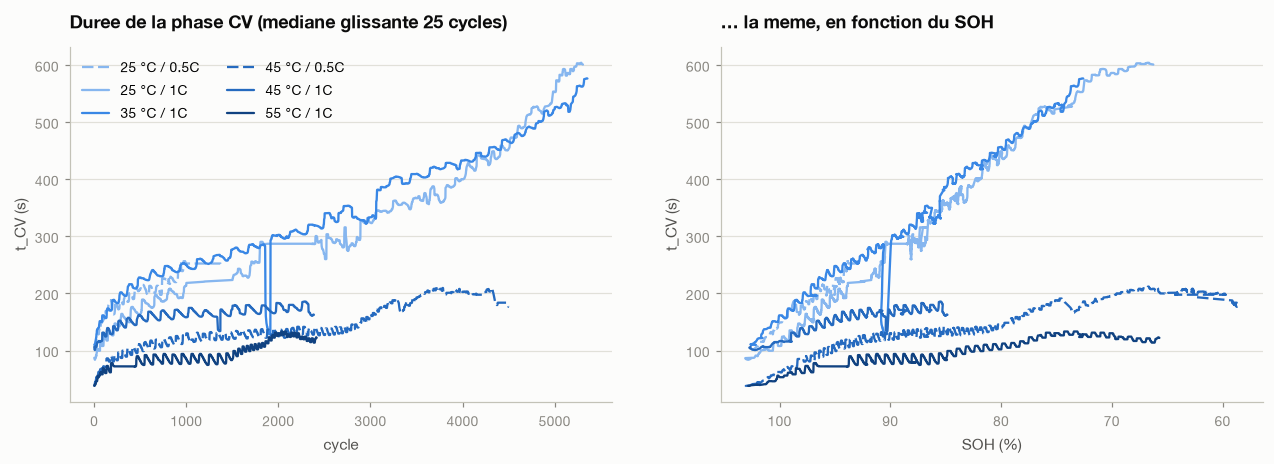

     cellule  t_cv debut (s)  t_cv fin (s)  pearson  spearman  spearman naif  bruit hf  bruit hf naif  spearman q_cv  spearman q_cv naif  bruit hf q_cv  plus gros saut (s)  au cycle
25 °C / 0.5C             104           253   -0.920    -0.922         -0.894     0.065          0.090         -0.829              -0.657          0.087                  20       737
  25 °C / 1C              84           602   -0.991    -0.993         -0.992     0.019          0.020         -0.984              -0.962          0.030                  43      2522
  35 °C / 1C             111           577   -0.976    -0.984         -0.983     0.026          0.028         -0.974              -0.936          0.029                 152      1914
45 °C / 0.5C              43           179   -0.935    -0.937         -0.916     0.055          0.064         -0.885              -0.710          0.091                  13      2614
  45 °C / 1C             101           163   -0.799    -0.775         -0.672     0.056    

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
s7_cv = []
for cid, _, _ in CELLS:
    j = s7_feat[cid]; j = j[j.complet].dropna(subset=["t_cv_s"])
    sm = j.t_cv_s.rolling(25, center=True, min_periods=5).median()
    axes[0].plot(j.index, sm, **style(cid), lw=1.5, label=label(cid))
    axes[1].plot(j.soh_percent, sm, **style(cid), lw=1.5)
    jn = s7_feat[cid]; jn = jn[jn.complet]
    s7_cv.append({"cellule": label(cid), "t_cv debut (s)": round(j.t_cv_s.head(20).median()),
                  "t_cv fin (s)": round(j.t_cv_s.tail(20).median()),
                  "pearson": round(j.t_cv_s.corr(j.soh_percent), 3),
                  "spearman": round(j.t_cv_s.corr(j.soh_percent, method="spearman"), 3),
                  "spearman naif": round(jn.t_cv_naif_s.corr(jn.soh_percent, method="spearman"), 3),
                  "bruit hf": round(s7_hf_noise(j.t_cv_s), 3),
                  "bruit hf naif": round(s7_hf_noise(jn.t_cv_naif_s), 3),
                  "spearman q_cv": round(j.q_cv_Ah.corr(j.soh_percent, method="spearman"), 3),
                  "spearman q_cv naif": round(jn.q_cv_naif_Ah.corr(jn.soh_percent, method="spearman"), 3),
                  "bruit hf q_cv": round(s7_hf_noise(j.q_cv_Ah), 3),
                  "plus gros saut (s)": round(sm.diff().loc[sm.diff().abs().idxmax()]),
                  "au cycle": int(sm.diff().abs().idxmax())})
finish(axes[0], "Duree de la phase CV (mediane glissante 25 cycles)", "cycle", "t_CV (s)", ncol=2)
axes[1].invert_xaxis(); finish(axes[1], "… la meme, en fonction du SOH", "SOH (%)", "t_CV (s)", legend=False)
plt.show()
print(pd.DataFrame(s7_cv).to_string(index=False))

`t_CV` croît sur les six cellules, avec un **signe systématiquement négatif** vis-à-vis du SOH et les corrélations les plus fortes de toute la section : **Pearson −0,991 et Spearman −0,993 sur 25 °C/1C**, −0,976 / −0,984 sur 35 °C/1C. Le bruit haute fréquence est le plus faible du lot (0,019 à 0,079 ; médiane 0,055). Et contrairement à W50, `t_CV` **ne sature pas** : elle continue de croître jusqu'au dernier cycle disponible (84 → 602 s sur 25 °C/1C, soit un facteur 7).

Trois nuances honnêtes :

- la cellule **45 °C/1C est la moins bien servie** (Spearman −0,775). La raison n'est pas un accident isolé mais un **plateau** : `t_CV` monte de 125 à 163 s entre les cycles 0 et 600, puis stagne autour de 163–166 s jusqu'au cycle 1400 pendant que le SOH continue de tomber de 93,8 à 89,6 %, avant de repartir. Sur une plage utile aussi courte (101 → 163 s) une stagnation de 800 cycles suffit à casser le rang ;
- il existe une **discontinuité franche sur 35 °C/1C** : la médiane glissante saute de **+152 s en un cycle au cycle 1914** (129 → 282 s), soit bien plus que tous les autres sauts de la section (+13 à +43 s ailleurs). Elle n'est pas accolée à une longue pause (2,9 h) et reste inexpliquée ; à traiter comme un point de segmentation, pas comme du vieillissement ;
- la **disponibilité tombe à 82 %** sur 35 °C/1C, parce que le garde-fou d'interpolation (les deux échantillons encadrant 3,645 V doivent être distants de 1 à 60 s) rejette les cycles où une pause du banc s'est glissée dans le step de charge. C'est un rejet volontaire et souhaitable : mieux vaut une valeur manquante qu'une valeur fausse.

La variante en charge `q_CV` (0,47 → 3,82 Ah sur 25 °C/1C) suit la même tendance avec des corrélations un peu plus faibles (−0,575 à −0,984). Elle a l'avantage d'être exprimée en Ah, donc directement comparable à la capacité ; l'inconvénient d'être systématiquement plus bruitée que `t_CV`, et de l'être surtout là où la phase CV est courte : **0,156 sur 55 °C/1C**, 0,091 sur 45 °C/0.5C, 0,087 sur 25 °C/0.5C, contre 0,029–0,030 sur les deux cellules à longue CV.

### 7.5 Résistance DC repos→décharge : la feature qu'il faut savoir rejeter

**Question : la résistance DC mesurée à l'attaque de la décharge croît-elle avec le vieillissement ?**

Le protocole offre une mesure quasi gratuite : entre la dernière ligne du repos post-charge (I = 0) et la première ligne de la décharge (I = −50 ou −100 A, capacité de step encore nulle), l'écart de tension divisé par |I| donne un R_dc, avec une résolution de **0,002 mΩ à 50 A** (0,001 mΩ à 100 A).

Deux précautions d'implémentation, toutes deux vérifiées ci-dessous.

**a) L'écart de temps entre ces deux lignes n'est pas toujours nul.** Selon la cellule, 44 à 79 % des cycles ont Δt = 0 s, 6 à 14 % Δt = 1 s, et **10 à 45 % Δt = 30 s** — sur ces derniers on ne mesure donc pas le même instant de relaxation. Le contrôle imprimé montre que ça ne change presque rien : la médiane de R sur la population Δt = 30 s ne diffère de celle sur Δt ≤ 1 s que de **0,2 à 5,2 %**. Le saut de tension est donc bien dominé par la composante rapide, et mélanger les deux populations est acceptable — mais il fallait le vérifier, pas le supposer.

**b) Cette transition ne peut pas se chercher à l'intérieur d'un `cycle_number`.** Sur les deux cellules 25 °C, le découpage en cycles est décalé d'un demi-cycle pour une partie des cycles (777 cycles sur 988 à 0.5C, 971 sur 4157 à 1C commencent par la décharge) : le repos qui précède la décharge appartient alors au cycle précédent. En travaillant sur la **timeline continue** du cache trié on couvre 978 et 4146 cycles ; en restant à l'intérieur du cycle on n'en couvrirait que **211 et 3185**. Les quatre autres cellules ne sont pas concernées.

Et ensuite, il faut regarder le résultat en face.

premiere etape du cycle = DECHARGE (frontiere decalee) : 25 °C / 0.5C 777/988, 25 °C / 1C 971/4157, 35 °C / 1C 0/5355, 45 °C / 0.5C 0/4303, 45 °C / 1C 0/2324, 55 °C / 1C 0/2176
transition repos->decharge trouvee A L'INTERIEUR du cycle : 25 °C / 0.5C 211/978, 25 °C / 1C 3185/4146, 35 °C / 1C 5354/5354, 45 °C / 0.5C 4299/4299, 45 °C / 1C 2324/2324, 55 °C / 1C 2176/2176
ecart de temps entre la derniere ligne de repos et la premiere de decharge (part des cycles) :
     cellule 0 s 1 s 30 s
25 °C / 0.5C 79% 11%  10%
  25 °C / 1C 59%  8%  33%
  35 °C / 1C 44% 11%  45%
45 °C / 0.5C 44% 14%  42%
  45 °C / 1C 45% 11%  44%
  55 °C / 1C 49%  6%  44%
R_dc median selon cet ecart (controle : un saut ohmique ne doit pas dependre de dt) :
     cellule  R (dt<=1 s)  R (dt=30 s)  ecart (%)
25 °C / 0.5C        0.488        0.490        0.4
  25 °C / 1C        0.428        0.450        5.2
  35 °C / 1C        0.424        0.425        0.2
45 °C / 0.5C        0.378        0.379        0.3
  45 °C / 1C     

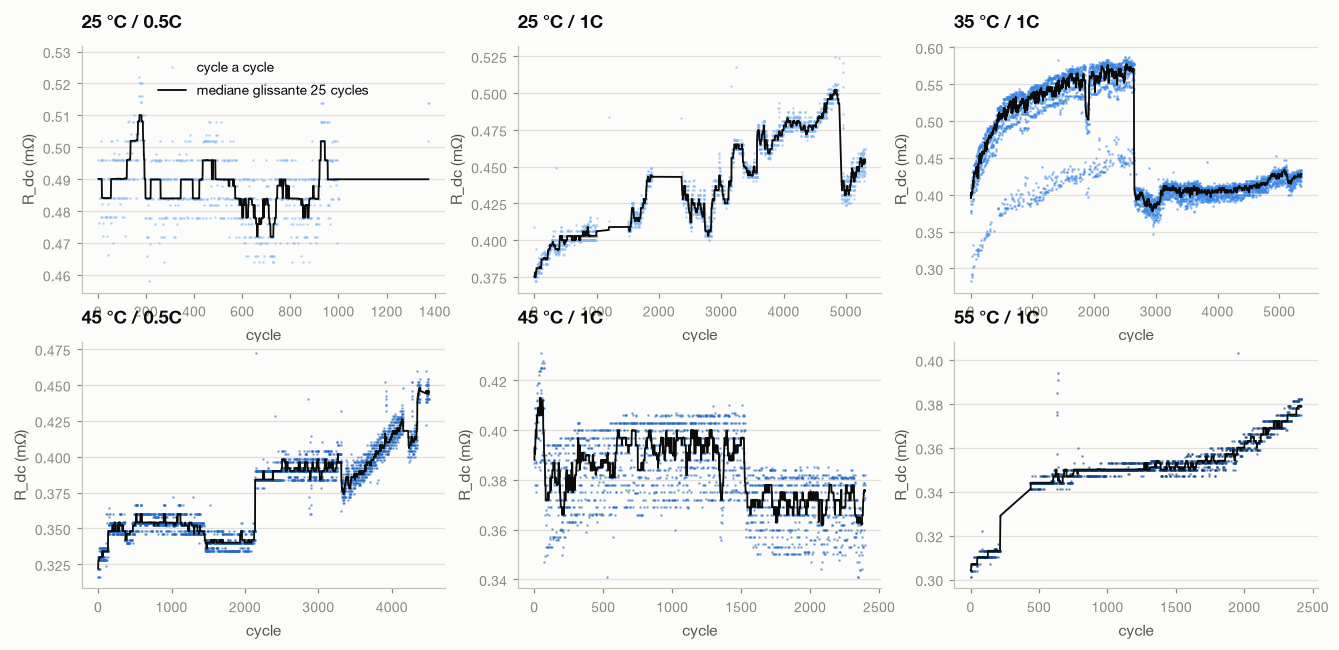

     cellule  R med (mΩ)  spearman(R, SOH)  plus gros saut (%)  au cycle  pause max a ±40 cycles (h)  derive /100 cycles (%)
25 °C / 0.5C       0.488              0.25                 1.2        55                       106.8                    1.24
  25 °C / 1C       0.437             -0.86               -10.2      4929                       885.9                    1.37
  35 °C / 1C       0.425              0.45               -16.0      2647                        46.5                    1.39
45 °C / 0.5C       0.378             -0.80                 8.6      2138                       215.5                    1.06
  45 °C / 1C       0.381              0.43                -3.1       277                         3.0                    1.04
  55 °C / 1C       0.350             -0.91                 5.1       218                       190.8                    0.57


In [53]:
print("premiere etape du cycle = DECHARGE (frontiere decalee) : " +
      ", ".join(f"{label(c)} {s7_order[c][0]}/{s7_order[c][1]}" for c, _, _ in CELLS))
print("transition repos->decharge trouvee A L'INTERIEUR du cycle : " +
      ", ".join(f"{label(c)} {int(s7_rdt[c].meme_cycle.sum())}/{len(s7_rdt[c])}" for c, _, _ in CELLS))
print("ecart de temps entre la derniere ligne de repos et la premiere de decharge (part des cycles) :")
print(pd.DataFrame([{"cellule": label(c), **{f"{int(k)} s": f"{v:.0%}" for k, v in
                     s7_rdt[c].dt_s.value_counts(normalize=True).head(3).sort_index().items()}}
                    for c, _, _ in CELLS]).fillna("").to_string(index=False))
print("R_dc median selon cet ecart (controle : un saut ohmique ne doit pas dependre de dt) :")
print(pd.DataFrame([{"cellule": label(c),
                     "R (dt<=1 s)": round(float(s7_rdt[c].R[s7_rdt[c].dt_s <= 1].median()), 3),
                     "R (dt=30 s)": round(float(s7_rdt[c].R[s7_rdt[c].dt_s >= 29].median()), 3),
                     "ecart (%)": round(100 * (s7_rdt[c].R[s7_rdt[c].dt_s >= 29].median()
                                        / s7_rdt[c].R[s7_rdt[c].dt_s <= 1].median() - 1), 1)}
                    for c, _, _ in CELLS]).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(14.5, 6.4))
s7_r = []
for n, (ax, (cid, _, _)) in enumerate(zip(axes.ravel(), CELLS)):
    j = s7_feat[cid].dropna(subset=["R_dc_mohm"])
    sm = j.R_dc_mohm.rolling(25, center=True, min_periods=5).median()
    ax.plot(j.index, j.R_dc_mohm, ".", ms=1.5, color=style(cid)["color"], alpha=.45,
            label="cycle a cycle" if n == 0 else None)
    ax.plot(j.index, sm, color=INK, lw=1.2, label="mediane glissante 25 cycles" if n == 0 else None)
    finish(ax, label(cid), "cycle", "R_dc (mΩ)", legend=(n == 0), ncol=1)
    d = sm.diff(); c = d.abs().idxmax(); g = s7_gaps[cid]
    loc = g.loc[max(g.index.min(), c - 40): c + 40]
    drift = 100 * sm.diff(100).abs().median() / j.R_dc_mohm.median()
    s7_r.append({"cellule": label(cid), "R med (mΩ)": round(j.R_dc_mohm.median(), 3),
                 "spearman(R, SOH)": round(j.R_dc_mohm.corr(j.soh_percent, method="spearman"), 2),
                 "plus gros saut (%)": round(100 * d.loc[c] / sm.shift().loc[c], 1), "au cycle": int(c),
                 "pause max a ±40 cycles (h)": round(float(loc.max()), 1),
                 "derive /100 cycles (%)": round(drift, 2)})
plt.show()
print(pd.DataFrame(s7_r).to_string(index=False))

La mesure est disponible sur **99 à 100 % des cycles** et les niveaux sont physiquement crédibles (0,350 à 0,488 mΩ pour une prismatique 102 Ah). Et pourtant **cette feature n'est pas utilisable telle quelle**, pour deux raisons chiffrées.

**1. Le signe s'inverse d'une cellule à l'autre.** Spearman(R, SOH) vaut −0,86 / −0,80 / −0,91 sur 25 °C/1C, 45 °C/0.5C, 55 °C/1C (R monte quand le SOH baisse : le comportement attendu) mais **+0,45 sur 35 °C/1C, +0,43 sur 45 °C/1C, +0,25 sur 25 °C/0.5C**. Une feature dont la corrélation change de signe selon la condition ne peut pas entrer telle quelle dans un modèle qui doit extrapoler vers des conditions jamais vues.

**2. Les discontinuités dominent la dérive physique.** La dérive « normale » du R lissé vaut **0,57 à 1,39 % pour 100 cycles**. Or le plus gros saut d'un cycle à l'autre de la médiane glissante atteint **−16,0 % (35 °C/1C, cycle 2647)**, −10,2 % (25 °C/1C, cycle 4929), +8,6 % (45 °C/0.5C, cycle 2138), +5,1 % (55 °C/1C, cycle 218). Un saut de 16 % en un cycle, c'est l'équivalent de **plus de 1100 cycles** de dérive réelle : aucune dégradation ne fait ça. Les deux cellules restantes ne montrent rien de tel (+1,2 % sur 25 °C/0.5C, −3,1 % sur 45 °C/1C, du même ordre que leur dérive à 100 cycles).

L'origine est identifiable : la colonne « pause max à ±40 cycles » montre que **les quatre gros sauts sont tous accolés à un arrêt du banc** de 46,5 h à 885,9 h. La cellule se repose en circuit ouvert pendant des jours ou des semaines, relaxe, et repart avec une résistance décalée — et le banc a possiblement été re-manipulé entre-temps.

Deux détails qui achèvent de disqualifier la feature :
- sur **35 °C/1C**, le nuage se dédouble entre les cycles 0 et 2647 : 14 % des cycles forment une branche **28 % plus basse** que la branche principale. Ce dédoublement n'est expliqué ni par Δt (les médianes des deux populations Δt diffèrent de 0,2 %), ni par la parité du cycle (47 % de cycles pairs dans la branche basse). Après le saut du cycle 2647 le nuage redevient unimodal à **0,407 mΩ**, c'est-à-dire *en dessous* du niveau de départ (0,462 mΩ sur les 500 premiers cycles) et au niveau de l'ancienne branche basse ;
- sur **25 °C/0.5C**, tout le signal tient dans une bande d'environ 0,06 mΩ pour un quantum de 0,002 mΩ : la médiane glissante y est un escalier de quantification. Le ρ de +0,25 n'y a guère de contenu.

Morale : **R_dc mesure autant l'historique du banc d'essai que l'état de la cellule**. Or l'historique du banc est exactement l'information que le modèle n'aura pas à la prédiction (il ne reçoit que T et C). Utiliser R_dc revient à apprendre du bruit expérimental non reproductible. À rejeter — ou à ne réutiliser qu'après segmentation explicite aux pauses, ce qui est un travail à part entière.

### 7.6 Synthèse : ce qu'on garde, ce qu'on jette

Le tableau ci-dessous récapitule les sept features candidates sur les quatre critères annoncés, plus une colonne décisive : **la corrélation obtenue quand on met les six cellules dans le même sac**, avant et après normalisation par la valeur de début de vie propre à chaque cellule (médiane des 20 premiers cycles disponibles).

Cette dernière colonne répond à la question qui compte vraiment pour un modèle censé généraliser à 25-55 °C × 0.5-1.0 C : la feature a-t-elle une **échelle absolue commune**, ou seulement une **tendance interne** à chaque cellule ?

In [54]:
s7_defs = [("Q_plat_Ah", "aire du pic ICA = charge du plateau", "ICA (150 cycles)", True),
           ("W50_mV",    "largeur a mi-hauteur du pic ICA",     "ICA (150 cycles)", True),
           ("H_ic",      "hauteur du pic ICA",                  "ICA (150 cycles)", True),
           ("t_cv_s",    "duree de la phase CV de la charge",   "t_cv / q_cv",      False),
           ("q_cv_Ah",   "charge injectee pendant la CV",       "t_cv / q_cv",      False),
           ("R_dc_mohm", "|dV/dI| a la transition repos->decharge", "R_dc",         False),
           ("dT_dis_C",  "amplitude thermique en decharge",     "dT decharge",      False)]
rows = []
for f, desc, cost, is_ica in s7_defs:
    sp, dispo, nz, pool, raw = [], [], [], [], []
    for cid, _, _ in CELLS:
        j = s7_feat[cid]; j = j[j.complet]
        v = j[f].dropna()
        if len(v) < 30: continue
        sp.append(j[f].corr(j.soh_percent, method="spearman"))
        nz.append(s7_hf_noise(j[f]))
        if is_ica:
            cyc = j.index.to_numpy(); n = len(cyc[:: max(1, len(s7_feat[cid]) // 150)])
            dispo.append(len(v) / n)
        else:
            dispo.append(j[f].notna().mean())
        pool.append(pd.DataFrame({"x": j[f] / v.head(20).median(), "s": j.soh_percent}).dropna())
        raw.append(pd.DataFrame({"x": j[f], "s": j.soh_percent}).dropna())
    sp = np.array(sp); P, B = pd.concat(pool), pd.concat(raw)
    rows.append({"feature": f, "definition": desc,
                 "|rho| intra-cellule": round(float(np.median(np.abs(sp))), 2),
                 "plage": f"{np.abs(sp).min():.2f}-{np.abs(sp).max():.2f}",
                 "signe constant": "oui" if (sp > 0).all() or (sp < 0).all() else "NON",
                 "|rho| poole brut": round(abs(float(B.x.corr(B.s, method="spearman"))), 2),
                 "|rho| poole normalise": round(abs(float(P.x.corr(P.s, method="spearman"))), 2),
                 "dispo min": f"{min(dispo):.0%}", "bruit hf": round(float(np.nanmedian(nz)), 3),
                 "cout 6 cellules (s)": round(s7_cost[cost], 1)})
s7_table = pd.DataFrame(rows).sort_values("|rho| intra-cellule", ascending=False)
print(s7_table.to_string(index=False))
print("\nControle de la voie temperature : amplitude mediane par cycle")
print(pd.DataFrame([{"cellule": label(c), "pendant la decharge (°C)": round(float(s7_feat[c].dT_dis_C.median()), 2),
                     "pendant le repos (°C)": round(float(s7_feat[c].dT_rest_C.median()), 2),
                     "rapport": round(float(s7_feat[c].dT_dis_C.median() / s7_feat[c].dT_rest_C.median()), 2)}
                    for c, _, _ in CELLS]).to_string(index=False))

  feature                              definition  |rho| intra-cellule     plage signe constant  |rho| poole brut  |rho| poole normalise dispo min  bruit hf  cout 6 cellules (s)
Q_plat_Ah     aire du pic ICA = charge du plateau                 0.96 0.96-0.98            oui              0.92                   0.94       99%     0.102                  0.4
   t_cv_s       duree de la phase CV de la charge                 0.93 0.77-0.99            oui              0.41                   0.83       82%     0.055                  0.4
   W50_mV         largeur a mi-hauteur du pic ICA                 0.89 0.80-0.99            oui              0.45                   0.92       99%     0.101                  0.4
  q_cv_Ah           charge injectee pendant la CV                 0.86 0.57-0.98            oui              0.32                   0.83       82%     0.075                  0.4
     H_ic                      hauteur du pic ICA                 0.64 0.07-0.99            NON              0

### 7.7 Ce qu'il faut retenir pour la modélisation

**Trois features à garder, dans cet ordre.**

1. **`t_cv_s` — durée de la phase CV.** |ρ| médian 0,93, signe constant sur les 6 cellules, le bruit le plus faible du lot (0,055), pas de saturation en fin de vie, coût inférieur à la seconde pour les 6 cellules. C'est le meilleur proxy de vieillissement de toute la section. Disponibilité 82 % au pire, par rejet volontaire des cycles pollués par une pause du banc. À lisser (médiane glissante) avant usage : l'aliasing 30 s est atténué, pas supprimé.
2. **`W50_mV` — largeur à mi-hauteur du pic ICA.** |ρ| médian 0,89, signe constant, disponible sur 99 % des cycles échantillonnés, et surtout **|ρ| poolé normalisé = 0,92** : c'est la feature qui se transfère le mieux entre conditions. Sa fenêtre d'utilité est SOH 100 → ~85 %, ce qui la rend idéale pour le run à budget réduit et inutile pour le knee tardif.
3. **`Q_plat_Ah` — aire du pic ICA.** |ρ| médian 0,96 et 0,92 même sans normalisation. Mais il faut être lucide : cette quantité *est* la capacité du plateau, donc une re-mesure de la cible. Elle sert de contrôle de cohérence (elle valide la chaîne ICA), pas de feature indépendante.

**Trois à jeter.**

- **`R_dc_mohm`** : signe non constant (−0,91 à +0,45), et des sauts de 5 à 16 % en un cycle accolés aux pauses du banc, contre une dérive physique de 0,6 à 1,4 % pour 100 cycles. Elle encode l'historique expérimental, que le modèle ne connaîtra pas.
- **`H_ic`** (hauteur du pic ICA) : |ρ| de 0,07 à 0,99 selon la cellule, signe non constant — parce que le maximum global saute d'un pic à l'autre en cours de vie. Cas d'école d'une feature détruite par sa propre définition.
- **`dT_dis_C`** : la voie température mesure l'enceinte, pas la cellule (amplitude en décharge / amplitude au repos = 0,97 à 1,00 sur les 6 cellules), et elle manque sur 21 % des cycles au pire.

**Le point le plus important, et il n'est pas dans les colonnes de corrélation.** Comparez `|rho| poole brut` et `|rho| poole normalise` : `t_cv_s` passe de **0,41 à 0,83**, `W50_mV` de **0,45 à 0,92**, `q_cv_Ah` de **0,32 à 0,83**. Ces features sont fortement informatives *à l'intérieur* d'une cellule mais leur **niveau absolu dépend de (T, C)** — `t_CV` démarre à 40 s à 55 °C/1C et à 111 s à 35 °C/1C, `W50` démarre à 45-46 mV sur les cellules 0.5C et 59-65 mV sur les 1C. Dans un pipeline pré-entraînement puis fine-tuning, elles doivent donc être fournies **normalisées par leur propre valeur de début de vie**, jamais en valeur brute. Une feature brute apprendra la condition d'essai, pas le vieillissement.

Enfin, le coût : **~2 s pour extraire l'ensemble des features sur les 6 cellules** depuis le cache parquet, ICA comprise (échantillonnée à 150 cycles par cellule) ; la section entière s'exécute en moins de 4 s. Aucune de ces features n'est un obstacle de calcul, même dans un `fit()` contraint en temps.

## 8 · Synthèse

Sept sections, 132 constats mesurés. Voici ce qui change réellement la façon
d'aborder la modélisation, par ordre de gravité.

### 8.1 Ce que le jeu de données est vraiment

**Six cellules, six conditions, zéro répétition.** Aucune condition n'est
doublée, donc aucune estimation de la variabilité cellule à cellule n'est
possible à partir de ces données. Deux tiers des cellules sont à 1C, et
35 °C comme 55 °C n'existent qu'à 1C.

**Trois cellules seulement descendent réellement à 70 %** : 25 °C/1C (cycle
5142), 45 °C/0.5C (3545) et 55 °C/1C (2219). La 35 °C/1C s'arrête à 72.6 %,
la 45 °C/1C à 84.8 %, la 25 °C/0.5C à 93.1 %. Le point à 54.4 % de la
35 °C/1C, qui pouvait laisser croire le contraire, est une décharge
interrompue — ses voisins sont à 74.9 %.

**Et la découverte la plus lourde : aucune cellule n'a tourné à sa consigne.**
Le plancher de température en fin de repos vaut 35.2, 33.6, 38.3, 45.8, 46.5
et 57.1 °C pour des consignes de 25, 25, 35, 45, 45 et 55 °C. Ce n'est pas de
l'auto-échauffement — l'amplitude intra-cycle ne dépasse pas 4.9 °C, et la
cellule « 25 °C » n'est jamais descendue sous 26.7 °C de tout son
enregistrement.

> Le plan d'expérience réellement subi est **33.6–57.1 °C**, pas 25–55 °C.
> Les conditions « 25 °C » et « 35 °C » sont tassées dans 4.7 °C. Prédire à
> 25 °C, comme le demande le sujet, est donc une **extrapolation de 8.6 °C
> sous le point le plus froid jamais mesuré** — et non une interpolation.

### 8.2 Les pièges, par ordre de coût

| # | Piège | Ampleur | Conséquence si ignoré |
|---|---|---|---|
| 1 | Lignes non triées | **100 % des cycles**, 6/6 cellules | dQ/dV, dV/dt, résistance : bruit pur |
| 2 | `cycle_number` ≠ compteur de cycles | 1128 des 2050 index absents n'ont jamais été cyclés | axe des abscisses faux |
| 3 | 45 °C/0.5C : fichier raccordé | 162 cycles dupliqués re-numérotés | rebond de SOH de **+4.55 pt**, knee fantôme |
| 4 | 25 °C/1C : parties recouvrantes | 264 840 lignes en double (**14.5 %**) | features pondérées 2 à 3 fois |
| 5 | Pannes de capteur de température | 158 et 1122 cycles continus | 50.9 % des cycles sous 85 % de SOH sans température |
| 6 | Décharges tronquées | 3 aberrations majeures survivent au filtre | SOH à 42.8 % là où la tendance vaut 59 % |

Le piège n°1 mérite d'être vu : le fichier est écrit **par blocs parcourus à
rebours**. La vraie première mesure d'un cycle arrive en 11ᵉ position, et la
14ᵉ ligne porte la 595ᵉ mesure sur 600. Calculée telle quelle avec le code
d'exemple du template, la trajectoire Q(V) parcourt 11 fois la plage de
capacité et le dQ/dV descend à −1400 Ah/V. Après tri, trois pics ICA
exploitables apparaissent.

Le piège n°3 est le plus insidieux car il **fabrique de la physique fausse** :
les cycles 4222-4343 de la 45 °C/0.5C rejouent les cycles 3866-3987, à
l'identique ligne à ligne, avec un décalage de +356. La cellule ne va donc pas
jusqu'au cycle 4501 mais s'arrête réellement au **4383, à 58.72 %**.

### 8.3 Le knee-point

Le knee est net sur **4 cellules**, et il tombe dans une bande de SOH
étroite — **79.7 à 85.0 %** (moyenne 81.9, écart-type 2.2) — alors que les
cycles correspondants varient d'un facteur 2.9 (1504 à 4405). En fraction de
vie, il se situe entre 0.678 et 0.805 de N70.

En validation leave-one-out sur ces 4 cellules, prédire le knee à SOH constant
donne une MAE de 264 cycles, contre 196 pour l'hypothèse « fraction de vie
constante ». Mais cette seconde hypothèse exige de connaître N70, donc elle est
circulaire pour une prédiction. Avec n = 4, **les deux sont statistiquement
indiscernables** : le prior « knee vers 82 % de SOH » est utilisable, la
régression en température (R² = 0.63, non monotone) ne l'est pas.

### 8.4 Ce qui pilote le vieillissement

**La température domine, le C-rate est presque muet.** Le rapport des taux de
fade b(1C)/b(0.5C) vaut 0.918 à 25 °C et 0.905 à 45 °C — moins de 10 % — quand
N95 varie d'un facteur 2.2 entre 25 et 55 °C. Plus frappant : **25 °C et 35 °C
à 1C vieillissent de façon quasi indiscernable** (N80 = 4329 contre 4345, écart
de trajectoire rms 0.42 point sur 2731 cycles communs).

Une cellule à 0.5C passe 1.65 fois plus de temps au banc pour le même fade par
cycle : ni la durée calendaire ni l'amplitude du courant ne pilotent la
dégradation. Le compteur pertinent est le **débit de charge cyclé**.

**L'Arrhenius ne tient pas sur 25–55 °C** : R² = 0.827 sur ln b, avec des
résidus de signe alterné. En retirant 25 °C, R² monte à 0.895 — mais sur trois
points. C'est cohérent avec 8.1 : le point « 25 °C » est en réalité à 34 °C.

### 8.5 Features candidates

| Feature | Corrélation au SOH | Verdict |
|---|---|---|
| **Durée de phase CV** (`t_CV`) | ρ médian **0.93**, jusqu'à −0.993 | la meilleure — amplitude ×7, à lisser |
| Largeur ICA à mi-hauteur (`W50`) | ρ +0.81 à +1.00, monotone | informe le début de vie, **sature avant le knee** |
| Charge en phase CV (`q_CV`) | −0.58 à −0.83 après interpolation | plus bruitée que `t_CV` |
| Résistance DC | −0.91 à **+0.45** | **signe qui s'inverse selon la cellule — inutilisable en l'état** |
| `temperature_C` | — | mesure l'**enceinte**, pas la cellule |

Deux règles en découlent. D'abord, **toutes ces features doivent être
normalisées par leur valeur de début de vie** : en pooling brut sur les 6
cellules, |ρ| de `t_CV` tombe à 0.41, et remonte à 0.83 après normalisation.
Ensuite, le coût n'est pas un obstacle — l'extraction complète prend 2 s pour
les 6 cellules depuis le cache.

### 8.6 Conséquences pour la suite

1. **Ne jamais lisser la cible.** Une moyenne glissante de 401 cycles atténue le
   pic de vitesse de perte de 22 % et retarde le passage à 70 % ; à 1001 cycles
   l'écart au SOH réel atteint 10.9 points. Le knee est précisément ce qu'il faut
   prédire — le lisser revient à supprimer la réponse.
2. **Nettoyer, oui ; imputer, non.** Le pipeline retenu (filtre framework +
   cycles sans charge + doublons + MAD à plancher) n'écarte que **0.89 %** des
   cycles et ne déplace aucun des cycles-repères à 80 %.
3. **Pondérer les cellules.** La 25 °C/0.5C apporte 988 mesures s'arrêtant à
   93 % sans amorce de knee ; lui donner le même poids qu'à la 45 °C/0.5C, qui
   descend à 58.7 %, revient à diluer l'information de fin de vie.
4. **Le run « budget réduit » tombe sur la zone la plus propre** — les cycles
   1-500 perdent moins de 1.5 % d'index sur cinq cellules — sauf pour la
   25 °C/0.5C, dont la panne de capteur couvre les cycles 22-196.
5. **Traiter le domaine froid comme une extrapolation assumée**, en s'appuyant
   sur les datasets publics : c'est exactement là que le pré-entraînement doit
   porter, puisque les données cibles n'y descendent jamais.

> **Portée de cette analyse.** Tous les chiffres ci-dessus proviennent de code
> exécuté sur les six cellules, et chaque section a été ré-exécutée puis
> confrontée à ses propres sorties par un vérificateur indépendant. Les
> conclusions à n = 4 ou n = 6 cellules (knee, Arrhenius, effet du C-rate)
> restent des observations, pas des lois : elles orientent la modélisation,
> elles ne la valident pas.